# **Stage 02 — Intraday Data Analysis**

```
S02_intraday_data_analysis.ipynb
```

# **0. Introducción**



El objetivo de esta notebook es analizar el comportamiento del dataset intradiario `mnq_intraday`, compuesto por datos OHLCV minuto a minuto del mercado MNQ.

Antes de construir targets o entrenar modelos predictivos, es necesario entender cómo se comportan los datos origen a lo largo del tiempo. En particular, se busca evaluar si el mercado mantiene una estructura relativamente estable entre los años 2020 y 2026, o si existen cambios importantes en volatilidad, volumen, rango de precios y comportamiento intradiario.

Este análisis se enfocará en estudiar el dataset desde distintas perspectivas temporales:

* comportamiento por año;
* comportamiento por trimestre;
* comportamiento por mes;
* comportamiento por régimen intradiario;
* diferencias entre sesiones como Overnight, Pre-market, Opening, Regular y Closing.

La hipótesis principal es que el mercado no se comporta de la misma manera durante todo el día ni durante todos los años. Por lo tanto, antes de definir targets, umbrales o estrategias de entrenamiento, se analizará si existen cambios estructurales que puedan afectar la estabilidad del modelo.

En esta notebook no se construirán targets ni etiquetas de predicción. El objetivo es realizar un diagnóstico exploratorio del dataset origen para tomar mejores decisiones en etapas posteriores, especialmente en relación con:

* selección de períodos de entrenamiento;
* validación temporal;
* uso de walk-forward validation;
* posible entrenamiento por régimen intradiario;
* normalización o ajuste de features según contexto temporal.

Este análisis servirá como base para definir una metodología más robusta de modelado, evitando asumir que todos los datos históricos pertenecen a un mismo contexto de mercado.

0. Introducción
1. Configuración inicial
2. Carga y validación inicial del dataset
3. Cobertura temporal del dataset
4. Análisis de regímenes intradiarios
5. Construcción de métricas OHLCV descriptivas
6. Análisis estadístico general OHLCV
7. Análisis OHLCV por régimen intradiario
8. Análisis temporal por año
9. Análisis temporal por año y régimen
10. Análisis trimestral
11. Análisis de estabilidad temporal
12. Análisis rolling
13. Evaluación de cambios estructurales
14. Implicancias para entrenamiento del modelo
15. Resumen final de hallazgos
16. Guardado de resultados


# **1. Configuración Inicial**


### **Importación de librerías**


In [2]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

#from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

### **Rutas de archivos**

In [3]:
from pathlib import Path

# Buscar la raíz del proyecto
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "neural_profit_local":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\heguu\OneDrive\Escritorio\neural_profit_local


In [4]:
REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

# **2. Carga y validación inicial del dataset**

## 2.1 Carga de dataset `mnq_intraday.parquet`

In [5]:
# Rutas de datos
MNQ_INTRADAY_PATH = PROJECT_ROOT / "data" / "02_mnq_intraday"
MNQ_INTRADAY_PATH.mkdir(parents=True, exist_ok=True)
MNQ_INTRADAY_PARQUET = MNQ_INTRADAY_PATH / "mnq_intraday.parquet"

In [6]:
# Función para cargar dataset
def load_mnq_parquet(dataset_path):
    os.path.exists(dataset_path)
    print("Archivo encontrado en disco. Cargando dataset local...")
    mnq_parquet = pd.read_parquet(dataset_path)
    return mnq_parquet

mnq_intraday = load_mnq_parquet(MNQ_INTRADAY_PARQUET)

Archivo encontrado en disco. Cargando dataset local...


In [7]:
import os
import json

# Función para cargar archivo JSON
def load_mnq_json(json_path):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"No se encontró el archivo JSON en: {json_path}")

    print("Archivo JSON encontrado en disco. Cargando resumen local...")

    with open(json_path, "r", encoding="utf-8") as f:
        mnq_json = json.load(f)

    return mnq_json


MNQ_INTRADAY_SUMMARY = MNQ_INTRADAY_PATH / "mnq_intraday_summary.json"

mnq_intraday_summary = load_mnq_json(MNQ_INTRADAY_SUMMARY)

Archivo JSON encontrado en disco. Cargando resumen local...


## 2.2 Información general del dataset


In [8]:
# Función para ver información de dataset
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import pandas as pd


def mnq_dataset_info(
    df: pd.DataFrame,
    *,
    name: str = "mnq_raw",
    tz_assume_if_naive: Optional[str] = None,  # ej: "UTC" o "America/New_York"
    day_def: str = "calendar",  # "calendar" (fecha calendario) o "trading" (días con datos)
) -> Dict[str, Any]:
    """
    Resume un dataset OHLCV con DatetimeIndex (ideal para mnq_raw).

    - Si el índice es tz-naive:
        - Si tz_assume_if_naive != None, lo localiza a esa tz.
        - Si no, reporta "tz-naive" (no se puede afirmar horario UTC).
    - Devuelve dict con métricas principales (y lo imprime bonito si se desea).
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: se requiere DatetimeIndex, recibido: {type(df.index)}")

    idx = df.index

    # --- timezone / UTC info ---
    tzinfo = idx.tz
    if tzinfo is None:
        tz_status = "tz-naive (sin zona horaria)"
        if tz_assume_if_naive:
            idx = idx.tz_localize(tz_assume_if_naive)
            tzinfo = idx.tz
            tz_status = f"localizado como {tzinfo}"
    else:
        tz_status = f"{tzinfo}"

    # --- rango temporal ---
    ts_min = idx.min()
    ts_max = idx.max()

    first_day = ts_min.date()
    last_day = ts_max.date()

    # --- días ---
    if day_def == "calendar":
        total_days = (pd.Timestamp(last_day) - pd.Timestamp(first_day)).days + 1
    elif day_def == "trading":
        total_days = idx.normalize().nunique()
    else:
        raise ValueError("day_def debe ser 'calendar' o 'trading'")

    # --- columnas ---
    columns = list(df.columns)

    # --- checks útiles ---
    n_rows = len(df)
    n_cols = df.shape[1]
    n_missing = int(df.isna().sum().sum())
    missing_by_col = df.isna().sum().to_dict()
    dup_index = int(idx.duplicated().sum())
    is_monotonic = bool(idx.is_monotonic_increasing)

    # Frecuencia estimada (puede fallar si hay huecos grandes)
    freq = pd.infer_freq(idx[: min(50000, len(idx))])  # muestra grande pero acotada

    # Cobertura por día (min/max de hora del día, en tz del índice)
    # (Útil para ver si es 24/7 o horario de sesión)
    tod = pd.Series(idx.time)
    # Convertimos time a minutos del día para resumen robusto
    tod_minutes = pd.Series([t.hour * 60 + t.minute for t in tod])
    typical_minute_min = int(tod_minutes.min())
    typical_minute_max = int(tod_minutes.max())

    # Rango promedio de filas por día (sólo días con datos)
    rows_per_day = df.groupby(idx.normalize()).size()
    rows_per_day_stats = {
        "days_with_data": int(rows_per_day.shape[0]),
        "rows_per_day_min": int(rows_per_day.min()),
        "rows_per_day_p50": float(rows_per_day.median()),
        "rows_per_day_max": int(rows_per_day.max()),
    }

    # Si hay tz, también mostramos rango en UTC
    if tzinfo is not None:
        ts_min_utc = ts_min.tz_convert("UTC")
        ts_max_utc = ts_max.tz_convert("UTC")
        utc_range = (str(ts_min_utc), str(ts_max_utc))
        utc_note = "El índice está tz-aware; el horario UTC es inequívoco."
    else:
        utc_range = None
        utc_note = "El índice es tz-naive; no se puede asegurar si está en UTC sin suposiciones."

    info: Dict[str, Any] = {
        "name": name,
        "shape": (n_rows, n_cols),
        "columns": columns,
        "index_type": type(df.index).__name__,
        "index_tz": tz_status,
        "utc_note": utc_note,
        "datetime_min": str(ts_min),
        "datetime_max": str(ts_max),
        "first_day": str(first_day),
        "last_day": str(last_day),
        "total_days": int(total_days),
        "day_definition": day_def,
        "utc_range_if_applicable": utc_range,
        "is_index_monotonic_increasing": is_monotonic,
        "duplicated_timestamps_in_index": dup_index,
        "inferred_freq_sample": freq,
        "missing_total_cells": n_missing,
        "missing_by_col": missing_by_col,
        "rows_per_day_stats": rows_per_day_stats,
        "time_of_day_minutes_range": {
            "min_minute_of_day": typical_minute_min,
            "max_minute_of_day": typical_minute_max,
        },
    }
    return info


def print_mnq_dataset_info(info: Dict[str, Any]) -> None:
    """Imprime el dict de mnq_dataset_info de forma ordenada."""
    print(f"Dataset: {info['name']}")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print(f"Index: {info['index_type']} | TZ: {info['index_tz']}")
    print(f"Datetime min/max: {info['datetime_min']}  ->  {info['datetime_max']}")
    print(f"First/Last day: {info['first_day']}  ->  {info['last_day']}")
    print(f"Total days ({info['day_definition']}): {info['total_days']}")
    #print(f"Inferred freq (sample): {info['inferred_freq_sample']}")
    #print(f"Index monotonic increasing: {info['is_index_monotonic_increasing']}")
    #print(f"Duplicated timestamps in index: {info['duplicated_timestamps_in_index']}")
    #print(f"Missing total cells: {info['missing_total_cells']}")
    #print(f"Missing by col: {info['missing_by_col']}")
    #print(f"Rows/day stats: {info['rows_per_day_stats']}")
    print(f"Time-of-day range (minutes): {info['time_of_day_minutes_range']}")
    print(f"UTC note: {info['utc_note']}")
    if info["utc_range_if_applicable"] is not None:
        print(f"UTC range: {info['utc_range_if_applicable'][0]}  ->  {info['utc_range_if_applicable'][1]}")


In [9]:
# Ejecución para revisar información del dataset 
info = mnq_dataset_info(mnq_intraday, name="mnq_intraday", tz_assume_if_naive=None, day_def="trading")
print_mnq_dataset_info(info)

Dataset: mnq_intraday
Shape: (1024062, 9)
Columns: ['date', 'minute_of_day', 'regime_id', 'open', 'high', 'low', 'close', 'volume', 'contract']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 04:30:00-05:00  ->  2026-04-17 16:00:00-04:00
First/Last day: 2020-01-02  ->  2026-04-17
Total days (trading): 1482
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2020-01-02 09:30:00+00:00  ->  2026-04-17 20:00:00+00:00


## 2.3 Validación temporal básica de `mnq_intraday`


Valida lo esencial para series temporales antes de construir targets: orden cronológico, duplicados, consistencia por día, monotonicidad de minute_of_day, gaps temporales y saltos sospechosos. Esto es importante porque en trading hay que validar cuidadosamente los timestamps para evitar look-ahead bias, y porque en series temporales el orden secuencial es parte central del problema.

In [10]:
# Validación temporal de mnq_intraday
import pandas as pd
import numpy as np

# ============================================================
# Validación temporal de mnq_intraday
# Ejecutar inmediatamente después de:
# mnq_intraday = load_mnq_parquet()
# ============================================================

def validate_mnq_intraday(df: pd.DataFrame, verbose: bool = True) -> dict:
    """
    Valida consistencia temporal básica para un dataset intradía.

    Chequeos:
    1) Índice datetime válido
    2) Orden cronológico global
    3) Duplicados de timestamp
    4) Consistencia de columna `date`
    5) Monotonía de `minute_of_day` dentro de cada día
    6) Duplicados de `minute_of_day` dentro de cada día
    7) Saltos temporales negativos o nulos
    8) Gaps intradía distintos de 1 minuto
    """

    result = {
        "ok": True,
        "checks": {},
        "summary": {},
        "artifacts": {}
    }

    df = df.copy()

    # ------------------------------------------------------------
    # 0) Verificaciones básicas de estructura
    # ------------------------------------------------------------
    required_cols = ["date", "minute_of_day", "open", "high", "low", "close", "volume"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El índice del DataFrame debe ser un pd.DatetimeIndex")

    if df.empty:
        raise ValueError("El DataFrame está vacío")

    # ------------------------------------------------------------
    # 1) Orden global del índice
    # ------------------------------------------------------------
    is_monotonic = df.index.is_monotonic_increasing
    has_unique_index = df.index.is_unique
    duplicated_index = df.index[df.index.duplicated()].unique()

    result["checks"]["index_is_monotonic_increasing"] = bool(is_monotonic)
    result["checks"]["index_is_unique"] = bool(has_unique_index)
    result["summary"]["n_duplicated_timestamps"] = int(len(duplicated_index))
    result["artifacts"]["duplicated_timestamps"] = duplicated_index

    # Si no está ordenado, mostramos evidencia pero no reordenamos silenciosamente
    if not is_monotonic:
        diffs_ns = pd.Series(df.index.view("i8")).diff()
        bad_order_pos = np.where(diffs_ns <= 0)[0]
        result["artifacts"]["bad_global_order_positions"] = bad_order_pos[:20]
        result["ok"] = False

    if not has_unique_index:
        result["ok"] = False

    # ------------------------------------------------------------
    # 2) Consistencia entre index.date y columna `date`
    # ------------------------------------------------------------
    # Normalizamos ambos a fecha sin hora
    index_dates = pd.Index(df.index.tz_localize(None).date if df.index.tz is not None else df.index.date)
    col_dates = pd.to_datetime(df["date"]).dt.date

    date_match = (index_dates == col_dates).all()
    result["checks"]["date_column_matches_index_date"] = bool(date_match)

    if not date_match:
        mismatch_mask = index_dates != col_dates
        mismatches = df.loc[mismatch_mask, ["date", "minute_of_day", "close"]].head(20)
        result["artifacts"]["date_mismatches_head"] = mismatches
        result["summary"]["n_date_mismatches"] = int(mismatch_mask.sum())
        result["ok"] = False
    else:
        result["summary"]["n_date_mismatches"] = 0

    # ------------------------------------------------------------
    # 3) Diferencias temporales globales
    # ------------------------------------------------------------
    # Trabajamos en segundos
    diffs_sec = pd.Series(df.index).diff().dt.total_seconds()

    n_non_positive_diffs = int((diffs_sec.iloc[1:] <= 0).sum())
    result["checks"]["all_global_time_diffs_positive"] = (n_non_positive_diffs == 0)
    result["summary"]["n_non_positive_global_diffs"] = n_non_positive_diffs

    if n_non_positive_diffs > 0:
        bad_diff_rows = df.iloc[np.where((diffs_sec <= 0).fillna(False))[0][:20]]
        result["artifacts"]["non_positive_global_diffs_head"] = bad_diff_rows
        result["ok"] = False

    # ------------------------------------------------------------
    # 4) Validación por día
    # ------------------------------------------------------------
    daily_stats = []
    bad_minute_order_days = []
    duplicate_minute_days = []
    intraday_gap_rows = []

    grouped = df.groupby("date", sort=False)

    for day, g in grouped:
        g = g.copy()

        # 4.1 orden del índice dentro del día
        idx_mono = g.index.is_monotonic_increasing

        # 4.2 minute_of_day creciente dentro del día
        mod_diff = g["minute_of_day"].diff()
        minute_order_ok = bool((mod_diff.iloc[1:] > 0).all())

        # 4.3 duplicados de minute_of_day dentro del día
        dup_mod = g["minute_of_day"].duplicated().sum()
        has_dup_mod = dup_mod > 0

        # 4.4 gaps intradía del índice
        idx_diff_sec = pd.Series(g.index).diff().dt.total_seconds()
        gap_mask = (~idx_diff_sec.isna()) & (idx_diff_sec != 60)

        n_intraday_gaps = int(gap_mask.sum())

        if not minute_order_ok:
            bad_minute_order_days.append(day)

        if has_dup_mod:
            duplicate_minute_days.append(day)

        if n_intraday_gaps > 0:
            gap_info = g.loc[gap_mask, ["date", "minute_of_day", "open", "high", "low", "close", "volume"]].copy()
            gap_info["gap_seconds"] = idx_diff_sec[gap_mask].values
            intraday_gap_rows.append(gap_info)

        daily_stats.append({
            "date": day,
            "n_rows": len(g),
            "index_monotonic": bool(idx_mono),
            "minute_of_day_monotonic": minute_order_ok,
            "n_duplicate_minute_of_day": int(dup_mod),
            "n_intraday_gaps_not_60s": n_intraday_gaps,
            "minute_min": int(g["minute_of_day"].min()),
            "minute_max": int(g["minute_of_day"].max()),
        })

        if not idx_mono or not minute_order_ok or has_dup_mod:
            result["ok"] = False

    daily_stats_df = pd.DataFrame(daily_stats)

    result["artifacts"]["daily_stats"] = daily_stats_df
    result["summary"]["n_days"] = int(daily_stats_df.shape[0])
    result["summary"]["days_with_bad_minute_order"] = int(len(bad_minute_order_days))
    result["summary"]["days_with_duplicate_minute_of_day"] = int(len(duplicate_minute_days))
    result["summary"]["days_with_intraday_gaps_not_60s"] = int((daily_stats_df["n_intraday_gaps_not_60s"] > 0).sum())

    result["checks"]["all_days_have_monotonic_minute_of_day"] = (len(bad_minute_order_days) == 0)
    result["checks"]["no_duplicate_minute_of_day_within_day"] = (len(duplicate_minute_days) == 0)
    result["checks"]["all_intraday_steps_are_60s_within_day"] = bool(
        (daily_stats_df["n_intraday_gaps_not_60s"] == 0).all()
    )

    result["artifacts"]["bad_minute_order_days"] = bad_minute_order_days
    result["artifacts"]["duplicate_minute_days"] = duplicate_minute_days

    if intraday_gap_rows:
        result["artifacts"]["intraday_gaps_head"] = pd.concat(intraday_gap_rows, axis=0).head(50)
    else:
        result["artifacts"]["intraday_gaps_head"] = pd.DataFrame()

    # ------------------------------------------------------------
    # 5) Resumen global
    # ------------------------------------------------------------
    result["summary"]["n_rows"] = int(len(df))
    result["summary"]["start"] = df.index.min()
    result["summary"]["end"] = df.index.max()

    # ------------------------------------------------------------
    # 6) Reporte por pantalla
    # ------------------------------------------------------------
    if verbose:
        print("=" * 70)
        print("VALIDACIÓN TEMPORAL DE mnq_intraday")
        print("=" * 70)
        print(f"Rows                     : {result['summary']['n_rows']}")
        print(f"Days                     : {result['summary']['n_days']}")
        print(f"Start                    : {result['summary']['start']}")
        print(f"End                      : {result['summary']['end']}")
        print("-" * 70)
        print(f"Index monotonic          : {result['checks']['index_is_monotonic_increasing']}")
        print(f"Index unique             : {result['checks']['index_is_unique']}")
        print(f"Date == index.date       : {result['checks']['date_column_matches_index_date']}")
        print(f"Global diffs > 0         : {result['checks']['all_global_time_diffs_positive']}")
        print(f"minute_of_day monotonic  : {result['checks']['all_days_have_monotonic_minute_of_day']}")
        print(f"No dup minute_of_day     : {result['checks']['no_duplicate_minute_of_day_within_day']}")
        print(f"Intraday steps = 60s     : {result['checks']['all_intraday_steps_are_60s_within_day']}")
        print("-" * 70)
        print(f"Duplicated timestamps    : {result['summary']['n_duplicated_timestamps']}")
        print(f"Date mismatches          : {result['summary']['n_date_mismatches']}")
        print(f"Non-positive global diffs: {result['summary']['n_non_positive_global_diffs']}")
        print(f"Bad minute order days    : {result['summary']['days_with_bad_minute_order']}")
        print(f"Dup minute_of_day days   : {result['summary']['days_with_duplicate_minute_of_day']}")
        print(f"Days with !=60s gaps     : {result['summary']['days_with_intraday_gaps_not_60s']}")
        print("-" * 70)
        print(f"DATASET OK               : {result['ok']}")
        print("=" * 70)

        if result["summary"]["n_duplicated_timestamps"] > 0:
            print("\nDuplicated timestamps (head):")
            print(pd.Index(result["artifacts"]["duplicated_timestamps"][:10]))

        if result["summary"]["n_date_mismatches"] > 0:
            print("\nDate mismatches (head):")
            print(result["artifacts"]["date_mismatches_head"])

        if result["summary"]["days_with_bad_minute_order"] > 0:
            print("\nDays with bad minute_of_day order (head):")
            print(result["artifacts"]["bad_minute_order_days"][:10])

        if result["summary"]["days_with_duplicate_minute_of_day"] > 0:
            print("\nDays with duplicate minute_of_day (head):")
            print(result["artifacts"]["duplicate_minute_days"][:10])

        if not result["artifacts"]["intraday_gaps_head"].empty:
            print("\nIntraday gaps != 60 seconds (head):")
            print(result["artifacts"]["intraday_gaps_head"])

    return result


# ============================================================
# Ejecución inmediata
# ============================================================
validation = validate_mnq_intraday(mnq_intraday, verbose=True)

# Si quiere abortar automáticamente cuando haya problemas críticos:
critical_checks = [
    "index_is_monotonic_increasing",
    "index_is_unique",
    "date_column_matches_index_date",
    "all_global_time_diffs_positive",
    "all_days_have_monotonic_minute_of_day",
    "no_duplicate_minute_of_day_within_day",
]

failed_critical = [k for k in critical_checks if not validation["checks"].get(k, False)]

if failed_critical:
    raise ValueError(
        "Validación temporal fallida. Checks críticos con error: "
        + ", ".join(failed_critical)
    )

VALIDACIÓN TEMPORAL DE mnq_intraday
Rows                     : 1024062
Days                     : 1482
Start                    : 2020-01-02 04:30:00-05:00
End                      : 2026-04-17 16:00:00-04:00
----------------------------------------------------------------------
Index monotonic          : True
Index unique             : True
Date == index.date       : True
Global diffs > 0         : True
minute_of_day monotonic  : True
No dup minute_of_day     : True
Intraday steps = 60s     : True
----------------------------------------------------------------------
Duplicated timestamps    : 0
Date mismatches          : 0
Non-positive global diffs: 0
Bad minute order days    : 0
Dup minute_of_day days   : 0
Days with !=60s gaps     : 0
----------------------------------------------------------------------
DATASET OK               : True


## 2.4 Conclusión de validación

El dataset `mnq_intraday` se encuentra correctamente estructurado para la construcción de targets temporales.

En particular, se verificó que:

- el índice `datetime` está ordenado cronológicamente en forma ascendente,
- no existen timestamps duplicados,
- la columna `date` coincide con la fecha derivada del índice,
- no hay saltos temporales negativos ni diferencias no positivas,
- dentro de cada jornada, `minute_of_day` es estrictamente creciente,
- no existen duplicados de `minute_of_day` dentro de un mismo día,
- y todos los pasos intradía son consistentes con una frecuencia de 1 minuto.

Por lo tanto, el dataset queda validado como temporalmente consistente y apto para construir targets forward del tipo `delta_h` y `ret_h`, siempre que dichos horizontes se calculen respetando los límites de cada jornada y evitando cruces entre días.

# **3. Cobertura temporal del dataset**

Una vez validada la consistencia temporal del dataset `mnq_intraday`, el siguiente paso es analizar cómo se distribuyen las observaciones a lo largo del tiempo.

El objetivo de esta sección no es validar nuevamente la calidad del índice temporal, sino entender la cobertura real del dataset entre 2020 y 2026. Esto permite identificar si existen años, trimestres o meses con mayor o menor cantidad de muestras, y evaluar si determinados períodos tienen más peso dentro del conjunto de datos.

Este análisis es importante porque, en un problema de series temporales financieras, la distribución temporal de las muestras puede afectar directamente el entrenamiento de un modelo. Si algunos años o períodos están sobrerrepresentados, el modelo podría aprender patrones dominantes de esos contextos y generalizar peor en períodos con condiciones de mercado diferentes.

Por este motivo, se analizará la cantidad de muestras por año, trimestre y mes, así como la cantidad de jornadas disponibles y la distribución de barras intradiarias. Esta información servirá como base para decidir, en etapas posteriores, si conviene trabajar con todo el histórico, utilizar ventanas temporales, aplicar validación walk-forward o separar períodos de entrenamiento y evaluación de forma más cuidadosa.

## 3.1 Cantidad de muestras por año

En esta sección se analiza la cantidad de registros disponibles por año dentro del dataset `mnq_intraday`.

El objetivo es verificar cómo se distribuyen las muestras entre 2020 y 2026, identificando si existen años completos, años parciales o períodos con menor representación dentro del dataset.

Este análisis es importante porque, si algunos años concentran más observaciones que otros, el modelo podría quedar más influenciado por esos períodos durante el entrenamiento. Además, permite confirmar que años parciales, como 2026, sean tratados correctamente en análisis posteriores.


In [11]:
# 3.1 Cantidad de muestras por año
# ============================================================
#
# Objetivo:
# Analizar cuántas muestras contiene el dataset por cada año,
# sin modificar el índice datetime original.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Como el dataset ya fue validado previamente, no volvemos a ordenar
# ni hacemos copias pesadas innecesarias.

# Barras esperadas por jornada completa según el rango intradiario
expected_bars_per_full_day = (
    mnq_intraday["minute_of_day"].max()
    - mnq_intraday["minute_of_day"].min()
    + 1
)

# DataFrame auxiliar liviano solo para cobertura temporal
df_year_aux = pd.DataFrame({
    "year": mnq_intraday.index.year,
    "datetime": mnq_intraday.index,
    "date": mnq_intraday["date"].values,
})

# Resumen de muestras por año
df_samples_by_year = (
    df_year_aux
    .groupby("year", sort=True)
    .agg(
        samples=("year", "size"),
        trading_days=("date", "nunique"),
        first_datetime=("datetime", "first"),
        last_datetime=("datetime", "last"),
    )
    .reset_index()
)

# Métricas adicionales
df_samples_by_year["avg_bars_per_day"] = (
    df_samples_by_year["samples"]
    / df_samples_by_year["trading_days"]
)

df_samples_by_year["expected_bars_per_full_day"] = expected_bars_per_full_day

df_samples_by_year["coverage_ratio_vs_full_day"] = (
    df_samples_by_year["avg_bars_per_day"]
    / df_samples_by_year["expected_bars_per_full_day"]
)

df_samples_by_year["samples_pct_total"] = (
    df_samples_by_year["samples"]
    / df_samples_by_year["samples"].sum()
    * 100
)

display("Cantidad de muestras por año")
display(df_samples_by_year)

'Cantidad de muestras por año'

,year,samples,trading_days,first_datetime,last_datetime,avg_bars_per_day,expected_bars_per_full_day,coverage_ratio_vs_full_day,samples_pct_total
0,2020,155475,225,2020-01-02 04:30:00-05:00,2020-12-31 16:00:00-05:00,691.0,691,1.0,15.182186
1,2021,168604,244,2021-01-04 04:30:00-05:00,2021-12-31 16:00:00-05:00,691.0,691,1.0,16.464238
2,2022,165840,240,2022-01-03 04:30:00-05:00,2022-12-30 16:00:00-05:00,691.0,691,1.0,16.194332
3,2023,163767,237,2023-01-03 04:30:00-05:00,2023-12-29 16:00:00-05:00,691.0,691,1.0,15.991903
4,2024,165149,239,2024-01-02 04:30:00-05:00,2024-12-31 16:00:00-05:00,691.0,691,1.0,16.126856
5,2025,156857,227,2025-01-02 04:30:00-05:00,2025-12-31 16:00:00-05:00,691.0,691,1.0,15.317139
6,2026,48370,70,2026-01-02 04:30:00-05:00,2026-04-17 16:00:00-04:00,691.0,691,1.0,4.723347


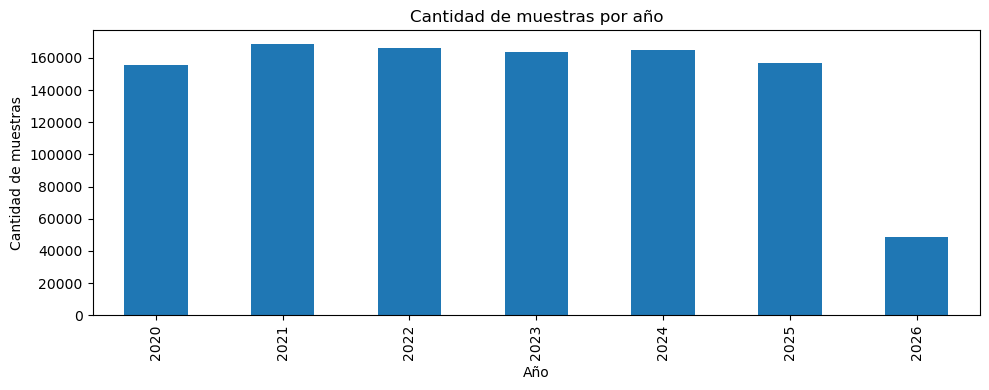

In [12]:
# Gráfico: cantidad de muestras por año
# ============================================================

ax = df_samples_by_year.plot(
    x="year",
    y="samples",
    kind="bar",
    figsize=(10, 4),
    legend=False,
)

ax.set_title("Cantidad de muestras por año")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de muestras")

plt.tight_layout()
plt.show()

**Observación:**
La cobertura anual del dataset es consistente entre `2020` y `2025`: todos los años presentan un promedio de `691` barras por jornada, equivalente al rango intradiario completo entre `04:30` y `16:00`. Esto indica que las jornadas disponibles están completas y mantienen una estructura homogénea. Las diferencias en la cantidad total de muestras se explican por la cantidad de jornadas presentes en cada año, que varía entre `225` y `244`. El año `2026` es la única excepción relevante, ya que corresponde a un período parcial con datos disponibles solo hasta el `17/04/2026`.

## 3.2 Cantidad de muestras por trimestre


En esta sección se analiza la cantidad de registros disponibles por trimestre dentro del dataset `mnq_intraday`.

El objetivo es observar la distribución temporal de las muestras con mayor granularidad que en el análisis anual. Esto permite identificar trimestres completos, trimestres parciales o posibles períodos con menor representación dentro del dataset.

Este análisis es relevante porque los cambios de contexto de mercado pueden ocurrir dentro de un mismo año. Por lo tanto, evaluar la cobertura trimestral permite detectar si determinados períodos tienen más peso en el dataset y si la distribución de muestras es adecuada para futuros análisis temporales y esquemas de validación.


In [13]:
# 3.2 Cantidad de muestras por trimestre
# ============================================================
#
# Objetivo:
# Analizar cuántas muestras contiene el dataset por cada trimestre.
#
# Esto permite evaluar la cobertura temporal con mayor detalle
# que el análisis anual e identificar trimestres parciales.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Barras esperadas por jornada completa según el rango intradiario
expected_bars_per_full_day = (
    mnq_intraday["minute_of_day"].max()
    - mnq_intraday["minute_of_day"].min()
    + 1
)

# DataFrame auxiliar liviano para cobertura trimestral
df_quarter_aux = pd.DataFrame({
    "year": mnq_intraday.index.year,
    "quarter": mnq_intraday.index.quarter,
    "year_quarter": (
        mnq_intraday.index.year.astype(str)
        + "Q"
        + mnq_intraday.index.quarter.astype(str)
    ),
    "datetime": mnq_intraday.index,
    "date": mnq_intraday["date"].values,
})

# Resumen de muestras por trimestre
df_samples_by_quarter = (
    df_quarter_aux
    .groupby(["year", "quarter", "year_quarter"], sort=True)
    .agg(
        samples=("year_quarter", "size"),
        trading_days=("date", "nunique"),
        first_datetime=("datetime", "first"),
        last_datetime=("datetime", "last"),
    )
    .reset_index()
)

# Métricas adicionales
df_samples_by_quarter["avg_bars_per_day"] = (
    df_samples_by_quarter["samples"]
    / df_samples_by_quarter["trading_days"]
)

df_samples_by_quarter["expected_bars_per_full_day"] = expected_bars_per_full_day

df_samples_by_quarter["coverage_ratio_vs_full_day"] = (
    df_samples_by_quarter["avg_bars_per_day"]
    / df_samples_by_quarter["expected_bars_per_full_day"]
)

df_samples_by_quarter["samples_pct_total"] = (
    df_samples_by_quarter["samples"]
    / df_samples_by_quarter["samples"].sum()
    * 100
)

print("Cantidad de muestras por trimestre")
display(df_samples_by_quarter)

Cantidad de muestras por trimestre


,year,quarter,year_quarter,samples,trading_days,first_datetime,last_datetime,avg_bars_per_day,expected_bars_per_full_day,coverage_ratio_vs_full_day,samples_pct_total
0,2020,1,2020Q1,37314,54,2020-01-02 04:30:00-05:00,2020-03-31 16:00:00-04:00,691.0,691,1.0,3.643725
1,2020,2,2020Q2,39387,57,2020-04-01 04:30:00-04:00,2020-06-30 16:00:00-04:00,691.0,691,1.0,3.846154
2,2020,3,2020Q3,42151,61,2020-07-01 04:30:00-04:00,2020-09-30 16:00:00-04:00,691.0,691,1.0,4.116059
3,2020,4,2020Q4,36623,53,2020-10-01 04:30:00-04:00,2020-12-31 16:00:00-05:00,691.0,691,1.0,3.576248
4,2021,1,2021Q1,41460,60,2021-01-04 04:30:00-05:00,2021-03-31 16:00:00-04:00,691.0,691,1.0,4.048583
5,2021,2,2021Q2,42151,61,2021-04-01 04:30:00-04:00,2021-06-30 16:00:00-04:00,691.0,691,1.0,4.116059
6,2021,3,2021Q3,42151,61,2021-07-01 04:30:00-04:00,2021-09-30 16:00:00-04:00,691.0,691,1.0,4.116059
7,2021,4,2021Q4,42842,62,2021-10-01 04:30:00-04:00,2021-12-31 16:00:00-05:00,691.0,691,1.0,4.183536
8,2022,1,2022Q1,42151,61,2022-01-03 04:30:00-05:00,2022-03-31 16:00:00-04:00,691.0,691,1.0,4.116059
9,2022,2,2022Q2,41460,60,2022-04-01 04:30:00-04:00,2022-06-30 16:00:00-04:00,691.0,691,1.0,4.048583


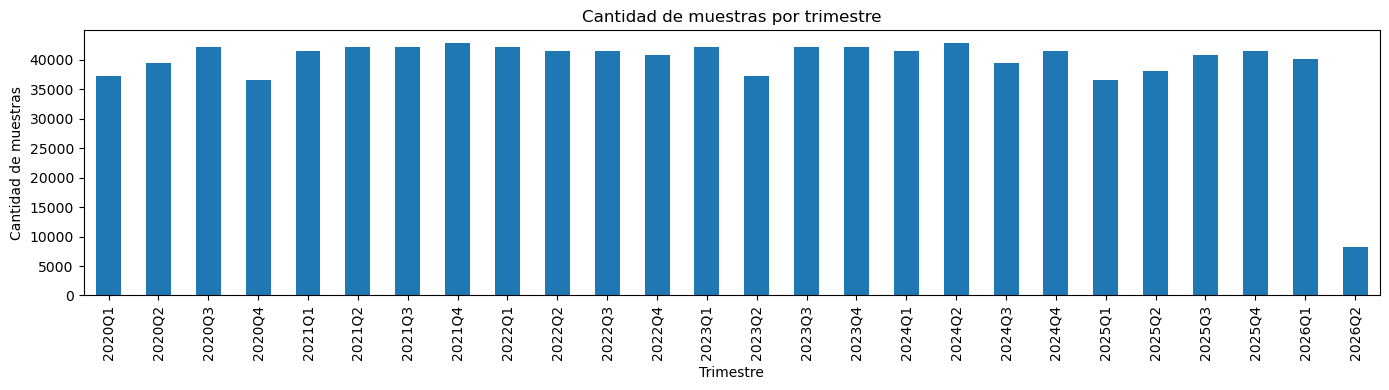

In [14]:
# Gráfico: cantidad de muestras por trimestre
# ============================================================

ax = df_samples_by_quarter.plot(
    x="year_quarter",
    y="samples",
    kind="bar",
    figsize=(14, 4),
    legend=False,
)

ax.set_title("Cantidad de muestras por trimestre")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Cantidad de muestras")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observación:**
La cobertura trimestral muestra que todas las jornadas disponibles mantienen una estructura completa de `691` barras por día, con `coverage_ratio_vs_full_day = 1.0` en todos los trimestres. Sin embargo, la cantidad de jornadas varía entre trimestres, lo que genera diferencias en la cantidad total de muestras. En particular, `2026Q2` corresponde a un trimestre parcial, ya que el dataset finaliza el `17/04/2026`. También se observan trimestres con menor cantidad de jornadas, como `2025Q1`, `2025Q2` y `2023Q2`, por lo que conviene tenerlos presentes al analizar la representatividad temporal del dataset.

## 3.3 Cantidad de muestras por mes

En esta sección se analiza la cantidad de registros disponibles por mes dentro del dataset `mnq_intraday`.

El objetivo es observar la cobertura temporal con mayor detalle que en los análisis anual y trimestral. Esto permite identificar meses completos, meses parciales o períodos con menor representación dentro del dataset.

Este análisis es útil para detectar posibles concentraciones o faltantes de datos en períodos específicos. Además, permite evaluar si todos los meses disponibles mantienen una cantidad de barras consistente por jornada, lo cual es importante antes de realizar análisis de estabilidad temporal o definir esquemas de entrenamiento basados en ventanas históricas.


In [15]:
# 3.3 Cantidad de muestras por mes
# ============================================================
#
# Objetivo:
# Analizar cuántas muestras contiene el dataset por cada mes.
#
# Esto permite evaluar la cobertura temporal mensual e identificar
# meses parciales o períodos con menor representación.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Barras esperadas por jornada completa según el rango intradiario
expected_bars_per_full_day = (
    mnq_intraday["minute_of_day"].max()
    - mnq_intraday["minute_of_day"].min()
    + 1
)

# DataFrame auxiliar liviano para cobertura mensual
df_month_aux = pd.DataFrame({
    "year": mnq_intraday.index.year,
    "month": mnq_intraday.index.month,
    "year_month": mnq_intraday.index.strftime("%Y-%m"),
    "datetime": mnq_intraday.index,
    "date": mnq_intraday["date"].values,
})

# Resumen de muestras por mes
df_samples_by_month = (
    df_month_aux
    .groupby(["year", "month", "year_month"], sort=True)
    .agg(
        samples=("year_month", "size"),
        trading_days=("date", "nunique"),
        first_datetime=("datetime", "first"),
        last_datetime=("datetime", "last"),
    )
    .reset_index()
)

# Métricas adicionales
df_samples_by_month["avg_bars_per_day"] = (
    df_samples_by_month["samples"]
    / df_samples_by_month["trading_days"]
)

df_samples_by_month["expected_bars_per_full_day"] = expected_bars_per_full_day

df_samples_by_month["coverage_ratio_vs_full_day"] = (
    df_samples_by_month["avg_bars_per_day"]
    / df_samples_by_month["expected_bars_per_full_day"]
)

df_samples_by_month["samples_pct_total"] = (
    df_samples_by_month["samples"]
    / df_samples_by_month["samples"].sum()
    * 100
)

print("Cantidad de muestras por mes")
display(df_samples_by_month)

Cantidad de muestras por mes


,year,month,year_month,samples,trading_days,first_datetime,last_datetime,avg_bars_per_day,expected_bars_per_full_day,coverage_ratio_vs_full_day,samples_pct_total
0,2020,1,2020-01,14511,21,2020-01-02 04:30:00-05:00,2020-01-31 16:00:00-05:00,691.0,691,1.0,1.417004
1,2020,2,2020-02,13129,19,2020-02-03 04:30:00-05:00,2020-02-28 16:00:00-05:00,691.0,691,1.0,1.282051
2,2020,3,2020-03,9674,14,2020-03-02 04:30:00-05:00,2020-03-31 16:00:00-04:00,691.0,691,1.0,0.944669
3,2020,4,2020-04,13820,20,2020-04-01 04:30:00-04:00,2020-04-30 16:00:00-04:00,691.0,691,1.0,1.349528
4,2020,5,2020-05,13820,20,2020-05-01 04:30:00-04:00,2020-05-29 16:00:00-04:00,691.0,691,1.0,1.349528
...,...,...,...,...,...,...,...,...,...,...,...
71,2025,12,2025-12,13129,19,2025-12-01 04:30:00-05:00,2025-12-31 16:00:00-05:00,691.0,691,1.0,1.282051
72,2026,1,2026-01,13129,19,2026-01-02 04:30:00-05:00,2026-01-30 16:00:00-05:00,691.0,691,1.0,1.282051
73,2026,2,2026-02,13129,19,2026-02-02 04:30:00-05:00,2026-02-27 16:00:00-05:00,691.0,691,1.0,1.282051
74,2026,3,2026-03,13820,20,2026-03-02 04:30:00-05:00,2026-03-31 16:00:00-04:00,691.0,691,1.0,1.349528


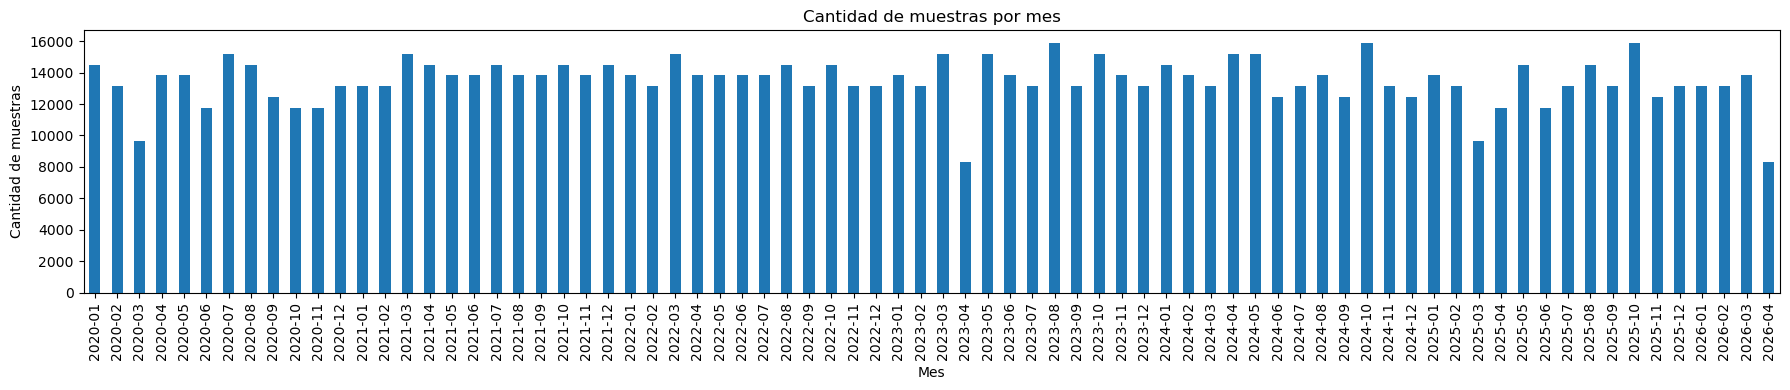

In [16]:
# ============================================================
# Gráfico: cantidad de muestras por mes
# ============================================================

ax = df_samples_by_month.plot(
    x="year_month",
    y="samples",
    kind="bar",
    figsize=(18, 4),
    legend=False,
)

ax.set_title("Cantidad de muestras por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de muestras")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observación:**
La cobertura mensual confirma que las jornadas disponibles mantienen una estructura completa de `691` barras por día, con `coverage_ratio_vs_full_day = 1.0` en todos los meses analizados. Las diferencias en la cantidad total de muestras se explican principalmente por la cantidad de jornadas presentes en cada mes. Se observan algunos meses con menor cantidad de registros, como `2020-03`, `2023-04` y `2026-04`; este último corresponde a un mes parcial, ya que el dataset finaliza el `17/04/2026`. En términos generales, la cobertura intradiaria es consistente, aunque conviene tener presentes los meses con menor representación al realizar análisis temporales o definir ventanas de entrenamiento.

## 3.4 Cantidad de trading days por año

En esta sección se analiza la cantidad de jornadas disponibles por año dentro del dataset `mnq_intraday`.

A diferencia del análisis de muestras, que mide la cantidad total de registros minuto a minuto, este análisis permite observar cuántos días efectivos de mercado contiene cada año. Esto es importante porque dos años pueden tener jornadas completas, pero distinta cantidad de días disponibles.

Esta información ayuda a evaluar la representatividad temporal de cada año y permite identificar años parciales o períodos con menor cobertura, lo cual puede impactar en el peso relativo de cada período durante el entrenamiento del modelo.


In [17]:
# 3.4 Cantidad de trading days por año
# ============================================================
#
# Objetivo:
# Analizar cuántas jornadas de trading contiene el dataset
# por cada año.
#
# Esto permite evaluar la representatividad temporal anual
# más allá de la cantidad total de muestras.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# DataFrame auxiliar liviano
df_days_aux = pd.DataFrame({
    "year": mnq_intraday.index.year,
    "date": mnq_intraday["date"].values,
})

# Cantidad de trading days por año
df_trading_days_by_year = (
    df_days_aux
    .drop_duplicates(["year", "date"])
    .groupby("year", sort=True)
    .agg(
        trading_days=("date", "count"),
        first_day=("date", "min"),
        last_day=("date", "max"),
    )
    .reset_index()
)

# Participación relativa de cada año en el total de jornadas
df_trading_days_by_year["trading_days_pct_total"] = (
    df_trading_days_by_year["trading_days"]
    / df_trading_days_by_year["trading_days"].sum()
    * 100
)

print("Cantidad de trading days por año")
display(df_trading_days_by_year)


Cantidad de trading days por año


,year,trading_days,first_day,last_day,trading_days_pct_total
0,2020,225,2020-01-02,2020-12-31,15.182186
1,2021,244,2021-01-04,2021-12-31,16.464238
2,2022,240,2022-01-03,2022-12-30,16.194332
3,2023,237,2023-01-03,2023-12-29,15.991903
4,2024,239,2024-01-02,2024-12-31,16.126856
5,2025,227,2025-01-02,2025-12-31,15.317139
6,2026,70,2026-01-02,2026-04-17,4.723347


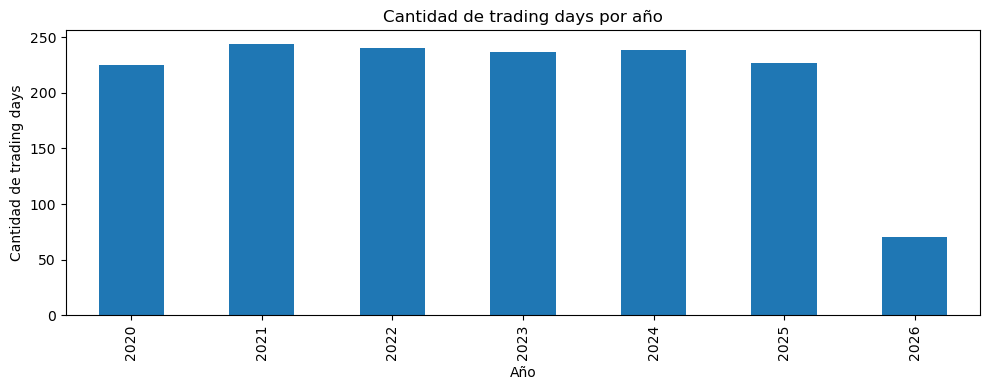

In [18]:
# Gráfico: cantidad de trading days por año
# ============================================================

ax = df_trading_days_by_year.plot(
    x="year",
    y="trading_days",
    kind="bar",
    figsize=(10, 4),
    legend=False,
)

ax.set_title("Cantidad de trading days por año")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de trading days")

plt.tight_layout()
plt.show()

**Observación:**
La cantidad de trading days por año confirma que el dataset tiene una cobertura anual relativamente consistente entre `2020` y `2025`, aunque no idéntica. Los años completos presentan entre `225` y `244` jornadas disponibles, mientras que `2026` contiene solo `70` jornadas debido a que corresponde a un período parcial con datos hasta el `17/04/2026`.

Dado que todas las jornadas disponibles tienen `691` barras, el porcentaje de trading days por año coincide directamente con el porcentaje de muestras del dataset. Por lo tanto, las diferencias de representatividad anual se explican por la cantidad de jornadas presentes en cada año, no por jornadas incompletas.

## 3.5 Cantidad de trading days por contrato

En esta sección se analiza la cantidad de muestras y jornadas disponibles por contrato dentro del dataset `mnq_intraday`.

Dado que el dataset corresponde a una serie continua construida a partir de contratos trimestrales del MNQ, es importante identificar qué período aporta cada contrato y cuántos días efectivos contiene. Esto permite evaluar si el rolling de contratos genera períodos desbalanceados, contratos parciales o posibles zonas sensibles para el análisis posterior.

Este análisis es relevante porque los cambios de contrato pueden introducir variaciones en volumen, liquidez o comportamiento del precio, especialmente cerca de las fechas de vencimiento o empalme. Por lo tanto, conocer la cobertura por contrato ayuda a interpretar mejor la estructura temporal del dataset antes de avanzar hacia métricas OHLCV, targets o entrenamiento de modelos.

In [19]:
# 3.5 Cantidad de trading days por contrato
# ============================================================
#
# Objetivo:
# Analizar cuántas muestras y jornadas de trading aporta cada
# contrato dentro del dataset continuo.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Validar existencia de columna contract
if "contract" not in mnq_intraday.columns:
    raise ValueError("No existe la columna 'contract' en mnq_intraday.")

# Validar contratos faltantes
missing_contracts = mnq_intraday["contract"].isna().sum()

if missing_contracts > 0:
    raise ValueError(
        f"Existen {missing_contracts:,} filas sin contrato asignado."
    )

# Barras esperadas por jornada completa según el rango intradiario
expected_bars_per_full_day = (
    mnq_intraday["minute_of_day"].max()
    - mnq_intraday["minute_of_day"].min()
    + 1
)

# DataFrame auxiliar liviano
df_contract_aux = pd.DataFrame({
    "contract": mnq_intraday["contract"].values,
    "datetime": mnq_intraday.index,
    "date": mnq_intraday["date"].values,
})

# Resumen por contrato
df_trading_days_by_contract = (
    df_contract_aux
    .groupby("contract", sort=False)
    .agg(
        samples=("contract", "size"),
        trading_days=("date", "nunique"),
        first_datetime=("datetime", "first"),
        last_datetime=("datetime", "last"),
        first_day=("date", "first"),
        last_day=("date", "last"),
    )
    .reset_index()
)

# Métricas adicionales
df_trading_days_by_contract["avg_bars_per_day"] = (
    df_trading_days_by_contract["samples"]
    / df_trading_days_by_contract["trading_days"]
)

df_trading_days_by_contract["expected_bars_per_full_day"] = (
    expected_bars_per_full_day
)

df_trading_days_by_contract["coverage_ratio_vs_full_day"] = (
    df_trading_days_by_contract["avg_bars_per_day"]
    / df_trading_days_by_contract["expected_bars_per_full_day"]
)

df_trading_days_by_contract["samples_pct_total"] = (
    df_trading_days_by_contract["samples"]
    / df_trading_days_by_contract["samples"].sum()
    * 100
)

df_trading_days_by_contract["trading_days_pct_total"] = (
    df_trading_days_by_contract["trading_days"]
    / df_trading_days_by_contract["trading_days"].sum()
    * 100
)

print("Cantidad de trading days por contrato")
display(df_trading_days_by_contract)

Cantidad de trading days por contrato


,contract,samples,trading_days,first_datetime,last_datetime,first_day,last_day,avg_bars_per_day,expected_bars_per_full_day,coverage_ratio_vs_full_day,samples_pct_total,trading_days_pct_total
0,H20,33168,48,2020-01-02 04:30:00-05:00,2020-03-19 16:00:00-04:00,2020-01-02,2020-03-19,691.0,691,1.0,3.238866,3.238866
1,M20,38696,56,2020-03-23 04:30:00-04:00,2020-06-15 16:00:00-04:00,2020-03-23,2020-06-15,691.0,691,1.0,3.778677,3.778677
2,U20,42151,61,2020-06-22 04:30:00-04:00,2020-09-16 16:00:00-04:00,2020-06-22,2020-09-16,691.0,691,1.0,4.116059,4.116059
3,Z20,36623,53,2020-09-21 04:30:00-04:00,2020-12-16 16:00:00-05:00,2020-09-21,2020-12-16,691.0,691,1.0,3.576248,3.576248
4,H21,40769,59,2020-12-21 04:30:00-05:00,2021-03-18 16:00:00-04:00,2020-12-21,2021-03-18,691.0,691,1.0,3.981107,3.981107
5,M21,42151,61,2021-03-22 04:30:00-04:00,2021-06-17 16:00:00-04:00,2021-03-22,2021-06-17,691.0,691,1.0,4.116059,4.116059
6,U21,41460,60,2021-06-21 04:30:00-04:00,2021-09-16 16:00:00-04:00,2021-06-21,2021-09-16,691.0,691,1.0,4.048583,4.048583
7,Z21,42842,62,2021-09-20 04:30:00-04:00,2021-12-16 16:00:00-05:00,2021-09-20,2021-12-16,691.0,691,1.0,4.183536,4.183536
8,H22,42151,61,2021-12-20 04:30:00-05:00,2022-03-17 16:00:00-04:00,2021-12-20,2022-03-17,691.0,691,1.0,4.116059,4.116059
9,M22,42151,61,2022-03-21 04:30:00-04:00,2022-06-16 16:00:00-04:00,2022-03-21,2022-06-16,691.0,691,1.0,4.116059,4.116059


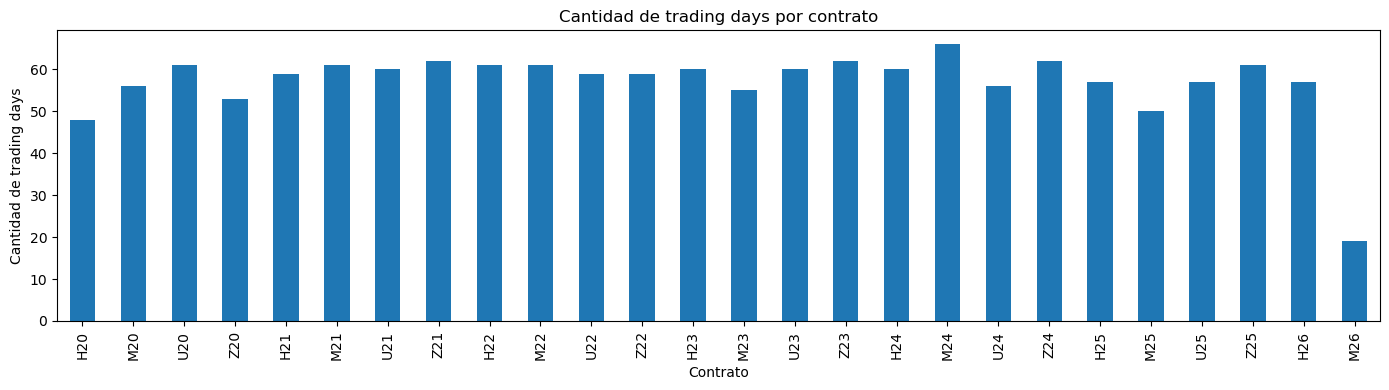

In [20]:
# Gráfico: cantidad de trading days por contrato
# ============================================================

ax = df_trading_days_by_contract.plot(
    x="contract",
    y="trading_days",
    kind="bar",
    figsize=(14, 4),
    legend=False,
)

ax.set_title("Cantidad de trading days por contrato")
ax.set_xlabel("Contrato")
ax.set_ylabel("Cantidad de trading days")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observación:**
La cobertura por contrato muestra que cada contrato mantiene una estructura intradiaria completa de `691` barras por jornada, con `coverage_ratio_vs_full_day = 1.0` en todos los casos. Esto confirma que, una vez aplicado el rolling y filtrado el rango intradiario, no existen jornadas incompletas dentro de cada contrato.

La mayoría de los contratos aporta entre `50` y `66` trading days, por lo que la cobertura por contrato es relativamente balanceada. Las principales excepciones son `H20`, que aparece parcialmente por el inicio del dataset en `2020`, y `M26`, que es claramente parcial porque el dataset finaliza el `17/04/2026`.

Este análisis es importante porque permite identificar qué contratos tienen menor representación y qué períodos podrían tener menor peso durante el entrenamiento o en análisis posteriores de estabilidad temporal.


## 3.6 Conclusión de cobertura temporal

El análisis de cobertura temporal muestra que el dataset `mnq_intraday` presenta una estructura intradiaria consistente en todos los períodos disponibles. Cada jornada contiene `691` barras, correspondientes al rango horario entre `04:30` y `16:00`, por lo que no se observan jornadas incompletas dentro del dataset validado.

Las diferencias en la cantidad de muestras por año, trimestre, mes o contrato se explican principalmente por la cantidad de jornadas disponibles en cada período, no por faltantes intradiarios. Entre `2020` y `2025`, la cobertura anual es relativamente homogénea, mientras que `2026` debe considerarse un período parcial, ya que el dataset finaliza el `17/04/2026`.

El análisis por contrato confirma que la serie continua conserva una cobertura consistente luego del rolling. La mayoría de los contratos aporta entre `50` y `66` trading days, con jornadas completas de `691` barras. Las principales excepciones son `H20`, afectado por el inicio del dataset, y `M26`, que corresponde a un contrato parcial por el corte final de datos.

En conclusión, la cobertura temporal del dataset es adecuada para continuar con el análisis intradiario. Sin embargo, esta validación solo confirma la consistencia y representatividad temporal de los datos; no implica que el comportamiento del mercado sea estable entre años, trimestres, meses o contratos. Esa estabilidad deberá analizarse posteriormente mediante métricas OHLCV, regímenes intradiarios, volatilidad, volumen y cambios estructurales.


# **4. Análisis de regímenes intradiarios**


En esta sección se analiza la distribución del dataset según los regímenes intradiarios definidos en la columna `regime_id`.

El objetivo es entender cómo se reparte la información dentro de cada segmento horario del mercado, considerando que el comportamiento intradiario no es homogéneo. Períodos como `Opening`, `Regular`, `Closing`, `Pre-market` y `Overnight` pueden presentar diferencias importantes en volumen, volatilidad, rango de precios y dinámica del movimiento.

Antes de analizar métricas OHLCV más avanzadas, es necesario verificar cuántas muestras aporta cada régimen, si la distribución es estable a lo largo de los años y si existen regímenes con mayor o menor representación dentro del dataset.

Este análisis es importante porque, en etapas posteriores, el régimen intradiario podría utilizarse como variable explicativa, criterio de segmentación o incluso como base para entrenar modelos separados por contexto horario.

4. Análisis de regímenes intradiarios

   4.1 Distribución general de muestras por régimen

   4.2 Distribución de regímenes por año

   4.3 Distribución de regímenes por trimestre

   4.4 Distribución de regímenes por contrato
   
   4.5 Conclusión del análisis de regímenes intradiarios


In [21]:
# 4.0 Definición de nombres de regímenes intradiarios
# ============================================================

REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

# Crear copia auxiliar para análisis de regímenes
df_regimes = mnq_intraday.copy()

# Agregar nombre del régimen
df_regimes["regime_name"] = df_regimes["regime_id"].map(REGIME_NAMES)

# Validar que todos los regime_id tengan nombre asignado
missing_regime_names = df_regimes["regime_name"].isna().sum()

if missing_regime_names > 0:
    raise ValueError(
        f"Existen {missing_regime_names:,} filas con regime_id sin nombre asignado."
    )

#print("Vista previa con nombres de régimen")
#display(df_regimes[["date", "minute_of_day", "regime_id", "regime_name", "contract"]].head())

## 4.1 Distribución general de muestras por régimen


En esta sección se analiza la cantidad de muestras disponibles en cada régimen intradiario.

El objetivo es verificar qué proporción del dataset corresponde a cada segmento horario del mercado. Esta distribución es importante porque, si algunos regímenes tienen muchas más muestras que otros, el modelo podría quedar más influenciado por esos períodos durante el entrenamiento.

Además, este análisis permite confirmar si cada régimen aparece de forma consistente a lo largo de las jornadas disponibles y si existe algún régimen con menor representación relativa dentro del dataset.

In [22]:
# 4.1 Distribución general de muestras por régimen
# ============================================================
#
# Objetivo:
# Analizar cuántas muestras aporta cada régimen intradiario
# dentro del dataset mnq_intraday.
#
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Validar existencia de regime_id
if "regime_id" not in mnq_intraday.columns:
    raise ValueError("No existe la columna 'regime_id' en mnq_intraday.")

# Nombres de regímenes intradiarios
REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

# DataFrame auxiliar liviano
df_regime_aux = pd.DataFrame({
    "date": mnq_intraday["date"].values,
    "minute_of_day": mnq_intraday["minute_of_day"].values,
    "regime_id": mnq_intraday["regime_id"].values,
})

# Agregar nombre del régimen
df_regime_aux["regime_name"] = df_regime_aux["regime_id"].map(REGIME_NAMES)

# Validar que todos los regime_id tengan nombre asignado
missing_regime_names = df_regime_aux["regime_name"].isna().sum()

if missing_regime_names > 0:
    raise ValueError(
        f"Existen {missing_regime_names:,} filas con regime_id sin nombre asignado."
    )

# Función auxiliar para convertir minute_of_day a HH:MM
def minute_to_hhmm(minute):
    hour = int(minute) // 60
    minute = int(minute) % 60
    return f"{hour:02d}:{minute:02d}"

# Resumen general por régimen
df_samples_by_regime = (
    df_regime_aux
    .groupby(["regime_id", "regime_name"], sort=True)
    .agg(
        samples=("regime_id", "size"),
        trading_days=("date", "nunique"),
        unique_minutes=("minute_of_day", "nunique"),
        first_minute_of_day=("minute_of_day", "min"),
        last_minute_of_day=("minute_of_day", "max"),
    )
    .reset_index()
)

# Métricas adicionales
df_samples_by_regime["avg_bars_per_day"] = (
    df_samples_by_regime["samples"]
    / df_samples_by_regime["trading_days"]
)

df_samples_by_regime["samples_pct_total"] = (
    df_samples_by_regime["samples"]
    / df_samples_by_regime["samples"].sum()
    * 100
)

# Horarios legibles
df_samples_by_regime["first_time"] = (
    df_samples_by_regime["first_minute_of_day"]
    .apply(minute_to_hhmm)
)

df_samples_by_regime["last_time"] = (
    df_samples_by_regime["last_minute_of_day"]
    .apply(minute_to_hhmm)
)

# Reordenar columnas
df_samples_by_regime = df_samples_by_regime[
    [
        "regime_id",
        "regime_name",
        "samples",
        "samples_pct_total",
        "trading_days",
        "unique_minutes",
        "avg_bars_per_day",
        "first_time",
        "last_time",
    ]
]

display(Markdown("### Distribución general de muestras por régimen"))
display(df_samples_by_regime)

### Distribución general de muestras por régimen

,regime_id,regime_name,samples,samples_pct_total,trading_days,unique_minutes,avg_bars_per_day,first_time,last_time
0,0,Overnight,357162,34.876990,1482,241,241.0,04:30,16:00
1,1,Pre-market,88920,8.683068,1482,60,60.0,08:30,09:29
2,2,Opening,88920,8.683068,1482,60,60.0,09:30,10:29
3,3,Regular,444600,43.415340,1482,300,300.0,10:30,15:29
4,4,Closing,44460,4.341534,1482,30,30.0,15:30,15:59


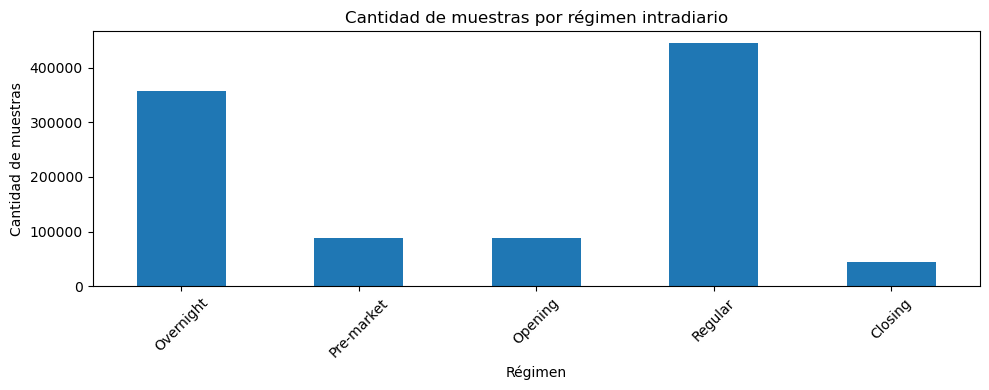

In [23]:
# Gráfico: distribución de muestras por régimen
# ============================================================

ax = df_samples_by_regime.plot(
    x="regime_name",
    y="samples",
    kind="bar",
    figsize=(10, 4),
    legend=False,
)

ax.set_title("Cantidad de muestras por régimen intradiario")
ax.set_xlabel("Régimen")
ax.set_ylabel("Cantidad de muestras")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observación:**
La distribución por régimen intradiario muestra que todos los regímenes están presentes en las `1482` jornadas del dataset. La cantidad de muestras por régimen es proporcional a la duración de cada segmento horario: `Regular` concentra la mayor cantidad de datos con `300` barras por día, seguido por `Overnight` con `241` barras por día, `Pre-market` y `Opening` con `60` barras cada uno, y `Closing` con `30` barras.

Se observa que el régimen `Overnight` incluye la barra de `16:00`, además del rango inicial desde `04:30`. Esto debe tenerse en cuenta, ya que esa barra representa el cierre final de la jornada y podría analizarse si conviene mantenerla dentro de `Overnight` o reasignarla a otro régimen, dependiendo de la definición operativa que se quiera utilizar.


## 4.2 Distribución de regímenes por año


En esta sección se analiza cómo se distribuyen los regímenes intradiarios en cada año del dataset.

El objetivo es verificar si la estructura horaria del dataset se mantiene estable entre años. Esto permite confirmar si cada régimen conserva una proporción similar de muestras anuales o si existen años con diferencias relevantes en la representación de algún segmento intradiario.

Este análisis es importante porque, si la distribución de regímenes cambia entre años, el modelo podría recibir una composición distinta de contextos intradiarios durante el entrenamiento y la validación. Por el contrario, una distribución estable indicaría que las diferencias entre años deberían explicarse más por cambios de comportamiento OHLCV que por diferencias de cobertura horaria.


In [24]:
# 4.2 Distribución de regímenes por año
# ============================================================
#
# Objetivo:
# Analizar cómo se distribuyen las muestras de cada régimen
# intradiario por año.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Validar existencia de regime_id
if "regime_id" not in mnq_intraday.columns:
    raise ValueError("No existe la columna 'regime_id' en mnq_intraday.")

# Nombres de regímenes intradiarios
REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

# DataFrame auxiliar liviano
df_year_regime_aux = pd.DataFrame({
    "year": mnq_intraday.index.year,
    "date": mnq_intraday["date"].values,
    "regime_id": mnq_intraday["regime_id"].values,
})

# Agregar nombre del régimen
df_year_regime_aux["regime_name"] = (
    df_year_regime_aux["regime_id"].map(REGIME_NAMES)
)

# Validar que todos los regime_id tengan nombre asignado
missing_regime_names = df_year_regime_aux["regime_name"].isna().sum()

if missing_regime_names > 0:
    raise ValueError(
        f"Existen {missing_regime_names:,} filas con regime_id sin nombre asignado."
    )

# Resumen por año y régimen
df_regime_by_year = (
    df_year_regime_aux
    .groupby(["year", "regime_id", "regime_name"], sort=True)
    .agg(
        samples=("regime_id", "size"),
        trading_days=("date", "nunique"),
    )
    .reset_index()
)

# Barras promedio por día para cada régimen dentro de cada año
df_regime_by_year["avg_bars_per_day"] = (
    df_regime_by_year["samples"]
    / df_regime_by_year["trading_days"]
)

# Total de muestras por año
year_totals = (
    df_regime_by_year
    .groupby("year")["samples"]
    .transform("sum")
)

# Porcentaje de cada régimen dentro de cada año
df_regime_by_year["samples_pct_year"] = (
    df_regime_by_year["samples"]
    / year_totals
    * 100
)

print("Distribución de regímenes por año")
display(df_regime_by_year)

Distribución de regímenes por año


,year,regime_id,regime_name,samples,trading_days,avg_bars_per_day,samples_pct_year
0,2020,0,Overnight,54225,225,241.0,34.876990
1,2020,1,Pre-market,13500,225,60.0,8.683068
2,2020,2,Opening,13500,225,60.0,8.683068
3,2020,3,Regular,67500,225,300.0,43.415340
4,2020,4,Closing,6750,225,30.0,4.341534
5,2021,0,Overnight,58804,244,241.0,34.876990
6,2021,1,Pre-market,14640,244,60.0,8.683068
7,2021,2,Opening,14640,244,60.0,8.683068
8,2021,3,Regular,73200,244,300.0,43.415340
9,2021,4,Closing,7320,244,30.0,4.341534


In [25]:
# Tabla pivot: porcentaje de cada régimen por año
# ============================================================

regime_order = ["Overnight", "Pre-market", "Opening", "Regular", "Closing"]

df_regime_by_year_pct_pivot = (
    df_regime_by_year
    .pivot(
        index="year",
        columns="regime_name",
        values="samples_pct_year"
    )
    .reindex(columns=regime_order)
)

print("Porcentaje de muestras por régimen dentro de cada año")
display(df_regime_by_year_pct_pivot)

Porcentaje de muestras por régimen dentro de cada año


regime_name,Overnight,Pre-market,Opening,Regular,Closing
year,,,,,
2020,34.87699,8.683068,8.683068,43.41534,4.341534
2021,34.87699,8.683068,8.683068,43.41534,4.341534
2022,34.87699,8.683068,8.683068,43.41534,4.341534
2023,34.87699,8.683068,8.683068,43.41534,4.341534
2024,34.87699,8.683068,8.683068,43.41534,4.341534
2025,34.87699,8.683068,8.683068,43.41534,4.341534
2026,34.87699,8.683068,8.683068,43.41534,4.341534


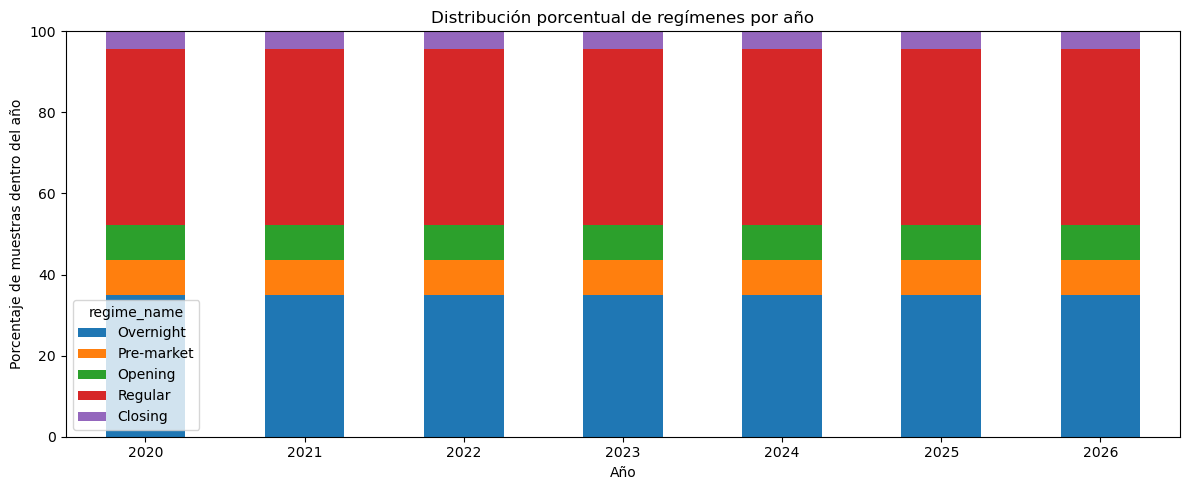

In [26]:
# Gráfico: distribución porcentual de regímenes por año
# ============================================================

ax = df_regime_by_year_pct_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
)

ax.set_title("Distribución porcentual de regímenes por año")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje de muestras dentro del año")

plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Observación:**
La distribución porcentual de los regímenes intradiarios se mantiene constante en todos los años analizados. Cada año conserva la misma proporción de muestras por régimen: `Regular` representa aproximadamente el `43.42%` del dataset anual, `Overnight` el `34.88%`, `Pre-market` y `Opening` el `8.68%` cada uno, y `Closing` el `4.34%`.

Esto confirma que las diferencias entre años no se deben a cambios en la composición horaria del dataset, sino que deberán explicarse posteriormente a partir del comportamiento propio del mercado, como volatilidad, volumen, rangos de precio o retornos. Por lo tanto, desde el punto de vista de cobertura intradiaria, los años son comparables entre sí, incluso considerando que `2026` es un período parcial.

## 4.3 Distribución de regímenes por trimestre

En esta sección se analiza cómo se distribuyen los regímenes intradiarios en cada trimestre del dataset.

El objetivo es verificar si la estructura horaria se mantiene estable con mayor granularidad temporal que en el análisis anual. Esto permite confirmar si cada trimestre conserva una proporción similar de muestras por régimen o si existen períodos con cambios en la composición intradiaria.

Este análisis es importante porque, si la distribución de regímenes se mantiene estable entre trimestres, las diferencias observadas posteriormente en volatilidad, volumen o rangos de precio podrán atribuirse al comportamiento del mercado y no a cambios en la cobertura horaria del dataset.

In [27]:
# 4.3 Distribución de regímenes por trimestre
# ============================================================
#
# Objetivo:
# Analizar cómo se distribuyen las muestras de cada régimen
# intradiario por trimestre.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Validar existencia de regime_id
if "regime_id" not in mnq_intraday.columns:
    raise ValueError("No existe la columna 'regime_id' en mnq_intraday.")

# Nombres de regímenes intradiarios
REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

# DataFrame auxiliar liviano
df_quarter_regime_aux = pd.DataFrame({
    "year": mnq_intraday.index.year,
    "quarter": mnq_intraday.index.quarter,
    "date": mnq_intraday["date"].values,
    "regime_id": mnq_intraday["regime_id"].values,
})

# Crear etiqueta año-trimestre
df_quarter_regime_aux["year_quarter"] = (
    df_quarter_regime_aux["year"].astype(str)
    + "Q"
    + df_quarter_regime_aux["quarter"].astype(str)
)

# Agregar nombre del régimen
df_quarter_regime_aux["regime_name"] = (
    df_quarter_regime_aux["regime_id"].map(REGIME_NAMES)
)

# Validar que todos los regime_id tengan nombre asignado
missing_regime_names = df_quarter_regime_aux["regime_name"].isna().sum()

if missing_regime_names > 0:
    raise ValueError(
        f"Existen {missing_regime_names:,} filas con regime_id sin nombre asignado."
    )

# Resumen por trimestre y régimen
df_regime_by_quarter = (
    df_quarter_regime_aux
    .groupby(["year", "quarter", "year_quarter", "regime_id", "regime_name"], sort=True)
    .agg(
        samples=("regime_id", "size"),
        trading_days=("date", "nunique"),
    )
    .reset_index()
)

# Barras promedio por día para cada régimen dentro de cada trimestre
df_regime_by_quarter["avg_bars_per_day"] = (
    df_regime_by_quarter["samples"]
    / df_regime_by_quarter["trading_days"]
)

# Total de muestras por trimestre
quarter_totals = (
    df_regime_by_quarter
    .groupby("year_quarter")["samples"]
    .transform("sum")
)

# Porcentaje de cada régimen dentro de cada trimestre
df_regime_by_quarter["samples_pct_quarter"] = (
    df_regime_by_quarter["samples"]
    / quarter_totals
    * 100
)

print("Distribución de regímenes por trimestre")
display(df_regime_by_quarter)

Distribución de regímenes por trimestre


,year,quarter,year_quarter,regime_id,regime_name,samples,trading_days,avg_bars_per_day,samples_pct_quarter
0,2020,1,2020Q1,0,Overnight,13014,54,241.0,34.876990
1,2020,1,2020Q1,1,Pre-market,3240,54,60.0,8.683068
2,2020,1,2020Q1,2,Opening,3240,54,60.0,8.683068
3,2020,1,2020Q1,3,Regular,16200,54,300.0,43.415340
4,2020,1,2020Q1,4,Closing,1620,54,30.0,4.341534
...,...,...,...,...,...,...,...,...,...
125,2026,2,2026Q2,0,Overnight,2892,12,241.0,34.876990
126,2026,2,2026Q2,1,Pre-market,720,12,60.0,8.683068
127,2026,2,2026Q2,2,Opening,720,12,60.0,8.683068
128,2026,2,2026Q2,3,Regular,3600,12,300.0,43.415340


In [28]:
# Tabla pivot: porcentaje de cada régimen por trimestre
# ============================================================

regime_order = ["Overnight", "Pre-market", "Opening", "Regular", "Closing"]

df_regime_by_quarter_pct_pivot = (
    df_regime_by_quarter
    .pivot(
        index="year_quarter",
        columns="regime_name",
        values="samples_pct_quarter"
    )
    .reindex(columns=regime_order)
)

print("Porcentaje de muestras por régimen dentro de cada trimestre")
display(df_regime_by_quarter_pct_pivot)

Porcentaje de muestras por régimen dentro de cada trimestre


regime_name,Overnight,Pre-market,Opening,Regular,Closing
year_quarter,,,,,
2020Q1,34.87699,8.683068,8.683068,43.41534,4.341534
2020Q2,34.87699,8.683068,8.683068,43.41534,4.341534
2020Q3,34.87699,8.683068,8.683068,43.41534,4.341534
2020Q4,34.87699,8.683068,8.683068,43.41534,4.341534
2021Q1,34.87699,8.683068,8.683068,43.41534,4.341534
2021Q2,34.87699,8.683068,8.683068,43.41534,4.341534
2021Q3,34.87699,8.683068,8.683068,43.41534,4.341534
2021Q4,34.87699,8.683068,8.683068,43.41534,4.341534
2022Q1,34.87699,8.683068,8.683068,43.41534,4.341534


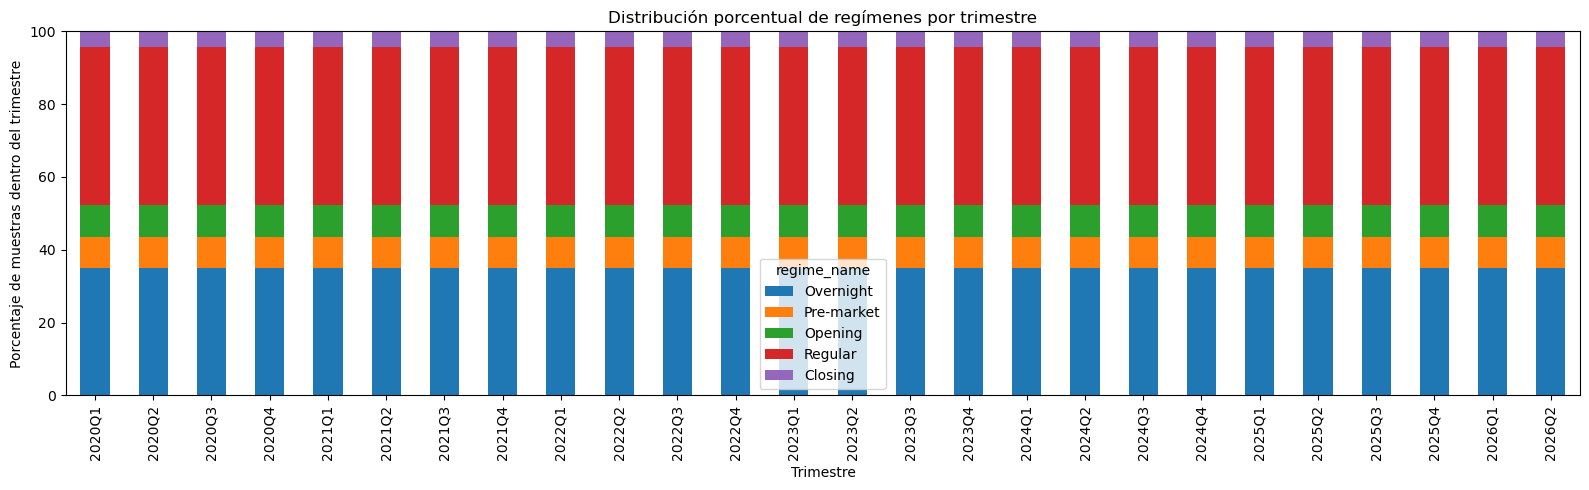

In [29]:
# Gráfico: distribución porcentual de regímenes por trimestre
# ============================================================

ax = df_regime_by_quarter_pct_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 5),
)

ax.set_title("Distribución porcentual de regímenes por trimestre")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Porcentaje de muestras dentro del trimestre")

plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Observación:**
La distribución porcentual de los regímenes intradiarios se mantiene constante en todos los trimestres analizados. Cada trimestre conserva la misma proporción de muestras por régimen: `Regular` representa aproximadamente el `43.42%`, `Overnight` el `34.88%`, `Pre-market` y `Opening` el `8.68%` cada uno, y `Closing` el `4.34%`.

Esto confirma que la composición intradiaria del dataset es estable no solo a nivel anual, sino también trimestral. Por lo tanto, las diferencias que puedan observarse posteriormente entre trimestres no estarán asociadas a cambios en la cobertura horaria, sino al comportamiento propio del mercado, como volatilidad, volumen, rango de precios o retornos.

Incluso en trimestres parciales, como `2026Q2`, la proporción de regímenes se mantiene constante debido a que las jornadas disponibles conservan la estructura completa de `691` barras.

## 4.4 Distribución de regímenes por contrato


En esta sección se analiza cómo se distribuyen los regímenes intradiarios dentro de cada contrato del dataset continuo.

El objetivo es verificar si cada contrato conserva la misma estructura horaria interna o si existen diferencias de cobertura entre contratos. Esto es relevante porque el dataset fue construido a partir de contratos trimestrales, por lo que conviene confirmar que el rolling no haya generado desbalances en algún régimen específico.

Si la proporción de regímenes se mantiene constante entre contratos, las diferencias que se observen posteriormente en volumen, volatilidad o comportamiento del precio podrán atribuirse al comportamiento propio de cada contrato o período de mercado, y no a diferencias en la composición intradiaria de los datos.

In [30]:
# 4.4 Distribución de regímenes por contrato
# ============================================================
#
# Objetivo:
# Analizar cómo se distribuyen las muestras de cada régimen
# intradiario dentro de cada contrato.
#
# ============================================================

# Validar que el índice sea datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Validar existencia de columnas necesarias
if "regime_id" not in mnq_intraday.columns:
    raise ValueError("No existe la columna 'regime_id' en mnq_intraday.")

if "contract" not in mnq_intraday.columns:
    raise ValueError("No existe la columna 'contract' en mnq_intraday.")

# Nombres de regímenes intradiarios
REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

# DataFrame auxiliar liviano
df_contract_regime_aux = pd.DataFrame({
    "contract": mnq_intraday["contract"].values,
    "date": mnq_intraday["date"].values,
    "regime_id": mnq_intraday["regime_id"].values,
})

# Agregar nombre del régimen
df_contract_regime_aux["regime_name"] = (
    df_contract_regime_aux["regime_id"].map(REGIME_NAMES)
)

# Validar que todos los regime_id tengan nombre asignado
missing_regime_names = df_contract_regime_aux["regime_name"].isna().sum()

if missing_regime_names > 0:
    raise ValueError(
        f"Existen {missing_regime_names:,} filas con regime_id sin nombre asignado."
    )

# Mantener el orden cronológico de aparición de los contratos
contract_order = (
    df_contract_regime_aux["contract"]
    .drop_duplicates()
    .tolist()
)

# Resumen por contrato y régimen
df_regime_by_contract = (
    df_contract_regime_aux
    .groupby(["contract", "regime_id", "regime_name"], sort=False)
    .agg(
        samples=("regime_id", "size"),
        trading_days=("date", "nunique"),
    )
    .reset_index()
)

# Barras promedio por día para cada régimen dentro de cada contrato
df_regime_by_contract["avg_bars_per_day"] = (
    df_regime_by_contract["samples"]
    / df_regime_by_contract["trading_days"]
)

# Total de muestras por contrato
contract_totals = (
    df_regime_by_contract
    .groupby("contract")["samples"]
    .transform("sum")
)

# Porcentaje de cada régimen dentro de cada contrato
df_regime_by_contract["samples_pct_contract"] = (
    df_regime_by_contract["samples"]
    / contract_totals
    * 100
)

# Ordenar contratos cronológicamente
df_regime_by_contract["contract"] = pd.Categorical(
    df_regime_by_contract["contract"],
    categories=contract_order,
    ordered=True
)

df_regime_by_contract = (
    df_regime_by_contract
    .sort_values(["contract", "regime_id"])
    .reset_index(drop=True)
)

print("Distribución de regímenes por contrato")
display(df_regime_by_contract)

Distribución de regímenes por contrato


,contract,regime_id,regime_name,samples,trading_days,avg_bars_per_day,samples_pct_contract
0,H20,0,Overnight,11568,48,241.0,34.876990
1,H20,1,Pre-market,2880,48,60.0,8.683068
2,H20,2,Opening,2880,48,60.0,8.683068
3,H20,3,Regular,14400,48,300.0,43.415340
4,H20,4,Closing,1440,48,30.0,4.341534
...,...,...,...,...,...,...,...
125,M26,0,Overnight,4579,19,241.0,34.876990
126,M26,1,Pre-market,1140,19,60.0,8.683068
127,M26,2,Opening,1140,19,60.0,8.683068
128,M26,3,Regular,5700,19,300.0,43.415340


In [31]:
# Tabla pivot: porcentaje de cada régimen por contrato
# ============================================================

regime_order = ["Overnight", "Pre-market", "Opening", "Regular", "Closing"]

df_regime_by_contract_pct_pivot = (
    df_regime_by_contract
    .pivot(
        index="contract",
        columns="regime_name",
        values="samples_pct_contract"
    )
    .reindex(index=contract_order)
    .reindex(columns=regime_order)
)

print("Porcentaje de muestras por régimen dentro de cada contrato")
display(df_regime_by_contract_pct_pivot)

Porcentaje de muestras por régimen dentro de cada contrato


regime_name,Overnight,Pre-market,Opening,Regular,Closing
contract,,,,,
H20,34.87699,8.683068,8.683068,43.41534,4.341534
M20,34.87699,8.683068,8.683068,43.41534,4.341534
U20,34.87699,8.683068,8.683068,43.41534,4.341534
Z20,34.87699,8.683068,8.683068,43.41534,4.341534
H21,34.87699,8.683068,8.683068,43.41534,4.341534
M21,34.87699,8.683068,8.683068,43.41534,4.341534
U21,34.87699,8.683068,8.683068,43.41534,4.341534
Z21,34.87699,8.683068,8.683068,43.41534,4.341534
H22,34.87699,8.683068,8.683068,43.41534,4.341534


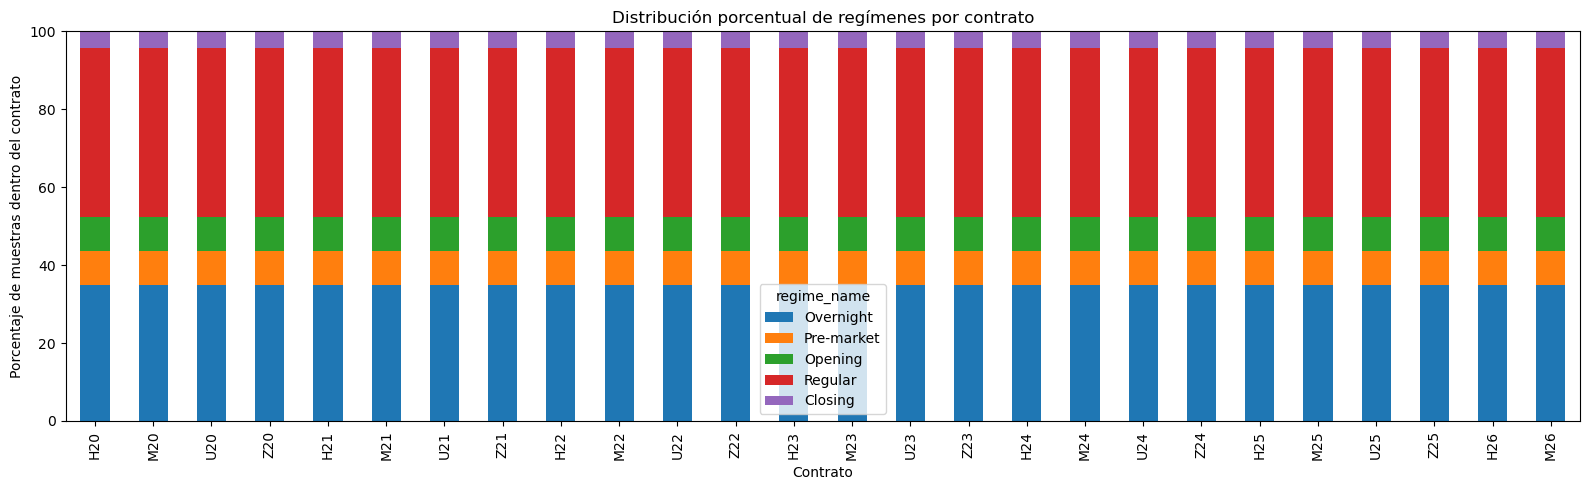

In [32]:
# Gráfico: distribución porcentual de regímenes por contrato
# ============================================================

ax = df_regime_by_contract_pct_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 5),
)

ax.set_title("Distribución porcentual de regímenes por contrato")
ax.set_xlabel("Contrato")
ax.set_ylabel("Porcentaje de muestras dentro del contrato")

plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Observación:**
La distribución porcentual de los regímenes intradiarios se mantiene constante en todos los contratos analizados. Cada contrato conserva la misma estructura horaria interna: `Regular` representa aproximadamente el `43.42%`, `Overnight` el `34.88%`, `Pre-market` y `Opening` el `8.68%` cada uno, y `Closing` el `4.34%`.

Esto confirma que el proceso de rolling de contratos no introduce desbalances en la composición intradiaria del dataset. Incluso contratos parciales, como `H20` y `M26`, mantienen la misma proporción de regímenes porque las jornadas disponibles conservan la estructura completa de `691` barras.

Por lo tanto, cualquier diferencia que se observe posteriormente entre contratos deberá explicarse por variables propias del comportamiento de mercado, como volumen, volatilidad, rango de precios o retornos, y no por diferencias en la cobertura horaria de los regímenes.


## 4.5 Conclusión del análisis de regímenes intradiarios

El análisis de regímenes intradiarios muestra que la estructura horaria del dataset `mnq_intraday` es estable y consistente en todos los niveles evaluados: global, anual, trimestral y por contrato.

Cada jornada contiene la misma distribución de barras por régimen:

* `Overnight`: `241` barras por día;
* `Pre-market`: `60` barras por día;
* `Opening`: `60` barras por día;
* `Regular`: `300` barras por día;
* `Closing`: `30` barras por día.

En términos porcentuales, esta estructura se mantiene constante en todos los años, trimestres y contratos. El régimen `Regular` concentra aproximadamente el `43.42%` de las muestras, seguido por `Overnight` con `34.88%`, `Pre-market` y `Opening` con `8.68%` cada uno, y `Closing` con `4.34%`.

Esto confirma que no existen desbalances de cobertura intradiaria entre períodos temporales ni entre contratos. Por lo tanto, si posteriormente se observan diferencias entre años, trimestres o contratos, estas no deberían atribuirse a cambios en la composición horaria del dataset, sino al comportamiento propio del mercado, como volatilidad, volumen, rango de precios o retornos.

Desde el punto de vista del entrenamiento del modelo, esta estabilidad es favorable, ya que permite comparar períodos históricos bajo una misma estructura intradiaria. Sin embargo, los regímenes no tienen la misma cantidad de muestras ni necesariamente el mismo comportamiento de mercado, por lo que `regime_id` deberá considerarse como una variable relevante para el análisis posterior y, posiblemente, para el modelado.


# **5. Construcción de métricas OHLCV descriptivas**


En esta sección se construyen métricas descriptivas a partir de las columnas originales OHLCV del dataset `mnq_intraday`.

El objetivo es transformar la información básica de cada vela minuto a minuto en variables que permitan analizar mejor el comportamiento intradiario del mercado. Estas métricas no representan targets ni utilizan información futura; únicamente describen la vela actual y, en algunos casos, la variación respecto a la barra inmediatamente anterior dentro del mismo trading day.

Las métricas construidas permitirán estudiar aspectos como volatilidad, rango de precios, cuerpo de vela, mechas, posición del cierre dentro de la vela y comportamiento del volumen. Posteriormente, estas variables serán utilizadas para comparar el comportamiento del mercado por año, trimestre, contrato y régimen intradiario.

In [33]:
# 5. Construcción de métricas OHLCV descriptivas
# ============================================================
#
# Objetivo:
# Construir métricas descriptivas a partir del dataset OHLCV
# minuto a minuto, sin utilizar información futura.
#
# Importante:
# Las métricas de cambio respecto a la barra anterior se calculan
# dentro de cada trading day para evitar cruces entre jornadas.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar índice datetime
if not isinstance(mnq_intraday.index, pd.DatetimeIndex):
    raise TypeError("El índice de mnq_intraday debe ser un DatetimeIndex.")

# Columnas requeridas
required_cols = [
    "date",
    "minute_of_day",
    "regime_id",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "contract",
]

missing_cols = [col for col in required_cols if col not in mnq_intraday.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

# Copia de trabajo
df_ohlcv = mnq_intraday.copy().sort_index()

# Nombres de regímenes intradiarios
REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

# Agregar nombre del régimen
df_ohlcv["regime_name"] = df_ohlcv["regime_id"].map(REGIME_NAMES)

# Validar nombres de régimen
missing_regime_names = df_ohlcv["regime_name"].isna().sum()

if missing_regime_names > 0:
    raise ValueError(
        f"Existen {missing_regime_names:,} filas con regime_id sin nombre asignado."
    )

# ============================================================
# Métricas de cambio respecto a la barra anterior
# ============================================================
#
# Se calculan dentro de cada date para evitar que el primer minuto
# de una jornada tome como referencia el cierre de la jornada previa.
# ============================================================

df_ohlcv["delta_close_1m"] = (
    df_ohlcv
    .groupby("date", sort=False)["close"]
    .diff()
)

df_ohlcv["ret_1m"] = (
    df_ohlcv
    .groupby("date", sort=False)["close"]
    .pct_change()
)

df_ohlcv["log_ret_1m"] = (
    np.log(df_ohlcv["close"])
    - df_ohlcv.groupby("date", sort=False)["close"].shift(1).pipe(np.log)
)

df_ohlcv["abs_delta_close_1m"] = df_ohlcv["delta_close_1m"].abs()
df_ohlcv["abs_ret_1m"] = df_ohlcv["ret_1m"].abs()

# ============================================================
# Métricas descriptivas de vela
# ============================================================

# Rango total de la vela
df_ohlcv["range_pts"] = (
    df_ohlcv["high"]
    - df_ohlcv["low"]
)

# Rango relativo respecto al cierre
df_ohlcv["range_pct"] = (
    df_ohlcv["range_pts"]
    / df_ohlcv["close"]
)

# Cuerpo de la vela
df_ohlcv["body_pts"] = (
    df_ohlcv["close"]
    - df_ohlcv["open"]
).abs()

# Dirección de la vela
df_ohlcv["candle_direction"] = np.select(
    [
        df_ohlcv["close"] > df_ohlcv["open"],
        df_ohlcv["close"] < df_ohlcv["open"],
    ],
    [
        1,
        -1,
    ],
    default=0
)

# Mecha superior
df_ohlcv["upper_wick_pts"] = (
    df_ohlcv["high"]
    - df_ohlcv[["open", "close"]].max(axis=1)
).clip(lower=0)

# Mecha inferior
df_ohlcv["lower_wick_pts"] = (
    df_ohlcv[["open", "close"]].min(axis=1)
    - df_ohlcv["low"]
).clip(lower=0)

# Posición del cierre dentro del rango de la vela
df_ohlcv["close_position"] = np.where(
    df_ohlcv["range_pts"] > 0,
    (df_ohlcv["close"] - df_ohlcv["low"]) / df_ohlcv["range_pts"],
    np.nan
)

# Relación cuerpo/rango
df_ohlcv["body_to_range"] = np.where(
    df_ohlcv["range_pts"] > 0,
    df_ohlcv["body_pts"] / df_ohlcv["range_pts"],
    np.nan
)

# ============================================================
# Métricas de volumen
# ============================================================

df_ohlcv["log_volume"] = np.log1p(df_ohlcv["volume"])

# ============================================================
# Lista de métricas construidas
# ============================================================

ohlcv_metric_cols = [
    "delta_close_1m",
    "ret_1m",
    "log_ret_1m",
    "abs_delta_close_1m",
    "abs_ret_1m",
    "range_pts",
    "range_pct",
    "body_pts",
    "candle_direction",
    "upper_wick_pts",
    "lower_wick_pts",
    "close_position",
    "body_to_range",
    "log_volume",
]

print("Métricas OHLCV descriptivas construidas:")
print(ohlcv_metric_cols)

display(df_ohlcv[ohlcv_metric_cols].head())

Métricas OHLCV descriptivas construidas:
['delta_close_1m', 'ret_1m', 'log_ret_1m', 'abs_delta_close_1m', 'abs_ret_1m', 'range_pts', 'range_pct', 'body_pts', 'candle_direction', 'upper_wick_pts', 'lower_wick_pts', 'close_position', 'body_to_range', 'log_volume']


,delta_close_1m,ret_1m,log_ret_1m,abs_delta_close_1m,abs_ret_1m,range_pts,range_pct,body_pts,candle_direction,upper_wick_pts,lower_wick_pts,close_position,body_to_range,log_volume
datetime,,,,,,,,,,,,,,
2020-01-02 04:30:00-05:00,NaN,NaN,NaN,NaN,NaN,0.75,0.000085,0.00,0,0.00,0.75,1.000000,0.000000,2.639057
2020-01-02 04:31:00-05:00,-0.75,-0.000085,-0.000085,0.75,0.000085,1.50,0.000170,0.00,0,0.00,1.50,1.000000,0.000000,4.804021
2020-01-02 04:32:00-05:00,-0.75,-0.000085,-0.000085,0.75,0.000085,1.50,0.000170,0.75,-1,0.75,0.00,0.000000,0.500000,3.988984
2020-01-02 04:33:00-05:00,-1.25,-0.000142,-0.000142,1.25,0.000142,1.75,0.000199,1.50,-1,0.25,0.00,0.000000,0.857143,3.637586
2020-01-02 04:34:00-05:00,1.50,0.000170,0.000170,1.50,0.000170,1.75,0.000199,1.25,1,0.25,0.25,0.857143,0.714286,3.610918


## 5.1 Definición de métricas a construir


En esta sección se definen las métricas OHLCV descriptivas que serán construidas a partir del dataset `mnq_intraday`.

Estas métricas tienen como objetivo describir el comportamiento de cada vela minuto a minuto sin utilizar información futura. Por lo tanto, no representan targets ni etiquetas de predicción, sino variables descriptivas que permiten caracterizar el movimiento del precio, la estructura de la vela y el volumen negociado.

Las métricas se agrupan en tres categorías principales:

1. **Métricas de cambio de precio y retorno**
   Permiten medir la variación del precio de cierre respecto a la barra anterior dentro del mismo trading day.

2. **Métricas descriptivas de vela**
   Permiten analizar la estructura interna de cada vela, incluyendo rango, cuerpo, mechas, dirección y posición del cierre.

3. **Métricas de volumen**
   Permiten transformar y analizar el volumen negociado, reduciendo el impacto de valores extremos.

Las métricas a construir son las siguientes:

| Métrica              | Descripción                                                                   |
| -------------------- | ----------------------------------------------------------------------------- |
| `delta_close_1m`     | Diferencia en puntos entre el cierre actual y el cierre de la barra anterior. |
| `ret_1m`             | Retorno simple minuto a minuto del precio de cierre.                          |
| `log_ret_1m`         | Retorno logarítmico minuto a minuto del precio de cierre.                     |
| `abs_delta_close_1m` | Valor absoluto del cambio en puntos del cierre.                               |
| `abs_ret_1m`         | Valor absoluto del retorno simple minuto a minuto.                            |
| `range_pts`          | Rango total de la vela, calculado como `high - low`.                          |
| `range_pct`          | Rango relativo de la vela respecto al precio de cierre.                       |
| `body_pts`           | Tamaño absoluto del cuerpo de la vela, calculado como `abs(close - open)`.    |
| `candle_direction`   | Dirección de la vela: `1` alcista, `-1` bajista y `0` neutral.                |
| `upper_wick_pts`     | Tamaño de la mecha superior de la vela.                                       |
| `lower_wick_pts`     | Tamaño de la mecha inferior de la vela.                                       |
| `close_position`     | Posición del cierre dentro del rango de la vela, entre `0` y `1`.             |
| `body_to_range`      | Relación entre el cuerpo de la vela y el rango total.                         |
| `log_volume`         | Transformación logarítmica del volumen mediante `log(1 + volume)`.            |

Una consideración importante es que las métricas basadas en cambios respecto a la barra anterior deben calcularse dentro de cada `date`, evitando que el primer minuto de una jornada tome como referencia el cierre de la jornada anterior. Esto mantiene la consistencia temporal del análisis y evita cruces no deseados entre trading days.


## 5.2 Construcción de métricas de retorno y cambio de precio


En esta sección se construyen métricas de cambio de precio respecto a la barra inmediatamente anterior.

Estas métricas permiten analizar la variación minuto a minuto del precio de cierre, tanto en puntos como en términos porcentuales. Para mantener la consistencia temporal del dataset, los cálculos se realizan dentro de cada `date`, evitando que la primera barra de una jornada tome como referencia el cierre de la jornada anterior.

Las métricas construidas son:

| Métrica              | Descripción                                                   |
| -------------------- | ------------------------------------------------------------- |
| `delta_close_1m`     | Cambio en puntos entre el cierre actual y el cierre anterior. |
| `ret_1m`             | Retorno simple minuto a minuto.                               |
| `log_ret_1m`         | Retorno logarítmico minuto a minuto.                          |
| `abs_delta_close_1m` | Magnitud absoluta del cambio en puntos.                       |
| `abs_ret_1m`         | Magnitud absoluta del retorno simple.                         |

Estas variables no utilizan información futura y, por lo tanto, pueden considerarse métricas descriptivas válidas para el análisis exploratorio del dataset.


In [34]:
# 5.2 Métricas de retorno y cambio de precio
# ============================================================
#
# Objetivo:
# Construir métricas de cambio de precio respecto a la barra
# anterior, sin cruzar trading days.
#
# ============================================================

import numpy as np
import pandas as pd

# Si df_ohlcv no existe, se crea a partir de mnq_intraday
if "df_ohlcv" not in globals():
    df_ohlcv = mnq_intraday.copy().sort_index()

# Validar índice datetime
if not isinstance(df_ohlcv.index, pd.DatetimeIndex):
    raise TypeError("El índice de df_ohlcv debe ser un DatetimeIndex.")

# Validar columnas necesarias
required_cols = ["date", "close"]
missing_cols = [col for col in required_cols if col not in df_ohlcv.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

# ============================================================
# Precio de cierre anterior dentro del mismo trading day
# ============================================================

df_ohlcv["prev_close_1m"] = (
    df_ohlcv
    .groupby("date", sort=False)["close"]
    .shift(1)
)

# ============================================================
# Métricas de cambio de precio
# ============================================================

# Cambio en puntos respecto al cierre anterior
df_ohlcv["delta_close_1m"] = (
    df_ohlcv["close"]
    - df_ohlcv["prev_close_1m"]
)

# Retorno simple minuto a minuto
df_ohlcv["ret_1m"] = (
    df_ohlcv["close"]
    / df_ohlcv["prev_close_1m"]
    - 1
)

# Retorno logarítmico minuto a minuto
df_ohlcv["log_ret_1m"] = np.log(
    df_ohlcv["close"]
    / df_ohlcv["prev_close_1m"]
)

# Magnitud absoluta del cambio en puntos
df_ohlcv["abs_delta_close_1m"] = (
    df_ohlcv["delta_close_1m"]
    .abs()
)

# Magnitud absoluta del retorno simple
df_ohlcv["abs_ret_1m"] = (
    df_ohlcv["ret_1m"]
    .abs()
)

# Lista de métricas creadas en este bloque
price_change_metric_cols = [
    "prev_close_1m",
    "delta_close_1m",
    "ret_1m",
    "log_ret_1m",
    "abs_delta_close_1m",
    "abs_ret_1m",
]

print("Métricas de retorno y cambio de precio construidas:")
print(price_change_metric_cols)

display(df_ohlcv[price_change_metric_cols].head(10))

Métricas de retorno y cambio de precio construidas:
['prev_close_1m', 'delta_close_1m', 'ret_1m', 'log_ret_1m', 'abs_delta_close_1m', 'abs_ret_1m']


,prev_close_1m,delta_close_1m,ret_1m,log_ret_1m,abs_delta_close_1m,abs_ret_1m
datetime,,,,,,
2020-01-02 04:30:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02 04:31:00-05:00,8813.25,-0.75,-0.000085,-0.000085,0.75,0.000085
2020-01-02 04:32:00-05:00,8812.50,-0.75,-0.000085,-0.000085,0.75,0.000085
2020-01-02 04:33:00-05:00,8811.75,-1.25,-0.000142,-0.000142,1.25,0.000142
2020-01-02 04:34:00-05:00,8810.50,1.50,0.000170,0.000170,1.50,0.000170
2020-01-02 04:35:00-05:00,8812.00,1.00,0.000113,0.000113,1.00,0.000113
2020-01-02 04:36:00-05:00,8813.00,0.25,0.000028,0.000028,0.25,0.000028
2020-01-02 04:37:00-05:00,8813.25,0.00,0.000000,0.000000,0.00,0.000000
2020-01-02 04:38:00-05:00,8813.25,0.75,0.000085,0.000085,0.75,0.000085


In [35]:
# Validación de métricas de cambio de precio
# ============================================================

df_price_change_validation = pd.DataFrame({
    "metric": price_change_metric_cols,
    "nan_count": df_ohlcv[price_change_metric_cols].isna().sum().values,
    "inf_count": np.isinf(df_ohlcv[price_change_metric_cols]).sum().values,
    "min_value": df_ohlcv[price_change_metric_cols].min().values,
    "max_value": df_ohlcv[price_change_metric_cols].max().values,
})

print("Validación de métricas de retorno y cambio de precio")
display(df_price_change_validation)

Validación de métricas de retorno y cambio de precio


,metric,nan_count,inf_count,min_value,max_value
0,prev_close_1m,1482,0,6749.500000,26879.250000
1,delta_close_1m,1482,0,-357.750000,438.500000
2,ret_1m,1482,0,-0.030505,0.025963
3,log_ret_1m,1482,0,-0.030980,0.025631
4,abs_delta_close_1m,1482,0,0.000000,438.500000
5,abs_ret_1m,1482,0,0.000000,0.030505


**Observación:**
Las métricas de retorno y cambio de precio fueron construidas correctamente. Todas presentan `1482` valores nulos, lo cual coincide con la cantidad total de jornadas del dataset. Esto es esperado, ya que la primera barra de cada día no tiene una barra anterior válida dentro del mismo `date`.

No se observan valores infinitos en ninguna métrica, lo que indica que los cálculos de retornos simples y logarítmicos no generaron inconsistencias numéricas.

Los valores máximos y mínimos muestran movimientos extremos minuto a minuto, como un cambio máximo de `438.50` puntos y una caída máxima de `-357.75` puntos. Estos casos deberán revisarse posteriormente dentro del análisis estadístico general y de outliers, pero no representan un error en esta etapa.

## 5.3 Construcción de métricas de vela


En esta sección se construyen métricas descriptivas relacionadas con la estructura interna de cada vela OHLC.

Estas métricas permiten analizar cómo se formó cada barra minuto a minuto, considerando el rango total, el tamaño del cuerpo, la dirección de la vela, las mechas superior e inferior, la posición del cierre dentro del rango y la relación entre el cuerpo y el rango total.

A diferencia de las métricas de retorno, estas variables se calculan únicamente con la información de la vela actual, por lo que no utilizan datos pasados ni futuros. Su objetivo es describir la dinámica interna de cada minuto y servir como base para análisis posteriores por régimen intradiario, año, trimestre y contrato.

In [36]:
# 5.3 Construcción de métricas de vela
# ============================================================
#
# Objetivo:
# Construir métricas descriptivas de la estructura interna
# de cada vela OHLC minuto a minuto.
#
# Estas métricas no utilizan información futura.
#
# ============================================================

import numpy as np
import pandas as pd

# Si df_ohlcv no existe, se crea a partir de mnq_intraday
if "df_ohlcv" not in globals():
    df_ohlcv = mnq_intraday.copy().sort_index()

# Validar columnas necesarias
required_cols = ["open", "high", "low", "close"]

missing_cols = [
    col for col in required_cols
    if col not in df_ohlcv.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

# ============================================================
# Métricas de rango y cuerpo de vela
# ============================================================

# Rango total de la vela en puntos
df_ohlcv["range_pts"] = (
    df_ohlcv["high"]
    - df_ohlcv["low"]
)

# Rango relativo respecto al cierre
df_ohlcv["range_pct"] = (
    df_ohlcv["range_pts"]
    / df_ohlcv["close"]
)

# Tamaño absoluto del cuerpo de la vela
df_ohlcv["body_pts"] = (
    df_ohlcv["close"]
    - df_ohlcv["open"]
).abs()

# Dirección de la vela:
#  1 -> cierre mayor que apertura
# -1 -> cierre menor que apertura
#  0 -> cierre igual a apertura
df_ohlcv["candle_direction"] = np.select(
    [
        df_ohlcv["close"] > df_ohlcv["open"],
        df_ohlcv["close"] < df_ohlcv["open"],
    ],
    [
        1,
        -1,
    ],
    default=0
)

# ============================================================
# Métricas de mechas
# ============================================================

# Precio máximo entre apertura y cierre
body_high = df_ohlcv[["open", "close"]].max(axis=1)

# Precio mínimo entre apertura y cierre
body_low = df_ohlcv[["open", "close"]].min(axis=1)

# Mecha superior
df_ohlcv["upper_wick_pts"] = (
    df_ohlcv["high"]
    - body_high
).clip(lower=0)

# Mecha inferior
df_ohlcv["lower_wick_pts"] = (
    body_low
    - df_ohlcv["low"]
).clip(lower=0)

# ============================================================
# Métricas relativas de estructura de vela
# ============================================================

# Posición del cierre dentro del rango de la vela:
# 0 -> cierre cerca del mínimo
# 1 -> cierre cerca del máximo
df_ohlcv["close_position"] = np.where(
    df_ohlcv["range_pts"] > 0,
    (df_ohlcv["close"] - df_ohlcv["low"]) / df_ohlcv["range_pts"],
    np.nan
)

# Relación cuerpo / rango
df_ohlcv["body_to_range"] = np.where(
    df_ohlcv["range_pts"] > 0,
    df_ohlcv["body_pts"] / df_ohlcv["range_pts"],
    np.nan
)

# Relación mecha superior / rango
df_ohlcv["upper_wick_to_range"] = np.where(
    df_ohlcv["range_pts"] > 0,
    df_ohlcv["upper_wick_pts"] / df_ohlcv["range_pts"],
    np.nan
)

# Relación mecha inferior / rango
df_ohlcv["lower_wick_to_range"] = np.where(
    df_ohlcv["range_pts"] > 0,
    df_ohlcv["lower_wick_pts"] / df_ohlcv["range_pts"],
    np.nan
)

# Lista de métricas creadas en este bloque
candle_metric_cols = [
    "range_pts",
    "range_pct",
    "body_pts",
    "candle_direction",
    "upper_wick_pts",
    "lower_wick_pts",
    "close_position",
    "body_to_range",
    "upper_wick_to_range",
    "lower_wick_to_range",
]

print("Métricas de vela construidas:")
print(candle_metric_cols)

display(df_ohlcv[candle_metric_cols].head(10))

Métricas de vela construidas:
['range_pts', 'range_pct', 'body_pts', 'candle_direction', 'upper_wick_pts', 'lower_wick_pts', 'close_position', 'body_to_range', 'upper_wick_to_range', 'lower_wick_to_range']


,range_pts,range_pct,body_pts,candle_direction,upper_wick_pts,lower_wick_pts,close_position,body_to_range,upper_wick_to_range,lower_wick_to_range
datetime,,,,,,,,,,
2020-01-02 04:30:00-05:00,0.75,0.000085,0.00,0,0.00,0.75,1.000000,0.000000,0.000000,1.000000
2020-01-02 04:31:00-05:00,1.50,0.000170,0.00,0,0.00,1.50,1.000000,0.000000,0.000000,1.000000
2020-01-02 04:32:00-05:00,1.50,0.000170,0.75,-1,0.75,0.00,0.000000,0.500000,0.500000,0.000000
2020-01-02 04:33:00-05:00,1.75,0.000199,1.50,-1,0.25,0.00,0.000000,0.857143,0.142857,0.000000
2020-01-02 04:34:00-05:00,1.75,0.000199,1.25,1,0.25,0.25,0.857143,0.714286,0.142857,0.142857
2020-01-02 04:35:00-05:00,1.00,0.000113,1.00,1,0.00,0.00,1.000000,1.000000,0.000000,0.000000
2020-01-02 04:36:00-05:00,1.00,0.000113,0.00,0,0.50,0.50,0.500000,0.000000,0.500000,0.500000
2020-01-02 04:37:00-05:00,0.50,0.000057,0.25,-1,0.25,0.00,0.000000,0.500000,0.500000,0.000000
2020-01-02 04:38:00-05:00,1.00,0.000113,0.50,1,0.50,0.00,0.500000,0.500000,0.500000,0.000000


In [37]:
# Validación de métricas de vela
# ============================================================

df_candle_validation = pd.DataFrame({
    "metric": candle_metric_cols,
    "nan_count": df_ohlcv[candle_metric_cols].isna().sum().values,
    "inf_count": np.isinf(df_ohlcv[candle_metric_cols]).sum().values,
    "min_value": df_ohlcv[candle_metric_cols].min().values,
    "max_value": df_ohlcv[candle_metric_cols].max().values,
})

print("Validación de métricas de vela")
display(df_candle_validation)

Validación de métricas de vela


,metric,nan_count,inf_count,min_value,max_value
0,range_pts,0,0,0.0,592.250000
1,range_pct,0,0,0.0,0.034062
2,body_pts,0,0,0.0,443.500000
3,candle_direction,0,0,-1.0,1.000000
4,upper_wick_pts,0,0,0.0,139.250000
5,lower_wick_pts,0,0,0.0,202.250000
6,close_position,30,0,0.0,1.000000
7,body_to_range,30,0,0.0,1.000000
8,upper_wick_to_range,30,0,0.0,1.000000
9,lower_wick_to_range,30,0,0.0,1.000000


In [38]:
# Validaciones lógicas de métricas de vela
# ============================================================

invalid_range = (df_ohlcv["range_pts"] < 0).sum()

invalid_body = (
    df_ohlcv["body_pts"]
    > df_ohlcv["range_pts"]
).sum()

invalid_upper_wick = (df_ohlcv["upper_wick_pts"] < 0).sum()
invalid_lower_wick = (df_ohlcv["lower_wick_pts"] < 0).sum()

invalid_close_position = (
    (df_ohlcv["close_position"] < 0)
    | (df_ohlcv["close_position"] > 1)
).sum()

invalid_body_to_range = (
    (df_ohlcv["body_to_range"] < 0)
    | (df_ohlcv["body_to_range"] > 1)
).sum()

df_candle_logic_validation = pd.DataFrame({
    "check": [
        "range_pts < 0",
        "body_pts > range_pts",
        "upper_wick_pts < 0",
        "lower_wick_pts < 0",
        "close_position fuera de [0, 1]",
        "body_to_range fuera de [0, 1]",
    ],
    "invalid_rows": [
        invalid_range,
        invalid_body,
        invalid_upper_wick,
        invalid_lower_wick,
        invalid_close_position,
        invalid_body_to_range,
    ],
})

print("Validaciones lógicas de métricas de vela")
display(df_candle_logic_validation)

Validaciones lógicas de métricas de vela


,check,invalid_rows
0,range_pts < 0,0
1,body_pts > range_pts,0
2,upper_wick_pts < 0,0
3,lower_wick_pts < 0,0
4,"close_position fuera de [0, 1]",0
5,"body_to_range fuera de [0, 1]",0


**Observación:**
Las métricas de vela fueron construidas correctamente. No se observan valores infinitos ni inconsistencias lógicas: `range_pts` no presenta valores negativos, `body_pts` nunca supera el rango total de la vela, las mechas no son negativas y las métricas relativas se mantienen dentro del rango esperado `[0, 1]`.

Las métricas `close_position`, `body_to_range`, `upper_wick_to_range` y `lower_wick_to_range` presentan `30` valores nulos. Esto ocurre en velas donde `range_pts = 0`, es decir, barras en las que `high`, `low`, `open` y `close` no generaron rango suficiente para calcular proporciones relativas. Estos casos no representan un error, sino una consecuencia esperada de evitar divisiones por cero.

También se observan valores extremos, como un `range_pts` máximo de `592.25` puntos y un `body_pts` máximo de `443.50` puntos. Estos movimientos deberán revisarse posteriormente en el análisis estadístico general y de outliers, pero no invalidan la construcción de las métricas.

## 5.4 Construcción de métricas de volumen


En esta sección se construyen métricas descriptivas relacionadas con el volumen negociado en cada barra minuto a minuto.

El volumen es una variable relevante porque permite aproximar la actividad del mercado, la liquidez y la intensidad de participación durante cada período intradiario. A diferencia del precio, el volumen suele presentar distribuciones muy asimétricas y valores extremos, por lo que se incorpora también una transformación logarítmica mediante log(1 + volume).

Además del volumen observado en la vela actual, se calculan cambios respecto a la barra anterior dentro del mismo trading day. Esto permite analizar variaciones minuto a minuto en la actividad negociada, evitando cruces entre jornadas.

Estas métricas no utilizan información futura y serán utilizadas posteriormente para comparar el comportamiento del volumen por régimen intradiario, año, trimestre y contrato.

In [39]:
# 5.4 Construcción de métricas de volumen
# ============================================================
#
# Objetivo:
# Construir métricas descriptivas relacionadas con el volumen
# negociado minuto a minuto.
#
# Las métricas de cambio se calculan dentro de cada trading day
# para evitar cruces entre jornadas.
#
# ============================================================

import numpy as np
import pandas as pd

# Si df_ohlcv no existe, se crea a partir de mnq_intraday
if "df_ohlcv" not in globals():
    df_ohlcv = mnq_intraday.copy().sort_index()

# Validar columnas necesarias
required_cols = ["date", "volume"]

missing_cols = [
    col for col in required_cols
    if col not in df_ohlcv.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

# ============================================================
# Métricas base de volumen
# ============================================================

# Transformación logarítmica del volumen
df_ohlcv["log_volume"] = np.log1p(df_ohlcv["volume"])

# Volumen de la barra anterior dentro del mismo trading day
df_ohlcv["prev_volume_1m"] = (
    df_ohlcv
    .groupby("date", sort=False)["volume"]
    .shift(1)
)

# Cambio absoluto de volumen respecto a la barra anterior
df_ohlcv["delta_volume_1m"] = (
    df_ohlcv["volume"]
    - df_ohlcv["prev_volume_1m"]
)

# Magnitud absoluta del cambio de volumen
df_ohlcv["abs_delta_volume_1m"] = (
    df_ohlcv["delta_volume_1m"]
    .abs()
)

# Cambio porcentual de volumen respecto a la barra anterior
# Se evita dividir por cero cuando prev_volume_1m = 0
df_ohlcv["volume_pct_change_1m"] = np.nan

mask_prev_volume_positive = df_ohlcv["prev_volume_1m"] > 0

df_ohlcv.loc[mask_prev_volume_positive, "volume_pct_change_1m"] = (
    df_ohlcv.loc[mask_prev_volume_positive, "volume"]
    / df_ohlcv.loc[mask_prev_volume_positive, "prev_volume_1m"]
    - 1
)

# Cambio logarítmico del volumen
df_ohlcv["delta_log_volume_1m"] = (
    df_ohlcv["log_volume"]
    - df_ohlcv.groupby("date", sort=False)["log_volume"].shift(1)
)

# Indicador de volumen cero
df_ohlcv["is_zero_volume"] = (
    df_ohlcv["volume"] == 0
).astype(int)

# Lista de métricas creadas en este bloque
volume_metric_cols = [
    "volume",
    "log_volume",
    "prev_volume_1m",
    "delta_volume_1m",
    "abs_delta_volume_1m",
    "volume_pct_change_1m",
    "delta_log_volume_1m",
    "is_zero_volume",
]

print("Métricas de volumen construidas:")
print(volume_metric_cols)

display(df_ohlcv[volume_metric_cols].head(10))

Métricas de volumen construidas:
['volume', 'log_volume', 'prev_volume_1m', 'delta_volume_1m', 'abs_delta_volume_1m', 'volume_pct_change_1m', 'delta_log_volume_1m', 'is_zero_volume']


,volume,log_volume,prev_volume_1m,delta_volume_1m,abs_delta_volume_1m,volume_pct_change_1m,delta_log_volume_1m,is_zero_volume
datetime,,,,,,,,
2020-01-02 04:30:00-05:00,13,2.639057,NaN,NaN,NaN,NaN,NaN,0
2020-01-02 04:31:00-05:00,121,4.804021,13.0,108.0,108.0,8.307692,2.164964,0
2020-01-02 04:32:00-05:00,53,3.988984,121.0,-68.0,68.0,-0.561983,-0.815037,0
2020-01-02 04:33:00-05:00,37,3.637586,53.0,-16.0,16.0,-0.301887,-0.351398,0
2020-01-02 04:34:00-05:00,36,3.610918,37.0,-1.0,1.0,-0.027027,-0.026668,0
2020-01-02 04:35:00-05:00,34,3.555348,36.0,-2.0,2.0,-0.055556,-0.055570,0
2020-01-02 04:36:00-05:00,68,4.234107,34.0,34.0,34.0,1.000000,0.678758,0
2020-01-02 04:37:00-05:00,37,3.637586,68.0,-31.0,31.0,-0.455882,-0.596520,0
2020-01-02 04:38:00-05:00,49,3.912023,37.0,12.0,12.0,0.324324,0.274437,0


In [40]:
# Validación de métricas de volumen
# ============================================================

df_volume_validation = pd.DataFrame({
    "metric": volume_metric_cols,
    "nan_count": df_ohlcv[volume_metric_cols].isna().sum().values,
    "inf_count": np.isinf(df_ohlcv[volume_metric_cols]).sum().values,
    "min_value": df_ohlcv[volume_metric_cols].min().values,
    "max_value": df_ohlcv[volume_metric_cols].max().values,
})

print("Validación de métricas de volumen")
display(df_volume_validation)

Validación de métricas de volumen


,metric,nan_count,inf_count,min_value,max_value
0,volume,0,0,1.000000e+00,1.258222e+06
1,log_volume,0,0,6.931472e-01,1.404521e+01
2,prev_volume_1m,1482,0,1.000000e+00,1.258222e+06
3,delta_volume_1m,1482,0,-1.258024e+06,1.257925e+06
4,abs_delta_volume_1m,1482,0,0.000000e+00,1.258024e+06
5,volume_pct_change_1m,1482,0,-9.998426e-01,4.235438e+03
6,delta_log_volume_1m,1482,0,-8.751906e+00,8.348117e+00
7,is_zero_volume,0,0,0.000000e+00,0.000000e+00


In [41]:
# Validaciones lógicas de métricas de volumen
# ============================================================

invalid_negative_volume = (
    df_ohlcv["volume"] < 0
).sum()

zero_volume_rows = (
    df_ohlcv["volume"] == 0
).sum()

invalid_negative_log_volume = (
    df_ohlcv["log_volume"] < 0
).sum()

df_volume_logic_validation = pd.DataFrame({
    "check": [
        "volume < 0",
        "volume == 0",
        "log_volume < 0",
    ],
    "rows": [
        invalid_negative_volume,
        zero_volume_rows,
        invalid_negative_log_volume,
    ],
})

print("Validaciones lógicas de métricas de volumen")
display(df_volume_logic_validation)

Validaciones lógicas de métricas de volumen


,check,rows
0,volume < 0,0
1,volume == 0,0
2,log_volume < 0,0


**Observación:**
Las métricas de volumen fueron construidas correctamente. No se observan valores negativos, valores infinitos ni registros con volumen igual a cero, lo cual confirma que la variable `volume` es consistente para el análisis descriptivo.

Las métricas basadas en cambios respecto a la barra anterior presentan `1482` valores nulos, lo cual coincide con la cantidad total de jornadas del dataset. Esto es esperado, ya que la primera barra de cada trading day no tiene un volumen anterior válido dentro del mismo `date`.

El volumen presenta una alta dispersión, con valores que van desde `1` hasta `1,258,222` contratos. Esto confirma que la variable tiene una distribución muy asimétrica y con valores extremos, por lo que la transformación `log_volume` resulta útil para estabilizar su escala.

También se observan cambios porcentuales muy elevados, como un máximo de `4235.44`. Este tipo de valores puede aparecer cuando el volumen anterior es muy bajo y el volumen actual aumenta de forma abrupta. No representa un error de construcción, pero deberá ser considerado posteriormente en el análisis estadístico general y en la evaluación de outliers.


## 5.5 Validación de métricas construidas


En esta sección se realiza una validación general de todas las métricas OHLCV construidas en los puntos anteriores.

El objetivo es verificar que las nuevas variables no presenten inconsistencias numéricas ni errores lógicos que puedan afectar los análisis posteriores. En particular, se revisa la presencia de valores nulos, valores infinitos, rangos inválidos, divisiones por cero, métricas relativas fuera de rango y problemas de consistencia entre las columnas OHLC.

Esta validación no busca eliminar outliers ni transformar los datos, sino confirmar que las métricas fueron calculadas correctamente. Los valores extremos serán analizados posteriormente en las secciones de estadística descriptiva, distribución temporal y evaluación de cambios estructurales.


In [42]:
# 5.5 Validación de métricas construidas
# ============================================================
#
# Objetivo:
# Validar de forma consolidada todas las métricas OHLCV
# construidas en los puntos anteriores.
#
# Esta sección no elimina datos ni corrige outliers.
# Solo verifica consistencia numérica y lógica.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Validar índice datetime
if not isinstance(df_ohlcv.index, pd.DatetimeIndex):
    raise TypeError("El índice de df_ohlcv debe ser un DatetimeIndex.")

# ============================================================
# Columnas esperadas
# ============================================================

price_change_metric_cols = [
    "prev_close_1m",
    "delta_close_1m",
    "ret_1m",
    "log_ret_1m",
    "abs_delta_close_1m",
    "abs_ret_1m",
]

candle_metric_cols = [
    "range_pts",
    "range_pct",
    "body_pts",
    "candle_direction",
    "upper_wick_pts",
    "lower_wick_pts",
    "close_position",
    "body_to_range",
    "upper_wick_to_range",
    "lower_wick_to_range",
]

volume_metric_cols = [
    "volume",
    "log_volume",
    "prev_volume_1m",
    "delta_volume_1m",
    "abs_delta_volume_1m",
    "volume_pct_change_1m",
    "delta_log_volume_1m",
    "is_zero_volume",
]

ohlcv_metric_cols = list(dict.fromkeys(
    price_change_metric_cols
    + candle_metric_cols
    + volume_metric_cols
))

missing_metric_cols = [
    col for col in ohlcv_metric_cols
    if col not in df_ohlcv.columns
]

if missing_metric_cols:
    raise ValueError(f"Faltan métricas construidas: {missing_metric_cols}")

print("Cantidad total de métricas OHLCV validadas:")
print(len(ohlcv_metric_cols))

print("Métricas OHLCV validadas:")
print(ohlcv_metric_cols)

Cantidad total de métricas OHLCV validadas:
24
Métricas OHLCV validadas:
['prev_close_1m', 'delta_close_1m', 'ret_1m', 'log_ret_1m', 'abs_delta_close_1m', 'abs_ret_1m', 'range_pts', 'range_pct', 'body_pts', 'candle_direction', 'upper_wick_pts', 'lower_wick_pts', 'close_position', 'body_to_range', 'upper_wick_to_range', 'lower_wick_to_range', 'volume', 'log_volume', 'prev_volume_1m', 'delta_volume_1m', 'abs_delta_volume_1m', 'volume_pct_change_1m', 'delta_log_volume_1m', 'is_zero_volume']


In [43]:
# Validación numérica general
# ============================================================

df_metrics_validation = pd.DataFrame({
    "metric": ohlcv_metric_cols,
    "nan_count": df_ohlcv[ohlcv_metric_cols].isna().sum().values,
    "inf_count": np.isinf(df_ohlcv[ohlcv_metric_cols]).sum().values,
    "min_value": df_ohlcv[ohlcv_metric_cols].min().values,
    "max_value": df_ohlcv[ohlcv_metric_cols].max().values,
    "mean_value": df_ohlcv[ohlcv_metric_cols].mean().values,
    "std_value": df_ohlcv[ohlcv_metric_cols].std().values,
})

print("Validación numérica general de métricas OHLCV")
display(df_metrics_validation)

Validación numérica general de métricas OHLCV


,metric,nan_count,inf_count,min_value,max_value,mean_value,std_value
0,prev_close_1m,1482,0,6.749500e+03,2.687925e+04,1.606432e+04,4714.345000
1,delta_close_1m,1482,0,-3.577500e+02,4.385000e+02,7.382063e-03,7.335358
2,ret_1m,1482,0,-3.050489e-02,2.596269e-02,7.441607e-07,0.000490
3,log_ret_1m,1482,0,-3.097985e-02,2.563138e-02,6.239006e-07,0.000490
4,abs_delta_close_1m,1482,0,0.000000e+00,4.385000e+02,4.562124e+00,5.744086
5,abs_ret_1m,1482,0,0.000000e+00,3.050489e-02,3.005456e-04,0.000388
6,range_pts,0,0,0.000000e+00,5.922500e+02,9.223619e+00,8.097460
7,range_pct,0,0,0.000000e+00,3.406190e-02,6.062953e-04,0.000548
8,body_pts,0,0,0.000000e+00,4.435000e+02,4.543876e+00,5.728717
9,candle_direction,0,0,-1.000000e+00,1.000000e+00,1.034117e-02,0.986490


In [44]:
# Validaciones lógicas consolidadas
# ============================================================

# Cantidad de jornadas
n_trading_days = df_ohlcv["date"].nunique()

# ------------------------------------------------------------
# Validaciones OHLC originales
# ------------------------------------------------------------

invalid_high_low = (
    df_ohlcv["high"] < df_ohlcv["low"]
).sum()

invalid_high_vs_open_close = (
    df_ohlcv["high"] < df_ohlcv[["open", "close"]].max(axis=1)
).sum()

invalid_low_vs_open_close = (
    df_ohlcv["low"] > df_ohlcv[["open", "close"]].min(axis=1)
).sum()

invalid_close_non_positive = (
    df_ohlcv["close"] <= 0
).sum()

# ------------------------------------------------------------
# Validaciones de retorno y cambio de precio
# ------------------------------------------------------------

expected_nan_first_bar = n_trading_days

nan_prev_close = df_ohlcv["prev_close_1m"].isna().sum()
nan_delta_close = df_ohlcv["delta_close_1m"].isna().sum()
nan_ret = df_ohlcv["ret_1m"].isna().sum()
nan_log_ret = df_ohlcv["log_ret_1m"].isna().sum()

# ------------------------------------------------------------
# Validaciones de vela
# ------------------------------------------------------------

invalid_range_negative = (
    df_ohlcv["range_pts"] < 0
).sum()

invalid_body_gt_range = (
    df_ohlcv["body_pts"] > df_ohlcv["range_pts"]
).sum()

invalid_upper_wick_negative = (
    df_ohlcv["upper_wick_pts"] < 0
).sum()

invalid_lower_wick_negative = (
    df_ohlcv["lower_wick_pts"] < 0
).sum()

invalid_close_position = (
    (df_ohlcv["close_position"] < 0)
    | (df_ohlcv["close_position"] > 1)
).sum()

invalid_body_to_range = (
    (df_ohlcv["body_to_range"] < 0)
    | (df_ohlcv["body_to_range"] > 1)
).sum()

invalid_upper_wick_to_range = (
    (df_ohlcv["upper_wick_to_range"] < 0)
    | (df_ohlcv["upper_wick_to_range"] > 1)
).sum()

invalid_lower_wick_to_range = (
    (df_ohlcv["lower_wick_to_range"] < 0)
    | (df_ohlcv["lower_wick_to_range"] > 1)
).sum()

zero_range_bars = (
    df_ohlcv["range_pts"] == 0
).sum()

# ------------------------------------------------------------
# Validaciones de volumen
# ------------------------------------------------------------

invalid_volume_negative = (
    df_ohlcv["volume"] < 0
).sum()

zero_volume_rows = (
    df_ohlcv["volume"] == 0
).sum()

invalid_log_volume_negative = (
    df_ohlcv["log_volume"] < 0
).sum()

nan_prev_volume = df_ohlcv["prev_volume_1m"].isna().sum()
nan_delta_volume = df_ohlcv["delta_volume_1m"].isna().sum()
nan_volume_pct_change = df_ohlcv["volume_pct_change_1m"].isna().sum()
nan_delta_log_volume = df_ohlcv["delta_log_volume_1m"].isna().sum()

# ------------------------------------------------------------
# Tabla consolidada
# ------------------------------------------------------------

df_logic_validation = pd.DataFrame({
    "check": [
        "high < low",
        "high < max(open, close)",
        "low > min(open, close)",
        "close <= 0",
        "NaN prev_close_1m",
        "NaN delta_close_1m",
        "NaN ret_1m",
        "NaN log_ret_1m",
        "range_pts < 0",
        "body_pts > range_pts",
        "upper_wick_pts < 0",
        "lower_wick_pts < 0",
        "close_position fuera de [0, 1]",
        "body_to_range fuera de [0, 1]",
        "upper_wick_to_range fuera de [0, 1]",
        "lower_wick_to_range fuera de [0, 1]",
        "range_pts == 0",
        "volume < 0",
        "volume == 0",
        "log_volume < 0",
        "NaN prev_volume_1m",
        "NaN delta_volume_1m",
        "NaN volume_pct_change_1m",
        "NaN delta_log_volume_1m",
    ],
    "rows": [
        invalid_high_low,
        invalid_high_vs_open_close,
        invalid_low_vs_open_close,
        invalid_close_non_positive,
        nan_prev_close,
        nan_delta_close,
        nan_ret,
        nan_log_ret,
        invalid_range_negative,
        invalid_body_gt_range,
        invalid_upper_wick_negative,
        invalid_lower_wick_negative,
        invalid_close_position,
        invalid_body_to_range,
        invalid_upper_wick_to_range,
        invalid_lower_wick_to_range,
        zero_range_bars,
        invalid_volume_negative,
        zero_volume_rows,
        invalid_log_volume_negative,
        nan_prev_volume,
        nan_delta_volume,
        nan_volume_pct_change,
        nan_delta_log_volume,
    ],
    "expected_comment": [
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        f"Esperado: {expected_nan_first_bar}",
        f"Esperado: {expected_nan_first_bar}",
        f"Esperado: {expected_nan_first_bar}",
        f"Esperado: {expected_nan_first_bar}",
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        "Debe ser 0",
        "Puede ser mayor a 0",
        "Debe ser 0 o revisarse",
        "Puede ser 0 o mayor a 0 según dataset",
        "Debe ser 0",
        f"Esperado: {expected_nan_first_bar}",
        f"Esperado: {expected_nan_first_bar}",
        f"Esperado mínimo: {expected_nan_first_bar}",
        f"Esperado: {expected_nan_first_bar}",
    ],
})

print("Validaciones lógicas consolidadas")
display(df_logic_validation)

Validaciones lógicas consolidadas


,check,rows,expected_comment
0,high < low,0,Debe ser 0
1,"high < max(open, close)",0,Debe ser 0
2,"low > min(open, close)",0,Debe ser 0
3,close <= 0,0,Debe ser 0
4,NaN prev_close_1m,1482,Esperado: 1482
5,NaN delta_close_1m,1482,Esperado: 1482
6,NaN ret_1m,1482,Esperado: 1482
7,NaN log_ret_1m,1482,Esperado: 1482
8,range_pts < 0,0,Debe ser 0
9,body_pts > range_pts,0,Debe ser 0


In [45]:
# Estado general de validación
# ============================================================

critical_errors = {
    "invalid_high_low": invalid_high_low,
    "invalid_high_vs_open_close": invalid_high_vs_open_close,
    "invalid_low_vs_open_close": invalid_low_vs_open_close,
    "invalid_close_non_positive": invalid_close_non_positive,
    "invalid_range_negative": invalid_range_negative,
    "invalid_body_gt_range": invalid_body_gt_range,
    "invalid_upper_wick_negative": invalid_upper_wick_negative,
    "invalid_lower_wick_negative": invalid_lower_wick_negative,
    "invalid_close_position": invalid_close_position,
    "invalid_body_to_range": invalid_body_to_range,
    "invalid_upper_wick_to_range": invalid_upper_wick_to_range,
    "invalid_lower_wick_to_range": invalid_lower_wick_to_range,
    "invalid_volume_negative": invalid_volume_negative,
    "invalid_log_volume_negative": invalid_log_volume_negative,
}

nan_consistency_errors = {
    "nan_prev_close": nan_prev_close != expected_nan_first_bar,
    "nan_delta_close": nan_delta_close != expected_nan_first_bar,
    "nan_ret": nan_ret != expected_nan_first_bar,
    "nan_log_ret": nan_log_ret != expected_nan_first_bar,
    "nan_prev_volume": nan_prev_volume != expected_nan_first_bar,
    "nan_delta_volume": nan_delta_volume != expected_nan_first_bar,
    "nan_delta_log_volume": nan_delta_log_volume != expected_nan_first_bar,
}

has_critical_errors = any(value > 0 for value in critical_errors.values())
has_nan_consistency_errors = any(nan_consistency_errors.values())
has_inf_values = np.isinf(df_ohlcv[ohlcv_metric_cols]).sum().sum() > 0

metrics_validation_ok = (
    not has_critical_errors
    and not has_nan_consistency_errors
    and not has_inf_values
)

print("Estado general de validación de métricas OHLCV:")
print(f"metrics_validation_ok: {metrics_validation_ok}")

print("Errores críticos:")
print(critical_errors)

print("Errores de consistencia en NaN esperados:")
print(nan_consistency_errors)

print("Valores infinitos detectados:")
print(has_inf_values)

Estado general de validación de métricas OHLCV:
metrics_validation_ok: True
Errores críticos:
{'invalid_high_low': np.int64(0), 'invalid_high_vs_open_close': np.int64(0), 'invalid_low_vs_open_close': np.int64(0), 'invalid_close_non_positive': np.int64(0), 'invalid_range_negative': np.int64(0), 'invalid_body_gt_range': np.int64(0), 'invalid_upper_wick_negative': np.int64(0), 'invalid_lower_wick_negative': np.int64(0), 'invalid_close_position': np.int64(0), 'invalid_body_to_range': np.int64(0), 'invalid_upper_wick_to_range': np.int64(0), 'invalid_lower_wick_to_range': np.int64(0), 'invalid_volume_negative': np.int64(0), 'invalid_log_volume_negative': np.int64(0)}
Errores de consistencia en NaN esperados:
{'nan_prev_close': np.False_, 'nan_delta_close': np.False_, 'nan_ret': np.False_, 'nan_log_ret': np.False_, 'nan_prev_volume': np.False_, 'nan_delta_volume': np.False_, 'nan_delta_log_volume': np.False_}
Valores infinitos detectados:
False


**Observación:**
La validación general de las métricas OHLCV confirma que las `24` variables construidas son consistentes y pueden utilizarse en los análisis posteriores.

No se detectaron errores críticos en las columnas OHLC originales ni en las métricas derivadas. En particular, no existen casos donde `high < low`, `high < max(open, close)`, `low > min(open, close)`, rangos negativos, cuerpos mayores al rango de la vela, mechas negativas, precios de cierre no positivos, volumen negativo o valores logarítmicos inválidos.

Las métricas basadas en cambios respecto a la barra anterior presentan `1482` valores nulos, coincidiendo exactamente con la cantidad total de jornadas del dataset. Esto es esperado, ya que la primera barra de cada trading day no tiene una barra anterior válida dentro del mismo `date`.

También se identifican `30` velas con `range_pts = 0`, lo que explica los `30` valores nulos en métricas relativas como `close_position`, `body_to_range`, `upper_wick_to_range` y `lower_wick_to_range`. Estos casos no representan errores, sino divisiones evitadas cuando la vela no tiene rango.

No se observaron valores infinitos en ninguna métrica. Por lo tanto, el dataset enriquecido `df_ohlcv` queda validado correctamente y listo para continuar con el análisis estadístico general, el análisis por régimen intradiario y la evaluación temporal por año, trimestre y contrato.


## 5.6 Conclusión de métricas OHLCV descriptivas

En esta sección se construyeron y validaron métricas descriptivas a partir de las columnas OHLCV originales del dataset `mnq_intraday`.

Las métricas generadas permiten describir el comportamiento minuto a minuto del mercado desde tres perspectivas principales: cambios de precio, estructura interna de la vela y volumen negociado. En total, se validaron `24` métricas, incluyendo retornos, cambios absolutos, rangos, cuerpos de vela, mechas, posición del cierre, relaciones relativas y transformaciones de volumen.

La validación confirmó que las métricas fueron calculadas correctamente. No se detectaron valores infinitos ni errores lógicos en las columnas OHLC, las métricas de vela o las métricas de volumen. Los valores nulos observados son consistentes con la lógica de construcción: `1482` valores nulos en métricas basadas en la barra anterior, correspondientes a la primera barra de cada jornada, y `30` valores nulos en métricas relativas de vela debido a barras con `range_pts = 0`.

También se identificaron valores extremos en precio, rango y volumen. Estos casos no invalidan la construcción de las métricas, pero deberán analizarse posteriormente en las secciones de estadística descriptiva, outliers, estabilidad temporal y cambios estructurales.

En conclusión, el dataset enriquecido `df_ohlcv` queda correctamente validado y listo para continuar con el análisis estadístico general OHLCV, el análisis por régimen intradiario y la evaluación temporal por año, trimestre y contrato.


# **6. Análisis estadístico general OHLCV**

En esta sección se realiza un análisis estadístico general de las métricas OHLCV construidas previamente.

El objetivo es caracterizar el comportamiento global del dataset `df_ohlcv` sin segmentar todavía por régimen intradiario, año, trimestre o contrato. Este análisis permite obtener una primera visión de la distribución de los retornos, rangos de vela, cuerpos, mechas, volumen y métricas relativas.

A diferencia de las secciones anteriores, esta etapa no busca validar la cobertura temporal ni la correcta construcción de las variables, sino entender sus propiedades estadísticas generales. En particular, se analizan medidas de tendencia central, dispersión, percentiles, asimetría, curtosis, correlaciones y valores extremos.

Este análisis es importante porque permite identificar qué variables presentan mayor variabilidad, qué métricas tienen distribuciones asimétricas, qué valores extremos podrían requerir revisión posterior y qué relaciones preliminares existen entre las variables descriptivas.

Los resultados de esta sección servirán como base para los análisis posteriores por régimen intradiario, año, trimestre, contrato y estabilidad temporal.


In [46]:
# 6. Análisis estadístico general OHLCV
# ============================================================
#
# Objetivo:
# Analizar estadísticamente las métricas OHLCV construidas
# previamente, de forma global y sin segmentación temporal.
#
# Esta sección no crea targets ni utiliza información futura.
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Validar índice datetime
if not isinstance(df_ohlcv.index, pd.DatetimeIndex):
    raise TypeError("El índice de df_ohlcv debe ser un DatetimeIndex.")

# Métricas de retorno y cambio de precio
price_change_metric_cols = [
    "delta_close_1m",
    "ret_1m",
    "log_ret_1m",
    "abs_delta_close_1m",
    "abs_ret_1m",
]

# Métricas de vela
candle_metric_cols = [
    "range_pts",
    "range_pct",
    "body_pts",
    "candle_direction",
    "upper_wick_pts",
    "lower_wick_pts",
    "close_position",
    "body_to_range",
    "upper_wick_to_range",
    "lower_wick_to_range",
]

# Métricas de volumen
volume_metric_cols = [
    "volume",
    "log_volume",
    "delta_volume_1m",
    "abs_delta_volume_1m",
    "volume_pct_change_1m",
    "delta_log_volume_1m",
]

# Métricas principales para análisis estadístico
ohlcv_analysis_cols = (
    price_change_metric_cols
    + candle_metric_cols
    + volume_metric_cols
)

# Validar columnas
missing_cols = [
    col for col in ohlcv_analysis_cols
    if col not in df_ohlcv.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas para el análisis: {missing_cols}")

print("Cantidad de métricas OHLCV seleccionadas para análisis estadístico:")
print(len(ohlcv_analysis_cols))

print("Métricas seleccionadas:")
print(ohlcv_analysis_cols)

Cantidad de métricas OHLCV seleccionadas para análisis estadístico:
21
Métricas seleccionadas:
['delta_close_1m', 'ret_1m', 'log_ret_1m', 'abs_delta_close_1m', 'abs_ret_1m', 'range_pts', 'range_pct', 'body_pts', 'candle_direction', 'upper_wick_pts', 'lower_wick_pts', 'close_position', 'body_to_range', 'upper_wick_to_range', 'lower_wick_to_range', 'volume', 'log_volume', 'delta_volume_1m', 'abs_delta_volume_1m', 'volume_pct_change_1m', 'delta_log_volume_1m']


## 6.1 Selección de métricas OHLCV para análisis estadístico

En esta sección se seleccionan las métricas OHLCV que serán utilizadas en el análisis estadístico general.

Aunque en la etapa anterior se construyeron y validaron `24` métricas, no todas cumplen el mismo rol dentro del análisis. Algunas variables, como `prev_close_1m` y `prev_volume_1m`, son columnas auxiliares utilizadas para calcular cambios respecto a la barra anterior. Por ese motivo, no se consideran métricas principales para interpretación estadística.

También se excluye `is_zero_volume`, ya que en la validación anterior se confirmó que no existen registros con volumen igual a cero. Por lo tanto, esta variable no aporta variabilidad al análisis general.

Las métricas seleccionadas se agrupan en tres categorías:

1. **Métricas de cambio de precio y retorno**
   Permiten analizar la variación minuto a minuto del precio de cierre.

2. **Métricas de estructura de vela**
   Permiten estudiar el rango, cuerpo, mechas, dirección y composición interna de cada vela.

3. **Métricas de volumen**
   Permiten analizar el nivel de actividad negociada y sus cambios minuto a minuto.

Esta selección será utilizada como base para el resumen estadístico general, análisis de percentiles, distribuciones, correlaciones y detección preliminar de valores extremos.


In [47]:
# 6.1 Selección de métricas OHLCV para análisis estadístico
# ============================================================
#
# Objetivo:
# Seleccionar las métricas principales que serán utilizadas
# en el análisis estadístico general OHLCV.
#
# Se excluyen columnas auxiliares como:
# - prev_close_1m
# - prev_volume_1m
# - is_zero_volume
#
# ============================================================

import numpy as np
import pandas as pd

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Validar índice datetime
if not isinstance(df_ohlcv.index, pd.DatetimeIndex):
    raise TypeError("El índice de df_ohlcv debe ser un DatetimeIndex.")

# ============================================================
# Métricas de cambio de precio y retorno
# ============================================================

price_change_metric_cols = [
    "delta_close_1m",
    "ret_1m",
    "log_ret_1m",
    "abs_delta_close_1m",
    "abs_ret_1m",
]

# ============================================================
# Métricas de estructura de vela
# ============================================================

candle_metric_cols = [
    "range_pts",
    "range_pct",
    "body_pts",
    "candle_direction",
    "upper_wick_pts",
    "lower_wick_pts",
    "close_position",
    "body_to_range",
    "upper_wick_to_range",
    "lower_wick_to_range",
]

# ============================================================
# Métricas de volumen
# ============================================================

volume_metric_cols = [
    "volume",
    "log_volume",
    "delta_volume_1m",
    "abs_delta_volume_1m",
    "volume_pct_change_1m",
    "delta_log_volume_1m",
]

# ============================================================
# Métricas finales para análisis estadístico general
# ============================================================

ohlcv_analysis_cols = (
    price_change_metric_cols
    + candle_metric_cols
    + volume_metric_cols
)

# Validar que todas las columnas existan
missing_cols = [
    col for col in ohlcv_analysis_cols
    if col not in df_ohlcv.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas para el análisis: {missing_cols}")

print("Cantidad de métricas OHLCV seleccionadas para análisis estadístico:")
print(len(ohlcv_analysis_cols))

print("Métricas seleccionadas:")
print(ohlcv_analysis_cols)

Cantidad de métricas OHLCV seleccionadas para análisis estadístico:
21
Métricas seleccionadas:
['delta_close_1m', 'ret_1m', 'log_ret_1m', 'abs_delta_close_1m', 'abs_ret_1m', 'range_pts', 'range_pct', 'body_pts', 'candle_direction', 'upper_wick_pts', 'lower_wick_pts', 'close_position', 'body_to_range', 'upper_wick_to_range', 'lower_wick_to_range', 'volume', 'log_volume', 'delta_volume_1m', 'abs_delta_volume_1m', 'volume_pct_change_1m', 'delta_log_volume_1m']


In [48]:
# Tabla descriptiva de métricas seleccionadas
# ============================================================

df_ohlcv_metric_catalog = pd.DataFrame({
    "metric": (
        price_change_metric_cols
        + candle_metric_cols
        + volume_metric_cols
    ),
    "category": (
        ["Cambio de precio y retorno"] * len(price_change_metric_cols)
        + ["Estructura de vela"] * len(candle_metric_cols)
        + ["Volumen"] * len(volume_metric_cols)
    ),
    "description": [
        "Cambio en puntos del cierre respecto a la barra anterior.",
        "Retorno simple minuto a minuto.",
        "Retorno logarítmico minuto a minuto.",
        "Magnitud absoluta del cambio en puntos.",
        "Magnitud absoluta del retorno simple.",
        "Rango total de la vela en puntos.",
        "Rango relativo de la vela respecto al cierre.",
        "Tamaño absoluto del cuerpo de la vela.",
        "Dirección de la vela: 1 alcista, -1 bajista, 0 neutral.",
        "Tamaño de la mecha superior.",
        "Tamaño de la mecha inferior.",
        "Posición del cierre dentro del rango de la vela.",
        "Relación entre cuerpo y rango total de la vela.",
        "Relación entre mecha superior y rango total.",
        "Relación entre mecha inferior y rango total.",
        "Volumen negociado en la barra.",
        "Transformación logarítmica del volumen.",
        "Cambio absoluto de volumen respecto a la barra anterior.",
        "Magnitud absoluta del cambio de volumen.",
        "Cambio porcentual de volumen respecto a la barra anterior.",
        "Cambio logarítmico del volumen respecto a la barra anterior.",
    ],
})

print("Catálogo de métricas OHLCV seleccionadas")
display(df_ohlcv_metric_catalog)

Catálogo de métricas OHLCV seleccionadas


,metric,category,description
0,delta_close_1m,Cambio de precio y retorno,Cambio en puntos del cierre respecto a la barr...
1,ret_1m,Cambio de precio y retorno,Retorno simple minuto a minuto.
2,log_ret_1m,Cambio de precio y retorno,Retorno logarítmico minuto a minuto.
3,abs_delta_close_1m,Cambio de precio y retorno,Magnitud absoluta del cambio en puntos.
4,abs_ret_1m,Cambio de precio y retorno,Magnitud absoluta del retorno simple.
5,range_pts,Estructura de vela,Rango total de la vela en puntos.
6,range_pct,Estructura de vela,Rango relativo de la vela respecto al cierre.
7,body_pts,Estructura de vela,Tamaño absoluto del cuerpo de la vela.
8,candle_direction,Estructura de vela,"Dirección de la vela: 1 alcista, -1 bajista, 0..."
9,upper_wick_pts,Estructura de vela,Tamaño de la mecha superior.


**Observación:**
Para el análisis estadístico general se seleccionaron `21` métricas OHLCV principales, agrupadas en métricas de cambio de precio, estructura de vela y volumen.

Se excluyeron variables auxiliares como `prev_close_1m` y `prev_volume_1m`, ya que solo fueron utilizadas para construir cambios respecto a la barra anterior. También se excluyó `is_zero_volume`, debido a que no presenta variabilidad en el dataset validado.

Esta selección permite concentrar el análisis en variables interpretables y relevantes para describir el comportamiento general del mercado, sin incorporar columnas intermedias que no aportan información estadística directa.


## 6.2 Resumen estadístico general

En esta sección se calcula un resumen estadístico general de las métricas OHLCV seleccionadas.

El objetivo es obtener una primera caracterización global del dataset `df_ohlcv`, sin segmentar todavía por régimen intradiario, año, trimestre o contrato. Este resumen permite identificar el comportamiento promedio de cada métrica, su dispersión, valores mínimos y máximos, percentiles relevantes, asimetría y curtosis.

Este análisis es importante porque permite detectar de forma preliminar qué variables presentan mayor variabilidad, qué métricas tienen distribuciones concentradas o asimétricas, y qué columnas muestran valores extremos que deberán analizarse con mayor detalle en secciones posteriores.

En esta etapa no se eliminan outliers ni se modifican los datos. El objetivo es describir el comportamiento estadístico general de las métricas construidas.

El análisis estadístico general de métricas minuto a minuto permite caracterizar la estructura básica del dataset y detectar ruido, colas pesadas, valores extremos y comportamiento del volumen a nivel de barra individual. Sin embargo, estas métricas no representan todavía el horizonte operativo del modelo, ya que los targets posteriores serán evaluados sobre ventanas de 30, 60 y 90 minutos.

Por este motivo, los resultados de esta sección deben interpretarse como una validación descriptiva inicial del comportamiento intradiario. En secciones posteriores será necesario complementar este análisis con métricas agregadas por ventana temporal, especialmente rangos, retornos, volatilidad y volumen acumulado en horizontes de 30, 60 y 90 minutos.

In [49]:
# 6.2 Resumen estadístico general
# ============================================================
#
# Objetivo:
# Calcular un resumen estadístico global de las métricas OHLCV
# seleccionadas en el punto 6.1.
#
# Esta sección no segmenta por régimen, año, trimestre ni contrato.
# Tampoco elimina outliers ni modifica los datos.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Validar que ohlcv_analysis_cols exista
if "ohlcv_analysis_cols" not in globals():
    raise NameError("No existe ohlcv_analysis_cols. Primero debe ejecutarse el punto 6.1.")

# Validar columnas
missing_cols = [
    col for col in ohlcv_analysis_cols
    if col not in df_ohlcv.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas para el análisis: {missing_cols}")

# Copia de métricas para análisis
df_metrics_analysis = df_ohlcv[ohlcv_analysis_cols].copy()

# Reemplazo preventivo de infinitos por NaN para evitar distorsiones
df_metrics_analysis = df_metrics_analysis.replace([np.inf, -np.inf], np.nan)

# ============================================================
# Resumen estadístico general
# ============================================================

df_general_stats = pd.DataFrame(index=ohlcv_analysis_cols)

df_general_stats["count"] = df_metrics_analysis.count()
df_general_stats["nan_count"] = df_metrics_analysis.isna().sum()
df_general_stats["nan_pct"] = (
    df_general_stats["nan_count"] / len(df_metrics_analysis) * 100
)

df_general_stats["mean"] = df_metrics_analysis.mean()
df_general_stats["std"] = df_metrics_analysis.std()
df_general_stats["min"] = df_metrics_analysis.min()
df_general_stats["p01"] = df_metrics_analysis.quantile(0.01)
df_general_stats["p05"] = df_metrics_analysis.quantile(0.05)
df_general_stats["p25"] = df_metrics_analysis.quantile(0.25)
df_general_stats["p50"] = df_metrics_analysis.quantile(0.50)
df_general_stats["p75"] = df_metrics_analysis.quantile(0.75)
df_general_stats["p95"] = df_metrics_analysis.quantile(0.95)
df_general_stats["p99"] = df_metrics_analysis.quantile(0.99)
df_general_stats["max"] = df_metrics_analysis.max()
df_general_stats["skew"] = df_metrics_analysis.skew()
df_general_stats["kurtosis"] = df_metrics_analysis.kurtosis()

# Agregar categoría de métrica
metric_category_lookup = {}

for col in price_change_metric_cols:
    metric_category_lookup[col] = "Cambio de precio y retorno"

for col in candle_metric_cols:
    metric_category_lookup[col] = "Estructura de vela"

for col in volume_metric_cols:
    metric_category_lookup[col] = "Volumen"

df_general_stats.insert(
    0,
    "category",
    df_general_stats.index.map(metric_category_lookup)
)

df_general_stats = (
    df_general_stats
    .reset_index()
    .rename(columns={"index": "metric"})
)

print("Resumen estadístico general de métricas OHLCV")
display(df_general_stats)

Resumen estadístico general de métricas OHLCV


,metric,category,count,nan_count,nan_pct,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skew,kurtosis
0,delta_close_1m,Cambio de precio y retorno,1022580,1482,0.144718,7.382063e-03,7.335358,-3.577500e+02,-21.250000,-10.500000,-2.750000,0.000000,3.000000,10.250000,20.500000,4.385000e+02,0.058850,74.752647
1,ret_1m,Cambio de precio y retorno,1022580,1482,0.144718,7.441607e-07,0.000490,-3.050489e-02,-0.001425,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001382,2.596269e-02,-0.215605,87.838116
2,log_ret_1m,Cambio de precio y retorno,1022580,1482,0.144718,6.239006e-07,0.000490,-3.097985e-02,-0.001426,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001381,2.563138e-02,-0.282173,89.093849
3,abs_delta_close_1m,Cambio de precio y retorno,1022580,1482,0.144718,4.562124e+00,5.744086,0.000000e+00,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,4.385000e+02,6.612630,178.593867
4,abs_ret_1m,Cambio de precio y retorno,1022580,1482,0.144718,3.005456e-04,0.000388,0.000000e+00,0.000000,0.000017,0.000080,0.000184,0.000380,0.000968,0.001784,3.050489e-02,6.901550,204.593301
5,range_pts,Estructura de vela,1024062,0,0.000000,9.223619e+00,8.097460,0.000000e+00,1.250000,2.250000,4.250000,7.000000,11.500000,23.500000,38.750000,5.922500e+02,5.068865,100.663237
6,range_pct,Estructura de vela,1024062,0,0.000000,6.062953e-04,0.000548,0.000000e+00,0.000084,0.000136,0.000273,0.000453,0.000757,0.001575,0.002650,3.406190e-02,4.983989,95.722291
7,body_pts,Estructura de vela,1024062,0,0.000000,4.543876e+00,5.728717,0.000000e+00,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,4.435000e+02,6.516248,171.799406
8,candle_direction,Estructura de vela,1024062,0,0.000000,1.034117e-02,0.986490,-1.000000e+00,-1.000000,-1.000000,-1.000000,0.000000,1.000000,1.000000,1.000000,1.000000e+00,-0.020678,-1.972105
9,upper_wick_pts,Estructura de vela,1024062,0,0.000000,2.298358e+00,2.850428,0.000000e+00,0.000000,0.000000,0.500000,1.500000,3.000000,7.250000,13.250000,1.392500e+02,4.647188,62.003006


In [50]:
# Resumen estadístico por categoría de métrica
# ============================================================

for category in df_general_stats["category"].unique():
    print("=" * 100)
    print(category)
    print("=" * 100)

    display(
        df_general_stats
        .loc[df_general_stats["category"] == category]
        .reset_index(drop=True)
    )

Cambio de precio y retorno


,metric,category,count,nan_count,nan_pct,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skew,kurtosis
0,delta_close_1m,Cambio de precio y retorno,1022580,1482,0.144718,7.382063e-03,7.335358,-357.750000,-21.250000,-10.500000,-2.750000,0.000000,3.000000,10.250000,20.500000,438.500000,0.058850,74.752647
1,ret_1m,Cambio de precio y retorno,1022580,1482,0.144718,7.441607e-07,0.000490,-0.030505,-0.001425,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001382,0.025963,-0.215605,87.838116
2,log_ret_1m,Cambio de precio y retorno,1022580,1482,0.144718,6.239006e-07,0.000490,-0.030980,-0.001426,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001381,0.025631,-0.282173,89.093849
3,abs_delta_close_1m,Cambio de precio y retorno,1022580,1482,0.144718,4.562124e+00,5.744086,0.000000,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,438.500000,6.612630,178.593867
4,abs_ret_1m,Cambio de precio y retorno,1022580,1482,0.144718,3.005456e-04,0.000388,0.000000,0.000000,0.000017,0.000080,0.000184,0.000380,0.000968,0.001784,0.030505,6.901550,204.593301


Estructura de vela


,metric,category,count,nan_count,nan_pct,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skew,kurtosis
0,range_pts,Estructura de vela,1024062,0,0.00000,9.223619,8.097460,0.0,1.250000,2.250000,4.250000,7.000000,11.500000,23.500000,38.750000,592.250000,5.068865,100.663237
1,range_pct,Estructura de vela,1024062,0,0.00000,0.000606,0.000548,0.0,0.000084,0.000136,0.000273,0.000453,0.000757,0.001575,0.002650,0.034062,4.983989,95.722291
2,body_pts,Estructura de vela,1024062,0,0.00000,4.543876,5.728717,0.0,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,443.500000,6.516248,171.799406
3,candle_direction,Estructura de vela,1024062,0,0.00000,0.010341,0.986490,-1.0,-1.000000,-1.000000,-1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-0.020678,-1.972105
4,upper_wick_pts,Estructura de vela,1024062,0,0.00000,2.298358,2.850428,0.0,0.000000,0.000000,0.500000,1.500000,3.000000,7.250000,13.250000,139.250000,4.647188,62.003006
5,lower_wick_pts,Estructura de vela,1024062,0,0.00000,2.381385,2.943452,0.0,0.000000,0.000000,0.500000,1.500000,3.000000,7.500000,13.500000,202.250000,4.938976,89.973930
6,close_position,Estructura de vela,1024032,30,0.00293,0.507475,0.300545,0.0,0.000000,0.043478,0.240000,0.500000,0.777778,0.960000,1.000000,1.000000,-0.029889,-1.259292
7,body_to_range,Estructura de vela,1024032,30,0.00293,0.458432,0.260423,0.0,0.000000,0.050000,0.243478,0.457627,0.666667,0.880000,0.968254,1.000000,0.050310,-1.011408
8,upper_wick_to_range,Estructura de vela,1024032,30,0.00293,0.267300,0.209396,0.0,0.000000,0.000000,0.096774,0.225000,0.400000,0.666667,0.823529,1.000000,0.751803,-0.124412
9,lower_wick_to_range,Estructura de vela,1024032,30,0.00293,0.274269,0.212526,0.0,0.000000,0.000000,0.100000,0.233645,0.413793,0.681818,0.833333,1.000000,0.711358,-0.215029


Volumen


,metric,category,count,nan_count,nan_pct,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skew,kurtosis
0,volume,Volumen,1024062,0,0.000000,1430.176140,2088.842091,1.000000e+00,40.000000,97.000000,315.000000,840.000000,1893.000000,4812.000000,7978.000000,1.258222e+06,214.012448,127972.103893
1,log_volume,Volumen,1024062,0,0.000000,6.634661,1.213018,6.931472e-01,3.713572,4.584967,5.755742,6.734592,7.546446,8.479076,8.984568,1.404521e+01,-0.294809,-0.336249
2,delta_volume_1m,Volumen,1022580,1482,0.144718,7.257533,1993.533291,-1.258024e+06,-2628.000000,-1238.000000,-241.000000,-14.000000,199.000000,1297.000000,3188.000000,1.257925e+06,0.115703,310117.862382
3,abs_delta_volume_1m,Volumen,1022580,1482,0.144718,501.075484,1929.546778,0.000000e+00,2.000000,13.000000,75.000000,221.000000,589.000000,1898.000000,3778.000000,1.258024e+06,541.653210,352782.822420
4,volume_pct_change_1m,Volumen,1022580,1482,0.144718,0.167177,4.278296,-9.998426e-01,-0.664185,-0.530960,-0.281696,-0.031700,0.349791,1.423077,3.153916,4.235438e+03,948.810216,939173.874424
5,delta_log_volume_1m,Volumen,1022580,1482,0.144718,0.004333,0.507635,-8.751906e+00,-1.084558,-0.754235,-0.330007,-0.032134,0.299189,0.881643,1.417066,8.348117e+00,0.527691,1.504414


**Observación:**
El resumen estadístico general muestra que las métricas OHLCV presentan un comportamiento consistente con datos financieros intradiarios: retornos promedio cercanos a cero, distribuciones con colas pesadas y presencia de valores extremos.

En las métricas de cambio de precio, `delta_close_1m`, `ret_1m` y `log_ret_1m` tienen medias prácticamente nulas y mediana igual a `0`, lo que indica que, en promedio, no existe un sesgo direccional fuerte minuto a minuto. Sin embargo, la curtosis elevada confirma la presencia de colas pesadas: la mayoría de los movimientos son pequeños, pero existen eventos extremos relevantes. Por ejemplo, el cambio absoluto mediano es de `2.75` puntos, mientras que el percentil `99` alcanza `26.25` puntos y el máximo llega a `438.50` puntos.

En las métricas de vela, el rango mediano es de `7.00` puntos, el percentil `95` es de `23.50` puntos y el percentil `99` alcanza `38.75` puntos. No obstante, el máximo de `592.25` puntos confirma la existencia de velas atípicas que deberán analizarse posteriormente. La variable `candle_direction` presenta una media cercana a cero, lo que sugiere una distribución relativamente balanceada entre velas alcistas y bajistas.

Las métricas relativas de vela muestran una estructura razonablemente equilibrada. La posición media del cierre dentro de la vela es `0.507`, cercana al centro del rango, mientras que `body_to_range` tiene una media de `0.458`. Las relaciones de mecha superior e inferior son similares, con valores medios cercanos a `0.27`, lo que sugiere que, globalmente, no hay una asimetría marcada entre presión superior e inferior.

En el caso del volumen, la variable original `volume` presenta una distribución extremadamente asimétrica, con una media de `1430`, una mediana de `840`, un percentil `99` de `7978` y un máximo de `1,258,222`. Esto confirma que el volumen contiene valores extremos muy significativos. La transformación `log_volume` reduce considerablemente esta asimetría y genera una escala más estable para análisis posteriores.

En conclusión, las métricas OHLCV son estadísticamente válidas para continuar el análisis. Sin embargo, los resultados muestran que existen colas pesadas y valores extremos en precio, rango y volumen. Estos casos no deben eliminarse automáticamente, ya que pueden representar eventos reales de mercado, pero deberán ser estudiados con mayor detalle en los análisis de percentiles, distribuciones, outliers y estabilidad temporal.


## 6.3 Análisis de percentiles y colas de distribución

En esta sección se analizan los percentiles de las métricas OHLCV seleccionadas.

El objetivo es observar con mayor detalle la forma de las distribuciones, especialmente sus colas. En datos financieros intradiarios, la mayoría de los movimientos suele concentrarse alrededor de valores pequeños, mientras que una proporción reducida de observaciones puede contener movimientos extremos relevantes.

Este análisis permite identificar la diferencia entre el comportamiento típico y los eventos poco frecuentes. Para ello se comparan percentiles centrales, como `p25`, `p50` y `p75`, con percentiles extremos como `p01`, `p99`, `p99.5` y `p99.9`.

Es importante aclarar que este análisis todavía corresponde a métricas minuto a minuto. Por lo tanto, debe interpretarse como un diagnóstico base de la distribución de las barras individuales, no como una definición directa de thresholds operativos. El análisis específico sobre ventanas de `30`, `60` y `90` minutos se realizará posteriormente en el punto 7.


In [51]:
# 6.3 Análisis de percentiles y colas de distribución
# ============================================================
#
# Objetivo:
# Analizar los percentiles de las métricas OHLCV seleccionadas,
# con foco en colas de distribución y valores extremos.
#
# Nota:
# Este análisis es minuto a minuto. Las ventanas operativas
# de 30, 60 y 90 minutos se analizarán en el punto 7.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar que df_metrics_analysis exista
if "df_metrics_analysis" not in globals():
    raise NameError("No existe df_metrics_analysis. Primero debe ejecutarse el punto 6.2.")

# Validar que ohlcv_analysis_cols exista
if "ohlcv_analysis_cols" not in globals():
    raise NameError("No existe ohlcv_analysis_cols. Primero debe ejecutarse el punto 6.1.")

# Niveles de percentiles a analizar
percentile_levels = [
    0.001,
    0.005,
    0.010,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.990,
    0.995,
    0.999,
]

# Calcular percentiles
df_percentiles = (
    df_metrics_analysis[ohlcv_analysis_cols]
    .quantile(percentile_levels)
    .T
)

# Renombrar columnas
df_percentiles.columns = [
    "p00_1",
    "p00_5",
    "p01",
    "p05",
    "p25",
    "p50",
    "p75",
    "p95",
    "p99",
    "p99_5",
    "p99_9",
]

# Agregar categoría de métrica
df_percentiles.insert(
    0,
    "category",
    df_percentiles.index.map(metric_category_lookup)
)

df_percentiles = (
    df_percentiles
    .reset_index()
    .rename(columns={"index": "metric"})
)

print("Percentiles generales de métricas OHLCV")
display(df_percentiles)

Percentiles generales de métricas OHLCV


,metric,category,p00_1,p00_5,p01,p05,p25,p50,p75,p95,p99,p99_5,p99_9
0,delta_close_1m,Cambio de precio y retorno,-42.000000,-26.500000,-21.250000,-10.500000,-2.750000,0.000000,3.000000,10.250000,20.500000,26.000000,42.500000
1,ret_1m,Cambio de precio y retorno,-0.002849,-0.001786,-0.001425,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001382,0.001783,0.002947
2,log_ret_1m,Cambio de precio y retorno,-0.002853,-0.001787,-0.001426,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001381,0.001782,0.002942
3,abs_delta_close_1m,Cambio de precio y retorno,0.000000,0.000000,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,32.500000,51.000000
4,abs_ret_1m,Cambio de precio y retorno,0.000000,0.000000,0.000000,0.000017,0.000080,0.000184,0.000380,0.000968,0.001784,0.002210,0.003482
5,range_pts,Estructura de vela,0.750000,1.000000,1.250000,2.250000,4.250000,7.000000,11.500000,23.500000,38.750000,46.750000,71.500000
6,range_pct,Estructura de vela,0.000049,0.000073,0.000084,0.000136,0.000273,0.000453,0.000757,0.001575,0.002650,0.003210,0.004845
7,body_pts,Estructura de vela,0.000000,0.000000,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,32.500000,50.750000
8,candle_direction,Estructura de vela,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,upper_wick_pts,Estructura de vela,0.000000,0.000000,0.000000,0.000000,0.500000,1.500000,3.000000,7.250000,13.250000,16.250000,25.500000


In [52]:
# Percentiles por categoría de métrica
# ============================================================

for category in df_percentiles["category"].unique():
    print("=" * 100)
    print(category)
    print("=" * 100)

    display(
        df_percentiles
        .loc[df_percentiles["category"] == category]
        .reset_index(drop=True)
    )

Cambio de precio y retorno


,metric,category,p00_1,p00_5,p01,p05,p25,p50,p75,p95,p99,p99_5,p99_9
0,delta_close_1m,Cambio de precio y retorno,-42.000000,-26.500000,-21.250000,-10.500000,-2.750000,0.000000,3.000000,10.250000,20.500000,26.000000,42.500000
1,ret_1m,Cambio de precio y retorno,-0.002849,-0.001786,-0.001425,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001382,0.001783,0.002947
2,log_ret_1m,Cambio de precio y retorno,-0.002853,-0.001787,-0.001426,-0.000697,-0.000181,0.000000,0.000187,0.000680,0.001381,0.001782,0.002942
3,abs_delta_close_1m,Cambio de precio y retorno,0.000000,0.000000,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,32.500000,51.000000
4,abs_ret_1m,Cambio de precio y retorno,0.000000,0.000000,0.000000,0.000017,0.000080,0.000184,0.000380,0.000968,0.001784,0.002210,0.003482


Estructura de vela


,metric,category,p00_1,p00_5,p01,p05,p25,p50,p75,p95,p99,p99_5,p99_9
0,range_pts,Estructura de vela,0.750000,1.000000,1.250000,2.250000,4.250000,7.000000,11.500000,23.500000,38.750000,46.750000,71.500000
1,range_pct,Estructura de vela,0.000049,0.000073,0.000084,0.000136,0.000273,0.000453,0.000757,0.001575,0.002650,0.003210,0.004845
2,body_pts,Estructura de vela,0.000000,0.000000,0.000000,0.250000,1.250000,2.750000,5.750000,14.500000,26.250000,32.500000,50.750000
3,candle_direction,Estructura de vela,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,upper_wick_pts,Estructura de vela,0.000000,0.000000,0.000000,0.000000,0.500000,1.500000,3.000000,7.250000,13.250000,16.250000,25.500000
5,lower_wick_pts,Estructura de vela,0.000000,0.000000,0.000000,0.000000,0.500000,1.500000,3.000000,7.500000,13.500000,16.750000,26.000000
6,close_position,Estructura de vela,0.000000,0.000000,0.000000,0.043478,0.240000,0.500000,0.777778,0.960000,1.000000,1.000000,1.000000
7,body_to_range,Estructura de vela,0.000000,0.000000,0.000000,0.050000,0.243478,0.457627,0.666667,0.880000,0.968254,1.000000,1.000000
8,upper_wick_to_range,Estructura de vela,0.000000,0.000000,0.000000,0.000000,0.096774,0.225000,0.400000,0.666667,0.823529,0.866667,0.941176
9,lower_wick_to_range,Estructura de vela,0.000000,0.000000,0.000000,0.000000,0.100000,0.233645,0.413793,0.681818,0.833333,0.873239,0.944444


Volumen


,metric,category,p00_1,p00_5,p01,p05,p25,p50,p75,p95,p99,p99_5,p99_9
0,volume,Volumen,14.000000,28.000000,40.000000,97.000000,315.000000,840.000000,1893.000000,4812.000000,7978.000000,9337.000000,12443.939000
1,log_volume,Volumen,2.708050,3.367296,3.713572,4.584967,5.755742,6.734592,7.546446,8.479076,8.984568,9.141847,9.429069
2,delta_volume_1m,Volumen,-5054.263000,-3306.000000,-2628.000000,-1238.000000,-241.000000,-14.000000,199.000000,1297.000000,3188.000000,4304.000000,7563.421000
3,abs_delta_volume_1m,Volumen,0.000000,1.000000,2.000000,13.000000,75.000000,221.000000,589.000000,1898.000000,3778.000000,4819.105000,7804.421000
4,volume_pct_change_1m,Volumen,-0.786936,-0.707486,-0.664185,-0.530960,-0.281696,-0.031700,0.349791,1.423077,3.153916,4.312698,8.621453
5,delta_log_volume_1m,Volumen,-1.525783,-1.220195,-1.084558,-0.754235,-0.330007,-0.032134,0.299189,0.881643,1.417066,1.661403,2.251236


In [53]:
# Indicadores simples de amplitud de colas
# ============================================================
#
# Estos indicadores no son reglas de trading.
# Solo ayudan a identificar qué métricas tienen colas más extremas.
#
# ============================================================

df_tail_summary = df_percentiles.copy()

# Amplitud entre percentiles extremos
df_tail_summary["p99_minus_p01"] = (
    df_tail_summary["p99"]
    - df_tail_summary["p01"]
)

df_tail_summary["p99_9_minus_p00_1"] = (
    df_tail_summary["p99_9"]
    - df_tail_summary["p00_1"]
)

# Diferencia entre cola extrema y cola alta
df_tail_summary["upper_tail_jump"] = (
    df_tail_summary["p99_9"]
    - df_tail_summary["p99"]
)

df_tail_summary["lower_tail_jump"] = (
    df_tail_summary["p01"]
    - df_tail_summary["p00_1"]
)

tail_summary_cols = [
    "metric",
    "category",
    "p01",
    "p99",
    "p99_minus_p01",
    "p00_1",
    "p99_9",
    "p99_9_minus_p00_1",
    "lower_tail_jump",
    "upper_tail_jump",
]

print("Resumen de amplitud de colas por métrica")
display(df_tail_summary[tail_summary_cols])

Resumen de amplitud de colas por métrica


,metric,category,p01,p99,p99_minus_p01,p00_1,p99_9,p99_9_minus_p00_1,lower_tail_jump,upper_tail_jump
0,delta_close_1m,Cambio de precio y retorno,-21.250000,20.500000,41.750000,-42.000000,42.500000,84.500000,20.750000,22.000000
1,ret_1m,Cambio de precio y retorno,-0.001425,0.001382,0.002807,-0.002849,0.002947,0.005795,0.001424,0.001565
2,log_ret_1m,Cambio de precio y retorno,-0.001426,0.001381,0.002807,-0.002853,0.002942,0.005795,0.001427,0.001561
3,abs_delta_close_1m,Cambio de precio y retorno,0.000000,26.250000,26.250000,0.000000,51.000000,51.000000,0.000000,24.750000
4,abs_ret_1m,Cambio de precio y retorno,0.000000,0.001784,0.001784,0.000000,0.003482,0.003482,0.000000,0.001698
5,range_pts,Estructura de vela,1.250000,38.750000,37.500000,0.750000,71.500000,70.750000,0.500000,32.750000
6,range_pct,Estructura de vela,0.000084,0.002650,0.002566,0.000049,0.004845,0.004796,0.000035,0.002196
7,body_pts,Estructura de vela,0.000000,26.250000,26.250000,0.000000,50.750000,50.750000,0.000000,24.500000
8,candle_direction,Estructura de vela,-1.000000,1.000000,2.000000,-1.000000,1.000000,2.000000,0.000000,0.000000
9,upper_wick_pts,Estructura de vela,0.000000,13.250000,13.250000,0.000000,25.500000,25.500000,0.000000,12.250000


**Observación:**
El análisis de percentiles confirma que la mayor parte de las métricas OHLCV minuto a minuto se concentra en rangos relativamente pequeños, mientras que las colas de distribución contienen movimientos y variaciones de volumen significativamente mayores.

En las métricas de cambio de precio, `delta_close_1m` muestra una mediana de `0` puntos, con un rango intercuartílico entre `-2.75` y `3.00` puntos. Esto indica que la mayoría de los cambios minuto a minuto son pequeños. Sin embargo, las colas son más amplias: el percentil `1` se ubica en `-21.25` puntos, el percentil `99` en `20.50` puntos y el percentil `99.9` en `42.50` puntos. Esto confirma que, aunque el movimiento típico por minuto es reducido, existen eventos extremos relevantes.

Las métricas absolutas refuerzan esta lectura. `abs_delta_close_1m` tiene una mediana de `2.75` puntos, un percentil `95` de `14.50` puntos, un percentil `99` de `26.25` puntos y un percentil `99.9` de `51.00` puntos. Por lo tanto, los movimientos minuto a minuto extremos son poco frecuentes, pero suficientemente importantes como para analizarlos posteriormente en la evaluación de outliers y cambios estructurales.

En la estructura de vela, `range_pts` presenta una mediana de `7.00` puntos, un percentil `95` de `23.50` puntos, un percentil `99` de `38.75` puntos y un percentil `99.9` de `71.50` puntos. Esto muestra que la vela típica tiene un rango moderado, pero las colas superiores pueden contener barras de alta volatilidad. Las mechas superior e inferior presentan percentiles similares, lo que sugiere que, a nivel global, no existe una asimetría fuerte entre presión compradora y vendedora dentro de la vela.

Las métricas relativas de vela se mantienen dentro de rangos esperados. `close_position` tiene una mediana de `0.50`, lo que indica que, globalmente, el cierre tiende a ubicarse cerca del centro del rango de la vela. A su vez, `body_to_range` tiene una mediana cercana a `0.46`, sugiriendo que el cuerpo representa aproximadamente la mitad del rango total en una vela típica.

En volumen, la variable `volume` presenta una fuerte asimetría. La mediana es de `840`, el percentil `95` alcanza `4812`, el percentil `99` llega a `7978` y el percentil `99.9` supera los `12443` contratos. Esto confirma que existen momentos de actividad negociada muy superior al comportamiento típico. La transformación `log_volume` reduce esta dispersión y ofrece una escala más estable para análisis posteriores.

También se observa que `volume_pct_change_1m` tiene una cola superior muy amplia: el percentil `99` es `3.15`, mientras que el percentil `99.9` alcanza `8.62`. Esto ocurre porque cambios porcentuales muy grandes pueden generarse cuando el volumen previo es bajo y el volumen actual aumenta abruptamente. Por este motivo, para análisis posteriores puede ser más robusto priorizar `log_volume` y `delta_log_volume_1m` frente al cambio porcentual simple de volumen.

En conclusión, este análisis permite caracterizar el comportamiento base de las barras minuto a minuto: retornos pequeños en condiciones normales, colas pesadas en precio y rango, y fuerte asimetría en volumen. Estos resultados son útiles como diagnóstico inicial de ruido, volatilidad instantánea y valores extremos, pero no deben interpretarse todavía como thresholds operativos. La definición de movimientos relevantes para el modelo deberá complementarse posteriormente con el análisis de ventanas de `30`, `60` y `90` minutos.


## 6.4 Distribución general de métricas clave

En esta sección se analiza visualmente la distribución de las principales métricas OHLCV seleccionadas.

El objetivo es complementar el resumen estadístico y el análisis de percentiles con gráficos que permitan observar la forma general de las distribuciones. Esto ayuda a identificar concentración de valores, asimetrías, colas pesadas, presencia de valores extremos y diferencias entre métricas de precio, vela y volumen.

Dado que algunas variables presentan valores extremos significativos, las distribuciones se visualizarán utilizando un rango acotado entre los percentiles `0.1%` y `99.9%`. Esto permite observar mejor el comportamiento central de los datos sin que los outliers más extremos compriman la escala del gráfico.

Este análisis sigue correspondiendo a métricas minuto a minuto. Por lo tanto, su propósito es caracterizar la estructura base del dataset, no definir todavía thresholds operativos. Las distribuciones específicas para ventanas de `30`, `60` y `90` minutos se analizarán posteriormente en el punto 7.


In [54]:
# 6.4 Distribución general de métricas clave
# ============================================================
#
# Objetivo:
# Visualizar la distribución general de métricas OHLCV clave.
#
# Nota:
# Este análisis corresponde a métricas minuto a minuto.
# No representa todavía ventanas operativas de 30, 60 o 90 minutos.
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Métricas clave para visualizar
distribution_metric_cols = [
    # Cambio de precio
    "delta_close_1m",
    "abs_delta_close_1m",
    "ret_1m",
    "abs_ret_1m",

    # Estructura de vela
    "range_pts",
    "body_pts",
    "upper_wick_pts",
    "lower_wick_pts",
    "close_position",
    "body_to_range",

    # Volumen
    "volume",
    "log_volume",
    "delta_volume_1m",
    "abs_delta_volume_1m",
    "delta_log_volume_1m",
]

# Validar columnas
missing_cols = [
    col for col in distribution_metric_cols
    if col not in df_ohlcv.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas para graficar distribuciones: {missing_cols}")

print("Cantidad de métricas clave seleccionadas para distribución:")
print(len(distribution_metric_cols))

print("Métricas seleccionadas:")
print(distribution_metric_cols)

Cantidad de métricas clave seleccionadas para distribución:
15
Métricas seleccionadas:
['delta_close_1m', 'abs_delta_close_1m', 'ret_1m', 'abs_ret_1m', 'range_pts', 'body_pts', 'upper_wick_pts', 'lower_wick_pts', 'close_position', 'body_to_range', 'volume', 'log_volume', 'delta_volume_1m', 'abs_delta_volume_1m', 'delta_log_volume_1m']


In [55]:
# Rangos de visualización por percentiles
# ============================================================

df_distribution_ranges = []

for metric in distribution_metric_cols:
    s = (
        df_ohlcv[metric]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    df_distribution_ranges.append({
        "metric": metric,
        "count": len(s),
        "min": s.min(),
        "p00_1": s.quantile(0.001),
        "p01": s.quantile(0.01),
        "p50": s.quantile(0.50),
        "p99": s.quantile(0.99),
        "p99_9": s.quantile(0.999),
        "max": s.max(),
    })

df_distribution_ranges = pd.DataFrame(df_distribution_ranges)

print("Rangos de visualización para distribuciones")
display(df_distribution_ranges)

Rangos de visualización para distribuciones


,metric,count,min,p00_1,p01,p50,p99,p99_9,max
0,delta_close_1m,1022580,-3.577500e+02,-42.000000,-21.250000,0.000000,20.500000,42.500000,4.385000e+02
1,abs_delta_close_1m,1022580,0.000000e+00,0.000000,0.000000,2.750000,26.250000,51.000000,4.385000e+02
2,ret_1m,1022580,-3.050489e-02,-0.002849,-0.001425,0.000000,0.001382,0.002947,2.596269e-02
3,abs_ret_1m,1022580,0.000000e+00,0.000000,0.000000,0.000184,0.001784,0.003482,3.050489e-02
4,range_pts,1024062,0.000000e+00,0.750000,1.250000,7.000000,38.750000,71.500000,5.922500e+02
5,body_pts,1024062,0.000000e+00,0.000000,0.000000,2.750000,26.250000,50.750000,4.435000e+02
6,upper_wick_pts,1024062,0.000000e+00,0.000000,0.000000,1.500000,13.250000,25.500000,1.392500e+02
7,lower_wick_pts,1024062,0.000000e+00,0.000000,0.000000,1.500000,13.500000,26.000000,2.022500e+02
8,close_position,1024032,0.000000e+00,0.000000,0.000000,0.500000,1.000000,1.000000,1.000000e+00
9,body_to_range,1024032,0.000000e+00,0.000000,0.000000,0.457627,0.968254,1.000000,1.000000e+00


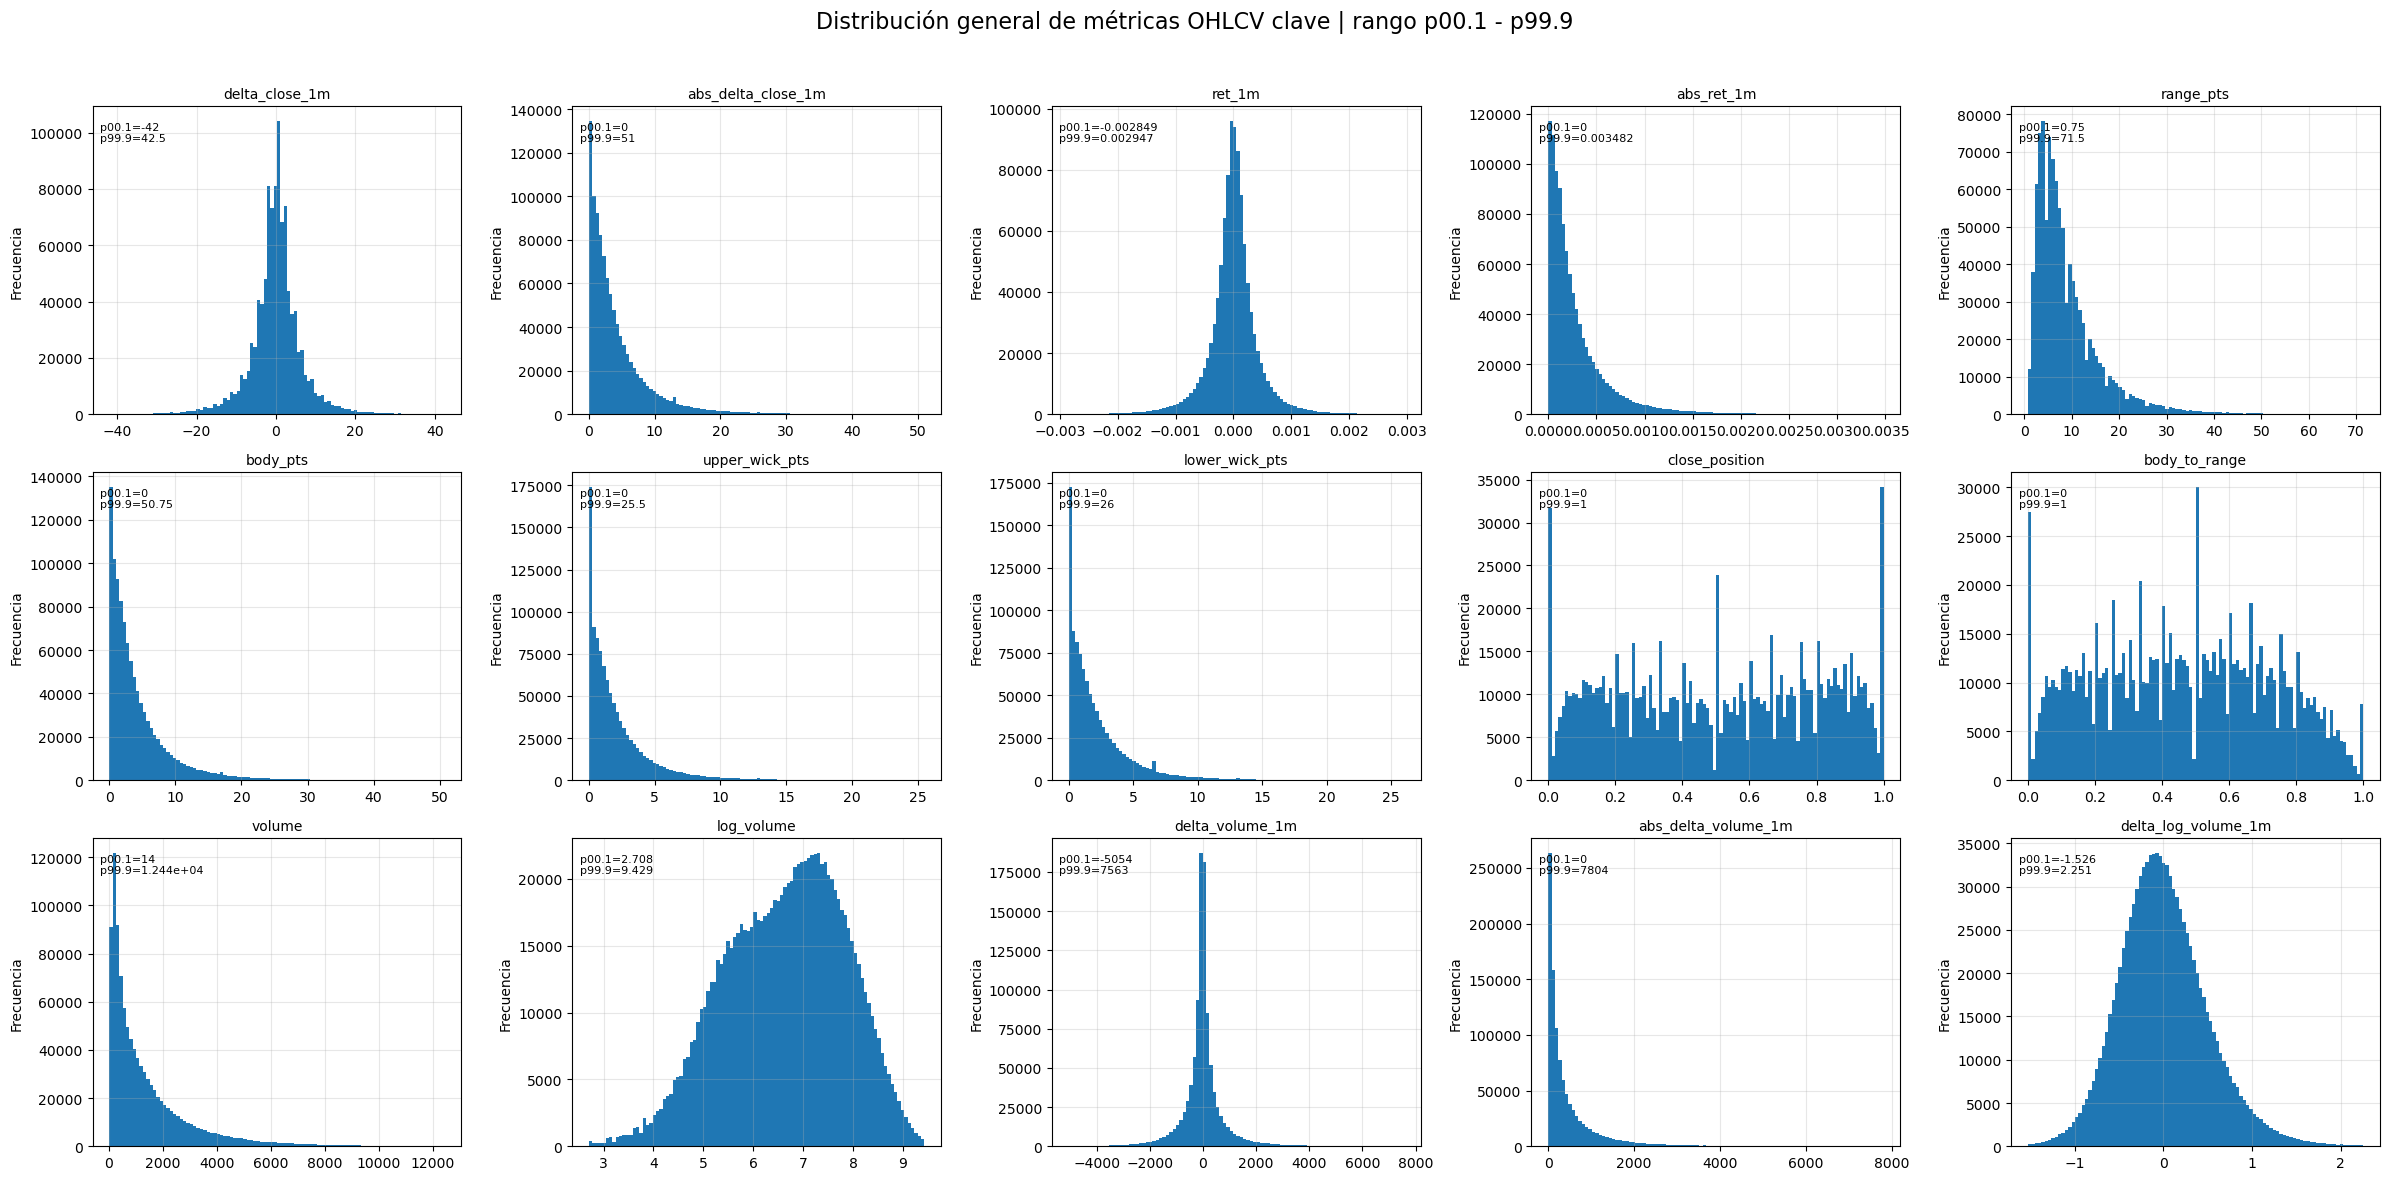

In [56]:
# Histogramas de métricas clave en una sola matriz
# ============================================================
#
# Cada histograma se acota entre p00_1 y p99_9 para observar
# mejor la distribución central sin que los outliers extremos
# compriman la escala.
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Cantidad de columnas y filas de la matriz
ncols = 5
nrows = int(np.ceil(len(distribution_metric_cols) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(24, 4 * nrows)
)

axes = axes.flatten()

for i, metric in enumerate(distribution_metric_cols):
    s = (
        df_ohlcv[metric]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    q_low = s.quantile(0.001)
    q_high = s.quantile(0.999)

    s_plot = s[(s >= q_low) & (s <= q_high)]

    axes[i].hist(s_plot, bins=100)
    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(True, alpha=0.3)

    axes[i].text(
        0.02,
        0.95,
        f"p00.1={q_low:.4g}\np99.9={q_high:.4g}",
        transform=axes[i].transAxes,
        verticalalignment="top",
        fontsize=8
    )

# Ocultar ejes vacíos si sobran espacios en la matriz
for j in range(len(distribution_metric_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Distribución general de métricas OHLCV clave | rango p00.1 - p99.9",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

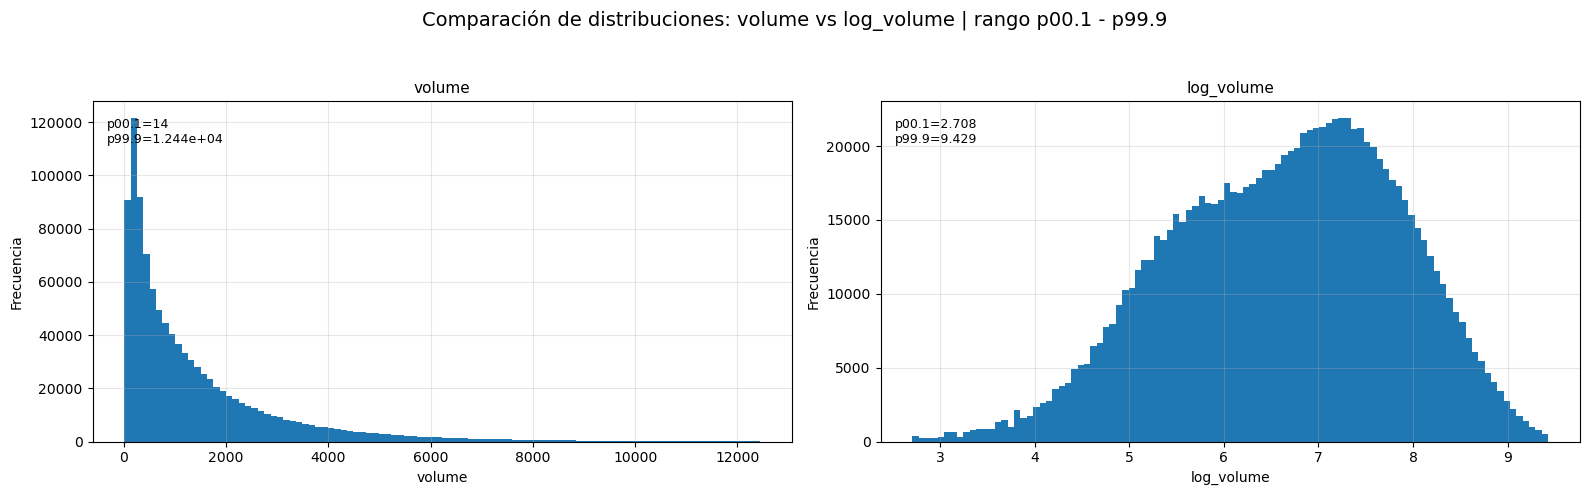

In [57]:
# Comparación entre volume y log_volume
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

volume_comparison_cols = ["volume", "log_volume"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5)
)

axes = axes.flatten()

for i, metric in enumerate(volume_comparison_cols):
    s = (
        df_ohlcv[metric]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    q_low = s.quantile(0.001)
    q_high = s.quantile(0.999)

    s_plot = s[(s >= q_low) & (s <= q_high)]

    axes[i].hist(s_plot, bins=100)
    axes[i].set_title(metric, fontsize=11)
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(True, alpha=0.3)

    axes[i].text(
        0.02,
        0.95,
        f"p00.1={q_low:.4g}\np99.9={q_high:.4g}",
        transform=axes[i].transAxes,
        verticalalignment="top",
        fontsize=9
    )

fig.suptitle(
    "Comparación de distribuciones: volume vs log_volume | rango p00.1 - p99.9",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [58]:
# Concentración de valores en cero
# ============================================================

df_zero_concentration = []

for metric in distribution_metric_cols:
    s = (
        df_ohlcv[metric]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    zero_count = (s == 0).sum()
    zero_pct = zero_count / len(s) * 100

    df_zero_concentration.append({
        "metric": metric,
        "count": len(s),
        "zero_count": zero_count,
        "zero_pct": zero_pct,
    })

df_zero_concentration = pd.DataFrame(df_zero_concentration)

print("Concentración de valores en cero por métrica")
display(df_zero_concentration)

Concentración de valores en cero por métrica


,metric,count,zero_count,zero_pct
0,delta_close_1m,1022580,27192,2.659156
1,abs_delta_close_1m,1022580,27192,2.659156
2,ret_1m,1022580,27192,2.659156
3,abs_ret_1m,1022580,27192,2.659156
4,range_pts,1024062,30,0.002930
5,body_pts,1024062,27374,2.673080
6,upper_wick_pts,1024062,88930,8.684045
7,lower_wick_pts,1024062,89070,8.697716
8,close_position,1024032,31332,3.059670
9,body_to_range,1024032,27344,2.670229


**Observación aplicada al modelado:**
El análisis visual de las distribuciones minuto a minuto muestra que las métricas OHLCV individuales tienen un valor principalmente diagnóstico. La mayoría de los cambios de precio, retornos, rangos y cuerpos de vela se concentran en valores pequeños, lo cual confirma que una sola barra de `1` minuto contiene mucho ruido y poca información operativa aislada.

Por este motivo, estas métricas no deben utilizarse para definir thresholds de targets ni conclusiones operativas directas. Su utilidad principal es identificar problemas potenciales antes del modelado: presencia de colas pesadas, valores extremos, concentración cerca de cero y fuerte asimetría en volumen.

Desde el punto de vista del entrenamiento, el resultado más relevante es que las variables crudas de volumen presentan una distribución muy asimétrica. En consecuencia, `log_volume` y `delta_log_volume_1m` parecen representaciones más estables que `volume`, `delta_volume_1m` o `abs_delta_volume_1m`.

El análisis también confirma que los movimientos relevantes para el modelo no deberían evaluarse a nivel de una vela aislada, sino mediante métricas agregadas en ventanas históricas y futuras de `30`, `60` y `90` minutos. Por lo tanto, este punto debe interpretarse como una validación descriptiva inicial y no como una etapa de definición operativa.


## 6.5 Correlación entre métricas OHLCV

En esta sección se analiza la correlación entre las métricas OHLCV construidas previamente.

El objetivo de este análisis no es definir señales operativas ni thresholds de trading, ya que el horizonte real del modelo será evaluado posteriormente en ventanas de `30`, `60` y `90` minutos. En cambio, este punto busca identificar relaciones redundantes entre variables descriptivas minuto a minuto.

Este análisis es útil para el diseño posterior de features, porque permite detectar métricas que aportan información muy similar. Incluir muchas variables altamente correlacionadas puede aumentar la complejidad del modelo, dificultar la interpretación, inflar la importancia de ciertos grupos de variables y favorecer el sobreajuste, especialmente si los patrones cambian entre años o regímenes de mercado.

Por este motivo, la correlación se interpreta como una herramienta de diagnóstico para decidir qué variables conservar, transformar o descartar antes del entrenamiento. En particular, se busca responder:

* qué métricas son prácticamente duplicadas;
* qué variables de volumen son más estables para modelar;
* si conviene usar variables en puntos, retornos o versiones logarítmicas;
* qué grupos de variables deberían resumirse mediante features agregadas en ventanas históricas;
* qué variables podrían generar redundancia cuando luego se construyan ventanas de `30`, `60` y `90` minutos.

Este análisis sigue siendo minuto a minuto, por lo tanto sus conclusiones no definen los targets. Su valor principal es preparar el diseño de features para mejorar la generalización del modelo.


### 6.5.1 Selección de métricas para correlación

In [59]:
# 6.5 Correlación entre métricas OHLCV
# ============================================================
#
# Objetivo:
# Analizar relaciones de redundancia entre métricas OHLCV.
#
# Este análisis NO busca definir señales operativas.
# Sirve para preparar el diseño de features y evitar meter
# variables duplicadas o inestables al modelo.
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Validar que ohlcv_analysis_cols exista
if "ohlcv_analysis_cols" not in globals():
    raise NameError("No existe ohlcv_analysis_cols. Primero debe ejecutarse el punto 6.1.")

# Métricas continuas para correlación
# Se excluye candle_direction porque es una variable discreta {-1, 0, 1}
# y se interpreta mejor por separado.
corr_analysis_cols = [
    col for col in ohlcv_analysis_cols
    if col != "candle_direction"
]

# Validar columnas
missing_cols = [
    col for col in corr_analysis_cols
    if col not in df_ohlcv.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas para correlación: {missing_cols}")

# Dataset base para correlación
df_corr_base = (
    df_ohlcv[corr_analysis_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("Cantidad de métricas usadas en correlación:")
print(len(corr_analysis_cols))

print("Cantidad de filas válidas para correlación:")
print(len(df_corr_base))

print("Métricas incluidas:")
print(corr_analysis_cols)

Cantidad de métricas usadas en correlación:
20
Cantidad de filas válidas para correlación:
1022550
Métricas incluidas:
['delta_close_1m', 'ret_1m', 'log_ret_1m', 'abs_delta_close_1m', 'abs_ret_1m', 'range_pts', 'range_pct', 'body_pts', 'upper_wick_pts', 'lower_wick_pts', 'close_position', 'body_to_range', 'upper_wick_to_range', 'lower_wick_to_range', 'volume', 'log_volume', 'delta_volume_1m', 'abs_delta_volume_1m', 'volume_pct_change_1m', 'delta_log_volume_1m']


### 6.5.2 Matriz de correlación Pearson y Spearman

Usamos dos correlaciones:

* Pearson  → relación lineal.
* Spearman → relación monotónica, más robusta frente a colas y no linealidades.

In [60]:
# Matrices de correlación
# ============================================================

# Correlación lineal
corr_pearson = df_corr_base.corr(method="pearson")

# Correlación monotónica
# Para Spearman se puede usar una muestra si el cálculo tarda demasiado.
SPEARMAN_SAMPLE_SIZE = 300_000

if len(df_corr_base) > SPEARMAN_SAMPLE_SIZE:
    df_corr_spearman_base = df_corr_base.sample(
        n=SPEARMAN_SAMPLE_SIZE,
        random_state=42
    )
else:
    df_corr_spearman_base = df_corr_base.copy()

corr_spearman = df_corr_spearman_base.corr(method="spearman")

print("Matriz de correlación Pearson")
display(corr_pearson)

print("Matriz de correlación Spearman")
display(corr_spearman)

Matriz de correlación Pearson


,delta_close_1m,ret_1m,log_ret_1m,abs_delta_close_1m,abs_ret_1m,range_pts,range_pct,body_pts,upper_wick_pts,lower_wick_pts,close_position,body_to_range,upper_wick_to_range,lower_wick_to_range,volume,log_volume,delta_volume_1m,abs_delta_volume_1m,volume_pct_change_1m,delta_log_volume_1m
delta_close_1m,1.000000,0.951838,0.951823,-0.010239,-0.009393,-0.007815,-0.009082,-0.010219,0.054138,-0.054026,0.620016,0.002345,0.040438,-0.042719,-0.012469,-0.007489,-0.011581,-0.007009,-0.001331,-0.016609
ret_1m,0.951838,1.000000,0.999997,-0.009896,-0.007322,-0.007365,-0.007539,-0.009543,0.051021,-0.051087,0.611147,0.002841,0.040063,-0.042957,-0.010149,-0.006420,-0.008711,-0.005420,-0.001350,-0.013726
log_ret_1m,0.951823,0.999997,1.000000,-0.011045,-0.008618,-0.008300,-0.008601,-0.010679,0.050822,-0.051256,0.611117,0.002588,0.040214,-0.042797,-0.010465,-0.006669,-0.008856,-0.005567,-0.001397,-0.013895
abs_delta_close_1m,-0.010239,-0.009896,-0.011045,1.000000,0.922273,0.837421,0.756943,0.996823,0.185923,0.183456,-0.009844,0.516149,-0.318775,-0.318410,0.477690,0.481228,0.151419,0.181768,0.048667,0.248173
abs_ret_1m,-0.009393,-0.007322,-0.008618,0.922273,1.000000,0.757335,0.841615,0.918762,0.153597,0.146384,-0.010226,0.505724,-0.310319,-0.313965,0.396614,0.422833,0.137052,0.149617,0.046071,0.241027
range_pts,-0.007815,-0.007365,-0.008300,0.837421,0.757335,1.000000,0.892151,0.839324,0.563894,0.571243,-0.010588,0.149657,-0.098604,-0.086237,0.623756,0.652756,0.144205,0.230394,0.059894,0.228495
range_pct,-0.009082,-0.007539,-0.008601,0.756943,0.841615,0.892151,1.000000,0.758665,0.497797,0.495558,-0.012924,0.149738,-0.094570,-0.090312,0.508434,0.567406,0.127021,0.183475,0.051419,0.220645
body_pts,-0.010219,-0.009543,-0.010679,0.996823,0.918762,0.839324,0.758665,1.000000,0.185359,0.183055,-0.010271,0.521574,-0.322219,-0.321664,0.479183,0.483390,0.151636,0.182091,0.048574,0.247952
upper_wick_pts,0.054138,0.051021,0.050822,0.185923,0.153597,0.563894,0.497797,0.185359,1.000000,0.222147,-0.230431,-0.303883,0.557167,-0.176609,0.400722,0.430622,0.052640,0.145849,0.045508,0.065974
lower_wick_pts,-0.054026,-0.051087,-0.051256,0.183456,0.146384,0.571243,0.495558,0.183055,0.222147,1.000000,0.213978,-0.309220,-0.183588,0.559829,0.395199,0.437834,0.050585,0.138148,0.026153,0.082079


Matriz de correlación Spearman


,delta_close_1m,ret_1m,log_ret_1m,abs_delta_close_1m,abs_ret_1m,range_pts,range_pct,body_pts,upper_wick_pts,lower_wick_pts,close_position,body_to_range,upper_wick_to_range,lower_wick_to_range,volume,log_volume,delta_volume_1m,abs_delta_volume_1m,volume_pct_change_1m,delta_log_volume_1m
delta_close_1m,1.000000,0.991227,0.991227,0.005871,0.004795,-0.010656,-0.012303,0.004676,0.067592,-0.098502,0.775608,0.017395,0.060979,-0.081208,0.000565,0.000565,-0.014990,-0.003214,-0.012365,-0.012377
ret_1m,0.991227,1.000000,1.000000,0.005260,0.005423,-0.011477,-0.011401,0.004180,0.066972,-0.098793,0.774329,0.017448,0.061289,-0.081734,-0.000351,-0.000351,-0.014445,-0.003907,-0.011887,-0.011899
log_ret_1m,0.991227,1.000000,1.000000,0.005260,0.005423,-0.011477,-0.011401,0.004180,0.066972,-0.098793,0.774329,0.017448,0.061289,-0.081734,-0.000351,-0.000351,-0.014445,-0.003907,-0.011887,-0.011899
abs_delta_close_1m,0.005871,0.005260,0.005260,1.000000,0.964934,0.722819,0.674060,0.984904,0.067995,0.075465,0.001408,0.727038,-0.426603,-0.423995,0.537659,0.537659,0.225149,0.384426,0.267538,0.267558
abs_ret_1m,0.004795,0.005423,0.005423,0.964934,1.000000,0.677563,0.728183,0.949605,0.045882,0.049616,-0.000736,0.722099,-0.422418,-0.424743,0.490276,0.490276,0.224948,0.343772,0.264917,0.264941
range_pts,-0.010656,-0.011477,-0.011477,0.722819,0.677563,1.000000,0.917841,0.727270,0.494905,0.513032,-0.008724,0.158451,-0.097927,-0.076306,0.814735,0.814735,0.176687,0.567648,0.245941,0.245875
range_pct,-0.012303,-0.011401,-0.011401,0.674060,0.728183,0.917841,1.000000,0.678107,0.449932,0.462250,-0.012098,0.158499,-0.096400,-0.082062,0.733048,0.733048,0.177547,0.499784,0.242411,0.242349
body_pts,0.004676,0.004180,0.004180,0.984904,0.949605,0.727270,0.678107,1.000000,0.064397,0.072066,0.000442,0.743109,-0.435427,-0.432588,0.540524,0.540524,0.225077,0.385913,0.267506,0.267527
upper_wick_pts,0.067592,0.066972,0.066972,0.067995,0.045882,0.494905,0.449932,0.064397,1.000000,0.151374,-0.273171,-0.397759,0.765811,-0.178034,0.456719,0.456719,-0.012142,0.303688,0.034294,0.034149
lower_wick_pts,-0.098502,-0.098793,-0.098793,0.075465,0.049616,0.513032,0.462250,0.072066,0.151374,1.000000,0.239989,-0.404229,-0.188466,0.766329,0.465606,0.465606,0.001218,0.313063,0.045131,0.045001


### 6.5.3 Heatmaps de correlación en una sola figura

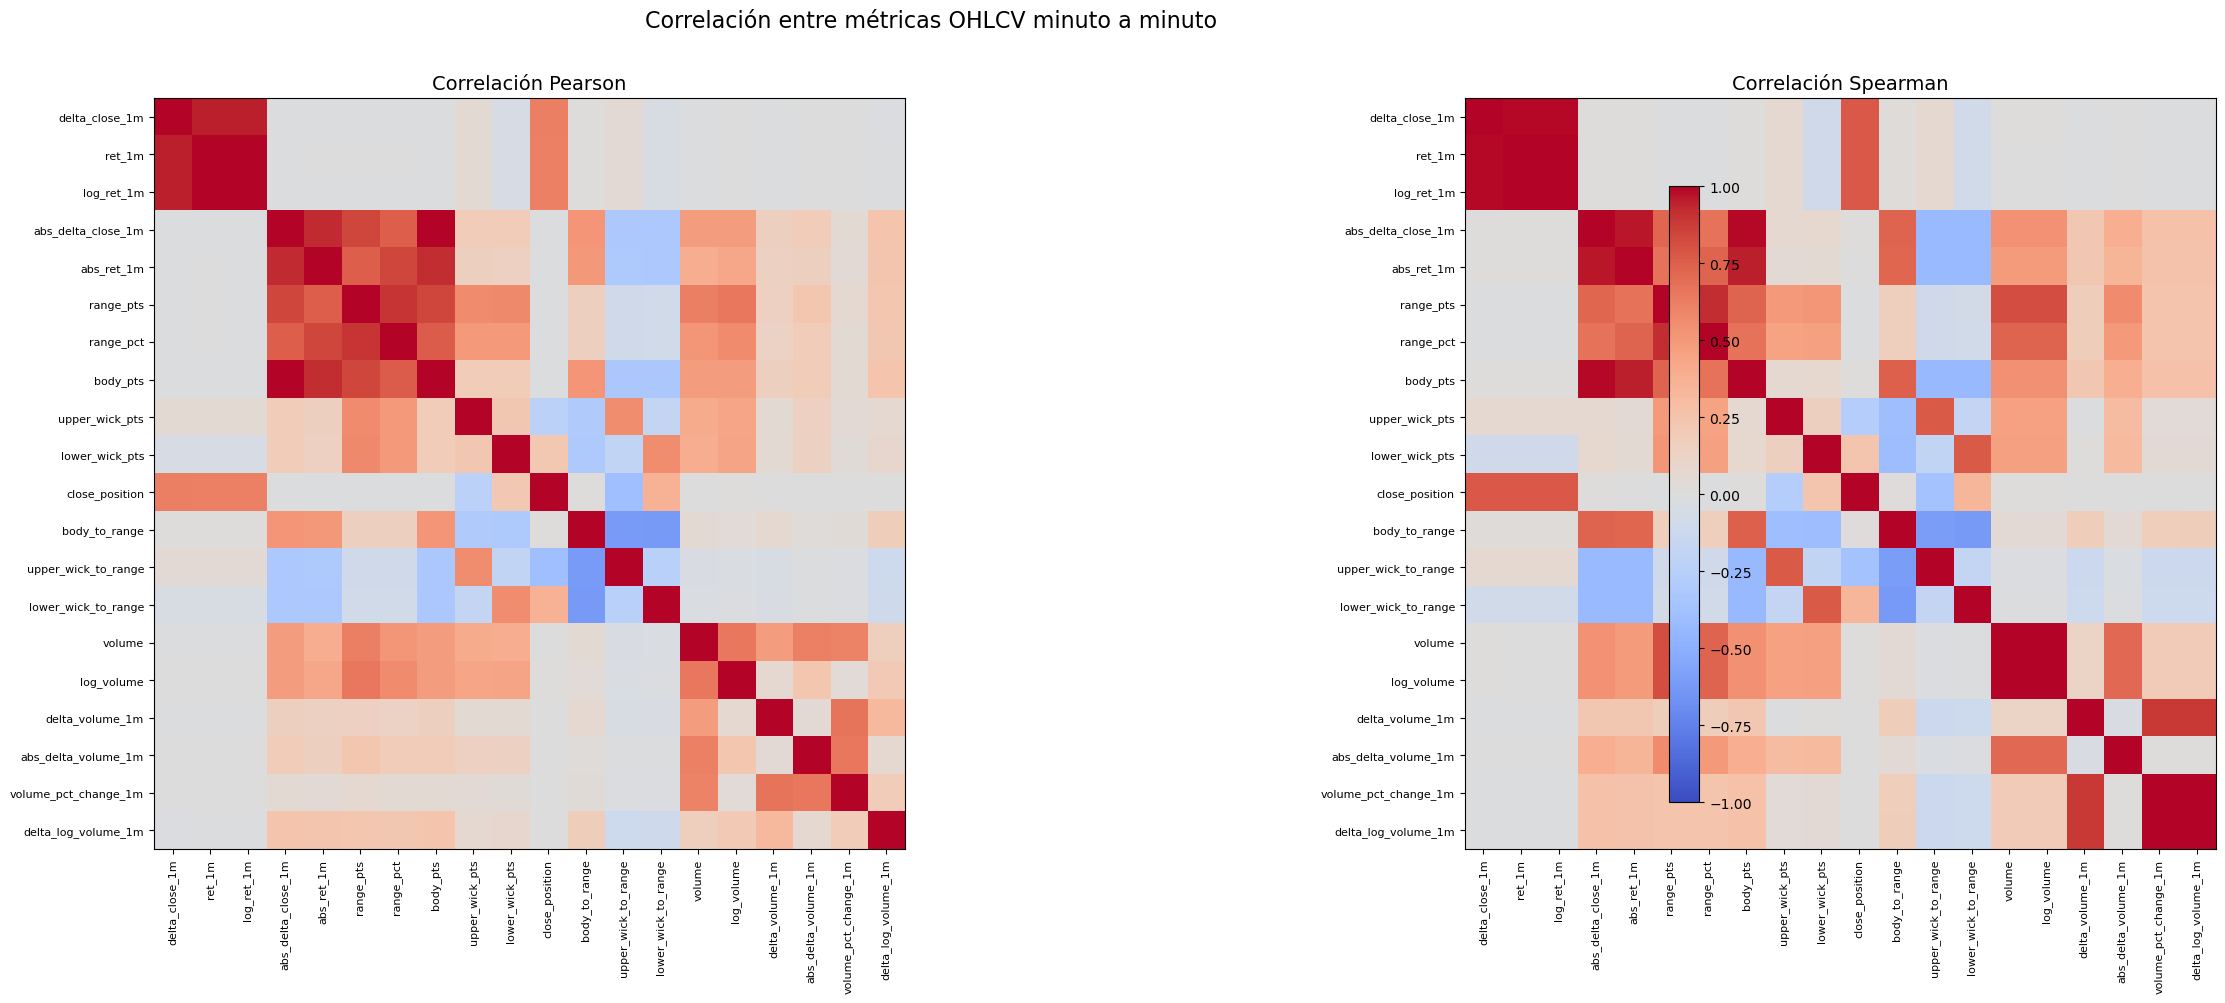

In [61]:
# Heatmaps de correlación Pearson y Spearman
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(26, 10)
)

corr_matrices = [
    (corr_pearson, "Correlación Pearson"),
    (corr_spearman, "Correlación Spearman"),
]

for ax, (corr_matrix, title) in zip(axes, corr_matrices):
    im = ax.imshow(
        corr_matrix,
        vmin=-1,
        vmax=1,
        cmap="coolwarm"
    )

    ax.set_title(title, fontsize=14)

    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))

    ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
    ax.set_yticklabels(corr_matrix.index, fontsize=8)

    ax.grid(False)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.80)

fig.suptitle(
    "Correlación entre métricas OHLCV minuto a minuto",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 6.5.4 Pares con mayor correlación absoluta

In [62]:
# Función para extraer pares de correlación
# ============================================================

def get_corr_pairs(corr_matrix, method_name):
    """
    Convierte una matriz de correlación en una tabla de pares únicos.
    """

    mask = np.triu(
        np.ones(corr_matrix.shape, dtype=bool),
        k=1
    )

    corr_pairs = (
        corr_matrix
        .where(mask)
        .stack()
        .reset_index()
    )

    corr_pairs.columns = ["metric_1", "metric_2", "corr"]

    corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
    corr_pairs["method"] = method_name

    corr_pairs = corr_pairs.sort_values(
        by="abs_corr",
        ascending=False
    ).reset_index(drop=True)

    return corr_pairs


df_corr_pairs_pearson = get_corr_pairs(corr_pearson, "pearson")
df_corr_pairs_spearman = get_corr_pairs(corr_spearman, "spearman")

df_top_corr_pairs = pd.concat(
    [df_corr_pairs_pearson, df_corr_pairs_spearman],
    axis=0
).sort_values(
    by="abs_corr",
    ascending=False
).reset_index(drop=True)

print("Top 30 pares con mayor correlación absoluta")
display(df_top_corr_pairs.head(30))

Top 30 pares con mayor correlación absoluta


,metric_1,metric_2,corr,abs_corr,method
0,ret_1m,log_ret_1m,1.000000,1.000000,spearman
1,volume,log_volume,1.000000,1.000000,spearman
2,ret_1m,log_ret_1m,0.999997,0.999997,pearson
3,volume_pct_change_1m,delta_log_volume_1m,0.999996,0.999996,spearman
4,abs_delta_close_1m,body_pts,0.996823,0.996823,pearson
5,delta_close_1m,log_ret_1m,0.991227,0.991227,spearman
6,delta_close_1m,ret_1m,0.991227,0.991227,spearman
7,abs_delta_close_1m,body_pts,0.984904,0.984904,spearman
8,abs_delta_close_1m,abs_ret_1m,0.964934,0.964934,spearman
9,delta_close_1m,ret_1m,0.951838,0.951838,pearson


### 6.5.5 Identificación de redundancias fuertes

In [63]:
# Pares altamente correlacionados
# ============================================================
#
# Umbral práctico:
# abs(correlación) >= 0.90 se considera una redundancia fuerte.
#
# Esto no significa eliminar automáticamente una variable.
# Significa que el par debe revisarse antes de modelar.
#
# ============================================================

HIGH_CORR_THRESHOLD = 0.90

df_high_corr_pairs = (
    df_top_corr_pairs
    .loc[df_top_corr_pairs["abs_corr"] >= HIGH_CORR_THRESHOLD]
    .copy()
    .reset_index(drop=True)
)

print(f"Pares con correlación absoluta >= {HIGH_CORR_THRESHOLD}")
display(df_high_corr_pairs)

Pares con correlación absoluta >= 0.9


,metric_1,metric_2,corr,abs_corr,method
0,ret_1m,log_ret_1m,1.000000,1.000000,spearman
1,volume,log_volume,1.000000,1.000000,spearman
2,ret_1m,log_ret_1m,0.999997,0.999997,pearson
3,volume_pct_change_1m,delta_log_volume_1m,0.999996,0.999996,spearman
4,abs_delta_close_1m,body_pts,0.996823,0.996823,pearson
5,delta_close_1m,log_ret_1m,0.991227,0.991227,spearman
6,delta_close_1m,ret_1m,0.991227,0.991227,spearman
7,abs_delta_close_1m,body_pts,0.984904,0.984904,spearman
8,abs_delta_close_1m,abs_ret_1m,0.964934,0.964934,spearman
9,delta_close_1m,ret_1m,0.951838,0.951838,pearson


### 6.5.6 Recomendaciones automáticas para modelado

In [64]:
# Recomendación práctica por par correlacionado
# ============================================================

def modeling_recommendation(metric_1, metric_2):
    pair = {metric_1, metric_2}

    if {"ret_1m", "log_ret_1m"}.issubset(pair):
        return "Variables casi equivalentes. Conservar solo una; preferir log_ret_1m para consistencia estadística."

    if {"volume", "log_volume"}.issubset(pair):
        return "No usar ambas como features crudas. Preferir log_volume por mayor estabilidad."

    if {"delta_volume_1m", "delta_log_volume_1m"}.issubset(pair):
        return "Preferir delta_log_volume_1m; reduce el impacto de cambios extremos de volumen."

    if {"abs_delta_volume_1m", "delta_log_volume_1m"}.issubset(pair):
        return "Revisar redundancia. Para modelos robustos, priorizar cambios logarítmicos o rolling de volumen."

    if {"delta_close_1m", "ret_1m"}.issubset(pair):
        return "Ambas expresan cambio de precio. Usar una sola representación según el modelo."

    if {"delta_close_1m", "log_ret_1m"}.issubset(pair):
        return "Ambas expresan cambio de precio. Usar una sola representación según el modelo."

    if {"abs_delta_close_1m", "abs_ret_1m"}.issubset(pair):
        return "Ambas expresan magnitud del movimiento. Conservar solo una versión."

    if {"abs_delta_close_1m", "body_pts"}.issubset(pair):
        return "Pueden contener información muy similar si open se aproxima al cierre anterior. Revisar antes de usar ambas."

    if {"range_pts", "body_pts"}.issubset(pair):
        return "Relacionadas pero no idénticas. Puede conservarse range_pts como volatilidad de vela y body_pts como direccionalidad interna."

    if {"upper_wick_pts", "lower_wick_pts"}.issubset(pair):
        return "Ambas describen estructura de mechas. Pueden conservarse, pero luego conviene resumirlas por ventana."

    return "Revisar antes de modelar. Si ambas variables aportan información similar, conservar la más estable o interpretable."


if len(df_high_corr_pairs) > 0:
    df_high_corr_recommendations = df_high_corr_pairs.copy()

    df_high_corr_recommendations["modeling_recommendation"] = (
        df_high_corr_recommendations
        .apply(
            lambda row: modeling_recommendation(
                row["metric_1"],
                row["metric_2"]
            ),
            axis=1
        )
    )

    print("Recomendaciones prácticas para pares altamente correlacionados")
    display(df_high_corr_recommendations)
else:
    print("No se detectaron pares con correlación absoluta alta según el umbral definido.")

Recomendaciones prácticas para pares altamente correlacionados


,metric_1,metric_2,corr,abs_corr,method,modeling_recommendation
0,ret_1m,log_ret_1m,1.000000,1.000000,spearman,Variables casi equivalentes. Conservar solo un...
1,volume,log_volume,1.000000,1.000000,spearman,No usar ambas como features crudas. Preferir l...
2,ret_1m,log_ret_1m,0.999997,0.999997,pearson,Variables casi equivalentes. Conservar solo un...
3,volume_pct_change_1m,delta_log_volume_1m,0.999996,0.999996,spearman,Revisar antes de modelar. Si ambas variables a...
4,abs_delta_close_1m,body_pts,0.996823,0.996823,pearson,Pueden contener información muy similar si ope...
5,delta_close_1m,log_ret_1m,0.991227,0.991227,spearman,Ambas expresan cambio de precio. Usar una sola...
6,delta_close_1m,ret_1m,0.991227,0.991227,spearman,Ambas expresan cambio de precio. Usar una sola...
7,abs_delta_close_1m,body_pts,0.984904,0.984904,spearman,Pueden contener información muy similar si ope...
8,abs_delta_close_1m,abs_ret_1m,0.964934,0.964934,spearman,Ambas expresan magnitud del movimiento. Conser...
9,delta_close_1m,ret_1m,0.951838,0.951838,pearson,Ambas expresan cambio de precio. Usar una sola...


### 6.5.6. Observación aplicada al diagnóstico del dataset


El análisis de correlación muestra que varias métricas OHLCV minuto a minuto contienen información altamente redundante. Este resultado no debe interpretarse como una selección definitiva de features, ya que esa etapa se realizará posteriormente. Su utilidad en este punto es únicamente diagnóstica.

Todas las métricas analizadas fueron calculadas con información disponible en la vela actual o en la vela anterior dentro del mismo trading day. No se utilizó información futura ni ventanas posteriores de `30`, `60` o `90` minutos. Por lo tanto, este análisis no introduce leakage, pero tampoco representa todavía el horizonte operativo del modelo.

Los resultados muestran que `ret_1m` y `log_ret_1m` son prácticamente equivalentes. También existe una alta relación entre `delta_close_1m`, `ret_1m` y `log_ret_1m`, lo que confirma que todas estas variables describen la misma familia de información: el cambio de precio minuto a minuto.

Del mismo modo, `abs_delta_close_1m`, `abs_ret_1m` y `body_pts` presentan correlaciones muy elevadas. Esto indica que varias métricas de magnitud del movimiento están capturando información similar. También se observa una alta correlación entre `range_pts` y `range_pct`, ya que ambas describen la amplitud de la vela, aunque en escalas diferentes.

En volumen, `volume` y `log_volume` presentan correlación perfecta en Spearman porque `log_volume` es una transformación monotónica del volumen original. Sin embargo, la transformación logarítmica cambia la escala y reduce el efecto de valores extremos, como se observó en las distribuciones anteriores.

La conclusión práctica de este punto no es elegir features, sino dejar documentado que el dataset contiene familias de métricas redundantes. Por lo tanto, cuando se llegue a la etapa de construcción de features, será necesario evitar duplicar variables que midan lo mismo y priorizar transformaciones que sean más estables en el tiempo.

En resumen, el análisis de correlación minuto a minuto ayuda a entender la estructura interna de las métricas OHLCV, pero no define todavía variables de entrenamiento ni thresholds operativos. Las decisiones reales de modelado deberán tomarse más adelante, especialmente después de analizar ventanas de `30`, `60` y `90` minutos y su estabilidad por año, régimen y contrato.


## 6.6 Identificación preliminar de valores extremos

En esta sección se realiza una identificación preliminar de valores extremos en las métricas OHLCV minuto a minuto.

El objetivo no es eliminar observaciones ni modificar el dataset, sino diagnosticar la presencia, frecuencia y concentración de eventos extremos. En mercados financieros intradiarios, los valores extremos pueden representar eventos reales de mercado, cambios abruptos de volatilidad, aperturas, noticias, períodos de estrés o condiciones particulares de liquidez. Por lo tanto, no deben tratarse automáticamente como errores.

Este análisis busca determinar si los extremos aparecen de forma aislada o si se concentran en determinados años, contratos, regímenes intradiarios o jornadas específicas. Esta información es relevante para el objetivo general de la notebook, ya que puede revelar cambios de comportamiento del MNQ a lo largo del tiempo y ayudar posteriormente a definir una estructura de entrenamiento, validación y test más robusta.

Los valores extremos se identificarán mediante umbrales empíricos basados en percentiles. Para métricas con valores positivos y negativos, se utilizarán colas inferiores y superiores. Para métricas no negativas, se analizará principalmente la cola superior.

Es importante aclarar que este análisis sigue siendo descriptivo. No define features, no define targets y no implica decisiones de modelado todavía. Su función es aportar evidencia estadística sobre la estructura del dataset y sobre posibles contextos donde el mercado presenta comportamientos atípicos.


### 6.6.1 Definición de métricas y criterio de extremos

In [65]:
# 6.6 Identificación preliminar de valores extremos
# ============================================================
#
# Objetivo:
# Identificar valores extremos en métricas OHLCV minuto a minuto
# y analizar si se concentran por año, contrato, régimen o día.
#
# Este análisis NO elimina outliers.
# Este análisis NO define features.
# Este análisis NO define targets.
#
# Sirve para diagnosticar la estructura del dataset y entender
# si existen contextos de mercado con comportamiento extremo.
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Copia de trabajo
df_extreme_base = df_ohlcv.copy()

# Crear columnas temporales auxiliares para análisis
df_extreme_base["year"] = df_extreme_base.index.year
df_extreme_base["month"] = df_extreme_base.index.strftime("%Y-%m")

# Crear regime_name si no existe
if "regime_name" not in df_extreme_base.columns:
    if "REGIME_NAMES" in globals() and "regime_id" in df_extreme_base.columns:
        df_extreme_base["regime_name"] = df_extreme_base["regime_id"].map(REGIME_NAMES)
    elif "regime_id" in df_extreme_base.columns:
        df_extreme_base["regime_name"] = df_extreme_base["regime_id"].astype(str)
    else:
        df_extreme_base["regime_name"] = "No disponible"

# Métricas a evaluar para valores extremos
# two_sided: se analiza cola inferior y superior
# upper_only: se analiza principalmente cola superior

extreme_metric_config = {
    # Cambios de precio
    "delta_close_1m": "two_sided",
    "ret_1m": "two_sided",
    "log_ret_1m": "two_sided",

    # Magnitud y estructura de vela
    "abs_delta_close_1m": "upper_only",
    "abs_ret_1m": "upper_only",
    "range_pts": "upper_only",
    "range_pct": "upper_only",
    "body_pts": "upper_only",
    "upper_wick_pts": "upper_only",
    "lower_wick_pts": "upper_only",

    # Volumen
    "volume": "upper_only",
    "log_volume": "upper_only",
    "delta_volume_1m": "two_sided",
    "abs_delta_volume_1m": "upper_only",
    "volume_pct_change_1m": "two_sided",
    "delta_log_volume_1m": "two_sided",
}

# Validar columnas disponibles
missing_cols = [
    col for col in extreme_metric_config.keys()
    if col not in df_extreme_base.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas requeridas para análisis de extremos: {missing_cols}")

print("Cantidad de métricas evaluadas para valores extremos:")
print(len(extreme_metric_config))

print("Métricas evaluadas:")
print(list(extreme_metric_config.keys()))

Cantidad de métricas evaluadas para valores extremos:
16
Métricas evaluadas:
['delta_close_1m', 'ret_1m', 'log_ret_1m', 'abs_delta_close_1m', 'abs_ret_1m', 'range_pts', 'range_pct', 'body_pts', 'upper_wick_pts', 'lower_wick_pts', 'volume', 'log_volume', 'delta_volume_1m', 'abs_delta_volume_1m', 'volume_pct_change_1m', 'delta_log_volume_1m']


### 6.6.2 Cálculo de umbrales extremos por percentiles

Usamos p00.1 y p99.9 porque estamos haciendo una detección preliminar de eventos extremos. Esto identifica aproximadamente el 0.1% más extremo de cada cola.

In [66]:
# Umbrales preliminares de valores extremos
# ============================================================
#
# Para métricas two_sided:
# - extremo inferior: <= p00.1
# - extremo superior: >= p99.9
#
# Para métricas upper_only:
# - extremo superior: >= p99.9
#
# ============================================================

LOWER_Q = 0.001
UPPER_Q = 0.999

df_extreme_thresholds = []

df_extreme_flags = pd.DataFrame(index=df_extreme_base.index)

for metric, criterion in extreme_metric_config.items():

    s = (
        df_extreme_base[metric]
        .replace([np.inf, -np.inf], np.nan)
    )

    valid_count = s.notna().sum()

    lower_threshold = s.quantile(LOWER_Q) if criterion == "two_sided" else np.nan
    upper_threshold = s.quantile(UPPER_Q)

    if criterion == "two_sided":
        lower_flag = s <= lower_threshold
        upper_flag = s >= upper_threshold
        extreme_flag = lower_flag | upper_flag

        lower_count = lower_flag.sum()
        upper_count = upper_flag.sum()

    else:
        lower_flag = pd.Series(False, index=s.index)
        upper_flag = s >= upper_threshold
        extreme_flag = upper_flag

        lower_count = 0
        upper_count = upper_flag.sum()

    flag_col = f"{metric}_is_extreme"
    df_extreme_flags[flag_col] = extreme_flag.fillna(False)

    df_extreme_thresholds.append({
        "metric": metric,
        "criterion": criterion,
        "valid_count": valid_count,
        "lower_threshold": lower_threshold,
        "upper_threshold": upper_threshold,
        "lower_extreme_count": lower_count,
        "upper_extreme_count": upper_count,
        "total_extreme_count": extreme_flag.sum(),
        "total_extreme_pct": extreme_flag.sum() / valid_count * 100,
    })

df_extreme_thresholds = pd.DataFrame(df_extreme_thresholds)

print("Umbrales preliminares de valores extremos por métrica")
display(df_extreme_thresholds)

Umbrales preliminares de valores extremos por métrica


,metric,criterion,valid_count,lower_threshold,upper_threshold,lower_extreme_count,upper_extreme_count,total_extreme_count,total_extreme_pct
0,delta_close_1m,two_sided,1022580,-42.000000,42.500000,1039,1032,2071,0.202527
1,ret_1m,two_sided,1022580,-0.002849,0.002947,1023,1023,2046,0.200082
2,log_ret_1m,two_sided,1022580,-0.002853,0.002942,1023,1023,2046,0.200082
3,abs_delta_close_1m,upper_only,1022580,NaN,51.000000,0,1026,1026,0.100334
4,abs_ret_1m,upper_only,1022580,NaN,0.003482,0,1023,1023,0.100041
5,range_pts,upper_only,1024062,NaN,71.500000,0,1027,1027,0.100287
6,range_pct,upper_only,1024062,NaN,0.004845,0,1025,1025,0.100092
7,body_pts,upper_only,1024062,NaN,50.750000,0,1027,1027,0.100287
8,upper_wick_pts,upper_only,1024062,NaN,25.500000,0,1062,1062,0.103705
9,lower_wick_pts,upper_only,1024062,NaN,26.000000,0,1054,1054,0.102923


### 6.6.3 Identificación de barras con al menos un valor extremo

Este bloque es importante porque una misma barra puede ser extrema en varias métricas al mismo tiempo.

In [67]:
# Barras con presencia de valores extremos
# ============================================================

extreme_flag_cols = df_extreme_flags.columns.tolist()

df_extreme_flags["n_extreme_metrics"] = (
    df_extreme_flags[extreme_flag_cols]
    .sum(axis=1)
)

df_extreme_flags["any_extreme"] = (
    df_extreme_flags["n_extreme_metrics"] > 0
)

total_rows = len(df_extreme_flags)
any_extreme_count = df_extreme_flags["any_extreme"].sum()
any_extreme_pct = any_extreme_count / total_rows * 100

df_extreme_global_summary = pd.DataFrame([{
    "total_rows": total_rows,
    "rows_with_any_extreme": any_extreme_count,
    "rows_with_any_extreme_pct": any_extreme_pct,
    "mean_extreme_metrics_per_row": df_extreme_flags["n_extreme_metrics"].mean(),
    "max_extreme_metrics_in_one_row": df_extreme_flags["n_extreme_metrics"].max(),
}])

print("Resumen global de barras con valores extremos")
display(df_extreme_global_summary)

Resumen global de barras con valores extremos


,total_rows,rows_with_any_extreme,rows_with_any_extreme_pct,mean_extreme_metrics_per_row,max_extreme_metrics_in_one_row
0,1024062,8625,0.842234,0.022087,16


### 6.6.4 Eventos extremos con contexto temporal

Este bloque arma una tabla con las barras extremas, incluyendo año, fecha, régimen, contrato y métricas activadas.

In [68]:
# Tabla de eventos extremos con contexto
# ============================================================

event_idx = df_extreme_flags.index[df_extreme_flags["any_extreme"]]

meta_cols = [
    "date",
    "year",
    "month",
    "minute_of_day",
    "regime_id",
    "regime_name",
    "contract",
    "open",
    "high",
    "low",
    "close",
    "volume",
]

meta_cols = [
    col for col in meta_cols
    if col in df_extreme_base.columns
]

df_extreme_events = df_extreme_base.loc[event_idx, meta_cols].copy()

df_extreme_events["n_extreme_metrics"] = (
    df_extreme_flags
    .loc[event_idx, "n_extreme_metrics"]
)

# Agregar lista de métricas extremas por barra
def get_triggered_extreme_metrics(row):
    triggered = [
        col.replace("_is_extreme", "")
        for col in extreme_flag_cols
        if row[col]
    ]
    return ", ".join(triggered)

df_extreme_events["extreme_metrics"] = (
    df_extreme_flags
    .loc[event_idx, extreme_flag_cols]
    .apply(get_triggered_extreme_metrics, axis=1)
)

# Agregar métricas principales para inspección
inspection_metric_cols = [
    "delta_close_1m",
    "abs_delta_close_1m",
    "range_pts",
    "range_pct",
    "body_pts",
    "upper_wick_pts",
    "lower_wick_pts",
    "log_volume",
    "delta_volume_1m",
    "abs_delta_volume_1m",
    "delta_log_volume_1m",
]

inspection_metric_cols = [
    col for col in inspection_metric_cols
    if col in df_extreme_base.columns
]

df_extreme_events = pd.concat(
    [
        df_extreme_events,
        df_extreme_base.loc[event_idx, inspection_metric_cols]
    ],
    axis=1
)

# Ordenar eventos más relevantes
sort_cols = [
    col for col in ["n_extreme_metrics", "range_pts", "abs_delta_close_1m", "abs_delta_volume_1m"]
    if col in df_extreme_events.columns
]

df_extreme_events_sorted = (
    df_extreme_events
    .sort_values(by=sort_cols, ascending=False)
)

print("Vista preliminar de eventos extremos más relevantes")
display(df_extreme_events_sorted.head(50))

Vista preliminar de eventos extremos más relevantes


,date,year,month,minute_of_day,regime_id,regime_name,contract,open,high,low,...,abs_delta_close_1m,range_pts,range_pct,body_pts,upper_wick_pts,lower_wick_pts,log_volume,delta_volume_1m,abs_delta_volume_1m,delta_log_volume_1m
datetime,,,,,,,,,,,,,,,,,,,,,
2022-11-10 08:31:00-05:00,2022-11-10,2022,2022-11,511,1,Pre-market,Z22,10877.75,11189.25,10809.00,...,282.50,380.25,0.034062,285.75,25.75,68.75,9.449121,11646.0,11646.0,2.491624
2022-11-30 13:31:00-05:00,2022-11-30,2022,2022-11,811,3,Regular,Z22,11561.25,11655.00,11529.50,...,63.75,125.50,0.010796,63.50,30.25,31.75,9.642123,14588.0,14588.0,2.942622
2025-03-12 08:31:00-04:00,2025-03-12,2025,2025-03,511,1,Pre-market,H25,19598.75,19788.75,19587.75,...,149.50,201.00,0.010179,148.50,41.50,11.00,9.487896,12400.0,12400.0,2.804535
2023-11-14 08:31:00-05:00,2023-11-14,2023,2023-11,511,1,Pre-market,Z23,15594.00,15749.00,15553.00,...,152.50,196.00,0.012449,150.50,4.50,41.00,9.481207,12638.0,12638.0,3.322111
2024-06-07 08:31:00-04:00,2024-06-07,2024,2024-06,511,1,Pre-market,M24,19093.50,19150.00,18992.25,...,80.00,157.75,0.008299,84.50,56.50,16.75,9.512443,12909.0,12909.0,3.085955
2025-10-22 12:31:00-04:00,2025-10-22,2025,2025-10,751,3,Regular,Z25,25028.50,25053.00,24910.50,...,92.25,142.50,0.005714,91.75,24.50,26.25,9.975762,19574.0,19574.0,2.413080
2024-04-11 08:31:00-04:00,2024-04-11,2024,2024-04,511,1,Pre-market,M24,18123.75,18211.00,18085.00,...,85.75,126.00,0.006921,82.00,5.25,38.75,9.599270,13859.0,13859.0,2.802446
2025-04-09 13:20:00-04:00,2025-04-09,2025,2025-04,800,3,Regular,M25,17506.50,18050.00,17457.75,...,438.50,592.25,0.032994,443.50,100.00,48.75,9.757999,8161.0,8161.0,0.638569
2025-04-07 11:15:00-04:00,2025-04-07,2025,2025-04,675,3,Regular,M25,17580.00,17607.50,17239.00,...,288.00,368.50,0.021311,288.50,27.50,52.50,9.593083,9584.0,9584.0,1.060213


### 6.6.5 Distribución de extremos por año, régimen y contrato

Este es el bloque más útil para nuestro objetivo, porque permite ver si los extremos están concentrados en ciertos contextos.

In [69]:
# Dataset auxiliar para análisis de concentración de extremos
# ============================================================

df_extreme_context = df_extreme_base[
    [
        col for col in [
            "date",
            "year",
            "month",
            "minute_of_day",
            "regime_id",
            "regime_name",
            "contract",
        ]
        if col in df_extreme_base.columns
    ]
].copy()

df_extreme_context["any_extreme"] = df_extreme_flags["any_extreme"]
df_extreme_context["n_extreme_metrics"] = df_extreme_flags["n_extreme_metrics"]


def summarize_extremes_by(df, group_col):
    """
    Resume la frecuencia de barras extremas por grupo.
    """

    summary = (
        df
        .groupby(group_col, observed=True)
        .agg(
            total_rows=("any_extreme", "size"),
            extreme_rows=("any_extreme", "sum"),
            mean_extreme_metrics=("n_extreme_metrics", "mean"),
            max_extreme_metrics=("n_extreme_metrics", "max"),
        )
        .reset_index()
    )

    summary["extreme_rows_pct"] = (
        summary["extreme_rows"] / summary["total_rows"] * 100
    )

    summary = summary.sort_values(
        by="extreme_rows_pct",
        ascending=False
    ).reset_index(drop=True)

    return summary


df_extreme_by_year = summarize_extremes_by(df_extreme_context, "year")
df_extreme_by_regime = summarize_extremes_by(df_extreme_context, "regime_name")
df_extreme_by_contract = summarize_extremes_by(df_extreme_context, "contract")

print("Valores extremos por año")
display(df_extreme_by_year)

print("Valores extremos por régimen intradiario")
display(df_extreme_by_regime)

print("Valores extremos por contrato")
display(df_extreme_by_contract)

Valores extremos por año


,year,total_rows,extreme_rows,mean_extreme_metrics,max_extreme_metrics,extreme_rows_pct
0,2026,48370,1095,0.054497,13,2.263800
1,2025,156857,2621,0.044199,15,1.670949
2,2022,165840,1371,0.027388,16,0.826700
3,2020,155475,1246,0.020550,13,0.801415
4,2024,165149,877,0.012080,15,0.531036
5,2021,168604,779,0.010255,10,0.462029
6,2023,163767,636,0.009697,15,0.388357


Valores extremos por régimen intradiario


,regime_name,total_rows,extreme_rows,mean_extreme_metrics,max_extreme_metrics,extreme_rows_pct
0,Opening,88920,3214,0.093174,13,3.614485
1,Closing,44460,340,0.019591,13,0.764732
2,Pre-market,88920,667,0.027126,16,0.750112
3,Regular,444600,2755,0.016730,16,0.619658
4,Overnight,357162,1649,0.010113,13,0.461695


Valores extremos por contrato


,contract,total_rows,extreme_rows,mean_extreme_metrics,max_extreme_metrics,extreme_rows_pct
0,M25,34550,1107,0.100724,14,3.204052
1,M26,13129,308,0.059334,13,2.345952
2,H26,39387,811,0.048468,13,2.059055
3,H20,33168,552,0.041003,13,1.664255
4,Z25,42151,631,0.034614,15,1.496999
5,H25,39387,564,0.033260,15,1.431945
6,H22,42151,449,0.034258,12,1.065218
7,M22,42151,417,0.030272,12,0.989300
8,M20,38696,340,0.026359,10,0.878644
9,U25,39387,311,0.016681,12,0.789601


### 6.6.6 Extremos por año y régimen intradiario

Esto nos ayuda a detectar si, por ejemplo, ciertos años son más extremos solo en apertura, cierre o regular session.

In [70]:
# Matriz de porcentaje de extremos por año y régimen
# ============================================================

df_extreme_year_regime = (
    df_extreme_context
    .groupby(["year", "regime_name"], observed=True)
    .agg(
        total_rows=("any_extreme", "size"),
        extreme_rows=("any_extreme", "sum"),
    )
    .reset_index()
)

df_extreme_year_regime["extreme_rows_pct"] = (
    df_extreme_year_regime["extreme_rows"]
    / df_extreme_year_regime["total_rows"]
    * 100
)

df_extreme_year_regime_pivot = (
    df_extreme_year_regime
    .pivot(
        index="year",
        columns="regime_name",
        values="extreme_rows_pct"
    )
)

print("Porcentaje de barras extremas por año y régimen")
display(df_extreme_year_regime_pivot)

Porcentaje de barras extremas por año y régimen


regime_name,Closing,Opening,Overnight,Pre-market,Regular
year,,,,,
2020,1.437037,1.933333,0.815122,0.666667,0.527407
2021,0.136612,1.393443,0.692130,0.457650,0.124317
2022,0.791667,4.263889,0.179806,0.847222,0.658333
2023,0.070323,1.490858,0.301136,0.787623,0.189873
2024,0.502092,2.377964,0.225698,0.774059,0.361227
2025,1.556535,7.143906,0.509990,0.917768,1.671072
2026,1.380952,14.500000,0.681683,0.952381,1.438095


### 6.6.7 Días con mayor concentración de extremos

Este bloque es clave para saber si los extremos están repartidos o si se concentran en pocos días.

In [71]:
# Días con mayor concentración de valores extremos
# ============================================================

df_extreme_by_day = (
    df_extreme_context
    .groupby("date", observed=True)
    .agg(
        total_rows=("any_extreme", "size"),
        extreme_rows=("any_extreme", "sum"),
        mean_extreme_metrics=("n_extreme_metrics", "mean"),
        max_extreme_metrics=("n_extreme_metrics", "max"),
    )
    .reset_index()
)

df_extreme_by_day["extreme_rows_pct"] = (
    df_extreme_by_day["extreme_rows"]
    / df_extreme_by_day["total_rows"]
    * 100
)

df_extreme_by_day = df_extreme_by_day.sort_values(
    by=["extreme_rows_pct", "extreme_rows"],
    ascending=False
).reset_index(drop=True)

print("Top 30 días con mayor concentración de valores extremos")
display(df_extreme_by_day.head(30))

Top 30 días con mayor concentración de valores extremos


,date,total_rows,extreme_rows,mean_extreme_metrics,max_extreme_metrics,extreme_rows_pct
0,2025-04-07,691,278,1.632417,14,40.231548
1,2025-04-09,691,224,1.143271,14,32.416787
2,2025-04-10,691,161,0.684515,9,23.299566
3,2020-03-23,691,155,0.722142,8,22.431259
4,2020-03-19,691,117,0.471780,8,16.931983
5,2025-04-08,691,86,0.305355,13,12.445731
6,2025-11-20,691,80,0.251809,10,11.577424
7,2025-04-11,691,75,0.231548,9,10.853835
8,2020-02-28,691,55,0.244573,13,7.959479
9,2022-01-24,691,55,0.232996,8,7.959479


### 6.6.8 Visualización resumida

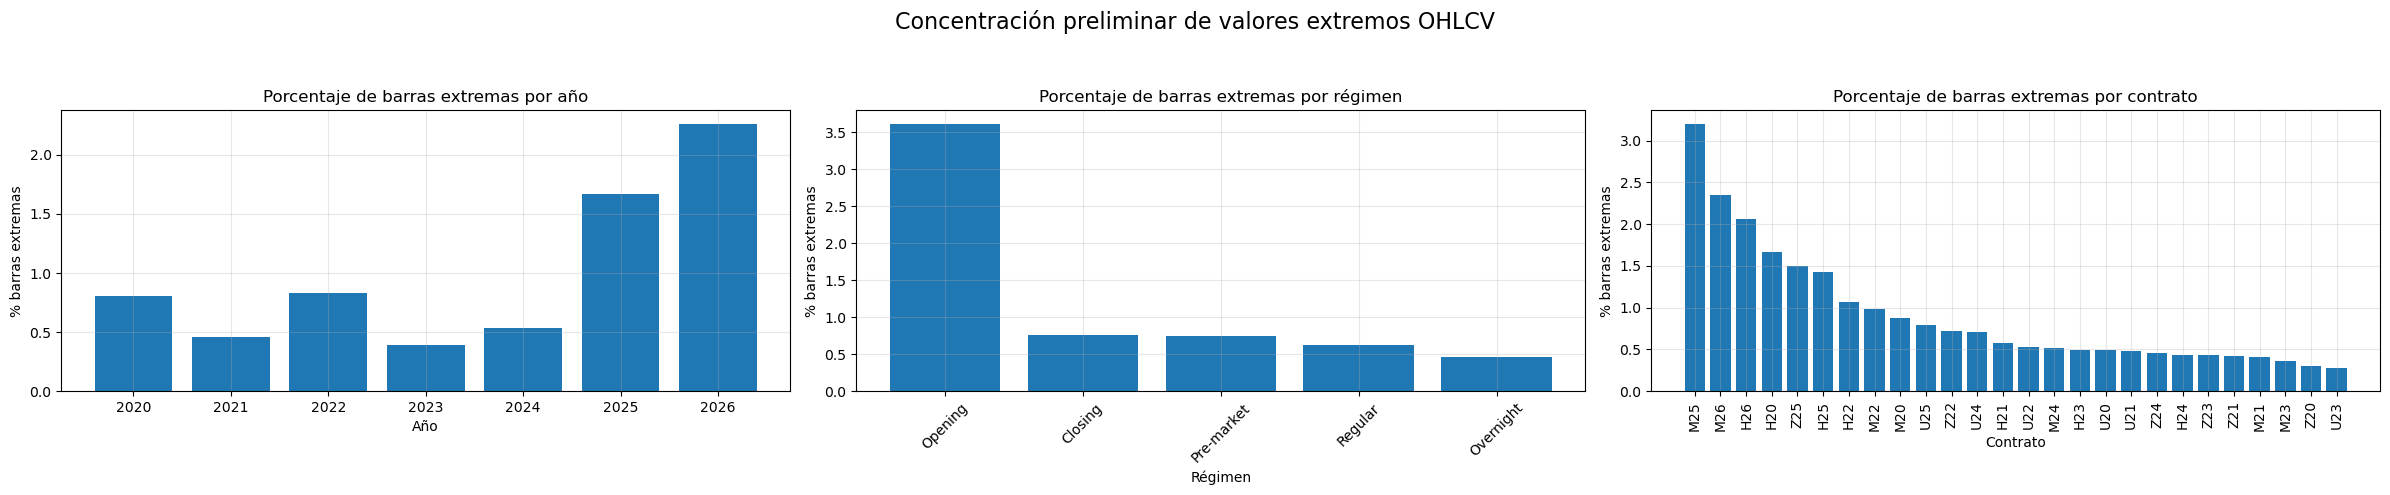

In [72]:
# Visualización resumida de concentración de extremos
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(24, 5)
)

# Extremos por año
df_plot_year = df_extreme_by_year.sort_values("year")

axes[0].bar(
    df_plot_year["year"].astype(str),
    df_plot_year["extreme_rows_pct"]
)
axes[0].set_title("Porcentaje de barras extremas por año")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("% barras extremas")
axes[0].grid(True, alpha=0.3)

# Extremos por régimen
df_plot_regime = df_extreme_by_regime.sort_values("extreme_rows_pct", ascending=False)

axes[1].bar(
    df_plot_regime["regime_name"].astype(str),
    df_plot_regime["extreme_rows_pct"]
)
axes[1].set_title("Porcentaje de barras extremas por régimen")
axes[1].set_xlabel("Régimen")
axes[1].set_ylabel("% barras extremas")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)

# Extremos por contrato
df_plot_contract = df_extreme_by_contract.sort_values("extreme_rows_pct", ascending=False)

axes[2].bar(
    df_plot_contract["contract"].astype(str),
    df_plot_contract["extreme_rows_pct"]
)
axes[2].set_title("Porcentaje de barras extremas por contrato")
axes[2].set_xlabel("Contrato")
axes[2].set_ylabel("% barras extremas")
axes[2].tick_params(axis="x", rotation=90)
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    "Concentración preliminar de valores extremos OHLCV",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### **Observación aplicada al diagnóstico de valores extremos:**


La identificación preliminar de valores extremos muestra que los eventos atípicos representan una proporción pequeña del dataset completo, pero no están distribuidos de forma homogénea en el tiempo ni entre regímenes intradiarios.

A nivel global, `8625` barras presentan al menos una métrica extrema, lo que representa aproximadamente el `0.84%` del dataset. Este porcentaje es bajo en términos generales, pero resulta relevante porque algunas barras concentran múltiples métricas extremas al mismo tiempo, alcanzando hasta `16` métricas extremas en una sola observación. Esto indica que ciertos eventos no son simples anomalías aisladas de una variable, sino episodios de mercado donde precio, rango y volumen se alteran simultáneamente.

Por año, los extremos se concentran principalmente en `2025` y `2026`, con `1.67%` y `2.26%` de barras extremas respectivamente. Sin embargo, `2026` debe interpretarse con cautela porque es un año parcial. También se observa que `2022` y `2020` presentan mayor proporción de extremos que `2021`, `2023` y `2024`, lo cual sugiere que el comportamiento del MNQ cambia significativamente entre períodos. Esta evidencia refuerza la necesidad de evitar divisiones aleatorias del dataset y analizar cuidadosamente cómo separar entrenamiento, validación y test.

Por régimen intradiario, el resultado más importante es la concentración de extremos en `Opening`, con aproximadamente `3.61%` de barras extremas. Este valor es muy superior al resto de regímenes. `Closing`, `Pre-market` y `Regular` se ubican por debajo del `1%`, mientras que `Overnight` presenta la menor proporción relativa de extremos. Esto indica que el horario operativo no es neutral: la apertura concentra una parte importante del riesgo y de la variabilidad extrema del mercado.

El análisis por año y régimen confirma esta diferencia. En `2025`, el régimen `Opening` alcanza aproximadamente `7.14%` de barras extremas, mientras que en `2026` llega a `14.50%`. Aunque `2026` es parcial, este resultado sugiere que los años recientes presentan un comportamiento mucho más agresivo durante la apertura. Esto puede afectar la capacidad de generalización de cualquier modelo si el entrenamiento no representa adecuadamente estos contextos.

Por contrato, los mayores porcentajes de extremos aparecen en `M25`, `M26`, `H26`, `H20`, `Z25` y `H25`. En particular, `M25` presenta una concentración muy elevada, con aproximadamente `3.20%` de barras extremas. Esto parece estar asociado a eventos específicos del año `2025`, especialmente abril de `2025`, donde varios días concentran una proporción excepcionalmente alta de barras extremas.

El análisis por día es especialmente relevante. Los días `2025-04-07`, `2025-04-09` y `2025-04-10` presentan concentraciones extremas muy superiores al resto del dataset, con aproximadamente `40.23%`, `32.42%` y `23.30%` de barras extremas respectivamente. Esto indica que una parte importante de los valores extremos no está dispersa aleatoriamente, sino concentrada en episodios específicos de mercado. También aparecen días relevantes en `2020`, como marzo de `2020`, y en `2022`, lo que refuerza la existencia de períodos de estrés o alta volatilidad.

La tabla de eventos extremos muestra además que muchas de las barras más severas ocurren cerca de horarios específicos, especialmente alrededor de `08:31`, dentro del régimen `Pre-market`, y también durante `Opening` y `Regular`. Esto sugiere que ciertos movimientos extremos pueden estar asociados a eventos de información, aperturas de mercado o momentos de alta reacción del precio. Por lo tanto, el análisis horario y por régimen será fundamental antes de definir cualquier estructura de entrenamiento.

En conclusión, los valores extremos no deben eliminarse automáticamente, ya que probablemente representan condiciones reales de mercado. Sin embargo, tampoco deben ignorarse, porque están concentrados en años, contratos, regímenes y días específicos. Para el objetivo de esta notebook, la principal implicancia es que el dataset no es estacionario: el MNQ presenta comportamientos muy distintos según el período y el contexto intradiario. Esto deberá considerarse posteriormente al evaluar targets y al definir una estructura de entrenamiento que favorezca la generalización.

La conclusión práctica para nosotros es clara:

1. No conviene hacer train/test aleatorio.
2. Hay años mucho más extremos que otros.
3. Opening debe analizarse con especial cuidado.
4. 2025 parece un período crítico para estudiar estabilidad.
5. Los días extremos no deben eliminarse automáticamente.
6. La estrategia de entrenamiento deberá probar generalización temporal, no solo performance promedio.

Y un punto clave: el criterio de percentiles hace que cada métrica marque por diseño cerca del 0.1% o 0.2% de extremos. Lo realmente valioso del análisis no es ese porcentaje por métrica, sino que los extremos se agrupan en contextos específicos: Opening, 2025, M25, abril de 2025, y ciertos días de estrés.

## 6.7 Conclusión del análisis estadístico general OHLCV

El análisis estadístico general de las métricas OHLCV permitió construir una primera lectura diagnóstica del comportamiento intradiario del MNQ. El objetivo de esta etapa no fue definir features ni entrenar modelos, sino entender la estructura básica de los datos, identificar patrones relevantes y detectar posibles fuentes de inestabilidad que deberán considerarse antes de construir targets y diseñar una estrategia de entrenamiento.

En primer lugar, se observó que las métricas minuto a minuto están dominadas por movimientos pequeños. Los cambios de precio, retornos, cuerpos de vela y rangos se concentran cerca de valores bajos, lo cual confirma que una barra individual de `1` minuto contiene una proporción importante de ruido. Por este motivo, estas métricas no deben interpretarse como señales operativas directas ni como base suficiente para definir thresholds de trading. Su utilidad principal es diagnóstica: permiten entender el ruido base, la dispersión, la presencia de colas pesadas y la calidad estadística inicial del dataset.

También se confirmó la existencia de colas pesadas en precio, rango y volumen. Aunque la mayoría de las barras presenta movimientos moderados, existen eventos extremos donde precio, rango y volumen se alteran simultáneamente. Estos casos no deben tratarse automáticamente como errores, ya que probablemente representan episodios reales de mercado. Sin embargo, tampoco deben ignorarse, porque pueden afectar fuertemente cualquier análisis posterior si quedan concentrados en ciertos períodos del dataset.

Uno de los hallazgos más importantes es que los valores extremos no están distribuidos de forma homogénea. A nivel anual, `2025` y `2026` muestran una mayor concentración relativa de barras extremas, mientras que `2021`, `2023` y `2024` presentan un comportamiento más moderado. `2026` debe interpretarse con cautela porque corresponde a un período parcial, pero aun así su comportamiento sugiere un contexto de mercado más volátil. También se observan episodios relevantes en `2020` y `2022`, lo que indica que el MNQ atraviesa períodos con características estadísticas muy diferentes.

Por régimen intradiario, el resultado más claro es la mayor concentración de extremos en `Opening`. Este régimen presenta una proporción de barras extremas muy superior al resto, especialmente en los años recientes. Esto indica que el horario operativo no es neutral: el comportamiento del mercado cambia significativamente según el momento del día. La apertura concentra más volatilidad, más riesgo y probablemente mayor dificultad predictiva. Por lo tanto, cualquier evaluación posterior de targets deberá considerar el régimen intradiario como una dimensión central del análisis.

El análisis por contrato también muestra diferencias relevantes. Contratos como `M25`, `M26`, `H26`, `Z25` y `H25` presentan mayor concentración relativa de extremos. En particular, `M25` aparece asociado a varios de los episodios más severos del dataset, especialmente durante abril de `2025`. Esto sugiere que algunas diferencias por contrato no responden únicamente al rolling de la serie continua, sino también a condiciones específicas de mercado durante el período en que esos contratos estuvieron activos.

A nivel diario, se observa que una parte importante de los extremos se concentra en pocas jornadas. Días como `2025-04-07`, `2025-04-09` y `2025-04-10` presentan una proporción excepcionalmente alta de barras extremas. Esto es relevante porque indica que el riesgo estadístico del dataset no está distribuido de manera uniforme: existen episodios puntuales que pueden dominar métricas agregadas, distorsionar conclusiones promedio y afectar la evaluación de targets si no se analizan por separado.

El análisis de correlación mostró que varias métricas OHLCV minuto a minuto contienen información redundante. Este resultado no implica una selección de features, ya que esa etapa todavía no corresponde, pero sí deja una advertencia importante: no conviene asumir que más métricas equivalen a más información útil. Muchas variables describen familias similares de comportamiento, como cambio de precio, magnitud de movimiento, rango, cuerpo de vela o volumen. En etapas posteriores, cuando se avance hacia construcción de variables explicativas, será necesario evitar duplicaciones innecesarias y priorizar representaciones estadísticamente estables.

Desde el punto de vista de la construcción de targets, la conclusión principal es que los thresholds no deberían definirse a partir de métricas minuto a minuto. El modelo será evaluado en ventanas de `30`, `60` y `90` minutos, por lo que los movimientos relevantes deben estudiarse directamente en esos horizontes. El análisis de `1` minuto sirve para entender el comportamiento base del dataset, pero no para decidir qué movimiento futuro es operable, qué rango es significativo o qué nivel de excursión justifica una etiqueta.

Estos resultados también sugieren que los targets deberán evaluarse de forma segmentada. No será suficiente analizar un target global sobre todo el dataset, porque el comportamiento del MNQ cambia según año, régimen intradiario, contrato y episodios específicos de mercado. Un target que parezca balanceado o rentable en promedio podría estar explicado por pocos períodos extremos, o podría funcionar bien en un régimen y mal en otro. Por eso, la evaluación posterior de targets deberá incluir estabilidad temporal, distribución por régimen y sensibilidad a períodos de alta volatilidad.

Antes de entrenar modelos predictivos, la principal precaución es evitar una división aleatoria del dataset. Dado que el mercado muestra cambios claros entre años y concentración de eventos extremos en ciertos períodos, una separación aleatoria podría mezclar información de contextos similares entre entrenamiento y test, generando una estimación demasiado optimista de generalización. La validación deberá respetar la estructura temporal del dataset y evaluar si el modelo puede sostener desempeño en períodos futuros con comportamiento distinto al pasado.

Otra precaución importante es no eliminar valores extremos de forma automática. Algunos de estos eventos representan precisamente condiciones críticas del mercado que un modelo operativo debería comprender o, al menos, reconocer como contextos de mayor incertidumbre. En lugar de eliminarlos directamente, será necesario analizarlos por año, régimen, contrato y ventana temporal para decidir cómo tratarlos en la evaluación posterior.

En conclusión, el análisis estadístico general OHLCV muestra que el MNQ no presenta un comportamiento estable y homogéneo en todo el período disponible. Existen diferencias relevantes por año, régimen intradiario, contrato, horario operativo y episodios específicos de mercado. Esto confirma que las siguientes etapas del proyecto deben enfocarse en estudiar targets y ventanas operativas de `30`, `60` y `90` minutos con una perspectiva temporal y contextual.

La decisión práctica más importante que surge de este análisis es que el diseño posterior no debe basarse en promedios globales del dataset. Para favorecer una mejor generalización, será necesario evaluar si los patrones se mantienen entre períodos, si los targets son estables por régimen, si los años extremos distorsionan los resultados y si la estructura de entrenamiento puede representar adecuadamente distintos contextos de mercado.




## **Conclusiones prácticas rápidas**



1. Las métricas minuto a minuto sirven como diagnóstico base, pero no son suficientes para definir targets operativos.

2. La mayoría de las barras de `1` minuto presenta movimientos pequeños, por lo que existe mucho ruido a nivel individual.

3. Los movimientos relevantes para el proyecto deben estudiarse en ventanas de `30`, `60` y `90` minutos.

4. El MNQ no se comporta de forma estable a lo largo del tiempo; existen diferencias claras entre años.

5. Los años `2025` y `2026` concentran más valores extremos, aunque `2026` debe interpretarse como período parcial.

6. También existen períodos extremos importantes en `2020` y `2022`, lo que confirma cambios de comportamiento entre ciclos de mercado.

7. El régimen `Opening` concentra la mayor proporción de barras extremas, por lo que debe analizarse con especial cuidado.

8. El comportamiento del mercado cambia según el horario operativo; no conviene asumir que todos los regímenes son equivalentes.

9. Algunos contratos, especialmente `M25`, `M26`, `H26`, `Z25` y `H25`, presentan mayor concentración de extremos.

10. Varios eventos extremos se concentran en pocos días específicos, especialmente en abril de `2025`.

11. Los valores extremos no deben eliminarse automáticamente, porque probablemente representan eventos reales de mercado.

12. Tampoco deben ignorarse, porque pueden distorsionar promedios, targets y evaluaciones posteriores.

13. No conviene definir thresholds de targets usando estadísticas minuto a minuto.

14. Los thresholds deberán evaluarse directamente sobre movimientos futuros en ventanas de `30`, `60` y `90` minutos.

15. La evaluación de targets deberá hacerse por año, régimen, contrato y ventana temporal, no solo de forma global.

16. Un target puede parecer bueno en promedio, pero fallar en ciertos años o regímenes.

17. No conviene usar una división aleatoria de train, validation y test.

18. La separación de datos deberá respetar la estructura temporal para medir generalización real.

19. Los promedios globales del dataset pueden ocultar cambios importantes de comportamiento.

20. La siguiente etapa debe enfocarse en analizar ventanas operativas y estabilidad temporal antes de tomar decisiones de modelado.


# **7. Análisis de ventanas operativas 30, 60 y 90 minutos**


## 7.0. Introducción

En esta sección se analiza el comportamiento del MNQ en las ventanas temporales que serán utilizadas posteriormente para la evaluación de targets: `30`, `60` y `90` minutos.

El objetivo principal es pasar del análisis descriptivo minuto a minuto hacia un análisis más cercano al horizonte operativo real del proyecto. Las métricas de una vela individual permiten entender el ruido base, la volatilidad instantánea y la presencia de valores extremos, pero no son suficientes para evaluar movimientos relevantes en horizontes donde podría tomarse una decisión predictiva.

Para ordenar correctamente el análisis, en cada instante `t` separamos dos preguntas distintas:

1. **¿Qué venía pasando antes o hasta este momento?**
2. **¿Qué ocurrió después de este momento?**

La primera pregunta se responde con ventanas históricas. La segunda se responde con ventanas futuras.

Esta separación es fundamental porque en trading existe una línea temporal clara. Si estamos parados en el cierre de una barra `t`, solo conocemos lo que ocurrió hasta ese momento. No conocemos todavía lo que ocurrirá en las próximas barras. Por lo tanto, cualquier análisis que mezcle información futura con información disponible en `t` puede generar conclusiones incorrectas y producir un error metodológico conocido como uso indebido de información futura.

Por este motivo, se construirán métricas por ventana temporal separando estrictamente dos tipos de información:

1. **Métricas históricas por ventana**
   Utilizan únicamente información disponible antes o hasta el instante `t`, sin mirar hacia adelante. Por ejemplo, si `t` corresponde a las `10:00` y la ventana es de `30` minutos, la ventana histórica incluye las barras desde `09:31` hasta `10:00`. Esta información permite describir el contexto previo del mercado: cómo venía moviéndose el precio, si había mayor o menor volatilidad, si el volumen venía aumentando o si el rango reciente era alto o bajo.

2. **Métricas futuras por ventana**
   Utilizan información posterior al instante `t`, dentro del horizonte `t + h`. Por ejemplo, si `t` corresponde a las `10:00` y la ventana es de `30` minutos, la ventana futura incluye las barras desde `10:01` hasta `10:30`. Esta información no estaría disponible en el momento `t`, por lo que no puede tratarse como contexto previo. Sin embargo, es fundamental para estudiar qué ocurrió después: cuánto subió el precio, cuánto bajó, cuál fue el máximo movimiento favorable, cuál fue el máximo movimiento adverso, si hubo suficiente desplazamiento y qué tan difícil podría ser construir un target sobre ese horizonte.

Dentro de esta notebook, las ventanas históricas sirven para entender el contexto previo del mercado, mientras que las ventanas futuras sirven para estudiar los resultados posteriores. Dicho de forma simple: la ventana histórica describe el contexto y la ventana futura describe el resultado.

Esta distinción es especialmente importante para la futura evaluación de targets. Un target siempre responde una pregunta sobre lo que ocurrió después de `t`, por ejemplo: si el MNQ subió más de cierto umbral en los próximos `30` minutos, si bajó más de cierto umbral, si alcanzó primero un posible take profit o stop loss, o si el movimiento futuro fue suficientemente relevante. Todo eso debe calcularse con la ventana futura, pero nunca debe confundirse con información disponible en el momento `t`.

Una regla fundamental de esta sección es evitar cualquier cruce entre jornadas. Todas las ventanas deberán calcularse dentro de cada `date`, de manera que una observación al final de una jornada no utilice información del día siguiente, ni una observación al inicio del día utilice información del día anterior. Esto es necesario porque mezclar trading days puede introducir gaps, pausas de mercado, cambios de liquidez y contextos distintos que distorsionen el análisis intradiario.

Por lo tanto, si una barra no cuenta con suficientes datos anteriores dentro del mismo día, no tendrá ventana histórica completa para ese horizonte. Del mismo modo, si una barra no cuenta con suficientes datos posteriores dentro del mismo día, no tendrá ventana futura completa. Esto no representa un error del dataset, sino una condición necesaria para mantener la consistencia temporal del análisis.

Este análisis permitirá responder preguntas relevantes para las siguientes etapas del proyecto:

* cuánto se mueve típicamente el MNQ en ventanas de `30`, `60` y `90` minutos;
* qué horizonte presenta mayor variabilidad, ruido o concentración de extremos;
* si los movimientos futuros tienen suficiente magnitud para construir targets operativos;
* qué percentiles de movimiento podrían servir como referencia estadística para definir thresholds;
* si las excursiones futuras son simétricas o existe predominio de movimientos alcistas o bajistas;
* si el comportamiento de las ventanas cambia según año, contrato, régimen intradiario u horario operativo;
* si ciertos períodos extremos dominan los movimientos futuros observados.

Este punto es central porque conecta el análisis estadístico descriptivo con la futura construcción de targets. La finalidad no es entrenar modelos todavía ni definir variables finales de entrada, sino establecer una lógica temporal correcta para estudiar los movimientos de `30`, `60` y `90` minutos sin cometer errores de información futura.

En conclusión, la lógica de esta sección es simple: para cada minuto `t`, se mira hacia atrás para entender el contexto y hacia adelante para estudiar el resultado. No se mezclan días y no se utiliza información futura como si estuviera disponible en el momento de decisión. Esta estructura será la base para analizar posteriormente los movimientos futuros del MNQ y evaluar targets de forma metodológicamente consistente.

**Estructura del análisis**

   * 7.1 Definición de ventanas operativas y reglas de cálculo
   * 7.2 Métricas históricas por ventana, sin uso de futuro
   * 7.3 Métricas futuras por ventana, solo para análisis de targets
   * 7.4 Resumen estadístico por horizonte
   * 7.5 Percentiles y colas por horizonte
   * 7.6 Comparación entre ventanas de 30, 60 y 90 minutos
   * 7.7 Análisis por año, régimen y contrato
   * 7.8 Conclusión del análisis por ventanas operativas


## 7.1. Definición de ventanas operativas y reglas de cálculo

Antes de construir métricas sobre ventanas de `30`, `60` y `90` minutos, es necesario definir con precisión cómo se interpretará cada ventana dentro del dataset intradiario del MNQ.

El objetivo de esta sección es establecer una estructura temporal clara para evitar errores metodológicos en los análisis posteriores. En particular, se busca separar correctamente la información disponible hasta un instante `t` de la información que ocurre después de `t`.

Para cada barra del dataset, se tomará el instante `t` como punto de referencia. A partir de ese punto se evaluarán dos tipos de ventanas:

1. **Ventana histórica:** corresponde al tramo previo o disponible hasta `t`. Esta ventana permite describir cómo venía comportándose el mercado antes de ese instante.

2. **Ventana futura:** corresponde al tramo posterior a `t`. Esta ventana permite estudiar qué ocurrió después de ese instante y será utilizada más adelante para analizar movimientos futuros, excursiones y posibles targets.

Esta separación es fundamental porque la ventana histórica representa información disponible en el momento `t`, mientras que la ventana futura representa información que todavía no habría ocurrido. Por lo tanto, ambas deben mantenerse conceptualmente separadas para evitar el uso indebido de información futura.

Además, todas las ventanas deberán calcularse dentro del mismo `date`. Esto significa que una ventana histórica no puede tomar barras del día anterior y una ventana futura no puede tomar barras del día siguiente. Esta regla evita mezclar jornadas con contextos de mercado diferentes y mantiene la consistencia del análisis intradiario.

Como consecuencia, algunas observaciones no tendrán ventanas completas. Las primeras barras de cada día no tendrán suficiente historial para construir ventanas históricas largas, mientras que las últimas barras de cada día no tendrán suficientes barras futuras para completar el horizonte. Estas observaciones deberán identificarse correctamente y tratarse como no válidas para el horizonte correspondiente.

En esta sección no se construyen targets ni se entrenan modelos. La finalidad es únicamente definir las reglas temporales que permitirán analizar posteriormente las ventanas operativas de forma consistente, sin cruzar jornadas y sin introducir información futura de manera incorrecta.



In [73]:
# 7.1 Definición de ventanas operativas y reglas de cálculo
# ============================================================
#
# Objetivo:
# Definir los horizontes operativos de 30, 60 y 90 minutos,
# y validar qué observaciones tienen ventanas históricas y
# futuras completas sin cruzar días.
#
# Este bloque NO construye targets.
# Este bloque NO entrena modelos.
# Este bloque NO utiliza información futura como entrada.
#
# Solo define la estructura temporal válida para los análisis
# posteriores de ventanas.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar que df_ohlcv exista
if "df_ohlcv" not in globals():
    raise NameError("No existe df_ohlcv. Primero deben construirse las métricas OHLCV.")

# Validar índice datetime
if not isinstance(df_ohlcv.index, pd.DatetimeIndex):
    raise TypeError("El índice de df_ohlcv debe ser un DatetimeIndex.")

# Validar columna date
if "date" not in df_ohlcv.columns:
    raise ValueError("df_ohlcv debe contener la columna 'date'.")

# Horizontes operativos a analizar
OPERATIVE_HORIZONS = [30, 60, 90]

print("Horizontes operativos definidos:")
print(OPERATIVE_HORIZONS)

Horizontes operativos definidos:
[30, 60, 90]


In [74]:
# Base temporal para análisis de ventanas
# ============================================================
#
# bar_pos_in_day:
# Posición de la barra dentro del día, empezando en 0.
#
# bars_in_day:
# Cantidad total de barras disponibles en el trading day.
#
# Estas columnas permiten validar ventanas sin depender
# únicamente de la hora, y aseguran que no se crucen días.
#
# ============================================================

df_window_base = df_ohlcv.copy()

df_window_base["bar_pos_in_day"] = (
    df_window_base
    .groupby("date", sort=False)
    .cumcount()
)

df_window_base["bars_in_day"] = (
    df_window_base
    .groupby("date", sort=False)["date"]
    .transform("size")
)

# Validación básica de cantidad de barras por día
df_bars_per_day_window = (
    df_window_base
    .groupby("date", observed=True)
    .agg(
        bars_in_day=("bars_in_day", "first"),
        first_datetime=("date", "first"),
    )
    .reset_index(drop=False)
)

bars_per_day_summary = df_bars_per_day_window["bars_in_day"].describe()

print("Resumen de barras por día:")
print(bars_per_day_summary)

print("Cantidad de días únicos:")
print(df_window_base["date"].nunique())

Resumen de barras por día:
count    1482.0
mean      691.0
std         0.0
min       691.0
25%       691.0
50%       691.0
75%       691.0
max       691.0
Name: bars_in_day, dtype: float64
Cantidad de días únicos:
1482


In [75]:
# Definición de validez de ventanas por horizonte
# ============================================================
#
# Para un horizonte h:
#
# Ventana histórica válida:
# - requiere h barras disponibles hasta t.
# - incluye posiciones [t-h+1, ..., t].
# - condición: bar_pos_in_day >= h - 1
#
# Ventana futura válida:
# - requiere h barras posteriores a t.
# - incluye posiciones [t+1, ..., t+h].
# - condición: bar_pos_in_day <= bars_in_day - h - 1
#
# Ventana completa:
# - requiere ventana histórica y futura válidas.
#
# ============================================================

window_validity_records = []

for h in OPERATIVE_HORIZONS:
    hist_valid_col = f"hist_window_valid_{h}m"
    future_valid_col = f"future_window_valid_{h}m"
    full_valid_col = f"full_window_valid_{h}m"

    # Ventana histórica completa hasta t
    df_window_base[hist_valid_col] = (
        df_window_base["bar_pos_in_day"] >= (h - 1)
    )

    # Ventana futura completa desde t+1 hasta t+h
    df_window_base[future_valid_col] = (
        df_window_base["bar_pos_in_day"]
        <= (df_window_base["bars_in_day"] - h - 1)
    )

    # Ambas ventanas disponibles
    df_window_base[full_valid_col] = (
        df_window_base[hist_valid_col]
        & df_window_base[future_valid_col]
    )

    total_rows = len(df_window_base)

    hist_valid_rows = df_window_base[hist_valid_col].sum()
    future_valid_rows = df_window_base[future_valid_col].sum()
    full_valid_rows = df_window_base[full_valid_col].sum()

    window_validity_records.append({
        "horizon": h,
        "total_rows": total_rows,
        "hist_valid_rows": hist_valid_rows,
        "hist_valid_pct": hist_valid_rows / total_rows * 100,
        "future_valid_rows": future_valid_rows,
        "future_valid_pct": future_valid_rows / total_rows * 100,
        "full_valid_rows": full_valid_rows,
        "full_valid_pct": full_valid_rows / total_rows * 100,
        "hist_invalid_start_rows": total_rows - hist_valid_rows,
        "future_invalid_end_rows": total_rows - future_valid_rows,
    })

df_window_validity_summary = pd.DataFrame(window_validity_records)

print("Resumen de validez de ventanas operativas")
display(df_window_validity_summary)

Resumen de validez de ventanas operativas


,horizon,total_rows,hist_valid_rows,hist_valid_pct,future_valid_rows,future_valid_pct,full_valid_rows,full_valid_pct,hist_invalid_start_rows,future_invalid_end_rows
0,30,1024062,981084,95.803184,979602,95.658466,936624,91.461650,42978,44460
1,60,1024062,936624,91.461650,935142,91.316932,847704,82.778582,87438,88920
2,90,1024062,892164,87.120116,890682,86.975398,758784,74.095514,131898,133380


**Validación por día**

Esto confirma que las ventanas no están cruzando días y que la pérdida de filas por horizonte ocurre donde corresponde: inicio del día para ventanas históricas y final del día para ventanas futuras.

In [76]:
# Validación diaria de ventanas completas
# ============================================================
#
# Para un día con N barras:
#
# Ventana histórica válida:
# N - h + 1 observaciones
#
# Ventana futura válida:
# N - h observaciones
#
# Ambas ventanas válidas:
# N - 2h + 1 observaciones
#
# ============================================================

daily_window_records = []

# Crear columna auxiliar con el timestamp real del índice
df_window_base["datetime"] = df_window_base.index

for h in OPERATIVE_HORIZONS:
    hist_valid_col = f"hist_window_valid_{h}m"
    future_valid_col = f"future_window_valid_{h}m"
    full_valid_col = f"full_window_valid_{h}m"

    daily_summary = (
        df_window_base
        .groupby("date", observed=True)
        .agg(
            first_datetime=("datetime", "min"),
            last_datetime=("datetime", "max"),
            bars_in_day=("bars_in_day", "first"),
            hist_valid_rows=(hist_valid_col, "sum"),
            future_valid_rows=(future_valid_col, "sum"),
            full_valid_rows=(full_valid_col, "sum"),
        )
        .reset_index()
    )

    daily_summary["horizon"] = h

    daily_summary["expected_hist_valid_rows"] = (
        daily_summary["bars_in_day"] - h + 1
    )

    daily_summary["expected_future_valid_rows"] = (
        daily_summary["bars_in_day"] - h
    )

    daily_summary["expected_full_valid_rows"] = (
        daily_summary["bars_in_day"] - (2 * h) + 1
    )

    daily_summary["hist_valid_ok"] = (
        daily_summary["hist_valid_rows"]
        == daily_summary["expected_hist_valid_rows"]
    )

    daily_summary["future_valid_ok"] = (
        daily_summary["future_valid_rows"]
        == daily_summary["expected_future_valid_rows"]
    )

    daily_summary["full_valid_ok"] = (
        daily_summary["full_valid_rows"]
        == daily_summary["expected_full_valid_rows"]
    )

    daily_window_records.append(daily_summary)

df_daily_window_validity = pd.concat(
    daily_window_records,
    axis=0
).reset_index(drop=True)

print("Resumen diario de validez de ventanas")
display(df_daily_window_validity.head(20))

Resumen diario de validez de ventanas


,date,first_datetime,last_datetime,bars_in_day,hist_valid_rows,future_valid_rows,full_valid_rows,horizon,expected_hist_valid_rows,expected_future_valid_rows,expected_full_valid_rows,hist_valid_ok,future_valid_ok,full_valid_ok
0,2020-01-02,2020-01-02 04:30:00-05:00,2020-01-02 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
1,2020-01-03,2020-01-03 04:30:00-05:00,2020-01-03 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
2,2020-01-06,2020-01-06 04:30:00-05:00,2020-01-06 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
3,2020-01-07,2020-01-07 04:30:00-05:00,2020-01-07 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
4,2020-01-08,2020-01-08 04:30:00-05:00,2020-01-08 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
5,2020-01-09,2020-01-09 04:30:00-05:00,2020-01-09 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
6,2020-01-10,2020-01-10 04:30:00-05:00,2020-01-10 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
7,2020-01-13,2020-01-13 04:30:00-05:00,2020-01-13 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
8,2020-01-14,2020-01-14 04:30:00-05:00,2020-01-14 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True
9,2020-01-15,2020-01-15 04:30:00-05:00,2020-01-15 16:00:00-05:00,691,662,661,632,30,662,661,632,True,True,True


In [77]:
# Resumen compacto de ventanas válidas por día y horizonte
# ============================================================

df_daily_window_summary = (
    df_daily_window_validity
    .groupby("horizon", observed=True)
    .agg(
        days=("date", "nunique"),
        min_bars_in_day=("bars_in_day", "min"),
        max_bars_in_day=("bars_in_day", "max"),
        min_hist_valid_rows=("hist_valid_rows", "min"),
        mean_hist_valid_rows=("hist_valid_rows", "mean"),
        max_hist_valid_rows=("hist_valid_rows", "max"),
        min_future_valid_rows=("future_valid_rows", "min"),
        mean_future_valid_rows=("future_valid_rows", "mean"),
        max_future_valid_rows=("future_valid_rows", "max"),
        min_full_valid_rows=("full_valid_rows", "min"),
        mean_full_valid_rows=("full_valid_rows", "mean"),
        max_full_valid_rows=("full_valid_rows", "max"),
        hist_valid_all_ok=("hist_valid_ok", "all"),
        future_valid_all_ok=("future_valid_ok", "all"),
        full_valid_all_ok=("full_valid_ok", "all"),
    )
    .reset_index()
)

print("Resumen compacto de ventanas completas por día")
display(df_daily_window_summary)

Resumen compacto de ventanas completas por día


,horizon,days,min_bars_in_day,max_bars_in_day,min_hist_valid_rows,mean_hist_valid_rows,max_hist_valid_rows,min_future_valid_rows,mean_future_valid_rows,max_future_valid_rows,min_full_valid_rows,mean_full_valid_rows,max_full_valid_rows,hist_valid_all_ok,future_valid_all_ok,full_valid_all_ok
0,30,1482,691,691,662,662.0,662,661,661.0,661,632,632.0,632,True,True,True
1,60,1482,691,691,632,632.0,632,631,631.0,631,572,572.0,572,True,True,True
2,90,1482,691,691,602,602.0,602,601,601.0,601,512,512.0,512,True,True,True


## 7.2 Métricas históricas por ventana, sin uso de futuro


En esta sección se construyen métricas históricas para ventanas de `30`, `60` y `90` minutos.

El objetivo es describir el comportamiento previo del MNQ antes de cada instante `t`, utilizando únicamente información disponible hasta ese momento. Esto permite estudiar cómo era el contexto reciente del mercado antes de los movimientos futuros que serán analizados posteriormente.

Una ventana histórica de `h` minutos incluye las barras desde `t - h + 1` hasta `t`. Por ejemplo, si `t` corresponde a las `10:00` y el horizonte es de `30` minutos, la ventana histórica considera las barras entre `09:31` y `10:00`.

Estas métricas permiten responder preguntas como:

* cuánto se movió el precio en los últimos `30`, `60` o `90` minutos;
* qué rango tuvo el mercado antes del instante `t`;
* si el contexto previo presentaba alta o baja volatilidad;
* cómo se comportó el volumen antes del movimiento futuro;
* si ciertos contextos históricos se repiten antes de movimientos relevantes.

Es importante remarcar que estas métricas no utilizan información futura. Todas se calculan dentro del mismo `date` y únicamente con barras disponibles hasta el instante `t`. Por lo tanto, no cruzan jornadas ni incorporan datos posteriores.

En esta etapa, estas métricas no se interpretan todavía como variables finales de entrenamiento. Su función es diagnóstica: permiten estudiar el contexto previo del mercado y preparar la base estadística para comparar posteriormente con las métricas futuras por ventana.


### Código 7.2 — Construcción de métricas históricas

In [78]:
# 7.2 Métricas históricas por ventana, sin uso de futuro
# ============================================================
#
# Objetivo:
# Construir métricas históricas para ventanas de 30, 60 y 90 minutos.
#
# Estas métricas usan únicamente información disponible hasta el
# instante t, dentro del mismo trading day.
#
# Este bloque NO construye targets.
# Este bloque NO entrena modelos.
# Este bloque NO define features finales.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar base de ventanas del punto 7.1
if "df_window_base" not in globals():
    raise NameError("No existe df_window_base. Primero debe ejecutarse el punto 7.1.")

# Validar horizontes operativos
if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

# Copia de trabajo
df_window_metrics = df_window_base.copy()

# Validar columnas necesarias
required_cols = [
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_volume",
    "log_ret_1m",
]

missing_cols = [
    col for col in required_cols
    if col not in df_window_metrics.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias para métricas históricas: {missing_cols}")

print("Construcción de métricas históricas por ventana")
print("Horizontes evaluados:")
print(OPERATIVE_HORIZONS)

Construcción de métricas históricas por ventana
Horizontes evaluados:
[30, 60, 90]


In [79]:
# Función auxiliar para rolling sin cruzar días
# ============================================================

def rolling_by_day(df, col, window, agg, min_periods=None):
    """
    Calcula una métrica rolling dentro de cada trading day.

    Parámetros:
    - df: DataFrame base.
    - col: columna sobre la cual calcular el rolling.
    - window: tamaño de ventana.
    - agg: función de agregación: 'max', 'min', 'sum', 'mean', 'std'.
    - min_periods: mínimo de observaciones requeridas.

    Importante:
    El cálculo se hace agrupando por date, por lo que no cruza días.
    """

    if min_periods is None:
        min_periods = window

    return (
        df
        .groupby("date", sort=False)[col]
        .rolling(window=window, min_periods=min_periods)
        .agg(agg)
        .reset_index(level=0, drop=True)
    )

In [80]:
# Construcción de métricas históricas por horizonte
# ============================================================

historical_window_cols = {}

for h in OPERATIVE_HORIZONS:

    hist_valid_col = f"hist_window_valid_{h}m"

    if hist_valid_col not in df_window_metrics.columns:
        raise ValueError(
            f"No existe {hist_valid_col}. Primero debe ejecutarse correctamente el punto 7.1."
        )

    # --------------------------------------------------------
    # Precio de referencia al inicio de la ventana histórica
    # --------------------------------------------------------
    first_close_col = f"hist_first_close_{h}m"

    df_window_metrics[first_close_col] = (
        df_window_metrics
        .groupby("date", sort=False)["close"]
        .shift(h - 1)
    )

    # --------------------------------------------------------
    # Movimiento de cierre dentro de la ventana histórica
    # --------------------------------------------------------
    close_return_pts_col = f"hist_close_return_pts_{h}m"
    close_return_pct_col = f"hist_close_return_pct_{h}m"
    log_return_col = f"hist_log_return_{h}m"
    abs_return_pts_col = f"hist_abs_return_pts_{h}m"

    df_window_metrics[close_return_pts_col] = (
        df_window_metrics["close"]
        - df_window_metrics[first_close_col]
    )

    df_window_metrics[close_return_pct_col] = (
        df_window_metrics["close"]
        / df_window_metrics[first_close_col]
        - 1
    )

    df_window_metrics[log_return_col] = np.log(
        df_window_metrics["close"]
        / df_window_metrics[first_close_col]
    )

    df_window_metrics[abs_return_pts_col] = (
        df_window_metrics[close_return_pts_col].abs()
    )

    # --------------------------------------------------------
    # Rango histórico de la ventana
    # --------------------------------------------------------
    high_max_col = f"hist_high_max_{h}m"
    low_min_col = f"hist_low_min_{h}m"
    range_pts_col = f"hist_range_pts_{h}m"
    range_pct_col = f"hist_range_pct_{h}m"

    df_window_metrics[high_max_col] = rolling_by_day(
        df_window_metrics,
        col="high",
        window=h,
        agg="max"
    )

    df_window_metrics[low_min_col] = rolling_by_day(
        df_window_metrics,
        col="low",
        window=h,
        agg="min"
    )

    df_window_metrics[range_pts_col] = (
        df_window_metrics[high_max_col]
        - df_window_metrics[low_min_col]
    )

    df_window_metrics[range_pct_col] = (
        df_window_metrics[range_pts_col]
        / df_window_metrics["close"]
    )

    # --------------------------------------------------------
    # Rango histórico usando solo cierres
    # --------------------------------------------------------
    close_max_col = f"hist_close_max_{h}m"
    close_min_col = f"hist_close_min_{h}m"
    close_range_pts_col = f"hist_close_range_pts_{h}m"

    df_window_metrics[close_max_col] = rolling_by_day(
        df_window_metrics,
        col="close",
        window=h,
        agg="max"
    )

    df_window_metrics[close_min_col] = rolling_by_day(
        df_window_metrics,
        col="close",
        window=h,
        agg="min"
    )

    df_window_metrics[close_range_pts_col] = (
        df_window_metrics[close_max_col]
        - df_window_metrics[close_min_col]
    )

    # --------------------------------------------------------
    # Volatilidad histórica realizada
    # --------------------------------------------------------
    # Para h barras, hay h-1 retornos internos entre cierres.
    # Por eso se usa window=h-1 sobre log_ret_1m.
    realized_vol_col = f"hist_realized_vol_{h}m"

    df_window_metrics[realized_vol_col] = rolling_by_day(
        df_window_metrics,
        col="log_ret_1m",
        window=h - 1,
        agg="std",
        min_periods=h - 1
    )

    # --------------------------------------------------------
    # Volumen histórico
    # --------------------------------------------------------
    volume_sum_col = f"hist_volume_sum_{h}m"
    volume_mean_col = f"hist_volume_mean_{h}m"
    volume_max_col = f"hist_volume_max_{h}m"
    log_volume_mean_col = f"hist_log_volume_mean_{h}m"

    df_window_metrics[volume_sum_col] = rolling_by_day(
        df_window_metrics,
        col="volume",
        window=h,
        agg="sum"
    )

    df_window_metrics[volume_mean_col] = rolling_by_day(
        df_window_metrics,
        col="volume",
        window=h,
        agg="mean"
    )

    df_window_metrics[volume_max_col] = rolling_by_day(
        df_window_metrics,
        col="volume",
        window=h,
        agg="max"
    )

    df_window_metrics[log_volume_mean_col] = rolling_by_day(
        df_window_metrics,
        col="log_volume",
        window=h,
        agg="mean"
    )

    # --------------------------------------------------------
    # Columnas creadas para este horizonte
    # --------------------------------------------------------
    created_cols = [
        first_close_col,
        close_return_pts_col,
        close_return_pct_col,
        log_return_col,
        abs_return_pts_col,
        high_max_col,
        low_min_col,
        range_pts_col,
        range_pct_col,
        close_max_col,
        close_min_col,
        close_range_pts_col,
        realized_vol_col,
        volume_sum_col,
        volume_mean_col,
        volume_max_col,
        log_volume_mean_col,
    ]

    # Asegurar NaN donde la ventana histórica no es válida
    df_window_metrics.loc[
        ~df_window_metrics[hist_valid_col],
        created_cols
    ] = np.nan

    historical_window_cols[h] = created_cols

print("Métricas históricas construidas correctamente.")
print("Cantidad de horizontes procesados:")
print(len(historical_window_cols))

for h, cols in historical_window_cols.items():
    print(f"{h}m: {len(cols)} métricas históricas")

Métricas históricas construidas correctamente.
Cantidad de horizontes procesados:
3
30m: 17 métricas históricas
60m: 17 métricas históricas
90m: 17 métricas históricas


In [81]:
# Catálogo de métricas históricas por ventana
# ============================================================

historical_catalog_records = []

for h, cols in historical_window_cols.items():
    for col in cols:
        historical_catalog_records.append({
            "horizon": h,
            "metric": col,
            "window_type": "historical",
            "uses_future": False,
            "crosses_day": False,
        })

df_historical_window_metric_catalog = pd.DataFrame(
    historical_catalog_records
)

print("Catálogo de métricas históricas por ventana")
display(df_historical_window_metric_catalog)

Catálogo de métricas históricas por ventana


,horizon,metric,window_type,uses_future,crosses_day
0,30,hist_first_close_30m,historical,False,False
1,30,hist_close_return_pts_30m,historical,False,False
2,30,hist_close_return_pct_30m,historical,False,False
3,30,hist_log_return_30m,historical,False,False
4,30,hist_abs_return_pts_30m,historical,False,False
5,30,hist_high_max_30m,historical,False,False
6,30,hist_low_min_30m,historical,False,False
7,30,hist_range_pts_30m,historical,False,False
8,30,hist_range_pct_30m,historical,False,False
9,30,hist_close_max_30m,historical,False,False


In [82]:
# Validación de métricas históricas por horizonte
# ============================================================

historical_validation_records = []

for h, cols in historical_window_cols.items():

    hist_valid_col = f"hist_window_valid_{h}m"
    valid_mask = df_window_metrics[hist_valid_col]
    invalid_mask = ~df_window_metrics[hist_valid_col]

    for col in cols:
        historical_validation_records.append({
            "horizon": h,
            "metric": col,
            "valid_window_rows": valid_mask.sum(),
            "non_null_in_valid_rows": df_window_metrics.loc[valid_mask, col].notna().sum(),
            "null_in_valid_rows": df_window_metrics.loc[valid_mask, col].isna().sum(),
            "non_null_in_invalid_rows": df_window_metrics.loc[invalid_mask, col].notna().sum(),
            "inf_count": np.isinf(
                df_window_metrics[col]
                .replace([np.inf, -np.inf], np.nan)
            ).sum(),
        })

df_historical_window_validation = pd.DataFrame(
    historical_validation_records
)

print("Validación de métricas históricas por ventana")
display(df_historical_window_validation)

Validación de métricas históricas por ventana


,horizon,metric,valid_window_rows,non_null_in_valid_rows,null_in_valid_rows,non_null_in_invalid_rows,inf_count
0,30,hist_first_close_30m,981084,981084,0,0,0
1,30,hist_close_return_pts_30m,981084,981084,0,0,0
2,30,hist_close_return_pct_30m,981084,981084,0,0,0
3,30,hist_log_return_30m,981084,981084,0,0,0
4,30,hist_abs_return_pts_30m,981084,981084,0,0,0
5,30,hist_high_max_30m,981084,981084,0,0,0
6,30,hist_low_min_30m,981084,981084,0,0,0
7,30,hist_range_pts_30m,981084,981084,0,0,0
8,30,hist_range_pct_30m,981084,981084,0,0,0
9,30,hist_close_max_30m,981084,981084,0,0,0


In [83]:
# Resumen compacto de validación histórica
# ============================================================

df_historical_window_validation_summary = (
    df_historical_window_validation
    .groupby("horizon", observed=True)
    .agg(
        metrics=("metric", "nunique"),
        total_null_in_valid_rows=("null_in_valid_rows", "sum"),
        total_non_null_in_invalid_rows=("non_null_in_invalid_rows", "sum"),
        total_inf_count=("inf_count", "sum"),
    )
    .reset_index()
)

df_historical_window_validation_summary["validation_ok"] = (
    (df_historical_window_validation_summary["total_null_in_valid_rows"] == 0)
    & (df_historical_window_validation_summary["total_non_null_in_invalid_rows"] == 0)
    & (df_historical_window_validation_summary["total_inf_count"] == 0)
)

print("Resumen compacto de validación histórica")
display(df_historical_window_validation_summary)

Resumen compacto de validación histórica


,horizon,metrics,total_null_in_valid_rows,total_non_null_in_invalid_rows,total_inf_count,validation_ok
0,30,17,0,0,0,True
1,60,17,0,0,0,True
2,90,17,0,0,0,True


In [84]:
# Vista previa de métricas históricas construidas
# ============================================================

preview_cols = [
    "date",
    "minute_of_day",
    "regime_id",
    "regime_name",
    "contract",
    "close",
]

preview_cols = [
    col for col in preview_cols
    if col in df_window_metrics.columns
]

for h in OPERATIVE_HORIZONS:
    preview_cols += [
        f"hist_window_valid_{h}m",
        f"hist_close_return_pts_{h}m",
        f"hist_range_pts_{h}m",
        f"hist_close_range_pts_{h}m",
        f"hist_realized_vol_{h}m",
        f"hist_volume_sum_{h}m",
    ]

print("Vista previa de métricas históricas por ventana")
display(df_window_metrics[preview_cols].head(100))

Vista previa de métricas históricas por ventana


,date,minute_of_day,regime_id,regime_name,contract,close,hist_window_valid_30m,hist_close_return_pts_30m,hist_range_pts_30m,hist_close_range_pts_30m,...,hist_range_pts_60m,hist_close_range_pts_60m,hist_realized_vol_60m,hist_volume_sum_60m,hist_window_valid_90m,hist_close_return_pts_90m,hist_range_pts_90m,hist_close_range_pts_90m,hist_realized_vol_90m,hist_volume_sum_90m
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,270,0,Overnight,H20,8813.25,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
2020-01-02 04:31:00-05:00,2020-01-02,271,0,Overnight,H20,8812.50,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
2020-01-02 04:32:00-05:00,2020-01-02,272,0,Overnight,H20,8811.75,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
2020-01-02 04:33:00-05:00,2020-01-02,273,0,Overnight,H20,8810.50,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
2020-01-02 04:34:00-05:00,2020-01-02,274,0,Overnight,H20,8812.00,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-02 06:05:00-05:00,2020-01-02,365,0,Overnight,H20,8814.25,True,-4.75,8.50,7.5,...,8.50,7.5,0.000099,2704.0,True,1.00,13.25,12.25,0.000103,4581.0
2020-01-02 06:06:00-05:00,2020-01-02,366,0,Overnight,H20,8814.75,True,-4.75,8.50,7.5,...,8.50,7.5,0.000099,2734.0,True,1.50,13.25,12.25,0.000103,4569.0
2020-01-02 06:07:00-05:00,2020-01-02,367,0,Overnight,H20,8814.25,True,-5.00,8.75,7.5,...,8.75,7.5,0.000099,2747.0,True,0.25,13.25,12.25,0.000102,4566.0


### Observaciones 

Las métricas históricas por ventana fueron construidas correctamente para los horizontes de `30`, `60` y `90` minutos.

Para cada horizonte se generaron `17` métricas históricas, orientadas a describir el contexto previo del mercado antes de cada instante `t`. Estas métricas incluyen movimiento acumulado, retorno porcentual y logarítmico, rango máximo-mínimo, rango de cierres, volatilidad realizada y volumen negociado dentro de la ventana.

La validación confirma que todas las métricas históricas fueron calculadas únicamente en observaciones con ventana completa. Para `30` minutos se obtuvieron `981084` filas válidas, para `60` minutos `936624` filas válidas y para `90` minutos `892164` filas válidas. Esta reducción es esperada, ya que a mayor horizonte se pierden más barras al inicio de cada jornada por no contar con suficiente historial dentro del mismo `date`.

Los resultados también confirman que no existen valores nulos dentro de las ventanas válidas, no existen valores calculados en ventanas inválidas y no se detectaron valores infinitos. Por lo tanto, las reglas temporales definidas en el punto anterior se están respetando correctamente.

Un punto importante es que estas métricas no utilizan información futura. Todas fueron calculadas con datos disponibles hasta el instante `t` y siempre dentro del mismo trading day. Esto evita leakage y asegura que el análisis histórico describe únicamente el contexto previo del mercado.

Desde el punto de vista estadístico, este bloque permite comenzar a estudiar cómo era el comportamiento del MNQ antes de cada punto de evaluación. Sin embargo, estas métricas todavía no deben interpretarse como features finales ni como variables definitivas para entrenamiento. En esta etapa su función es diagnóstica: ayudan a caracterizar el contexto histórico previo para luego compararlo con lo que ocurre en las ventanas futuras.

La utilidad práctica de este punto es dejar preparada una base temporal consistente para responder preguntas posteriores como: qué contexto histórico precede a movimientos fuertes, si la volatilidad previa cambia según el horizonte, si el volumen histórico se relaciona con episodios futuros relevantes, y si estos comportamientos son estables por año, régimen o contrato.

7.2 está validado correctamente.

- No hay leakage.
- No se cruzan días.
- Las ventanas inválidas quedaron como NaN.
- Las ventanas válidas tienen datos completos.
- La cantidad de filas válidas cae correctamente al pasar de 30 a 60 y 90 minutos.

## 7.3 Métricas futuras por ventana, solo para análisis de targets


En esta sección se construyen métricas futuras para ventanas de `30`, `60` y `90` minutos.

A diferencia de las métricas históricas, que describen el contexto previo del mercado hasta el instante `t`, las métricas futuras describen lo que ocurre después de `t`, dentro del horizonte definido. Por ejemplo, si `t` corresponde a las `10:00` y el horizonte es de `30` minutos, la ventana futura considera las barras desde `10:01` hasta `10:30`.

Estas métricas no pueden utilizarse como información de entrada para un modelo, porque representan información que todavía no estaría disponible en el momento `t`. Su utilidad es exclusivamente estadística y diagnóstica: permiten estudiar cuánto se mueve el MNQ después de cada punto de evaluación, qué rango alcanza, cuánto sube como máximo, cuánto baja como máximo y qué tan relevante es el movimiento futuro.

Este análisis es fundamental para la futura construcción de targets. Antes de definir etiquetas como dirección, movimiento significativo, take profit, stop loss o outcome operativo, es necesario entender cómo se comportan los movimientos futuros en ventanas de `30`, `60` y `90` minutos.

En esta sección se calcularán métricas como:

* retorno futuro al final del horizonte;
* máximo y mínimo alcanzado dentro de la ventana futura;
* rango futuro total;
* excursión máxima hacia arriba;
* excursión máxima hacia abajo;
* rango de cierres futuros;
* volatilidad futura realizada;
* volumen negociado dentro de la ventana futura.

Todas las métricas se calcularán dentro del mismo `date`, evitando cruces entre jornadas. Si una observación no tiene suficientes barras futuras dentro del mismo trading day, sus métricas futuras quedarán como valores nulos para ese horizonte.

El objetivo de esta sección no es construir todavía targets definitivos, sino preparar una base estadística sólida para entender qué movimientos futuros son habituales, cuáles son extremos y qué horizontes podrían ser más adecuados para el análisis posterior.


### Código 7.3 — Construcción de métricas futuras

In [85]:
# 7.3 Métricas futuras por ventana, solo para análisis de targets
# ============================================================
#
# Objetivo:
# Construir métricas futuras para ventanas de 30, 60 y 90 minutos.
#
# Estas métricas usan información posterior al instante t,
# dentro del mismo trading day.
#
# Este bloque NO construye targets definitivos.
# Este bloque NO entrena modelos.
# Este bloque NO define features.
#
# Las métricas futuras sirven únicamente para diagnóstico
# estadístico y posterior análisis de targets.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar base de métricas de ventana
if "df_window_metrics" not in globals():
    raise NameError("No existe df_window_metrics. Primero debe ejecutarse el punto 7.2.")

# Validar horizontes operativos
if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

# Validar columnas necesarias
required_cols = [
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_volume",
    "log_ret_1m",
]

missing_cols = [
    col for col in required_cols
    if col not in df_window_metrics.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias para métricas futuras: {missing_cols}")

print("Construcción de métricas futuras por ventana")
print("Horizontes evaluados:")
print(OPERATIVE_HORIZONS)

Construcción de métricas futuras por ventana
Horizontes evaluados:
[30, 60, 90]


In [86]:
# Función auxiliar para rolling futuro sin cruzar días
# ============================================================

def future_rolling_by_day(df, col, window, agg, min_periods=None):
    """
    Calcula una métrica futura dentro de cada trading day.

    Para cada instante t, utiliza las barras desde t+1 hasta t+window.

    Parámetros:
    - df: DataFrame base.
    - col: columna sobre la cual calcular la métrica.
    - window: tamaño de la ventana futura.
    - agg: función de agregación: 'max', 'min', 'sum', 'mean', 'std'.
    - min_periods: mínimo de observaciones requeridas.

    Importante:
    El cálculo se hace agrupando por date, por lo que no cruza días.
    """

    if min_periods is None:
        min_periods = window

    def _future_roll(s):
        shifted = s.shift(-1)
        reversed_shifted = shifted.iloc[::-1]

        rolled = (
            reversed_shifted
            .rolling(window=window, min_periods=min_periods)
            .agg(agg)
        )

        return rolled.iloc[::-1]

    return (
        df
        .groupby("date", sort=False)[col]
        .transform(_future_roll)
    )

In [87]:
# Construcción de métricas futuras por horizonte
# ============================================================

future_window_cols = {}

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"

    if future_valid_col not in df_window_metrics.columns:
        raise ValueError(
            f"No existe {future_valid_col}. Primero debe ejecutarse correctamente el punto 7.1."
        )

    # --------------------------------------------------------
    # Precio de cierre al final de la ventana futura
    # --------------------------------------------------------
    future_close_col = f"future_close_at_{h}m"

    df_window_metrics[future_close_col] = (
        df_window_metrics
        .groupby("date", sort=False)["close"]
        .shift(-h)
    )

    # --------------------------------------------------------
    # Retorno futuro al final del horizonte
    # --------------------------------------------------------
    future_return_pts_col = f"future_return_pts_{h}m"
    future_return_pct_col = f"future_return_pct_{h}m"
    future_log_return_col = f"future_log_return_{h}m"
    future_abs_return_pts_col = f"future_abs_return_pts_{h}m"

    df_window_metrics[future_return_pts_col] = (
        df_window_metrics[future_close_col]
        - df_window_metrics["close"]
    )

    df_window_metrics[future_return_pct_col] = (
        df_window_metrics[future_close_col]
        / df_window_metrics["close"]
        - 1
    )

    df_window_metrics[future_log_return_col] = np.log(
        df_window_metrics[future_close_col]
        / df_window_metrics["close"]
    )

    df_window_metrics[future_abs_return_pts_col] = (
        df_window_metrics[future_return_pts_col].abs()
    )

    # --------------------------------------------------------
    # Máximo, mínimo y rango futuro usando high/low
    # --------------------------------------------------------
    future_high_max_col = f"future_high_max_{h}m"
    future_low_min_col = f"future_low_min_{h}m"
    future_range_pts_col = f"future_range_pts_{h}m"
    future_range_pct_col = f"future_range_pct_{h}m"

    df_window_metrics[future_high_max_col] = future_rolling_by_day(
        df_window_metrics,
        col="high",
        window=h,
        agg="max"
    )

    df_window_metrics[future_low_min_col] = future_rolling_by_day(
        df_window_metrics,
        col="low",
        window=h,
        agg="min"
    )

    df_window_metrics[future_range_pts_col] = (
        df_window_metrics[future_high_max_col]
        - df_window_metrics[future_low_min_col]
    )

    df_window_metrics[future_range_pct_col] = (
        df_window_metrics[future_range_pts_col]
        / df_window_metrics["close"]
    )

    # --------------------------------------------------------
    # Excursiones futuras desde el cierre actual
    # --------------------------------------------------------
    future_up_excursion_pts_col = f"future_up_excursion_pts_{h}m"
    future_down_excursion_pts_col = f"future_down_excursion_pts_{h}m"
    future_max_excursion_pts_col = f"future_max_excursion_pts_{h}m"

    df_window_metrics[future_up_excursion_pts_col] = (
        df_window_metrics[future_high_max_col]
        - df_window_metrics["close"]
    ).clip(lower=0)

    df_window_metrics[future_down_excursion_pts_col] = (
        df_window_metrics["close"]
        - df_window_metrics[future_low_min_col]
    ).clip(lower=0)

    df_window_metrics[future_max_excursion_pts_col] = (
        df_window_metrics[
            [
                future_up_excursion_pts_col,
                future_down_excursion_pts_col,
            ]
        ]
        .max(axis=1)
    )

    # --------------------------------------------------------
    # Máximo, mínimo y rango futuro usando solo cierres
    # --------------------------------------------------------
    future_close_max_col = f"future_close_max_{h}m"
    future_close_min_col = f"future_close_min_{h}m"
    future_close_range_pts_col = f"future_close_range_pts_{h}m"

    df_window_metrics[future_close_max_col] = future_rolling_by_day(
        df_window_metrics,
        col="close",
        window=h,
        agg="max"
    )

    df_window_metrics[future_close_min_col] = future_rolling_by_day(
        df_window_metrics,
        col="close",
        window=h,
        agg="min"
    )

    df_window_metrics[future_close_range_pts_col] = (
        df_window_metrics[future_close_max_col]
        - df_window_metrics[future_close_min_col]
    )

    # --------------------------------------------------------
    # Volatilidad futura realizada
    # --------------------------------------------------------
    # Para la ventana futura t+1 hasta t+h se usan h retornos:
    # log_ret_1m en t+1, t+2, ..., t+h.
    future_realized_vol_col = f"future_realized_vol_{h}m"

    df_window_metrics[future_realized_vol_col] = future_rolling_by_day(
        df_window_metrics,
        col="log_ret_1m",
        window=h,
        agg="std",
        min_periods=h
    )

    # --------------------------------------------------------
    # Volumen futuro
    # --------------------------------------------------------
    future_volume_sum_col = f"future_volume_sum_{h}m"
    future_volume_mean_col = f"future_volume_mean_{h}m"
    future_volume_max_col = f"future_volume_max_{h}m"
    future_log_volume_mean_col = f"future_log_volume_mean_{h}m"

    df_window_metrics[future_volume_sum_col] = future_rolling_by_day(
        df_window_metrics,
        col="volume",
        window=h,
        agg="sum"
    )

    df_window_metrics[future_volume_mean_col] = future_rolling_by_day(
        df_window_metrics,
        col="volume",
        window=h,
        agg="mean"
    )

    df_window_metrics[future_volume_max_col] = future_rolling_by_day(
        df_window_metrics,
        col="volume",
        window=h,
        agg="max"
    )

    df_window_metrics[future_log_volume_mean_col] = future_rolling_by_day(
        df_window_metrics,
        col="log_volume",
        window=h,
        agg="mean"
    )

    # --------------------------------------------------------
    # Columnas creadas para este horizonte
    # --------------------------------------------------------
    created_cols = [
        future_close_col,
        future_return_pts_col,
        future_return_pct_col,
        future_log_return_col,
        future_abs_return_pts_col,
        future_high_max_col,
        future_low_min_col,
        future_range_pts_col,
        future_range_pct_col,
        future_up_excursion_pts_col,
        future_down_excursion_pts_col,
        future_max_excursion_pts_col,
        future_close_max_col,
        future_close_min_col,
        future_close_range_pts_col,
        future_realized_vol_col,
        future_volume_sum_col,
        future_volume_mean_col,
        future_volume_max_col,
        future_log_volume_mean_col,
    ]

    # Asegurar NaN donde la ventana futura no es válida
    df_window_metrics.loc[
        ~df_window_metrics[future_valid_col],
        created_cols
    ] = np.nan

    future_window_cols[h] = created_cols

print("Métricas futuras construidas correctamente.")
print("Cantidad de horizontes procesados:")
print(len(future_window_cols))

for h, cols in future_window_cols.items():
    print(f"{h}m: {len(cols)} métricas futuras")

Métricas futuras construidas correctamente.
Cantidad de horizontes procesados:
3
30m: 20 métricas futuras
60m: 20 métricas futuras
90m: 20 métricas futuras


In [88]:
# Catálogo de métricas futuras por ventana
# ============================================================

future_catalog_records = []

for h, cols in future_window_cols.items():
    for col in cols:
        future_catalog_records.append({
            "horizon": h,
            "metric": col,
            "window_type": "future",
            "uses_future": True,
            "allowed_as_input": False,
            "crosses_day": False,
            "purpose": "Análisis estadístico de movimientos futuros y evaluación posterior de targets",
        })

df_future_window_metric_catalog = pd.DataFrame(
    future_catalog_records
)

print("Catálogo de métricas futuras por ventana")
display(df_future_window_metric_catalog)

Catálogo de métricas futuras por ventana


,horizon,metric,window_type,uses_future,allowed_as_input,crosses_day,purpose
0,30,future_close_at_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
1,30,future_return_pts_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
2,30,future_return_pct_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
3,30,future_log_return_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
4,30,future_abs_return_pts_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
5,30,future_high_max_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
6,30,future_low_min_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
7,30,future_range_pts_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
8,30,future_range_pct_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...
9,30,future_up_excursion_pts_30m,future,True,False,False,Análisis estadístico de movimientos futuros y ...


In [89]:
# Validación de métricas futuras por horizonte
# ============================================================

future_validation_records = []

for h, cols in future_window_cols.items():

    future_valid_col = f"future_window_valid_{h}m"
    valid_mask = df_window_metrics[future_valid_col]
    invalid_mask = ~df_window_metrics[future_valid_col]

    for col in cols:
        s = df_window_metrics[col]

        future_validation_records.append({
            "horizon": h,
            "metric": col,
            "valid_window_rows": valid_mask.sum(),
            "non_null_in_valid_rows": s.loc[valid_mask].notna().sum(),
            "null_in_valid_rows": s.loc[valid_mask].isna().sum(),
            "non_null_in_invalid_rows": s.loc[invalid_mask].notna().sum(),
            "inf_count": np.isinf(
                s.replace([np.inf, -np.inf], np.nan)
            ).sum(),
        })

df_future_window_validation = pd.DataFrame(
    future_validation_records
)

print("Validación de métricas futuras por ventana")
display(df_future_window_validation)

Validación de métricas futuras por ventana


,horizon,metric,valid_window_rows,non_null_in_valid_rows,null_in_valid_rows,non_null_in_invalid_rows,inf_count
0,30,future_close_at_30m,979602,979602,0,0,0
1,30,future_return_pts_30m,979602,979602,0,0,0
2,30,future_return_pct_30m,979602,979602,0,0,0
3,30,future_log_return_30m,979602,979602,0,0,0
4,30,future_abs_return_pts_30m,979602,979602,0,0,0
5,30,future_high_max_30m,979602,979602,0,0,0
6,30,future_low_min_30m,979602,979602,0,0,0
7,30,future_range_pts_30m,979602,979602,0,0,0
8,30,future_range_pct_30m,979602,979602,0,0,0
9,30,future_up_excursion_pts_30m,979602,979602,0,0,0


In [90]:
# Resumen compacto de validación futura
# ============================================================

df_future_window_validation_summary = (
    df_future_window_validation
    .groupby("horizon", observed=True)
    .agg(
        metrics=("metric", "nunique"),
        total_null_in_valid_rows=("null_in_valid_rows", "sum"),
        total_non_null_in_invalid_rows=("non_null_in_invalid_rows", "sum"),
        total_inf_count=("inf_count", "sum"),
    )
    .reset_index()
)

df_future_window_validation_summary["validation_ok"] = (
    (df_future_window_validation_summary["total_null_in_valid_rows"] == 0)
    & (df_future_window_validation_summary["total_non_null_in_invalid_rows"] == 0)
    & (df_future_window_validation_summary["total_inf_count"] == 0)
)

print("Resumen compacto de validación futura")
display(df_future_window_validation_summary)

Resumen compacto de validación futura


,horizon,metrics,total_null_in_valid_rows,total_non_null_in_invalid_rows,total_inf_count,validation_ok
0,30,20,0,0,0,True
1,60,20,0,0,0,True
2,90,20,0,0,0,True


In [91]:
# Vista previa de métricas futuras construidas
# ============================================================

preview_cols = [
    "date",
    "minute_of_day",
    "regime_id",
    "regime_name",
    "contract",
    "close",
]

preview_cols = [
    col for col in preview_cols
    if col in df_window_metrics.columns
]

for h in OPERATIVE_HORIZONS:
    preview_cols += [
        f"future_window_valid_{h}m",
        f"future_close_at_{h}m",
        f"future_return_pts_{h}m",
        f"future_high_max_{h}m",
        f"future_low_min_{h}m",
        f"future_up_excursion_pts_{h}m",
        f"future_down_excursion_pts_{h}m",
        f"future_range_pts_{h}m",
        f"future_close_range_pts_{h}m",
        f"future_realized_vol_{h}m",
        f"future_volume_sum_{h}m",
    ]

print("Vista previa de métricas futuras por ventana")
display(df_window_metrics[preview_cols].head(100))

Vista previa de métricas futuras por ventana


,date,minute_of_day,regime_id,regime_name,contract,close,future_window_valid_30m,future_close_at_30m,future_return_pts_30m,future_high_max_30m,...,future_close_at_90m,future_return_pts_90m,future_high_max_90m,future_low_min_90m,future_up_excursion_pts_90m,future_down_excursion_pts_90m,future_range_pts_90m,future_close_range_pts_90m,future_realized_vol_90m,future_volume_sum_90m
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,270,0,Overnight,H20,8813.25,True,8815.75,2.50,8816.50,...,8818.00,4.75,8822.75,8809.5,9.50,3.75,13.25,12.25,0.000092,4565.0
2020-01-02 04:31:00-05:00,2020-01-02,271,0,Overnight,H20,8812.50,True,8815.75,3.25,8816.50,...,8817.75,5.25,8822.75,8809.5,10.25,3.00,13.25,12.25,0.000091,4464.0
2020-01-02 04:32:00-05:00,2020-01-02,272,0,Overnight,H20,8811.75,True,8817.50,5.75,8817.50,...,8816.50,4.75,8822.75,8809.5,11.00,2.25,13.25,12.25,0.000092,4492.0
2020-01-02 04:33:00-05:00,2020-01-02,273,0,Overnight,H20,8810.50,True,8816.00,5.50,8817.50,...,8817.50,7.00,8822.75,8809.5,12.25,1.00,13.25,12.25,0.000092,4483.0
2020-01-02 04:34:00-05:00,2020-01-02,274,0,Overnight,H20,8812.00,True,8816.00,4.00,8817.50,...,8818.25,6.25,8822.75,8809.5,10.75,2.50,13.25,12.25,0.000090,4478.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-02 06:05:00-05:00,2020-01-02,365,0,Overnight,H20,8814.25,True,8810.75,-3.50,8815.75,...,8816.00,1.75,8816.25,8807.5,2.00,6.75,8.75,8.00,0.000088,3497.0
2020-01-02 06:06:00-05:00,2020-01-02,366,0,Overnight,H20,8814.75,True,8810.75,-4.00,8815.75,...,8815.25,0.50,8816.25,8807.5,1.50,7.25,8.75,8.00,0.000088,3460.0
2020-01-02 06:07:00-05:00,2020-01-02,367,0,Overnight,H20,8814.25,True,8812.25,-2.00,8815.75,...,8815.50,1.25,8816.25,8807.5,2.00,6.75,8.75,8.00,0.000088,3458.0


### Observaciones

Las métricas futuras por ventana fueron construidas correctamente para los horizontes de `30`, `60` y `90` minutos.

Para cada horizonte se generaron `20` métricas futuras, orientadas a describir lo que ocurre después de cada instante `t`. Estas métricas incluyen el cierre futuro al final del horizonte, el retorno futuro, el retorno absoluto, el máximo y mínimo alcanzado, el rango futuro, las excursiones máximas hacia arriba y hacia abajo, el rango de cierres, la volatilidad futura realizada y el volumen negociado dentro de la ventana.

La validación confirma que las métricas futuras solo fueron calculadas en observaciones con ventana futura completa. Para `30` minutos se obtuvieron `979602` filas válidas, para `60` minutos `935142` filas válidas y para `90` minutos `890682` filas válidas. Esta reducción es esperada, ya que a mayor horizonte se pierden más barras al final de cada jornada por no contar con suficientes datos futuros dentro del mismo `date`.

También se confirma que no existen valores nulos dentro de las ventanas válidas, no existen valores calculados en ventanas inválidas y no se detectaron valores infinitos. Por lo tanto, las reglas temporales definidas previamente se respetan correctamente.

Una diferencia importante respecto a las ventanas históricas es que la ventana futura no incluye la barra actual `t`, sino que comienza en `t + 1` y termina en `t + h`. Por eso la cantidad de ventanas futuras válidas es levemente menor que la cantidad de ventanas históricas válidas para el mismo horizonte. Esto es correcto, porque el objetivo es estudiar únicamente lo que ocurre después del punto de evaluación.

Desde el punto de vista del análisis de targets, este bloque es fundamental. Las métricas como `future_return_pts`, `future_up_excursion_pts`, `future_down_excursion_pts` y `future_range_pts` permitirán estudiar si los movimientos futuros tienen suficiente magnitud, si existe simetría entre movimientos alcistas y bajistas, qué horizontes generan mayor desplazamiento y qué percentiles podrían servir como referencia estadística para definir thresholds.

Sin embargo, estas métricas no deben utilizarse como información de entrada ni como variables disponibles en el momento `t`. Representan únicamente resultados posteriores y su función en esta notebook es diagnóstica: permiten analizar el comportamiento futuro del MNQ en ventanas de `30`, `60` y `90` minutos antes de construir targets definitivos.

En conclusión, el punto `7.3` deja correctamente preparada la base de análisis futuro. A partir de estas métricas ya es posible estudiar estadísticamente cuánto se mueve el MNQ después de cada instante `t`, cómo cambian esos movimientos según el horizonte y si las ventanas operativas seleccionadas son adecuadas para la futura evaluación de targets.

La lectura práctica rápida sería:

7.3 validado correctamente.

* No se cruzan días.
* No hay valores futuros en filas inválidas.
* No hay NaN dentro de ventanas válidas.
* No hay infinitos.
* Las ventanas futuras empiezan en t+1, no en t.
* Las métricas futuras sirven para estudiar targets, no como información disponible en t.

## 7.4 Resumen estadístico por horizonte


En esta sección se calcula un resumen estadístico de las métricas construidas para ventanas de `30`, `60` y `90` minutos.

El objetivo es analizar, por separado, el comportamiento de las ventanas históricas y de las ventanas futuras. Esta separación es importante porque ambas ventanas tienen significados distintos dentro del análisis.

Las métricas históricas describen el contexto previo del mercado antes de cada instante `t`. Permiten estudiar cómo venía comportándose el MNQ en términos de movimiento, rango, volatilidad y volumen antes del punto de evaluación.

Las métricas futuras describen lo que ocurrió después del instante `t`. Estas métricas son fundamentales para estudiar movimientos futuros, excursiones, rangos esperados y posibles criterios de construcción de targets.

Este resumen no busca definir todavía targets definitivos ni entrenar modelos. Su finalidad es entender estadísticamente cómo cambian las magnitudes observadas cuando el horizonte pasa de `30` a `60` y `90` minutos.

En particular, este análisis permite responder preguntas prácticas como:

* cuánto se mueve típicamente el MNQ en cada horizonte;
* cómo aumenta el rango observado al pasar de `30` a `60` y `90` minutos;
* qué tan grandes son las excursiones futuras hacia arriba y hacia abajo;
* si el movimiento final del cierre es menor que el movimiento máximo dentro de la ventana;
* si los horizontes más largos ofrecen más desplazamiento o simplemente más ruido;
* qué métricas futuras podrían servir como referencia estadística para evaluar targets posteriormente.

Para mantener la interpretación correcta, las métricas históricas y futuras se analizarán en tablas separadas. Las métricas históricas representan contexto; las métricas futuras representan resultado.


### Código 7.4 — Resumen estadístico por horizonte

In [92]:
# 7.4 Resumen estadístico por horizonte
# ============================================================
#
# Objetivo:
# Calcular un resumen estadístico de métricas históricas y futuras
# para ventanas de 30, 60 y 90 minutos.
#
# Importante:
# - Las métricas históricas describen contexto previo.
# - Las métricas futuras describen resultado posterior.
# - No se construyen targets todavía.
# - No se entrenan modelos.
#
# ============================================================

import numpy as np
import pandas as pd

# Validar base de métricas de ventana
if "df_window_metrics" not in globals():
    raise NameError("No existe df_window_metrics. Primero deben ejecutarse los puntos 7.2 y 7.3.")

# Validar horizontes operativos
if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

print("Resumen estadístico por horizonte")
print("Horizontes evaluados:")
print(OPERATIVE_HORIZONS)

Resumen estadístico por horizonte
Horizontes evaluados:
[30, 60, 90]


In [93]:
# Selección de métricas clave para resumen estadístico
# ============================================================
#
# No se resumen todas las métricas construidas.
# Se seleccionan las más interpretables para diagnóstico:
#
# Históricas:
# - movimiento previo
# - rango previo
# - volatilidad previa
# - volumen previo
#
# Futuras:
# - retorno futuro
# - excursiones futuras
# - rango futuro
# - volatilidad futura
# - volumen futuro
#
# ============================================================

historical_summary_metric_bases = [
    "hist_close_return_pts",
    "hist_abs_return_pts",
    "hist_range_pts",
    "hist_close_range_pts",
    "hist_realized_vol",
    "hist_volume_sum",
    "hist_log_volume_mean",
]

future_summary_metric_bases = [
    "future_return_pts",
    "future_abs_return_pts",
    "future_range_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_close_range_pts",
    "future_realized_vol",
    "future_volume_sum",
    "future_log_volume_mean",
]

print("Métricas históricas seleccionadas:")
print(historical_summary_metric_bases)

print("Métricas futuras seleccionadas:")
print(future_summary_metric_bases)

Métricas históricas seleccionadas:
['hist_close_return_pts', 'hist_abs_return_pts', 'hist_range_pts', 'hist_close_range_pts', 'hist_realized_vol', 'hist_volume_sum', 'hist_log_volume_mean']
Métricas futuras seleccionadas:
['future_return_pts', 'future_abs_return_pts', 'future_range_pts', 'future_up_excursion_pts', 'future_down_excursion_pts', 'future_max_excursion_pts', 'future_close_range_pts', 'future_realized_vol', 'future_volume_sum', 'future_log_volume_mean']


In [94]:
# Función auxiliar para resumen estadístico
# ============================================================

def summarize_window_series(s):
    """
    Calcula estadísticas descriptivas para una serie.
    """

    s = (
        s
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(s) == 0:
        return {
            "count": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "p01": np.nan,
            "p05": np.nan,
            "p25": np.nan,
            "p50": np.nan,
            "p75": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "max": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
        }

    return {
        "count": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p01": s.quantile(0.01),
        "p05": s.quantile(0.05),
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "skew": s.skew(),
        "kurtosis": s.kurtosis(),
    }

In [95]:
# Resumen estadístico de ventanas históricas y futuras
# ============================================================

window_summary_records = []

for h in OPERATIVE_HORIZONS:

    hist_valid_col = f"hist_window_valid_{h}m"
    future_valid_col = f"future_window_valid_{h}m"

    if hist_valid_col not in df_window_metrics.columns:
        raise ValueError(f"Falta la columna {hist_valid_col}.")

    if future_valid_col not in df_window_metrics.columns:
        raise ValueError(f"Falta la columna {future_valid_col}.")

    # --------------------------------------------------------
    # Resumen de métricas históricas
    # --------------------------------------------------------
    hist_valid_mask = df_window_metrics[hist_valid_col]

    for metric_base in historical_summary_metric_bases:
        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_window_metrics.columns:
            raise ValueError(f"Falta la métrica histórica {metric_col}.")

        stats = summarize_window_series(
            df_window_metrics.loc[hist_valid_mask, metric_col]
        )

        window_summary_records.append({
            "horizon": h,
            "window_type": "historical",
            "metric_base": metric_base,
            "metric": metric_col,
            **stats,
        })

    # --------------------------------------------------------
    # Resumen de métricas futuras
    # --------------------------------------------------------
    future_valid_mask = df_window_metrics[future_valid_col]

    for metric_base in future_summary_metric_bases:
        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_window_metrics.columns:
            raise ValueError(f"Falta la métrica futura {metric_col}.")

        stats = summarize_window_series(
            df_window_metrics.loc[future_valid_mask, metric_col]
        )

        window_summary_records.append({
            "horizon": h,
            "window_type": "future",
            "metric_base": metric_base,
            "metric": metric_col,
            **stats,
        })

df_window_summary_stats = pd.DataFrame(window_summary_records)

print("Resumen estadístico por horizonte y tipo de ventana")
display(df_window_summary_stats)

Resumen estadístico por horizonte y tipo de ventana


,horizon,window_type,metric_base,metric,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skew,kurtosis
0,30,historical,hist_close_return_pts,hist_close_return_pts_30m,981084,0.178049,39.449410,-906.250000,-117.500000,-60.250000,-15.000000,1.250000,16.750000,56.000000,107.750000,1.398000e+03,0.611666,34.262787
1,30,historical,hist_abs_return_pts,hist_abs_return_pts_30m,981084,25.258268,30.303579,0.000000,0.250000,1.250000,7.000000,16.000000,32.500000,80.250000,140.250000,1.398000e+03,4.948911,82.900292
2,30,historical,hist_range_pts,hist_range_pts_30m,981084,52.254329,42.207542,3.000000,9.000000,13.750000,25.500000,40.750000,65.750000,128.250000,204.500000,1.507500e+03,4.481171,72.267525
3,30,historical,hist_close_range_pts,hist_close_range_pts_30m,981084,43.860471,37.305608,2.000000,7.000000,10.750000,20.500000,33.250000,55.250000,111.000000,179.250000,1.401500e+03,4.775134,82.130051
4,30,historical,hist_realized_vol,hist_realized_vol_30m,981084,0.000387,0.000301,0.000041,0.000080,0.000111,0.000195,0.000306,0.000485,0.000921,0.001478,8.049686e-03,3.841392,38.652705
5,30,historical,hist_volume_sum,hist_volume_sum_30m,981084,43111.611082,43104.370227,401.000000,1825.000000,4245.000000,11003.750000,29613.000000,60434.000000,130499.000000,192132.170000,1.268480e+06,2.390790,23.334414
6,30,historical,hist_log_volume_mean,hist_log_volume_mean_30m,981084,6.642256,1.110918,2.395267,3.933231,4.807579,5.777654,6.783733,7.501426,8.290327,8.694800,9.473675e+00,-0.309820,-0.530256
7,30,future,future_return_pts,future_return_pts_30m,979602,0.185505,40.137882,-952.250000,-119.500000,-61.250000,-15.250000,1.250000,17.000000,57.000000,109.750000,1.440000e+03,0.619223,34.170856
8,30,future,future_abs_return_pts,future_abs_return_pts_30m,979602,25.707788,30.825199,0.000000,0.250000,1.250000,7.000000,16.250000,33.000000,81.750000,143.250000,1.440000e+03,4.935230,82.768060
9,30,future,future_range_pts,future_range_pts_30m,979602,52.286832,42.223546,3.000000,9.000000,13.750000,25.750000,40.750000,65.750000,128.500000,204.500000,1.507500e+03,4.480773,72.252061


In [96]:
# 7.4.1 Resumen estadístico de ventanas históricas
# ============================================================

df_historical_window_summary_stats = (
    df_window_summary_stats
    .loc[df_window_summary_stats["window_type"] == "historical"]
    .copy()
    .reset_index(drop=True)
)

print("Resumen estadístico de ventanas históricas")
display(df_historical_window_summary_stats)

Resumen estadístico de ventanas históricas


,horizon,window_type,metric_base,metric,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skew,kurtosis
0,30,historical,hist_close_return_pts,hist_close_return_pts_30m,981084,0.178049,39.449410,-906.250000,-117.500000,-60.250000,-15.000000,1.250000,16.750000,56.000000,107.750000,1.398000e+03,0.611666,34.262787
1,30,historical,hist_abs_return_pts,hist_abs_return_pts_30m,981084,25.258268,30.303579,0.000000,0.250000,1.250000,7.000000,16.000000,32.500000,80.250000,140.250000,1.398000e+03,4.948911,82.900292
2,30,historical,hist_range_pts,hist_range_pts_30m,981084,52.254329,42.207542,3.000000,9.000000,13.750000,25.500000,40.750000,65.750000,128.250000,204.500000,1.507500e+03,4.481171,72.267525
3,30,historical,hist_close_range_pts,hist_close_range_pts_30m,981084,43.860471,37.305608,2.000000,7.000000,10.750000,20.500000,33.250000,55.250000,111.000000,179.250000,1.401500e+03,4.775134,82.130051
4,30,historical,hist_realized_vol,hist_realized_vol_30m,981084,0.000387,0.000301,0.000041,0.000080,0.000111,0.000195,0.000306,0.000485,0.000921,0.001478,8.049686e-03,3.841392,38.652705
5,30,historical,hist_volume_sum,hist_volume_sum_30m,981084,43111.611082,43104.370227,401.000000,1825.000000,4245.000000,11003.750000,29613.000000,60434.000000,130499.000000,192132.170000,1.268480e+06,2.390790,23.334414
6,30,historical,hist_log_volume_mean,hist_log_volume_mean_30m,981084,6.642256,1.110918,2.395267,3.933231,4.807579,5.777654,6.783733,7.501426,8.290327,8.694800,9.473675e+00,-0.309820,-0.530256
7,60,historical,hist_close_return_pts,hist_close_return_pts_60m,936624,0.453187,56.884221,-1016.000000,-169.500000,-89.000000,-21.750000,2.250000,25.000000,81.750000,153.500000,1.376000e+03,0.350157,21.871140
8,60,historical,hist_abs_return_pts,hist_abs_return_pts_60m,936624,36.923584,43.274328,0.000000,0.500000,2.000000,10.250000,23.500000,48.000000,116.500000,200.500000,1.376000e+03,4.236677,51.934235
9,60,historical,hist_range_pts,hist_range_pts_60m,936624,75.353490,58.818716,5.000000,13.250000,20.000000,37.500000,59.500000,95.250000,182.500000,280.000000,1.686750e+03,4.092409,55.763433


In [97]:
# 7.4.2 Resumen estadístico de ventanas futuras
# ============================================================

df_future_window_summary_stats = (
    df_window_summary_stats
    .loc[df_window_summary_stats["window_type"] == "future"]
    .copy()
    .reset_index(drop=True)
)

print("Resumen estadístico de ventanas futuras")
display(df_future_window_summary_stats)

Resumen estadístico de ventanas futuras


,horizon,window_type,metric_base,metric,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max,skew,kurtosis
0,30,future,future_return_pts,future_return_pts_30m,979602,0.185505,40.137882,-952.250000,-119.500000,-61.250000,-15.250000,1.250000,17.000000,57.000000,109.750000,1.440000e+03,0.619223,34.170856
1,30,future,future_abs_return_pts,future_abs_return_pts_30m,979602,25.707788,30.825199,0.000000,0.250000,1.250000,7.000000,16.250000,33.000000,81.750000,143.250000,1.440000e+03,4.935230,82.768060
2,30,future,future_range_pts,future_range_pts_30m,979602,52.286832,42.223546,3.000000,9.000000,13.750000,25.750000,40.750000,65.750000,128.500000,204.500000,1.507500e+03,4.480773,72.252061
3,30,future,future_up_excursion_pts,future_up_excursion_pts_30m,979602,25.441471,30.280523,0.000000,0.250000,1.500000,7.500000,16.750000,32.750000,78.000000,136.500000,1.463250e+03,7.175395,187.399871
4,30,future,future_down_excursion_pts,future_down_excursion_pts_30m,979602,26.849686,31.597838,0.000000,0.000000,1.250000,7.250000,16.750000,34.750000,86.250000,150.000000,1.160000e+03,3.354566,23.768933
5,30,future,future_max_excursion_pts,future_max_excursion_pts_30m,979602,41.072868,36.447778,1.750000,6.000000,9.500000,18.750000,30.750000,51.500000,106.250000,175.000000,1.463250e+03,5.088399,92.969603
6,30,future,future_close_range_pts,future_close_range_pts_30m,979602,43.887842,37.320228,2.000000,7.000000,10.750000,20.750000,33.250000,55.250000,111.250000,179.250000,1.401500e+03,4.774671,82.109675
7,30,future,future_realized_vol,future_realized_vol_30m,979602,0.000387,0.000301,0.000041,0.000080,0.000111,0.000195,0.000307,0.000485,0.000921,0.001477,7.916324e-03,3.819272,38.045118
8,30,future,future_volume_sum,future_volume_sum_30m,979602,43162.310968,43116.532516,401.000000,1828.000000,4251.000000,11030.250000,29690.000000,60499.000000,130550.000000,192204.880000,1.268480e+06,2.389631,23.332612
9,30,future,future_log_volume_mean,future_log_volume_mean_30m,979602,6.644064,1.110475,2.395267,3.934447,4.809253,5.780243,6.786305,7.502525,8.290805,8.695088,9.473675e+00,-0.311705,-0.527848


In [98]:
# 7.4.3 Comparación práctica de métricas futuras clave
# ============================================================

future_key_metrics_for_comparison = [
    "future_return_pts",
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
    "future_close_range_pts",
]

df_future_key_comparison = (
    df_future_window_summary_stats
    .loc[
        df_future_window_summary_stats["metric_base"]
        .isin(future_key_metrics_for_comparison)
    ]
    .copy()
)

comparison_cols = [
    "horizon",
    "metric_base",
    "count",
    "mean",
    "std",
    "p25",
    "p50",
    "p75",
    "p95",
    "p99",
    "max",
]

print("Comparación de métricas futuras clave por horizonte")
display(df_future_key_comparison[comparison_cols])

Comparación de métricas futuras clave por horizonte


,horizon,metric_base,count,mean,std,p25,p50,p75,p95,p99,max
0,30,future_return_pts,979602,0.185505,40.137882,-15.25,1.25,17.00,57.00,109.75,1440.00
1,30,future_abs_return_pts,979602,25.707788,30.825199,7.00,16.25,33.00,81.75,143.25,1440.00
2,30,future_range_pts,979602,52.286832,42.223546,25.75,40.75,65.75,128.50,204.50,1507.50
3,30,future_up_excursion_pts,979602,25.441471,30.280523,7.50,16.75,32.75,78.00,136.50,1463.25
4,30,future_down_excursion_pts,979602,26.849686,31.597838,7.25,16.75,34.75,86.25,150.00,1160.00
5,30,future_max_excursion_pts,979602,41.072868,36.447778,18.75,30.75,51.50,106.25,175.00,1463.25
6,30,future_close_range_pts,979602,43.887842,37.320228,20.75,33.25,55.25,111.25,179.25,1401.50
10,60,future_return_pts,935142,0.464321,57.393378,-22.00,2.25,25.25,82.50,155.00,1456.50
11,60,future_abs_return_pts,935142,37.267065,43.650657,10.25,23.75,48.50,117.50,202.25,1456.50
12,60,future_range_pts,935142,75.405493,58.840310,37.50,59.75,95.50,182.75,280.00,1686.75


In [99]:
# Comparación de métricas históricas clave por horizonte
# ============================================================

historical_key_metrics_for_comparison = [
    "hist_close_return_pts",
    "hist_abs_return_pts",
    "hist_range_pts",
    "hist_close_range_pts",
    "hist_realized_vol",
    "hist_volume_sum",
]

df_historical_key_comparison = (
    df_historical_window_summary_stats
    .loc[
        df_historical_window_summary_stats["metric_base"]
        .isin(historical_key_metrics_for_comparison)
    ]
    .copy()
)

comparison_cols = [
    "horizon",
    "metric_base",
    "count",
    "mean",
    "std",
    "p25",
    "p50",
    "p75",
    "p95",
    "p99",
    "max",
]

print("Comparación de métricas históricas clave por horizonte")
display(df_historical_key_comparison[comparison_cols])

Comparación de métricas históricas clave por horizonte


,horizon,metric_base,count,mean,std,p25,p50,p75,p95,p99,max
0,30,hist_close_return_pts,981084,0.178049,39.449410,-15.000000,1.250000,16.750000,56.000000,107.750000,1.398000e+03
1,30,hist_abs_return_pts,981084,25.258268,30.303579,7.000000,16.000000,32.500000,80.250000,140.250000,1.398000e+03
2,30,hist_range_pts,981084,52.254329,42.207542,25.500000,40.750000,65.750000,128.250000,204.500000,1.507500e+03
3,30,hist_close_range_pts,981084,43.860471,37.305608,20.500000,33.250000,55.250000,111.000000,179.250000,1.401500e+03
4,30,hist_realized_vol,981084,0.000387,0.000301,0.000195,0.000306,0.000485,0.000921,0.001478,8.049686e-03
5,30,hist_volume_sum,981084,43111.611082,43104.370227,11003.750000,29613.000000,60434.000000,130499.000000,192132.170000,1.268480e+06
7,60,hist_close_return_pts,936624,0.453187,56.884221,-21.750000,2.250000,25.000000,81.750000,153.500000,1.376000e+03
8,60,hist_abs_return_pts,936624,36.923584,43.274328,10.250000,23.500000,48.000000,116.500000,200.500000,1.376000e+03
9,60,hist_range_pts,936624,75.353490,58.818716,37.500000,59.500000,95.250000,182.500000,280.000000,1.686750e+03
10,60,hist_close_range_pts,936624,66.522147,54.081137,32.000000,51.750000,84.250000,165.000000,257.692500,1.614250e+03


### Observaciones

El resumen estadístico por horizonte muestra que las ventanas de `30`, `60` y `90` minutos presentan un comportamiento mucho más interpretable para el objetivo del proyecto que las métricas minuto a minuto.

En primer lugar, las métricas históricas y futuras presentan distribuciones muy similares para cada horizonte. Esto es esperable porque ambas describen ventanas de la misma duración, solo que ubicadas en lados opuestos del instante `t`: las históricas miran hacia atrás y las futuras miran hacia adelante. Esta similitud confirma que la construcción de ventanas es consistente y que no hay diferencias artificiales generadas por el método de cálculo.

A medida que el horizonte aumenta de `30` a `60` y `90` minutos, el movimiento observado también aumenta. Por ejemplo, en ventanas futuras, la mediana del retorno absoluto pasa de `16.25` puntos en `30` minutos, a `23.75` puntos en `60` minutos y `30.00` puntos en `90` minutos. Lo mismo ocurre con el rango futuro, que pasa de una mediana de `40.75` puntos en `30` minutos, a `59.75` puntos en `60` minutos y `75.50` puntos en `90` minutos.

Sin embargo, el aumento del movimiento no es lineal. Pasar de `30` a `60` minutos incrementa claramente la magnitud observada, pero pasar de `60` a `90` minutos agrega movimiento adicional de forma más moderada. Esto es importante porque horizontes más largos no necesariamente duplican la oportunidad operativa; también pueden incorporar más ruido, mayor exposición temporal y más variabilidad.

Una conclusión muy relevante para la futura construcción de targets es que el retorno final al cierre del horizonte es bastante pequeño en comparación con las excursiones internas de la ventana. Por ejemplo, en `30` minutos, la mediana de `future_return_pts` es apenas `1.25` puntos, mientras que la mediana de `future_max_excursion_pts` es `30.75` puntos. En `60` minutos, el retorno final mediano es `2.25` puntos, pero la excursión máxima mediana es `45.00` puntos. En `90` minutos, el retorno final mediano es `3.25` puntos, mientras que la excursión máxima mediana alcanza `57.00` puntos.

Esto indica que el precio puede moverse bastante dentro de la ventana, aunque al final del horizonte cierre cerca del punto de partida. Por lo tanto, si un target se construye únicamente con el cierre futuro, podría perder información importante sobre el recorrido real del precio. Para estudiar targets operativos, será necesario analizar no solo el retorno final, sino también las excursiones máximas hacia arriba y hacia abajo.

Las excursiones futuras muestran además una ligera diferencia entre movimientos alcistas y bajistas. En los tres horizontes, `future_down_excursion_pts` tiende a ser levemente mayor que `future_up_excursion_pts`, especialmente en percentiles altos. Por ejemplo, en `90` minutos, el percentil `95` de la excursión bajista es `155.50` puntos, mientras que el de la excursión alcista es `136.25` puntos. Esto sugiere que los movimientos adversos o bajistas pueden ser más amplios en determinados escenarios, aunque esta conclusión deberá revisarse posteriormente por año, régimen y contrato.

El rango futuro también crece de forma clara con el horizonte. En `30` minutos, el percentil `95` de `future_range_pts` es `128.50` puntos; en `60` minutos sube a `182.75` puntos; y en `90` minutos alcanza `223.00` puntos. Estos valores pueden servir más adelante como referencia estadística para evaluar si un movimiento futuro es normal, alto o extremo dentro de cada horizonte.

En cuanto al volumen, `future_volume_sum` aumenta de forma esperada al ampliar la ventana: aproximadamente `43162` contratos en promedio para `30` minutos, `87695` para `60` minutos y `133966` para `90` minutos. Esto confirma que la acumulación de volumen escala con la duración de la ventana. En cambio, `future_log_volume_mean` se mantiene relativamente estable, lo que sugiere que el nivel medio de actividad por barra no cambia drásticamente solo por extender el horizonte.

Desde el punto de vista metodológico, estos resultados confirman que los horizontes de `30`, `60` y `90` minutos son suficientemente distintos como para analizarlos por separado. No conviene asumir que un target definido para `30` minutos se comportará igual en `60` o `90` minutos. Cada horizonte tiene su propia distribución de retornos, excursiones, rangos y extremos.

En conclusión, este análisis muestra que el estudio de targets debe basarse principalmente en las métricas futuras por ventana, especialmente en `future_up_excursion_pts`, `future_down_excursion_pts`, `future_max_excursion_pts`, `future_range_pts` y `future_return_pts`. El retorno final describe dónde terminó el precio, pero las excursiones y rangos describen qué ocurrió durante el recorrido. Para un análisis operativo riguroso, ambas dimensiones deberán considerarse antes de definir etiquetas definitivas.

Conclusiones rápidas de este punto:

1. Las ventanas de 30, 60 y 90 minutos sí muestran movimientos relevantes.
2. El movimiento crece con el horizonte, pero no de forma proporcional.
3. El retorno final al cierre es pequeño frente al recorrido interno de la ventana.
4. Las excursiones futuras son más útiles que el cierre futuro para estudiar targets operativos.
5. Las excursiones bajistas parecen levemente mayores que las alcistas, sobre todo en colas altas.
6. Los horizontes no son equivalentes: cada uno deberá evaluarse por separado.
7. No debemos definir thresholds todavía; primero hay que analizar percentiles y estabilidad por año/régimen/contrato.

La idea clave es: **el mercado se mueve mucho más dentro de la ventana de lo que muestra el cierre final del horizonte. Eso es fundamental para lo que viene.**

## 7.5 Percentiles y colas por horizonte


En esta sección se analizan los percentiles y las colas de distribución de las métricas históricas y futuras construidas para ventanas de `30`, `60` y `90` minutos.

El objetivo es profundizar el análisis estadístico realizado en el punto anterior. Mientras que el resumen general permite observar medias, medianas y dispersión, el análisis de percentiles permite estudiar con mayor detalle qué magnitudes son habituales y cuáles corresponden a movimientos extremos.

Este punto es especialmente relevante para las métricas futuras, ya que estas describen lo que ocurre después de cada instante `t`. Métricas como `future_up_excursion_pts`, `future_down_excursion_pts`, `future_max_excursion_pts`, `future_range_pts` y `future_return_pts` permiten evaluar qué tan grandes pueden ser los movimientos futuros dentro de cada horizonte.

En esta etapa no se definen todavía thresholds definitivos ni targets finales. Los percentiles se utilizan únicamente como referencia estadística para entender la distribución de los movimientos. Posteriormente, estos valores podrán servir como base para evaluar posibles umbrales de movimiento significativo, take profit, stop loss o targets operativos.

El análisis se realiza por separado para cada horizonte, ya que una ventana de `30` minutos no tiene la misma distribución que una ventana de `60` o `90` minutos. También se mantiene la separación entre métricas históricas y futuras: las históricas describen el contexto previo, mientras que las futuras describen el resultado posterior.


### Código 7.5 — Percentiles y colas por horizonte

In [100]:
# 7.5 Percentiles y colas por horizonte
# ============================================================
#
# Objetivo:
# Analizar percentiles y colas de distribución para ventanas
# históricas y futuras de 30, 60 y 90 minutos.
#
# Importante:
# - No se definen thresholds definitivos.
# - No se construyen targets todavía.
# - No se entrenan modelos.
# - Los percentiles se usan como referencia estadística.
#
# ============================================================

import numpy as np
import pandas as pd

if "df_window_metrics" not in globals():
    raise NameError("No existe df_window_metrics. Primero deben ejecutarse los puntos 7.2 y 7.3.")

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

print("Análisis de percentiles y colas por horizonte")
print("Horizontes evaluados:")
print(OPERATIVE_HORIZONS)

Análisis de percentiles y colas por horizonte
Horizontes evaluados:
[30, 60, 90]


In [101]:
# Selección de métricas para análisis de percentiles
# ============================================================

historical_percentile_metric_bases = [
    "hist_close_return_pts",
    "hist_abs_return_pts",
    "hist_range_pts",
    "hist_close_range_pts",
    "hist_realized_vol",
    "hist_volume_sum",
]

future_percentile_metric_bases = [
    "future_return_pts",
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
    "future_close_range_pts",
    "future_realized_vol",
    "future_volume_sum",
]

percentile_map = {
    "p00_1": 0.001,
    "p00_5": 0.005,
    "p01": 0.01,
    "p05": 0.05,
    "p10": 0.10,
    "p25": 0.25,
    "p50": 0.50,
    "p75": 0.75,
    "p90": 0.90,
    "p95": 0.95,
    "p97_5": 0.975,
    "p99": 0.99,
    "p99_5": 0.995,
    "p99_9": 0.999,
}

print("Métricas históricas seleccionadas para percentiles:")
print(historical_percentile_metric_bases)

print("Métricas futuras seleccionadas para percentiles:")
print(future_percentile_metric_bases)

Métricas históricas seleccionadas para percentiles:
['hist_close_return_pts', 'hist_abs_return_pts', 'hist_range_pts', 'hist_close_range_pts', 'hist_realized_vol', 'hist_volume_sum']
Métricas futuras seleccionadas para percentiles:
['future_return_pts', 'future_abs_return_pts', 'future_up_excursion_pts', 'future_down_excursion_pts', 'future_max_excursion_pts', 'future_range_pts', 'future_close_range_pts', 'future_realized_vol', 'future_volume_sum']


In [102]:
# Función auxiliar para calcular percentiles
# ============================================================

def summarize_percentiles(s, percentile_map):
    """
    Calcula percentiles y estadísticas básicas para una serie.
    """

    s = (
        s
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(s) == 0:
        output = {
            "count": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
        }

        for label in percentile_map.keys():
            output[label] = np.nan

        return output

    output = {
        "count": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "max": s.max(),
    }

    for label, q in percentile_map.items():
        output[label] = s.quantile(q)

    return output

In [103]:
# Construcción de percentiles por horizonte y tipo de ventana
# ============================================================

window_percentile_records = []

for h in OPERATIVE_HORIZONS:

    hist_valid_col = f"hist_window_valid_{h}m"
    future_valid_col = f"future_window_valid_{h}m"

    if hist_valid_col not in df_window_metrics.columns:
        raise ValueError(f"Falta la columna {hist_valid_col}.")

    if future_valid_col not in df_window_metrics.columns:
        raise ValueError(f"Falta la columna {future_valid_col}.")

    hist_valid_mask = df_window_metrics[hist_valid_col]
    future_valid_mask = df_window_metrics[future_valid_col]

    # --------------------------------------------------------
    # Percentiles históricos
    # --------------------------------------------------------
    for metric_base in historical_percentile_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_window_metrics.columns:
            raise ValueError(f"Falta la métrica histórica {metric_col}.")

        stats = summarize_percentiles(
            df_window_metrics.loc[hist_valid_mask, metric_col],
            percentile_map
        )

        window_percentile_records.append({
            "horizon": h,
            "window_type": "historical",
            "metric_base": metric_base,
            "metric": metric_col,
            **stats,
        })

    # --------------------------------------------------------
    # Percentiles futuros
    # --------------------------------------------------------
    for metric_base in future_percentile_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_window_metrics.columns:
            raise ValueError(f"Falta la métrica futura {metric_col}.")

        stats = summarize_percentiles(
            df_window_metrics.loc[future_valid_mask, metric_col],
            percentile_map
        )

        window_percentile_records.append({
            "horizon": h,
            "window_type": "future",
            "metric_base": metric_base,
            "metric": metric_col,
            **stats,
        })

df_window_percentiles = pd.DataFrame(window_percentile_records)

print("Percentiles por horizonte y tipo de ventana")
display(df_window_percentiles)

Percentiles por horizonte y tipo de ventana


,horizon,window_type,metric_base,metric,count,mean,std,min,max,p00_1,...,p10,p25,p50,p75,p90,p95,p97_5,p99,p99_5,p99_9
0,30,historical,hist_close_return_pts,hist_close_return_pts_30m,981084,0.178049,39.449410,-906.250000,1.398000e+03,-222.750000,...,-39.000000,-15.000000,1.250000,16.750000,37.750000,56.000000,77.000000,107.750000,134.000000,207.250000
1,30,historical,hist_abs_return_pts,hist_abs_return_pts_30m,981084,25.258268,30.303579,0.000000,1.398000e+03,0.000000,...,2.750000,7.000000,16.000000,32.500000,58.000000,80.250000,104.500000,140.250000,171.500000,258.958500
2,30,historical,hist_range_pts,hist_range_pts_30m,981084,52.254329,42.207542,3.000000,1.507500e+03,5.750000,...,17.250000,25.500000,40.750000,65.750000,100.250000,128.250000,159.500000,204.500000,241.750000,350.000000
3,30,historical,hist_close_range_pts,hist_close_range_pts_30m,981084,43.860471,37.305608,2.000000,1.401500e+03,4.500000,...,13.500000,20.500000,33.250000,55.250000,86.000000,111.000000,139.000000,179.250000,213.250000,314.500000
4,30,historical,hist_realized_vol,hist_realized_vol_30m,981084,0.000387,0.000301,0.000041,8.049686e-03,0.000058,...,0.000135,0.000195,0.000306,0.000485,0.000725,0.000921,0.001131,0.001478,0.001754,0.002733
5,30,historical,hist_volume_sum,hist_volume_sum_30m,981084,43111.611082,43104.370227,401.000000,1.268480e+06,919.000000,...,5976.000000,11003.750000,29613.000000,60434.000000,101833.000000,130499.000000,156831.925000,192132.170000,216189.755000,270217.506000
6,30,future,future_return_pts,future_return_pts_30m,979602,0.185505,40.137882,-952.250000,1.440000e+03,-225.750000,...,-39.750000,-15.250000,1.250000,17.000000,38.500000,57.000000,78.250000,109.750000,136.498750,211.750000
7,30,future,future_abs_return_pts,future_abs_return_pts_30m,979602,25.707788,30.825199,0.000000,1.440000e+03,0.000000,...,2.750000,7.000000,16.250000,33.000000,59.250000,81.750000,106.500000,143.250000,174.500000,262.849750
8,30,future,future_up_excursion_pts,future_up_excursion_pts_30m,979602,25.441471,30.280523,0.000000,1.463250e+03,0.000000,...,3.000000,7.500000,16.750000,32.750000,57.000000,78.000000,101.500000,136.500000,165.750000,252.000000
9,30,future,future_down_excursion_pts,future_down_excursion_pts_30m,979602,26.849686,31.597838,0.000000,1.160000e+03,0.000000,...,2.750000,7.250000,16.750000,34.750000,62.500000,86.250000,111.500000,150.000000,183.750000,270.750000


In [104]:
# 7.5.1 Percentiles de métricas históricas
# ============================================================

df_historical_window_percentiles = (
    df_window_percentiles
    .loc[df_window_percentiles["window_type"] == "historical"]
    .copy()
    .reset_index(drop=True)
)

historical_percentile_cols = [
    "horizon",
    "metric_base",
    "count",
    "p25",
    "p50",
    "p75",
    "p90",
    "p95",
    "p99",
    "p99_5",
    "p99_9",
    "max",
]

print("Percentiles de métricas históricas")
display(df_historical_window_percentiles[historical_percentile_cols])

Percentiles de métricas históricas


,horizon,metric_base,count,p25,p50,p75,p90,p95,p99,p99_5,p99_9,max
0,30,hist_close_return_pts,981084,-15.000000,1.250000,16.750000,37.750000,56.000000,107.750000,134.000000,207.250000,1.398000e+03
1,30,hist_abs_return_pts,981084,7.000000,16.000000,32.500000,58.000000,80.250000,140.250000,171.500000,258.958500,1.398000e+03
2,30,hist_range_pts,981084,25.500000,40.750000,65.750000,100.250000,128.250000,204.500000,241.750000,350.000000,1.507500e+03
3,30,hist_close_range_pts,981084,20.500000,33.250000,55.250000,86.000000,111.000000,179.250000,213.250000,314.500000,1.401500e+03
4,30,hist_realized_vol,981084,0.000195,0.000306,0.000485,0.000725,0.000921,0.001478,0.001754,0.002733,8.049686e-03
5,30,hist_volume_sum,981084,11003.750000,29613.000000,60434.000000,101833.000000,130499.000000,192132.170000,216189.755000,270217.506000,1.268480e+06
6,60,hist_close_return_pts,936624,-21.750000,2.250000,25.000000,55.750000,81.750000,153.500000,189.500000,294.844250,1.376000e+03
7,60,hist_abs_return_pts,936624,10.250000,23.500000,48.000000,85.250000,116.500000,200.500000,243.500000,364.844250,1.376000e+03
8,60,hist_range_pts,936624,37.500000,59.500000,95.250000,143.250000,182.500000,280.000000,334.471250,496.188500,1.686750e+03
9,60,hist_close_range_pts,936624,32.000000,51.750000,84.250000,128.250000,165.000000,257.692500,307.250000,447.000000,1.614250e+03


In [105]:
# 7.5.2 Percentiles de métricas futuras
# ============================================================

df_future_window_percentiles = (
    df_window_percentiles
    .loc[df_window_percentiles["window_type"] == "future"]
    .copy()
    .reset_index(drop=True)
)

future_percentile_cols = [
    "horizon",
    "metric_base",
    "count",
    "p25",
    "p50",
    "p75",
    "p90",
    "p95",
    "p97_5",
    "p99",
    "p99_5",
    "p99_9",
    "max",
]

print("Percentiles de métricas futuras")
display(df_future_window_percentiles[future_percentile_cols])

Percentiles de métricas futuras


,horizon,metric_base,count,p25,p50,p75,p90,p95,p97_5,p99,p99_5,p99_9,max
0,30,future_return_pts,979602,-15.250000,1.250000,17.000000,38.500000,57.000000,78.250000,109.750000,136.498750,211.750000,1.440000e+03
1,30,future_abs_return_pts,979602,7.000000,16.250000,33.000000,59.250000,81.750000,106.500000,143.250000,174.500000,262.849750,1.440000e+03
2,30,future_up_excursion_pts,979602,7.500000,16.750000,32.750000,57.000000,78.000000,101.500000,136.500000,165.750000,252.000000,1.463250e+03
3,30,future_down_excursion_pts,979602,7.250000,16.750000,34.750000,62.500000,86.250000,111.500000,150.000000,183.750000,270.750000,1.160000e+03
4,30,future_max_excursion_pts,979602,18.750000,30.750000,51.500000,81.500000,106.250000,133.500000,175.000000,210.000000,313.750000,1.463250e+03
5,30,future_range_pts,979602,25.750000,40.750000,65.750000,100.500000,128.500000,159.500000,204.500000,241.750000,350.349750,1.507500e+03
6,30,future_close_range_pts,979602,20.750000,33.250000,55.250000,86.000000,111.250000,139.000000,179.250000,213.500000,314.500000,1.401500e+03
7,30,future_realized_vol,979602,0.000195,0.000307,0.000485,0.000725,0.000921,0.001130,0.001477,0.001751,0.002722,7.916324e-03
8,30,future_volume_sum,979602,11030.250000,29690.000000,60499.000000,101905.000000,130550.000000,156889.975000,192204.880000,216213.995000,270226.783000,1.268480e+06
9,60,future_return_pts,935142,-22.000000,2.250000,25.250000,56.250000,82.500000,111.500000,155.000000,190.750000,296.750000,1.456500e+03


In [106]:
# Cola direccional de future_return_pts
# ============================================================

df_future_return_tail = (
    df_future_window_percentiles
    .loc[df_future_window_percentiles["metric_base"] == "future_return_pts"]
    .copy()
)

future_return_tail_cols = [
    "horizon",
    "metric_base",
    "count",
    "p00_1",
    "p00_5",
    "p01",
    "p05",
    "p25",
    "p50",
    "p75",
    "p95",
    "p99",
    "p99_5",
    "p99_9",
    "max",
]

print("Cola direccional del retorno futuro por horizonte")
display(df_future_return_tail[future_return_tail_cols])

Cola direccional del retorno futuro por horizonte


,horizon,metric_base,count,p00_1,p00_5,p01,p05,p25,p50,p75,p95,p99,p99_5,p99_9,max
0,30,future_return_pts,979602,-225.75,-149.25,-119.50,-61.25,-15.25,1.25,17.00,57.0,109.75,136.49875,211.75000,1440.0
9,60,future_return_pts,935142,-316.75,-212.25,-170.75,-89.75,-22.00,2.25,25.25,82.5,155.00,190.75000,296.75000,1456.5
18,90,future_return_pts,890682,-378.50,-260.00,-211.00,-112.75,-27.50,3.25,32.25,103.5,187.75,234.25000,357.57975,1522.5


In [107]:
# Cola superior de movimientos futuros
# ============================================================

future_upper_tail_metrics = [
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
    "future_close_range_pts",
]

df_future_upper_tail = (
    df_future_window_percentiles
    .loc[
        df_future_window_percentiles["metric_base"]
        .isin(future_upper_tail_metrics)
    ]
    .copy()
)

future_upper_tail_cols = [
    "horizon",
    "metric_base",
    "count",
    "p50",
    "p75",
    "p90",
    "p95",
    "p97_5",
    "p99",
    "p99_5",
    "p99_9",
    "max",
]

print("Cola superior de métricas futuras clave")
display(df_future_upper_tail[future_upper_tail_cols])

Cola superior de métricas futuras clave


,horizon,metric_base,count,p50,p75,p90,p95,p97_5,p99,p99_5,p99_9,max
1,30,future_abs_return_pts,979602,16.25,33.00,59.25,81.75,106.50,143.25,174.50000,262.84975,1440.00
2,30,future_up_excursion_pts,979602,16.75,32.75,57.00,78.00,101.50,136.50,165.75000,252.00000,1463.25
3,30,future_down_excursion_pts,979602,16.75,34.75,62.50,86.25,111.50,150.00,183.75000,270.75000,1160.00
4,30,future_max_excursion_pts,979602,30.75,51.50,81.50,106.25,133.50,175.00,210.00000,313.75000,1463.25
5,30,future_range_pts,979602,40.75,65.75,100.50,128.50,159.50,204.50,241.75000,350.34975,1507.50
6,30,future_close_range_pts,979602,33.25,55.25,86.00,111.25,139.00,179.25,213.50000,314.50000,1401.50
10,60,future_abs_return_pts,935142,23.75,48.50,86.00,117.50,151.75,202.25,246.25000,368.00000,1456.50
11,60,future_up_excursion_pts,935142,24.50,47.75,81.75,110.25,142.50,190.00,226.75000,351.46475,1654.00
12,60,future_down_excursion_pts,935142,24.50,50.75,90.75,124.50,160.75,214.00,257.00000,372.71475,1169.75
13,60,future_max_excursion_pts,935142,45.00,74.75,116.75,151.50,189.25,242.25,291.25000,427.75000,1654.00


In [108]:
# Intensidad de cola en métricas futuras no negativas
# ============================================================

tail_intensity_records = []

for _, row in df_future_upper_tail.iterrows():

    p50 = row["p50"]

    if pd.notna(p50) and p50 != 0:
        p95_to_p50 = row["p95"] / p50
        p99_to_p50 = row["p99"] / p50
        p99_9_to_p50 = row["p99_9"] / p50
    else:
        p95_to_p50 = np.nan
        p99_to_p50 = np.nan
        p99_9_to_p50 = np.nan

    tail_intensity_records.append({
        "horizon": row["horizon"],
        "metric_base": row["metric_base"],
        "p50": row["p50"],
        "p95": row["p95"],
        "p99": row["p99"],
        "p99_9": row["p99_9"],
        "p95_to_p50": p95_to_p50,
        "p99_to_p50": p99_to_p50,
        "p99_9_to_p50": p99_9_to_p50,
    })

df_future_tail_intensity = pd.DataFrame(tail_intensity_records)

print("Intensidad de cola en métricas futuras")
display(df_future_tail_intensity)

Intensidad de cola en métricas futuras


,horizon,metric_base,p50,p95,p99,p99_9,p95_to_p50,p99_to_p50,p99_9_to_p50
0,30,future_abs_return_pts,16.25,81.75,143.25,262.84975,5.030769,8.815385,16.175369
1,30,future_up_excursion_pts,16.75,78.00,136.50,252.00000,4.656716,8.149254,15.044776
2,30,future_down_excursion_pts,16.75,86.25,150.00,270.75000,5.149254,8.955224,16.164179
3,30,future_max_excursion_pts,30.75,106.25,175.00,313.75000,3.455285,5.691057,10.203252
4,30,future_range_pts,40.75,128.50,204.50,350.34975,3.153374,5.018405,8.597540
5,30,future_close_range_pts,33.25,111.25,179.25,314.50000,3.345865,5.390977,9.458647
6,60,future_abs_return_pts,23.75,117.50,202.25,368.00000,4.947368,8.515789,15.494737
7,60,future_up_excursion_pts,24.50,110.25,190.00,351.46475,4.500000,7.755102,14.345500
8,60,future_down_excursion_pts,24.50,124.50,214.00,372.71475,5.081633,8.734694,15.212847
9,60,future_max_excursion_pts,45.00,151.50,242.25,427.75000,3.366667,5.383333,9.505556


In [109]:
# Asimetría entre excursiones futuras alcistas y bajistas
# ============================================================

future_percentile_lookup = (
    df_future_window_percentiles
    .set_index(["horizon", "metric_base"])
)

asymmetry_percentile_cols = [
    "p50",
    "p75",
    "p90",
    "p95",
    "p97_5",
    "p99",
    "p99_5",
    "p99_9",
]

asymmetry_records = []

for h in OPERATIVE_HORIZONS:

    up_key = (h, "future_up_excursion_pts")
    down_key = (h, "future_down_excursion_pts")

    if up_key not in future_percentile_lookup.index:
        raise ValueError(f"No se encontró {up_key} en df_future_window_percentiles.")

    if down_key not in future_percentile_lookup.index:
        raise ValueError(f"No se encontró {down_key} en df_future_window_percentiles.")

    up_row = future_percentile_lookup.loc[up_key]
    down_row = future_percentile_lookup.loc[down_key]

    for p_col in asymmetry_percentile_cols:

        up_value = up_row[p_col]
        down_value = down_row[p_col]

        if pd.notna(up_value) and up_value != 0:
            down_to_up_ratio = down_value / up_value
        else:
            down_to_up_ratio = np.nan

        asymmetry_records.append({
            "horizon": h,
            "percentile": p_col,
            "up_excursion_pts": up_value,
            "down_excursion_pts": down_value,
            "down_minus_up_pts": down_value - up_value,
            "down_to_up_ratio": down_to_up_ratio,
        })

df_future_excursion_asymmetry = pd.DataFrame(asymmetry_records)

print("Asimetría entre excursiones futuras alcistas y bajistas")
display(df_future_excursion_asymmetry)

Asimetría entre excursiones futuras alcistas y bajistas


,horizon,percentile,up_excursion_pts,down_excursion_pts,down_minus_up_pts,down_to_up_ratio
0,30,p50,16.75000,16.75000,0.00000,1.000000
1,30,p75,32.75000,34.75000,2.00000,1.061069
2,30,p90,57.00000,62.50000,5.50000,1.096491
3,30,p95,78.00000,86.25000,8.25000,1.105769
4,30,p97_5,101.50000,111.50000,10.00000,1.098522
5,30,p99,136.50000,150.00000,13.50000,1.098901
6,30,p99_5,165.75000,183.75000,18.00000,1.108597
7,30,p99_9,252.00000,270.75000,18.75000,1.074405
8,60,p50,24.50000,24.50000,0.00000,1.000000
9,60,p75,47.75000,50.75000,3.00000,1.062827


### Observaciones


El análisis de percentiles confirma que los movimientos del MNQ aumentan a medida que el horizonte pasa de `30` a `60` y `90` minutos.

En las métricas futuras, la mediana de `future_max_excursion_pts` pasa de `30.75` puntos en `30` minutos, a `45.00` puntos en `60` minutos y `57.00` puntos en `90` minutos. Esto muestra que dentro de cada ventana existen movimientos relevantes, incluso cuando el retorno final al cierre del horizonte puede ser reducido.

Una ventaja de este análisis es que no se limita a observar `future_return_pts`, sino que también incorpora excursiones internas y rangos futuros. Esto permite estudiar no solo dónde terminó el precio al final del horizonte, sino también cuánto llegó a moverse hacia arriba, cuánto llegó a moverse hacia abajo y cuál fue la amplitud total del recorrido.

Las colas de distribución son importantes. En `30` minutos, el percentil `99` de `future_max_excursion_pts` es `175.00` puntos; en `60` minutos sube a `242.25` puntos; y en `90` minutos alcanza `295.50` puntos. Esto indica que existen eventos poco frecuentes, pero de gran magnitud.

Las excursiones bajistas y alcistas son similares en la mediana, pero en percentiles altos las bajistas tienden a ser mayores. Por ejemplo, en `90` minutos, el percentil `95` de la excursión alcista es `136.25` puntos, mientras que el de la excursión bajista es `155.50` puntos. Esto sugiere que los movimientos bajistas extremos pueden ser algo más amplios.

En conclusión, estos percentiles no definen todavía thresholds finales, pero entregan una referencia estadística clara sobre qué movimientos pueden considerarse normales, altos o extremos para cada horizonte. Además, confirman que las excursiones futuras son una parte central del análisis, porque capturan el recorrido interno del precio y no solo el cierre final de la ventana.

**Lectura rápida:**

* En `30` minutos, el movimiento típico es menor, pero ya aparecen colas relevantes.
* En `60` minutos, el movimiento aumenta de forma clara y muestra mejor separación respecto a `30` minutos.
* En `90` minutos, el movimiento sigue aumentando, pero también crecen la exposición temporal y la dispersión.
* Las excursiones bajistas extremas tienden a ser algo mayores que las alcistas, especialmente en percentiles altos.
* Los percentiles sirven como referencia estadística inicial, pero todavía no deben interpretarse como thresholds definitivos.
* Antes de definir umbrales o targets, falta evaluar la estabilidad por año, régimen intradiario y contrato.


## 7.6 Comparación entre ventanas de 30, 60 y 90 minutos


En esta sección se comparan directamente las ventanas operativas de `30`, `60` y `90` minutos.

El objetivo es analizar si el aumento del horizonte genera movimientos futuros suficientemente mayores como para justificar una mayor exposición temporal. Esta comparación es importante porque cada horizonte tiene ventajas y desventajas desde el punto de vista operativo.

Una ventana de `30` minutos suele ofrecer más observaciones válidas, menor exposición temporal y una relación más directa con el contexto reciente del mercado. Sin embargo, sus movimientos futuros pueden ser más pequeños y, por lo tanto, más difíciles de separar del ruido.

Una ventana de `60` minutos puede representar un punto intermedio, con movimientos futuros más amplios que los de `30` minutos, pero sin extender demasiado la exposición temporal.

Una ventana de `90` minutos permite capturar movimientos más grandes, pero también incorpora más variabilidad, más ruido potencial, menor cantidad de observaciones válidas y mayor exposición a cambios de régimen dentro de la misma jornada.

Por este motivo, la comparación entre horizontes no debe limitarse a observar qué ventana tiene mayor movimiento promedio. También debe considerar:

* cuántas observaciones válidas quedan disponibles para cada horizonte;
* cuánto crece el movimiento típico al pasar de `30` a `60` y `90` minutos;
* cuánto aumentan las colas extremas;
* si las excursiones futuras crecen de forma proporcional o decreciente;
* si el recorrido interno de la ventana es mucho mayor que el retorno final;
* si las excursiones bajistas y alcistas mantienen una relación equilibrada;
* qué horizonte podría ofrecer una mejor relación entre movimiento útil, riesgo y cantidad de datos.

Este punto no define todavía el target final ni la estrategia de entrenamiento. Su finalidad es traducir el análisis estadístico en criterios operativos que permitan decidir posteriormente si conviene trabajar con un solo horizonte, comparar varios horizontes o entrenar modelos separados para `30`, `60` y `90` minutos.


### Código 7.6 — Comparación operativa entre horizontes

In [110]:
# 7.6 Comparación entre ventanas de 30, 60 y 90 minutos
# ============================================================
#
# Objetivo:
# Comparar los horizontes operativos de 30, 60 y 90 minutos
# desde una perspectiva estadística y operativa.
#
# Importante:
# - No se definen targets definitivos.
# - No se entrenan modelos.
# - No se elige todavía un horizonte final.
# - Se comparan magnitudes, colas, excursiones y observaciones válidas.
#
# ============================================================

import numpy as np
import pandas as pd

if "df_window_metrics" not in globals():
    raise NameError("No existe df_window_metrics. Primero deben ejecutarse los puntos 7.2 y 7.3.")

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

if "df_future_window_percentiles" not in globals():
    raise NameError("No existe df_future_window_percentiles. Primero debe ejecutarse el punto 7.5.")

print("Comparación entre ventanas de 30, 60 y 90 minutos")
print("Horizontes evaluados:")
print(OPERATIVE_HORIZONS)

Comparación entre ventanas de 30, 60 y 90 minutos
Horizontes evaluados:
[30, 60, 90]


In [111]:
# Función auxiliar para extraer percentiles futuros
# ============================================================

def get_future_percentile_value(df_percentiles, horizon, metric_base, percentile_col):
    """
    Extrae un valor de percentil para una métrica futura y horizonte específico.
    """

    mask = (
        (df_percentiles["horizon"] == horizon)
        & (df_percentiles["metric_base"] == metric_base)
    )

    if mask.sum() == 0:
        return np.nan

    return df_percentiles.loc[mask, percentile_col].iloc[0]

In [112]:
# 7.6.1 Comparación de disponibilidad de datos por horizonte
# ============================================================

availability_records = []

total_rows = len(df_window_metrics)

for h in OPERATIVE_HORIZONS:

    hist_valid_col = f"hist_window_valid_{h}m"
    future_valid_col = f"future_window_valid_{h}m"
    full_valid_col = f"full_window_valid_{h}m"

    if hist_valid_col not in df_window_metrics.columns:
        raise ValueError(f"Falta la columna {hist_valid_col}.")

    if future_valid_col not in df_window_metrics.columns:
        raise ValueError(f"Falta la columna {future_valid_col}.")

    if full_valid_col not in df_window_metrics.columns:
        raise ValueError(f"Falta la columna {full_valid_col}.")

    hist_valid_rows = df_window_metrics[hist_valid_col].sum()
    future_valid_rows = df_window_metrics[future_valid_col].sum()
    full_valid_rows = df_window_metrics[full_valid_col].sum()

    availability_records.append({
        "horizon": h,
        "total_rows": total_rows,
        "hist_valid_rows": hist_valid_rows,
        "hist_valid_pct": hist_valid_rows / total_rows * 100,
        "future_valid_rows": future_valid_rows,
        "future_valid_pct": future_valid_rows / total_rows * 100,
        "full_valid_rows": full_valid_rows,
        "full_valid_pct": full_valid_rows / total_rows * 100,
        "rows_lost_vs_total": total_rows - full_valid_rows,
        "rows_lost_vs_total_pct": (total_rows - full_valid_rows) / total_rows * 100,
    })

df_horizon_availability = pd.DataFrame(availability_records)

print("Disponibilidad de observaciones válidas por horizonte")
display(df_horizon_availability)

Disponibilidad de observaciones válidas por horizonte


,horizon,total_rows,hist_valid_rows,hist_valid_pct,future_valid_rows,future_valid_pct,full_valid_rows,full_valid_pct,rows_lost_vs_total,rows_lost_vs_total_pct
0,30,1024062,981084,95.803184,979602,95.658466,936624,91.461650,87438,8.538350
1,60,1024062,936624,91.461650,935142,91.316932,847704,82.778582,176358,17.221418
2,90,1024062,892164,87.120116,890682,86.975398,758784,74.095514,265278,25.904486


In [113]:
# 7.6.2 Comparación de métricas futuras clave por horizonte
# ============================================================

operational_comparison_records = []

for h in OPERATIVE_HORIZONS:

    future_abs_return_p50 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_abs_return_pts", "p50"
    )
    future_abs_return_p95 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_abs_return_pts", "p95"
    )
    future_abs_return_p99 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_abs_return_pts", "p99"
    )

    future_max_excursion_p50 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_max_excursion_pts", "p50"
    )
    future_max_excursion_p95 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_max_excursion_pts", "p95"
    )
    future_max_excursion_p99 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_max_excursion_pts", "p99"
    )

    future_range_p50 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_range_pts", "p50"
    )
    future_range_p95 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_range_pts", "p95"
    )
    future_range_p99 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_range_pts", "p99"
    )

    future_up_p95 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_up_excursion_pts", "p95"
    )
    future_down_p95 = get_future_percentile_value(
        df_future_window_percentiles, h, "future_down_excursion_pts", "p95"
    )

    if pd.notna(future_abs_return_p50) and future_abs_return_p50 != 0:
        max_excursion_to_abs_return_p50 = (
            future_max_excursion_p50 / future_abs_return_p50
        )
    else:
        max_excursion_to_abs_return_p50 = np.nan

    if pd.notna(future_abs_return_p95) and future_abs_return_p95 != 0:
        max_excursion_to_abs_return_p95 = (
            future_max_excursion_p95 / future_abs_return_p95
        )
    else:
        max_excursion_to_abs_return_p95 = np.nan

    if pd.notna(future_up_p95) and future_up_p95 != 0:
        down_to_up_p95_ratio = future_down_p95 / future_up_p95
    else:
        down_to_up_p95_ratio = np.nan

    operational_comparison_records.append({
        "horizon": h,

        "future_abs_return_p50": future_abs_return_p50,
        "future_abs_return_p95": future_abs_return_p95,
        "future_abs_return_p99": future_abs_return_p99,

        "future_max_excursion_p50": future_max_excursion_p50,
        "future_max_excursion_p95": future_max_excursion_p95,
        "future_max_excursion_p99": future_max_excursion_p99,

        "future_range_p50": future_range_p50,
        "future_range_p95": future_range_p95,
        "future_range_p99": future_range_p99,

        "future_up_excursion_p95": future_up_p95,
        "future_down_excursion_p95": future_down_p95,
        "down_to_up_p95_ratio": down_to_up_p95_ratio,

        "max_excursion_to_abs_return_p50": max_excursion_to_abs_return_p50,
        "max_excursion_to_abs_return_p95": max_excursion_to_abs_return_p95,
    })

df_horizon_operational_comparison = pd.DataFrame(
    operational_comparison_records
)

print("Comparación operativa de métricas futuras clave")
display(df_horizon_operational_comparison)

Comparación operativa de métricas futuras clave


,horizon,future_abs_return_p50,future_abs_return_p95,future_abs_return_p99,future_max_excursion_p50,future_max_excursion_p95,future_max_excursion_p99,future_range_p50,future_range_p95,future_range_p99,future_up_excursion_p95,future_down_excursion_p95,down_to_up_p95_ratio,max_excursion_to_abs_return_p50,max_excursion_to_abs_return_p95
0,30,16.25,81.75,143.25,30.75,106.25,175.00,40.75,128.50,204.5,78.00,86.25,1.105769,1.892308,1.299694
1,60,23.75,117.50,202.25,45.00,151.50,242.25,59.75,182.75,280.0,110.25,124.50,1.129252,1.894737,1.289362
2,90,30.00,145.75,247.75,57.00,186.50,295.50,75.50,223.00,341.5,136.25,155.50,1.141284,1.900000,1.279588


In [114]:
# 7.6.3 Crecimiento relativo entre horizontes
# ============================================================
#
# Este bloque compara cuánto crecen las métricas al pasar de:
# - 30 a 60 minutos
# - 60 a 90 minutos
# - 30 a 90 minutos
#
# ============================================================

growth_metric_bases = [
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
    "future_close_range_pts",
]

growth_percentile_cols = [
    "p50",
    "p75",
    "p95",
    "p99",
]

growth_records = []

for metric_base in growth_metric_bases:

    for p_col in growth_percentile_cols:

        value_30 = get_future_percentile_value(
            df_future_window_percentiles, 30, metric_base, p_col
        )

        value_60 = get_future_percentile_value(
            df_future_window_percentiles, 60, metric_base, p_col
        )

        value_90 = get_future_percentile_value(
            df_future_window_percentiles, 90, metric_base, p_col
        )

        if pd.notna(value_30) and value_30 != 0:
            growth_60_vs_30_pct = (value_60 / value_30 - 1) * 100
            growth_90_vs_30_pct = (value_90 / value_30 - 1) * 100
        else:
            growth_60_vs_30_pct = np.nan
            growth_90_vs_30_pct = np.nan

        if pd.notna(value_60) and value_60 != 0:
            growth_90_vs_60_pct = (value_90 / value_60 - 1) * 100
        else:
            growth_90_vs_60_pct = np.nan

        growth_records.append({
            "metric_base": metric_base,
            "percentile": p_col,
            "value_30m": value_30,
            "value_60m": value_60,
            "value_90m": value_90,
            "growth_60_vs_30_pct": growth_60_vs_30_pct,
            "growth_90_vs_60_pct": growth_90_vs_60_pct,
            "growth_90_vs_30_pct": growth_90_vs_30_pct,
        })

df_horizon_growth_comparison = pd.DataFrame(growth_records)

print("Crecimiento relativo de métricas futuras entre horizontes")
display(df_horizon_growth_comparison)

Crecimiento relativo de métricas futuras entre horizontes


,metric_base,percentile,value_30m,value_60m,value_90m,growth_60_vs_30_pct,growth_90_vs_60_pct,growth_90_vs_30_pct
0,future_abs_return_pts,p50,16.25,23.75,30.00,46.153846,26.315789,84.615385
1,future_abs_return_pts,p75,33.00,48.50,61.50,46.969697,26.804124,86.363636
2,future_abs_return_pts,p95,81.75,117.50,145.75,43.730887,24.042553,78.287462
3,future_abs_return_pts,p99,143.25,202.25,247.75,41.186736,22.496910,72.949389
4,future_up_excursion_pts,p50,16.75,24.50,31.00,46.268657,26.530612,85.074627
5,future_up_excursion_pts,p75,32.75,47.75,59.75,45.801527,25.130890,82.442748
6,future_up_excursion_pts,p95,78.00,110.25,136.25,41.346154,23.582766,74.679487
7,future_up_excursion_pts,p99,136.50,190.00,226.50,39.194139,19.210526,65.934066
8,future_down_excursion_pts,p50,16.75,24.50,31.00,46.268657,26.530612,85.074627
9,future_down_excursion_pts,p75,34.75,50.75,64.00,46.043165,26.108374,84.172662


In [115]:
# 7.6.4 Comparación entre retorno final y recorrido interno
# ============================================================
#
# future_abs_return_pts:
#   movimiento entre close_t y close_t+h.
#
# future_max_excursion_pts:
#   mayor movimiento interno alcanzado dentro de la ventana.
#
# Si la excursión máxima es mucho mayor que el retorno final,
# significa que el precio se mueve dentro del horizonte aunque
# luego cierre cerca del punto inicial.
#
# ============================================================

path_vs_terminal_records = []

for h in OPERATIVE_HORIZONS:

    for p_col in ["p50", "p75", "p95", "p99"]:

        abs_return = get_future_percentile_value(
            df_future_window_percentiles,
            h,
            "future_abs_return_pts",
            p_col
        )

        max_excursion = get_future_percentile_value(
            df_future_window_percentiles,
            h,
            "future_max_excursion_pts",
            p_col
        )

        future_range = get_future_percentile_value(
            df_future_window_percentiles,
            h,
            "future_range_pts",
            p_col
        )

        if pd.notna(abs_return) and abs_return != 0:
            max_excursion_to_abs_return = max_excursion / abs_return
            range_to_abs_return = future_range / abs_return
        else:
            max_excursion_to_abs_return = np.nan
            range_to_abs_return = np.nan

        path_vs_terminal_records.append({
            "horizon": h,
            "percentile": p_col,
            "future_abs_return_pts": abs_return,
            "future_max_excursion_pts": max_excursion,
            "future_range_pts": future_range,
            "max_excursion_to_abs_return": max_excursion_to_abs_return,
            "range_to_abs_return": range_to_abs_return,
        })

df_path_vs_terminal_comparison = pd.DataFrame(
    path_vs_terminal_records
)

print("Comparación entre retorno final y recorrido interno")
display(df_path_vs_terminal_comparison)

Comparación entre retorno final y recorrido interno


,horizon,percentile,future_abs_return_pts,future_max_excursion_pts,future_range_pts,max_excursion_to_abs_return,range_to_abs_return
0,30,p50,16.25,30.75,40.75,1.892308,2.507692
1,30,p75,33.00,51.50,65.75,1.560606,1.992424
2,30,p95,81.75,106.25,128.50,1.299694,1.571865
3,30,p99,143.25,175.00,204.50,1.221640,1.427574
4,60,p50,23.75,45.00,59.75,1.894737,2.515789
5,60,p75,48.50,74.75,95.50,1.541237,1.969072
6,60,p95,117.50,151.50,182.75,1.289362,1.555319
7,60,p99,202.25,242.25,280.00,1.197775,1.384425
8,90,p50,30.00,57.00,75.50,1.900000,2.516667
9,90,p75,61.50,93.75,119.50,1.524390,1.943089


In [116]:
# 7.6.5 Resumen operativo por horizonte
# ============================================================

operational_profile_records = []

for h in OPERATIVE_HORIZONS:

    availability_row = (
        df_horizon_availability
        .loc[df_horizon_availability["horizon"] == h]
        .iloc[0]
    )

    comparison_row = (
        df_horizon_operational_comparison
        .loc[df_horizon_operational_comparison["horizon"] == h]
        .iloc[0]
    )

    if h == 30:
        operational_reading = (
            "Horizonte corto: mayor cantidad de observaciones válidas, "
            "menor exposición temporal y movimientos futuros más pequeños."
        )
    elif h == 60:
        operational_reading = (
            "Horizonte intermedio: mayor movimiento que 30m, "
            "sin extender tanto la exposición como 90m."
        )
    elif h == 90:
        operational_reading = (
            "Horizonte largo: mayor movimiento futuro, "
            "pero también menor disponibilidad de muestras y mayor exposición temporal."
        )
    else:
        operational_reading = "Horizonte no clasificado."

    operational_profile_records.append({
        "horizon": h,
        "full_valid_rows": availability_row["full_valid_rows"],
        "full_valid_pct": availability_row["full_valid_pct"],
        "future_abs_return_p50": comparison_row["future_abs_return_p50"],
        "future_max_excursion_p50": comparison_row["future_max_excursion_p50"],
        "future_range_p50": comparison_row["future_range_p50"],
        "future_max_excursion_p95": comparison_row["future_max_excursion_p95"],
        "future_range_p95": comparison_row["future_range_p95"],
        "down_to_up_p95_ratio": comparison_row["down_to_up_p95_ratio"],
        "operational_reading": operational_reading,
    })

df_operational_horizon_profile = pd.DataFrame(
    operational_profile_records
)

print("Resumen operativo por horizonte")
display(df_operational_horizon_profile)

Resumen operativo por horizonte


,horizon,full_valid_rows,full_valid_pct,future_abs_return_p50,future_max_excursion_p50,future_range_p50,future_max_excursion_p95,future_range_p95,down_to_up_p95_ratio,operational_reading
0,30,936624.0,91.461650,16.25,30.75,40.75,106.25,128.50,1.105769,Horizonte corto: mayor cantidad de observacion...
1,60,847704.0,82.778582,23.75,45.00,59.75,151.50,182.75,1.129252,Horizonte intermedio: mayor movimiento que 30m...
2,90,758784.0,74.095514,30.00,57.00,75.50,186.50,223.00,1.141284,"Horizonte largo: mayor movimiento futuro, pero..."


### Observaciones

La comparación entre ventanas muestra que los horizontes de `30`, `60` y `90` minutos tienen comportamientos claramente distintos desde el punto de vista estadístico y operativo.

El horizonte de `30` minutos conserva la mayor cantidad de observaciones válidas, con `936624` filas completas, equivalentes al `91.46%` del dataset. Esto lo convierte en el horizonte con menor pérdida de datos y menor exposición temporal. Sin embargo, también presenta los movimientos futuros más pequeños: la mediana de `future_max_excursion_pts` es de `30.75` puntos y la mediana de `future_range_pts` es de `40.75` puntos.

El horizonte de `60` minutos representa un punto intermedio. Mantiene una cantidad importante de observaciones válidas, `847704` filas completas, equivalente al `82.78%` del dataset, pero aumenta claramente la magnitud de los movimientos futuros. La mediana de `future_max_excursion_pts` sube a `45.00` puntos y la mediana de `future_range_pts` a `59.75` puntos. Esto sugiere que `60` minutos puede ser un horizonte especialmente relevante para seguir evaluando, porque mejora la magnitud del movimiento sin perder tanta disponibilidad como `90` minutos.

El horizonte de `90` minutos presenta los movimientos más grandes, con una mediana de `future_max_excursion_pts` de `57.00` puntos y una mediana de `future_range_pts` de `75.50` puntos. Sin embargo, también es el horizonte con menor disponibilidad de muestras completas: `758784` filas, equivalente al `74.10%` del dataset. Esto implica mayor exposición temporal, mayor dispersión y una pérdida más importante de observaciones.

El crecimiento entre horizontes no es proporcional. Pasar de `30` a `60` minutos aumenta las métricas futuras alrededor de un `40%` a `55%`, según la métrica y el percentil. En cambio, pasar de `60` a `90` minutos agrega movimiento adicional, pero con un crecimiento menor, cercano al `20%` a `30%`. Esto sugiere que el mayor salto operativo está entre `30` y `60` minutos, mientras que `90` minutos agrega más movimiento, pero con menor eficiencia relativa.

También se confirma que el recorrido interno de la ventana es mayor que el retorno final. En la mediana, `future_max_excursion_pts` es aproximadamente `1.9` veces mayor que `future_abs_return_pts` en los tres horizontes. Esto indica que el precio suele moverse bastante dentro de la ventana, aunque el cierre final no capture todo ese recorrido.

Las excursiones bajistas continúan siendo levemente mayores que las alcistas en percentiles altos. El ratio `down_to_up_p95` aumenta de `1.10` en `30` minutos, a `1.13` en `60` minutos y `1.14` en `90` minutos. Esto refuerza la idea de que los movimientos bajistas extremos pueden ser algo más amplios que los alcistas.

En conclusión, el horizonte de `30` minutos ofrece más datos y menor exposición, pero movimientos más pequeños. El horizonte de `60` minutos aparece como un punto intermedio atractivo, con mayor movimiento futuro y una pérdida de datos todavía moderada. El horizonte de `90` minutos captura movimientos más amplios, pero al costo de menor disponibilidad, mayor exposición y más dispersión.

Desde el punto de vista operativo, todavía no conviene elegir un horizonte definitivo. Sin embargo, estos resultados sugieren que `60` minutos debería seguir siendo evaluado con especial atención, junto con `30` y `90` minutos, antes de decidir si conviene construir un único target, comparar varios horizontes o entrenar modelos separados por horizonte.

Lectura rápida:

* 30m: más datos, menos exposición, pero movimientos más chicos.
* 60m: buen equilibrio entre movimiento futuro y cantidad de datos.
* 90m: movimientos más grandes, pero menos muestras y más exposición.
* El salto más eficiente parece estar entre 30m y 60m.
* El recorrido interno es mayor que el cierre final.
* Todavía no elegir horizonte final; falta estabilidad por año, régimen y contrato.


## 7.7 Análisis por año, régimen y contrato


En esta sección se analiza si las métricas por ventana de `30`, `60` y `90` minutos se mantienen estables al separar el dataset por año, régimen intradiario y contrato.

El objetivo es evaluar si los movimientos futuros observados en el análisis general son consistentes a lo largo del tiempo o si dependen fuertemente del período evaluado. Esta revisión es importante porque un modelo predictivo no debería depender únicamente de patrones que aparecen en un año específico, en un régimen horario particular o en un contrato aislado.

Hasta este punto se analizaron los horizontes de forma global. Sin embargo, un promedio general puede ocultar diferencias importantes. Por ejemplo, una ventana de `60` minutos puede parecer atractiva en el dataset completo, pero comportarse de manera muy distinta en años de alta volatilidad, durante la apertura del mercado o en determinados contratos.

Por este motivo, en esta sección se evaluarán principalmente métricas futuras relacionadas con el análisis posterior de targets:

* `future_abs_return_pts`;
* `future_up_excursion_pts`;
* `future_down_excursion_pts`;
* `future_max_excursion_pts`;
* `future_range_pts`;
* `future_close_range_pts`.

El análisis por año permite estudiar estabilidad temporal. El análisis por régimen permite entender si ciertos horarios concentran más movimiento o mayor riesgo. El análisis por contrato permite verificar si existen diferencias relevantes asociadas al rolling o a períodos específicos del dataset.

Este punto todavía no define targets definitivos ni entrena modelos. Su finalidad es diagnóstica y operativa: identificar si los horizontes de `30`, `60` y `90` minutos se comportan de forma suficientemente estable o si será necesario considerar segmentaciones, validaciones temporales más estrictas o modelos separados por contexto.


### Código 7.7 — Preparación del análisis por año, régimen y contrato

In [117]:
# 7.7 Análisis por año, régimen y contrato
# ============================================================
#
# Objetivo:
# Analizar la estabilidad de las métricas futuras por ventana
# separando por:
# - año
# - régimen intradiario
# - contrato
#
# Este bloque NO entrena modelos.
# Este bloque NO define targets definitivos.
#
# La finalidad es evaluar estabilidad y diferencias operativas
# entre contextos.
#
# ============================================================

import numpy as np
import pandas as pd

if "df_window_metrics" not in globals():
    raise NameError("No existe df_window_metrics. Primero deben ejecutarse los puntos 7.2 y 7.3.")

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

df_context_analysis = df_window_metrics.copy()

# Asegurar columnas temporales auxiliares
if "year" not in df_context_analysis.columns:
    df_context_analysis["year"] = pd.to_datetime(df_context_analysis["date"]).dt.year

if "month" not in df_context_analysis.columns:
    df_context_analysis["month"] = pd.to_datetime(df_context_analysis["date"]).dt.month

required_context_cols = [
    "date",
    "year",
    "regime_id",
    "contract",
]

missing_context_cols = [
    col for col in required_context_cols
    if col not in df_context_analysis.columns
]

if missing_context_cols:
    raise ValueError(f"Faltan columnas de contexto: {missing_context_cols}")

print("Análisis por año, régimen y contrato")
print("Horizontes evaluados:")
print(OPERATIVE_HORIZONS)

Análisis por año, régimen y contrato
Horizontes evaluados:
[30, 60, 90]


In [118]:
# Métricas futuras clave para análisis contextual
# ============================================================

future_context_metric_bases = [
    "future_return_pts",
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
    "future_close_range_pts",
]

print("Métricas futuras seleccionadas para análisis contextual:")
print(future_context_metric_bases)

Métricas futuras seleccionadas para análisis contextual:
['future_return_pts', 'future_abs_return_pts', 'future_up_excursion_pts', 'future_down_excursion_pts', 'future_max_excursion_pts', 'future_range_pts', 'future_close_range_pts']


In [119]:
# Función auxiliar para resumen por contexto
# ============================================================

def build_context_window_summary(
    df,
    group_cols,
    horizons,
    metric_bases,
    window_valid_prefix="future_window_valid",
):
    """
    Construye un resumen estadístico por contexto e horizonte.

    Parámetros:
    - df: DataFrame base.
    - group_cols: columnas de agrupación, por ejemplo ["year"].
    - horizons: lista de horizontes.
    - metric_bases: métricas base sin sufijo de horizonte.
    - window_valid_prefix: prefijo de la columna de ventana válida.

    Retorna:
    - DataFrame en formato largo con estadísticas por grupo, horizonte y métrica.
    """

    records = []

    for h in horizons:

        valid_col = f"{window_valid_prefix}_{h}m"

        if valid_col not in df.columns:
            raise ValueError(f"Falta la columna {valid_col}.")

        df_h = df.loc[df[valid_col]].copy()

        for metric_base in metric_bases:

            metric_col = f"{metric_base}_{h}m"

            if metric_col not in df_h.columns:
                raise ValueError(f"Falta la métrica {metric_col}.")

            grouped = (
                df_h
                .groupby(group_cols, observed=True)[metric_col]
                .agg(
                    count="count",
                    mean="mean",
                    std="std",
                    min="min",
                    p25=lambda x: x.quantile(0.25),
                    p50=lambda x: x.quantile(0.50),
                    p75=lambda x: x.quantile(0.75),
                    p90=lambda x: x.quantile(0.90),
                    p95=lambda x: x.quantile(0.95),
                    p99=lambda x: x.quantile(0.99),
                    max="max",
                )
                .reset_index()
            )

            grouped["horizon"] = h
            grouped["metric_base"] = metric_base
            grouped["metric"] = metric_col

            records.append(grouped)

    return pd.concat(records, axis=0).reset_index(drop=True)

In [120]:
# 7.7.1 Análisis por año
# ============================================================

df_future_by_year = build_context_window_summary(
    df=df_context_analysis,
    group_cols=["year"],
    horizons=OPERATIVE_HORIZONS,
    metric_bases=future_context_metric_bases,
    window_valid_prefix="future_window_valid",
)

print("Resumen de métricas futuras por año")
display(df_future_by_year)

Resumen de métricas futuras por año


,year,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,2020,148725,0.645843,30.731236,-344.50,-11.75,1.75,14.50,31.50,45.25,82.0000,508.25,30,future_return_pts,future_return_pts_30m
1,2021,161284,0.523603,29.582569,-300.75,-11.50,1.25,13.75,30.25,44.75,83.5000,238.50,30,future_return_pts,future_return_pts_30m
2,2022,158640,-1.076711,46.888118,-515.00,-22.50,-0.25,21.25,47.50,70.25,128.2500,423.75,30,future_return_pts,future_return_pts_30m
3,2023,156657,0.899561,29.811054,-252.00,-12.75,1.50,15.25,33.00,46.50,81.0000,324.50,30,future_return_pts,future_return_pts_30m
4,2024,157979,-0.100895,36.171441,-366.00,-15.00,1.50,17.25,37.00,53.00,95.5000,280.75,30,future_return_pts,future_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2022,144240,104.709982,67.411678,14.00,56.75,87.50,135.50,189.25,229.25,345.6525,631.00,90,future_close_range_pts,future_close_range_pts_90m
143,2023,142437,68.504653,42.430739,7.00,38.00,58.50,88.25,122.75,149.50,219.5000,440.00,90,future_close_range_pts,future_close_range_pts_90m
144,2024,143639,80.988179,54.210965,7.50,43.00,66.50,103.75,150.50,184.00,268.5000,685.00,90,future_close_range_pts,future_close_range_pts_90m
145,2025,136427,110.504259,96.867992,10.25,50.75,84.50,140.50,216.50,273.75,413.7500,1614.25,90,future_close_range_pts,future_close_range_pts_90m


In [121]:
# Tabla compacta por año para métricas operativas clave
# ============================================================

year_key_metrics = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

df_future_by_year_key = (
    df_future_by_year
    .loc[df_future_by_year["metric_base"].isin(year_key_metrics)]
    .copy()
)

df_future_by_year_compact = (
    df_future_by_year_key
    .pivot_table(
        index=["year", "horizon"],
        columns="metric_base",
        values=["count", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_future_by_year_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_future_by_year_compact.columns
]

df_future_by_year_compact = (
    df_future_by_year_compact
    .reset_index()
)

print("Tabla compacta de métricas futuras clave por año")
display(df_future_by_year_compact)

Tabla compacta de métricas futuras clave por año


,year,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,2020,30,148725,148725,148725,13.25,25.00,33.00,63.5000,83.2500,101.50,106.7500,132.5000,153.0000
1,2020,60,141975,141975,141975,19.25,36.25,47.75,89.7500,118.7500,143.00,152.2500,188.3150,214.0000
2,2020,90,135225,135225,135225,24.00,45.25,60.25,110.5000,146.2500,175.50,180.0000,227.9400,264.7500
3,2021,30,161284,161284,161284,12.75,24.00,31.75,63.2500,81.0000,97.75,105.2500,125.0000,144.7500
4,2021,60,153964,153964,153964,18.25,35.00,46.25,91.2500,115.0000,135.50,147.0000,178.7500,204.0000
5,2021,90,146644,146644,146644,23.00,44.25,58.75,112.2500,141.5000,169.00,175.7500,212.8925,249.8925
6,2022,30,158640,158640,158640,21.75,39.75,52.75,97.2500,121.0000,146.00,157.7500,186.2500,218.2500
7,2022,60,151440,151440,151440,32.00,58.00,76.50,139.7500,172.0125,205.00,225.7500,260.2500,307.1525
8,2022,90,144240,144240,144240,40.75,73.50,97.50,169.7500,209.5000,245.00,272.7500,314.0000,367.2500
9,2023,30,156657,156657,156657,14.00,26.25,35.00,62.5000,80.2500,95.25,100.7500,119.0000,140.0000


In [122]:
# 7.7.2 Análisis por régimen intradiario
# ============================================================

regime_group_cols = ["regime_id"]

if "regime_name" in df_context_analysis.columns:
    regime_group_cols = ["regime_id", "regime_name"]

df_future_by_regime = build_context_window_summary(
    df=df_context_analysis,
    group_cols=regime_group_cols,
    horizons=OPERATIVE_HORIZONS,
    metric_bases=future_context_metric_bases,
    window_valid_prefix="future_window_valid",
)

print("Resumen de métricas futuras por régimen intradiario")
display(df_future_by_regime)

Resumen de métricas futuras por régimen intradiario


,regime_id,regime_name,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,0,Overnight,355680,0.076506,26.829766,-460.25,-10.2500,0.75,11.2500,23.250,33.50,66.0000,894.50,30,future_return_pts,future_return_pts_30m
1,1,Pre-market,88920,-0.128250,45.544124,-466.00,-20.0625,0.25,20.5000,49.750,73.25,125.0000,423.75,30,future_return_pts,future_return_pts_30m
2,2,Opening,88920,0.422948,63.001743,-952.25,-32.0000,3.50,35.5000,68.750,93.50,152.5000,1440.00,30,future_return_pts,future_return_pts_30m
3,3,Regular,444600,0.286774,41.916987,-527.75,-18.5000,2.00,20.5000,42.000,59.25,108.5000,1233.25,30,future_return_pts,future_return_pts_30m
4,4,Closing,1482,0.543354,49.139001,-286.00,-22.7500,0.00,25.4375,52.225,77.00,137.9875,252.50,30,future_return_pts,future_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,3,Regular,357162,98.159289,67.802229,8.00,56.7500,81.50,119.7500,172.250,213.00,337.0000,1694.25,90,future_range_pts,future_range_pts_90m
87,0,Overnight,355680,58.651406,48.668411,5.00,30.5000,44.75,70.5000,109.500,143.25,243.0000,911.75,90,future_close_range_pts,future_close_range_pts_90m
88,1,Pre-market,88920,134.481208,78.815485,22.50,82.7500,117.75,168.2500,226.250,268.75,375.7500,1614.25,90,future_close_range_pts,future_close_range_pts_90m
89,2,Opening,88920,124.750900,75.619264,17.00,75.0000,108.00,156.2500,214.250,260.25,358.5000,1614.25,90,future_close_range_pts,future_close_range_pts_90m


In [123]:
# Tabla compacta por régimen para métricas operativas clave
# ============================================================

regime_key_metrics = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
]

df_future_by_regime_key = (
    df_future_by_regime
    .loc[df_future_by_regime["metric_base"].isin(regime_key_metrics)]
    .copy()
)

df_future_by_regime_compact = (
    df_future_by_regime_key
    .pivot_table(
        index=regime_group_cols + ["horizon"],
        columns="metric_base",
        values=["count", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_future_by_regime_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_future_by_regime_compact.columns
]

df_future_by_regime_compact = (
    df_future_by_regime_compact
    .reset_index()
)

print("Tabla compacta de métricas futuras clave por régimen")
display(df_future_by_regime_compact)

Tabla compacta de métricas futuras clave por régimen


,regime_id,regime_name,horizon,count_future_abs_return_pts,count_future_down_excursion_pts,count_future_max_excursion_pts,count_future_range_pts,count_future_up_excursion_pts,p50_future_abs_return_pts,p50_future_down_excursion_pts,...,p95_future_abs_return_pts,p95_future_down_excursion_pts,p95_future_max_excursion_pts,p95_future_range_pts,p95_future_up_excursion_pts,p99_future_abs_return_pts,p99_future_down_excursion_pts,p99_future_max_excursion_pts,p99_future_range_pts,p99_future_up_excursion_pts
0,0,Overnight,30,355680,355680,355680,355680,355680,10.75,11.25,...,47.5000,51.5000,64.250,76.7500,46.7500,90.7500,93.7500,116.7500,140.00,90.5000
1,0,Overnight,60,355680,355680,355680,355680,355680,15.50,16.50,...,71.2500,76.7500,96.000,114.7500,69.2500,142.5000,139.5000,180.5000,208.25,134.0000
2,0,Overnight,90,355680,355680,355680,355680,355680,20.50,22.00,...,99.0000,104.5000,132.250,161.2500,96.0000,184.7500,192.0000,227.7500,267.00,180.0525
3,1,Pre-market,30,88920,88920,88920,88920,88920,20.25,21.25,...,97.7500,101.5000,123.250,150.7500,96.0000,154.2500,165.5000,184.5000,214.50,150.7025
4,1,Pre-market,60,88920,88920,88920,88920,88920,42.25,42.50,...,157.2500,165.5000,194.750,233.2500,151.7500,239.2500,259.4525,279.5000,322.50,222.5000
5,1,Pre-market,90,88920,88920,88920,88920,88920,57.25,56.75,...,200.7500,217.0000,243.750,288.5000,187.5000,309.7500,333.7500,362.2025,400.25,274.2500
6,2,Opening,30,88920,88920,88920,88920,88920,34.00,33.25,...,126.0000,134.2500,155.500,186.2500,120.5000,191.2500,208.2500,229.7500,262.00,181.5000
7,2,Opening,60,88920,88920,88920,88920,88920,45.50,44.25,...,163.7500,180.7500,203.750,241.2500,152.5000,253.0000,278.7025,300.4525,338.75,227.7500
8,2,Opening,90,88920,88920,88920,88920,88920,52.50,50.50,...,191.2500,211.2500,235.000,279.2500,173.5000,294.7500,328.5000,345.7500,382.75,260.0000
9,3,Regular,30,444600,444600,444600,444600,444600,19.75,20.25,...,83.5000,89.0000,106.500,126.5000,78.7500,142.5000,149.2500,175.0000,203.75,134.7500


In [124]:
# 7.7.3 Análisis por contrato
# ============================================================

df_future_by_contract = build_context_window_summary(
    df=df_context_analysis,
    group_cols=["contract"],
    horizons=OPERATIVE_HORIZONS,
    metric_bases=future_context_metric_bases,
    window_valid_prefix="future_window_valid",
)

print("Resumen de métricas futuras por contrato")
display(df_future_by_contract)

Resumen de métricas futuras por contrato


,contract,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,H20,31728,-0.013269,29.581738,-219.00,-9.25,1.00,9.7500,24.25,42.250,97.4325,316.75,30,future_return_pts,future_return_pts_30m
1,H21,38999,0.014571,35.308607,-296.00,-13.50,1.25,15.5000,35.50,52.250,100.7500,234.50,30,future_return_pts,future_return_pts_30m
2,H22,40321,-1.033413,51.333116,-515.00,-25.75,-0.25,23.7500,55.00,80.250,145.2500,325.75,30,future_return_pts,future_return_pts_30m
3,H23,39660,0.758352,34.779761,-246.00,-15.75,1.00,17.5000,38.25,54.750,94.8525,324.50,30,future_return_pts,future_return_pts_30m
4,H24,39660,0.246426,29.325406,-199.25,-12.50,1.50,15.2500,31.75,43.750,73.7500,157.00,30,future_return_pts,future_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,Z21,37262,72.243318,49.442238,10.50,37.75,60.75,92.9375,131.50,165.000,255.7500,466.50,90,future_close_range_pts,future_close_range_pts_90m
542,Z22,35459,93.833047,64.118510,14.00,51.50,79.00,113.2500,171.75,207.525,354.2750,559.50,90,future_close_range_pts,future_close_range_pts_90m
543,Z23,37262,69.855926,41.269799,9.50,39.50,61.00,91.0000,123.25,151.750,206.5000,278.75,90,future_close_range_pts,future_close_range_pts_90m
544,Z24,37262,81.043201,55.043974,13.25,43.00,67.00,101.7500,150.50,184.250,273.0000,685.00,90,future_close_range_pts,future_close_range_pts_90m


In [125]:
# Tabla compacta por contrato para métricas operativas clave
# ============================================================

contract_key_metrics = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

df_future_by_contract_key = (
    df_future_by_contract
    .loc[df_future_by_contract["metric_base"].isin(contract_key_metrics)]
    .copy()
)

df_future_by_contract_compact = (
    df_future_by_contract_key
    .pivot_table(
        index=["contract", "horizon"],
        columns="metric_base",
        values=["count", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_future_by_contract_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_future_by_contract_compact.columns
]

df_future_by_contract_compact = (
    df_future_by_contract_compact
    .reset_index()
)

print("Tabla compacta de métricas futuras clave por contrato")
display(df_future_by_contract_compact)

Tabla compacta de métricas futuras clave por contrato


,contract,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,H20,30,31728,31728,31728,9.50,17.50,22.50,66.750,92.25,111.75,113.1825,143.0000,166.50
1,H20,60,30288,30288,30288,13.50,25.50,33.25,87.750,125.00,154.25,149.7500,190.2825,219.25
2,H20,90,28848,28848,28848,17.00,31.50,41.25,106.500,149.50,187.50,171.6325,224.5000,261.00
3,H21,30,38999,38999,38999,14.75,28.00,36.75,77.275,98.00,116.50,125.7550,152.0000,172.00
4,H21,60,37229,37229,37229,20.25,40.50,53.75,111.750,143.90,171.50,174.1800,212.1800,241.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,Z24,60,39122,39122,39122,23.25,44.50,59.50,112.250,139.50,162.00,182.7500,218.0000,234.25
74,Z24,90,37262,37262,37262,29.50,56.50,76.25,136.500,171.50,198.00,223.7500,267.7500,278.75
75,Z25,30,40321,40321,40321,20.75,40.00,53.25,113.750,145.25,173.50,192.7000,225.2500,252.75
76,Z25,60,38491,38491,38491,31.25,59.75,79.00,161.500,205.25,241.50,255.5000,297.0000,353.25


In [126]:
# 7.7.4 Ranking de regímenes por movimiento futuro
# ============================================================

ranking_metric = "future_max_excursion_pts"

df_regime_ranking = (
    df_future_by_regime
    .loc[df_future_by_regime["metric_base"] == ranking_metric]
    .copy()
    .sort_values(["horizon", "p50"], ascending=[True, False])
)

print("Ranking de regímenes por mediana de excursión máxima futura")
display(df_regime_ranking)

Ranking de regímenes por mediana de excursión máxima futura


,regime_id,regime_name,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
22,2,Opening,88920,71.055755,49.685338,6.25,40.2500,59.500,88.5000,127.000,155.500,229.7500,1463.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
24,4,Closing,1482,52.630567,38.051788,6.75,28.3125,41.625,64.9375,95.725,124.725,200.7550,346.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
21,1,Pre-market,88920,49.411836,37.960962,2.75,23.0000,38.750,64.2500,98.500,123.250,184.5000,488.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
23,3,Regular,444600,45.143012,35.235140,2.50,23.5000,36.000,55.7500,83.500,106.500,175.0000,1388.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
20,0,Overnight,355680,26.356567,25.366467,1.75,13.2500,20.000,31.2500,48.250,64.250,116.7500,933.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
53,2,Opening,88920,93.741622,63.966981,9.25,53.0000,78.750,117.7500,166.750,203.750,300.4525,1654.00,60,future_max_excursion_pts,future_max_excursion_pts_60m
52,1,Pre-market,88920,88.621812,57.492329,4.50,49.7500,74.750,112.0000,158.250,194.750,279.5000,1441.00,60,future_max_excursion_pts,future_max_excursion_pts_60m
54,3,Regular,401622,63.369805,49.548972,4.00,33.5000,50.500,77.7500,116.250,149.000,240.2500,1494.50,60,future_max_excursion_pts,future_max_excursion_pts_60m
51,0,Overnight,355680,38.766322,36.085286,2.75,19.2500,29.250,46.0000,72.250,96.000,180.5000,933.00,60,future_max_excursion_pts,future_max_excursion_pts_60m
80,1,Pre-market,88920,115.231216,72.711190,16.00,67.0000,98.500,144.5000,200.500,243.750,362.2025,1441.00,90,future_max_excursion_pts,future_max_excursion_pts_90m


In [127]:
# 7.7.5 Estabilidad temporal por año
# ============================================================
#
# Se mide la variación entre años usando p50 y p95.
# No es una prueba estadística definitiva, sino un diagnóstico.
#
# ============================================================

stability_metric_bases = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

stability_records = []

for h in OPERATIVE_HORIZONS:

    for metric_base in stability_metric_bases:

        df_tmp = (
            df_future_by_year
            .loc[
                (df_future_by_year["horizon"] == h)
                & (df_future_by_year["metric_base"] == metric_base)
            ]
            .copy()
        )

        p50_mean = df_tmp["p50"].mean()
        p50_std = df_tmp["p50"].std()

        p95_mean = df_tmp["p95"].mean()
        p95_std = df_tmp["p95"].std()

        stability_records.append({
            "horizon": h,
            "metric_base": metric_base,
            "years": df_tmp["year"].nunique(),
            "p50_min": df_tmp["p50"].min(),
            "p50_max": df_tmp["p50"].max(),
            "p50_mean": p50_mean,
            "p50_std": p50_std,
            "p50_cv": p50_std / p50_mean if p50_mean != 0 else np.nan,
            "p95_min": df_tmp["p95"].min(),
            "p95_max": df_tmp["p95"].max(),
            "p95_mean": p95_mean,
            "p95_std": p95_std,
            "p95_cv": p95_std / p95_mean if p95_mean != 0 else np.nan,
        })

df_year_stability_summary = pd.DataFrame(stability_records)

print("Resumen de estabilidad temporal por año")
display(df_year_stability_summary)

Resumen de estabilidad temporal por año


,horizon,metric_base,years,p50_min,p50_max,p50_mean,p50_std,p50_cv,p95_min,p95_max,p95_mean,p95_std,p95_cv
0,30,future_abs_return_pts,7,12.75,26.25,17.714286,5.062996,0.285814,62.50,116.7500,84.178571,23.336182,0.277222
1,30,future_max_excursion_pts,7,24.00,50.75,33.500000,9.859429,0.294311,80.25,149.5000,108.285714,30.068820,0.277680
2,30,future_range_pts,7,31.75,67.50,44.392857,13.109203,0.295300,95.25,179.7500,130.035714,36.076143,0.277433
3,60,future_abs_return_pts,7,18.25,39.00,26.000000,7.618508,0.293020,88.75,168.5000,120.964286,34.001969,0.281091
4,60,future_max_excursion_pts,7,35.00,74.25,49.035714,14.368244,0.293016,111.50,210.0000,152.823214,42.414019,0.277536
5,60,future_range_pts,7,46.25,98.25,64.928571,19.042012,0.293276,132.00,256.0000,182.464286,52.215983,0.286171
6,90,future_abs_return_pts,7,23.00,49.25,32.928571,9.797655,0.297543,110.50,211.3875,149.983929,42.378106,0.282551
7,90,future_max_excursion_pts,7,44.25,94.00,62.071429,18.437798,0.297042,136.25,256.5000,187.142857,51.222931,0.273710
8,90,future_range_pts,7,58.75,124.75,82.571429,24.384812,0.295318,161.25,315.2500,223.464286,63.404033,0.283732


In [128]:
# 7.7.6 Perfil operativo contextual
# ============================================================
#
# Resume qué contexto parece concentrar más movimiento futuro.
#
# ============================================================

context_profile_records = []

for h in OPERATIVE_HORIZONS:

    # Año con mayor mediana de excursión máxima futura
    df_year_h = (
        df_future_by_year
        .loc[
            (df_future_by_year["horizon"] == h)
            & (df_future_by_year["metric_base"] == "future_max_excursion_pts")
        ]
        .copy()
    )

    top_year_row = df_year_h.sort_values("p50", ascending=False).iloc[0]

    # Régimen con mayor mediana de excursión máxima futura
    df_regime_h = (
        df_future_by_regime
        .loc[
            (df_future_by_regime["horizon"] == h)
            & (df_future_by_regime["metric_base"] == "future_max_excursion_pts")
        ]
        .copy()
    )

    top_regime_row = df_regime_h.sort_values("p50", ascending=False).iloc[0]

    # Contrato con mayor mediana de excursión máxima futura
    df_contract_h = (
        df_future_by_contract
        .loc[
            (df_future_by_contract["horizon"] == h)
            & (df_future_by_contract["metric_base"] == "future_max_excursion_pts")
        ]
        .copy()
    )

    top_contract_row = df_contract_h.sort_values("p50", ascending=False).iloc[0]

    context_profile_records.append({
        "horizon": h,
        "top_year_by_p50_max_excursion": top_year_row["year"],
        "top_year_p50_max_excursion": top_year_row["p50"],
        "top_regime_id_by_p50_max_excursion": top_regime_row["regime_id"],
        "top_regime_p50_max_excursion": top_regime_row["p50"],
        "top_contract_by_p50_max_excursion": top_contract_row["contract"],
        "top_contract_p50_max_excursion": top_contract_row["p50"],
    })

df_context_operational_profile = pd.DataFrame(
    context_profile_records
)

print("Perfil operativo contextual por horizonte")
display(df_context_operational_profile)

Perfil operativo contextual por horizonte


,horizon,top_year_by_p50_max_excursion,top_year_p50_max_excursion,top_regime_id_by_p50_max_excursion,top_regime_p50_max_excursion,top_contract_by_p50_max_excursion,top_contract_p50_max_excursion
0,30,2026,50.75,2,59.50,M26,52.50
1,60,2026,74.25,2,78.75,M26,78.00
2,90,2026,94.00,1,98.50,M26,99.75


### **Observación:**

El análisis por año, régimen y contrato muestra que los movimientos futuros del MNQ no son homogéneos en todo el dataset.

Por año, se observa que `2026` presenta las mayores medianas de excursión máxima futura en los tres horizontes: `50.75` puntos en `30` minutos, `74.25` puntos en `60` minutos y `94.00` puntos en `90` minutos. Sin embargo, este año debe interpretarse con cuidado porque corresponde a un período parcial. También se destacan `2025` y `2022` como años de mayor movimiento relativo, mientras que `2020`, `2021` y `2023` muestran movimientos más moderados.

El resumen de estabilidad temporal confirma que existe variación relevante entre años. Los coeficientes de variación de las métricas principales se ubican cerca del `0.28` a `0.30`, lo que indica que los movimientos futuros cambian de forma significativa según el período. Por lo tanto, no conviene asumir que el mercado se comporta igual todos los años.

Por régimen intradiario, el `Opening` concentra los mayores movimientos en ventanas de `30` y `60` minutos. En `90` minutos, el mayor movimiento mediano aparece en `Pre-market`. En cambio, `Overnight` presenta sistemáticamente los movimientos más bajos. Esto confirma que el horario operativo influye fuertemente en la magnitud de los movimientos futuros.

El régimen `Closing` debe interpretarse con cautela, ya que tiene muy pocas observaciones válidas para este análisis, especialmente por la cercanía al final de la jornada. Por este motivo, no debería compararse directamente con regímenes que tienen muchas más muestras.

Por contrato, `M26` aparece como el contrato con mayor mediana de excursión máxima futura en los tres horizontes. Sin embargo, este resultado debe leerse junto con el análisis por año, ya que `M26` pertenece al período parcial de `2026`, que ya mostró movimientos elevados. Esto sugiere que las diferencias por contrato pueden estar reflejando cambios temporales del mercado, no necesariamente un efecto propio del contrato.

Desde el punto de vista operativo, estos resultados indican que no sería adecuado entrenar y evaluar un modelo usando una división aleatoria simple. La validación deberá respetar la estructura temporal del dataset y considerar diferencias por año, régimen intradiario y contrato.

En conclusión, el horizonte de `60` minutos sigue apareciendo como un punto intermedio interesante, pero su comportamiento debe evaluarse por contexto. Antes de definir targets o entrenar modelos, será necesario comprobar si los patrones observados se mantienen en distintos años y regímenes.

Lectura rápida:

1. El mercado no se comporta igual todos los años.
2. 2026, 2025 y 2022 muestran movimientos más altos.
3. 2026 debe interpretarse con cuidado porque es un año parcial.
4. Opening concentra mucho movimiento en 30m y 60m.
5. Pre-market domina en 90m.
6. Overnight es el régimen con menor movimiento.
7. Closing tiene pocas observaciones válidas; no conviene sacar conclusiones fuertes.
8. M26 aparece muy alto, pero está ligado al período parcial de 2026.
9. No conviene hacer train/test aleatorio.
10. La validación del modelo deberá ser temporal y revisar estabilidad por régimen.

La conclusión operativa más importante es: el modelo no debería aprender solo un promedio global del mercado; deberá evaluarse si generaliza entre años, contratos y horarios distintos.


## 7.8 Conclusión del análisis por ventanas operativas

El análisis de ventanas operativas de `30`, `60` y `90` minutos permitió pasar del estudio minuto a minuto hacia una visión más cercana al horizonte real donde posteriormente podrían evaluarse targets predictivos.

En primer lugar, se confirmó que la separación entre ventanas históricas y ventanas futuras es metodológicamente necesaria. Las ventanas históricas describen el contexto previo disponible hasta el instante `t`, mientras que las ventanas futuras describen el resultado posterior. Esta separación evita el uso indebido de información futura y permite construir una base temporal consistente para análisis posteriores.

Las métricas históricas fueron construidas correctamente sin cruzar jornadas y sin utilizar información futura. Estas métricas permiten caracterizar el estado previo del mercado antes de cada punto de evaluación, aunque en esta etapa todavía no deben interpretarse como features finales para entrenamiento.

Las métricas futuras, por su parte, permiten estudiar el comportamiento posterior del MNQ dentro de cada horizonte. Este análisis mostró que los movimientos relevantes no se observan únicamente en el cierre final del horizonte, sino principalmente dentro del recorrido interno de la ventana. Por eso, métricas como `future_up_excursion_pts`, `future_down_excursion_pts`, `future_max_excursion_pts` y `future_range_pts` son fundamentales para evaluar futuros targets operativos.

La comparación entre horizontes mostró que los movimientos aumentan al pasar de `30` a `60` y `90` minutos, pero no de forma proporcional. El mayor salto relativo se observa entre `30` y `60` minutos, mientras que el paso de `60` a `90` minutos agrega movimiento adicional, pero también mayor exposición temporal, mayor dispersión y menor cantidad de observaciones válidas.

Desde una perspectiva operativa, el horizonte de `30` minutos ofrece más datos y menor exposición, pero movimientos más pequeños. El horizonte de `90` minutos captura movimientos más amplios, pero con mayor pérdida de muestras y mayor exposición. El horizonte de `60` minutos aparece como un punto intermedio atractivo, ya que ofrece mayor movimiento que `30` minutos sin asumir completamente las desventajas de `90` minutos. Sin embargo, esto no implica elegirlo todavía como horizonte definitivo.

El análisis contextual mostró que los movimientos futuros no son estables entre años, regímenes intradiarios y contratos. Años como `2025`, `2026` y `2022` presentan movimientos más altos, mientras que otros períodos muestran un comportamiento más moderado. Además, el régimen `Opening` concentra movimientos relevantes en `30` y `60` minutos, mientras que `Pre-market` gana importancia en ventanas de `90` minutos. El régimen `Overnight` presenta movimientos más bajos en comparación con el resto.

Estos resultados tienen una implicancia directa para el futuro entrenamiento de modelos predictivos: no conviene asumir que el mercado se comporta de forma homogénea en todo el dataset. Por lo tanto, una división aleatoria simple entre train, validation y test no sería adecuada. La evaluación posterior deberá respetar la estructura temporal y revisar la estabilidad de los resultados por año, régimen y contrato.

En conclusión, el análisis por ventanas operativas confirma que los horizontes de `30`, `60` y `90` minutos son relevantes, pero presentan diferencias importantes. Antes de definir targets definitivos o entrenar modelos, será necesario estudiar qué tipo de target se adapta mejor a estas distribuciones, qué horizonte ofrece mejor equilibrio entre movimiento y estabilidad, y cómo diseñar una validación temporal que mida verdadera capacidad de generalización.

Lectura rápida para cerrar el punto:

1. Las ventanas históricas describen contexto; las futuras describen resultado.
2. La separación evita leakage y ordena correctamente el análisis.
3. Las excursiones futuras son más informativas que mirar solo el cierre futuro.
4. 30m tiene más datos, pero movimientos más pequeños.
5. 60m aparece como el horizonte más equilibrado para seguir investigando.
6. 90m tiene más movimiento, pero más exposición y menos muestras.
7. El mercado cambia por año, régimen y contrato.
8. No conviene usar train/test aleatorio.
9. La futura validación debe ser temporal y contextual.
10. El siguiente paso lógico es evaluar targets sobre estas ventanas.


# **8. Análisis temporal por año**


En esta sección se analiza el comportamiento del MNQ separado por año.

El objetivo es evaluar si las métricas del mercado se mantienen relativamente estables a lo largo del tiempo o si existen diferencias importantes entre períodos. Esta revisión es necesaria porque un modelo predictivo no debería evaluarse únicamente sobre promedios globales del dataset, ya que esos promedios pueden ocultar cambios relevantes entre años.

Hasta este punto se observó que los movimientos por ventana no son completamente homogéneos. Años como `2022`, `2025` y `2026` mostraron movimientos futuros más altos, mientras que otros años presentaron un comportamiento más moderado. Por lo tanto, en esta sección se profundiza el análisis temporal anual para entender mejor esas diferencias.

El análisis por año permite responder preguntas como:

* qué años presentan mayor volatilidad;
* qué años concentran movimientos más amplios;
* si el volumen cambia de forma relevante entre períodos;
* si existen años que podrían dominar el comportamiento global del dataset;
* si el año `2026`, al ser parcial, debe tratarse con cuidado;
* si una futura división de entrenamiento, validación y test debe respetar la estructura temporal.

Este punto sigue siendo parte del análisis estadístico y diagnóstico. No se entrenan modelos ni se definen targets finales. La finalidad es entender la estabilidad temporal del dataset y obtener evidencia para diseñar posteriormente una evaluación más realista del modelo predictivo.


## Códigos - Análisis temporal por año

In [129]:
# 8.1 Preparación del análisis temporal por año
# ============================================================
#
# Objetivo:
# Preparar una base de análisis anual para evaluar si el
# comportamiento del MNQ cambia entre años.
#
# Este bloque NO entrena modelos.
# Este bloque NO define targets.
# Este bloque evalúa estabilidad temporal.
#
# ============================================================

import numpy as np
import pandas as pd

# Usamos la base más completa disponible
if "df_window_metrics" in globals():
    df_year_analysis = df_window_metrics.copy()
elif "df_ohlcv" in globals():
    df_year_analysis = df_ohlcv.copy()
else:
    raise NameError("No existe df_window_metrics ni df_ohlcv.")

# Validaciones básicas
if "date" not in df_year_analysis.columns:
    raise ValueError("La base debe contener la columna 'date'.")

if not isinstance(df_year_analysis.index, pd.DatetimeIndex):
    raise TypeError("El índice debe ser un DatetimeIndex.")

# Crear columnas temporales auxiliares
df_year_analysis["year"] = pd.to_datetime(df_year_analysis["date"]).dt.year
df_year_analysis["month"] = pd.to_datetime(df_year_analysis["date"]).dt.month

print("Análisis temporal por año")
print("Años disponibles:")
print(sorted(df_year_analysis["year"].unique()))

print("Filas totales:")
print(len(df_year_analysis))

Análisis temporal por año
Años disponibles:
[np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Filas totales:
1024062


In [130]:
# 8.2 Cobertura anual del dataset
# ============================================================

df_year_coverage = (
    df_year_analysis
    .groupby("year", observed=True)
    .agg(
        rows=("close", "count"),
        trading_days=("date", "nunique"),
        first_datetime=("date", "first"),
        last_datetime=("date", "last"),
        first_timestamp=("close", lambda x: x.index.min()),
        last_timestamp=("close", lambda x: x.index.max()),
    )
    .reset_index()
)

df_year_coverage["rows_per_day"] = (
    df_year_coverage["rows"]
    / df_year_coverage["trading_days"]
)

df_year_coverage["rows_pct"] = (
    df_year_coverage["rows"]
    / df_year_coverage["rows"].sum()
    * 100
)

print("Cobertura anual del dataset")
display(df_year_coverage)

Cobertura anual del dataset


,year,rows,trading_days,first_datetime,last_datetime,first_timestamp,last_timestamp,rows_per_day,rows_pct
0,2020,155475,225,2020-01-02,2020-12-31,2020-01-02 04:30:00-05:00,2020-12-31 16:00:00-05:00,691.0,15.182186
1,2021,168604,244,2021-01-04,2021-12-31,2021-01-04 04:30:00-05:00,2021-12-31 16:00:00-05:00,691.0,16.464238
2,2022,165840,240,2022-01-03,2022-12-30,2022-01-03 04:30:00-05:00,2022-12-30 16:00:00-05:00,691.0,16.194332
3,2023,163767,237,2023-01-03,2023-12-29,2023-01-03 04:30:00-05:00,2023-12-29 16:00:00-05:00,691.0,15.991903
4,2024,165149,239,2024-01-02,2024-12-31,2024-01-02 04:30:00-05:00,2024-12-31 16:00:00-05:00,691.0,16.126856
5,2025,156857,227,2025-01-02,2025-12-31,2025-01-02 04:30:00-05:00,2025-12-31 16:00:00-05:00,691.0,15.317139
6,2026,48370,70,2026-01-02,2026-04-17,2026-01-02 04:30:00-05:00,2026-04-17 16:00:00-04:00,691.0,4.723347


In [131]:
# 8.3 Métricas OHLCV clave por año
# ============================================================
#
# Se analizan métricas descriptivas minuto a minuto.
# Esto permite evaluar si la volatilidad, rango y volumen
# cambian entre años.
#
# ============================================================

year_ohlcv_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "body_pts",
    "volume",
    "log_volume",
]

missing_metrics = [
    col for col in year_ohlcv_metrics
    if col not in df_year_analysis.columns
]

if missing_metrics:
    raise ValueError(f"Faltan métricas OHLCV para análisis anual: {missing_metrics}")

year_ohlcv_records = []

for metric in year_ohlcv_metrics:

    grouped = (
        df_year_analysis
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric])
        .groupby("year", observed=True)[metric]
        .agg(
            count="count",
            mean="mean",
            std="std",
            min="min",
            p25=lambda x: x.quantile(0.25),
            p50=lambda x: x.quantile(0.50),
            p75=lambda x: x.quantile(0.75),
            p90=lambda x: x.quantile(0.90),
            p95=lambda x: x.quantile(0.95),
            p99=lambda x: x.quantile(0.99),
            max="max",
        )
        .reset_index()
    )

    grouped["metric"] = metric
    year_ohlcv_records.append(grouped)

df_year_ohlcv_summary = (
    pd.concat(year_ohlcv_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen OHLCV por año")
display(df_year_ohlcv_summary)

Resumen OHLCV por año


,year,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,metric
0,2020,155250,3.651242,4.396213,0.000000,1.000000,2.250000,4.750000,8.500000,11.750000,20.750000,1.977500e+02,abs_delta_close_1m
1,2021,168360,3.473585,4.157228,0.000000,1.000000,2.250000,4.500000,8.000000,11.000000,20.102500,1.415000e+02,abs_delta_close_1m
2,2022,165600,5.554463,6.432051,0.000000,1.750000,3.750000,7.250000,12.250000,16.750000,29.250000,3.577500e+02,abs_delta_close_1m
3,2023,163530,3.726134,4.087000,0.000000,1.250000,2.500000,5.000000,8.250000,11.250000,19.000000,1.720000e+02,abs_delta_close_1m
4,2024,164910,4.327442,4.946950,0.000000,1.250000,2.750000,5.500000,9.750000,13.250000,23.250000,2.567500e+02,abs_delta_close_1m
5,2025,156630,5.940407,7.891415,0.000000,1.500000,3.500000,7.500000,13.750000,19.250000,35.250000,4.385000e+02,abs_delta_close_1m
6,2026,48300,7.044120,8.199601,0.000000,2.000000,4.750000,9.250000,16.000000,21.500000,38.750000,3.652500e+02,abs_delta_close_1m
7,2020,155475,7.321225,6.092443,0.000000,3.250000,5.500000,9.250000,14.750000,19.000000,30.000000,2.037500e+02,range_pts
8,2021,168604,6.938311,5.696647,0.000000,3.250000,5.250000,8.750000,13.750000,17.750000,28.500000,1.825000e+02,range_pts
9,2022,165840,11.231157,8.573762,0.750000,5.750000,9.000000,14.000000,21.000000,26.750000,41.500000,3.802500e+02,range_pts


In [132]:
# 8.4 Tabla compacta anual de métricas clave
# ============================================================

key_year_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "volume",
    "log_volume",
]

df_year_ohlcv_key = (
    df_year_ohlcv_summary
    .loc[df_year_ohlcv_summary["metric"].isin(key_year_metrics)]
    .copy()
)

df_year_ohlcv_compact = (
    df_year_ohlcv_key
    .pivot_table(
        index="year",
        columns="metric",
        values=["p50", "p95", "p99", "mean"],
        aggfunc="first"
    )
)

df_year_ohlcv_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_year_ohlcv_compact.columns
]

df_year_ohlcv_compact = (
    df_year_ohlcv_compact
    .reset_index()
)

print("Tabla compacta anual de métricas OHLCV clave")
display(df_year_ohlcv_compact)

Tabla compacta anual de métricas OHLCV clave


,year,mean_abs_delta_close_1m,mean_log_volume,mean_range_pts,mean_volume,p50_abs_delta_close_1m,p50_log_volume,p50_range_pts,p50_volume,p95_abs_delta_close_1m,p95_log_volume,p95_range_pts,p95_volume,p99_abs_delta_close_1m,p99_log_volume,p99_range_pts,p99_volume
0,2020,3.651242,6.097684,7.321225,763.817019,2.25,6.171701,5.50,478.0,11.75,7.790696,19.00,2417.00,20.7500,8.302826,30.000,4034.26
1,2021,3.473585,6.333628,6.938311,1084.412428,2.25,6.459904,5.25,638.0,11.00,8.211442,17.75,3681.85,20.1025,8.704331,28.500,6027.97
2,2022,5.554463,6.918086,11.231157,1662.169163,3.75,7.030415,9.00,1129.5,16.75,8.526361,26.75,5045.05,29.2500,8.959183,41.500,7778.00
3,2023,3.726134,6.590077,7.449178,1309.912895,2.50,6.731018,6.00,837.0,11.25,8.360305,17.50,4273.00,19.0000,8.835356,27.085,6872.00
4,2024,4.327442,6.764419,8.858387,1576.526234,2.75,6.911747,7.00,1003.0,13.25,8.547722,21.25,5154.00,23.2500,9.017978,32.750,8249.08
5,2025,5.940407,6.928489,12.092755,1909.573280,3.50,7.040536,8.75,1141.0,19.25,8.742734,31.50,6264.00,35.2500,9.188446,53.250,9782.44
6,2026,7.044120,7.193312,14.371956,2334.753111,4.75,7.324490,11.50,1516.0,21.50,8.917592,34.00,7461.10,38.7500,9.332906,55.000,11302.93


In [133]:
# 8.5 Métricas futuras por año y horizonte
# ============================================================
#
# Este bloque resume movimientos futuros por año.
# Sirve para evaluar si los targets futuros podrían comportarse
# distinto según el período temporal.
#
# ============================================================

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

future_year_metric_bases = [
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

future_year_records = []

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"

    if future_valid_col not in df_year_analysis.columns:
        raise ValueError(f"Falta la columna {future_valid_col}.")

    valid_mask = df_year_analysis[future_valid_col]

    for metric_base in future_year_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_year_analysis.columns:
            raise ValueError(f"Falta la métrica {metric_col}.")

        grouped = (
            df_year_analysis
            .loc[valid_mask]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .groupby("year", observed=True)[metric_col]
            .agg(
                count="count",
                mean="mean",
                std="std",
                p25=lambda x: x.quantile(0.25),
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base
        grouped["metric"] = metric_col

        future_year_records.append(grouped)

df_future_year_summary = (
    pd.concat(future_year_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen de métricas futuras por año y horizonte")
display(df_future_year_summary)

Resumen de métricas futuras por año y horizonte


,year,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,2020,148725,20.391098,23.000572,5.75,13.25,27.00,47.00,63.50,106.75,508.25,30,future_abs_return_pts,future_abs_return_pts_30m
1,2021,161284,19.748355,22.031854,5.50,12.75,25.75,46.00,63.25,105.25,300.75,30,future_abs_return_pts,future_abs_return_pts_30m
2,2022,158640,32.082545,34.210505,9.75,21.75,42.25,73.00,97.25,157.75,515.00,30,future_abs_return_pts,future_abs_return_pts_30m
3,2023,156657,20.672788,21.497471,6.25,14.00,27.75,47.00,62.50,100.75,324.50,30,future_abs_return_pts,future_abs_return_pts_30m
4,2024,157979,24.525271,26.587415,7.25,16.25,32.25,56.00,76.50,127.00,366.00,30,future_abs_return_pts,future_abs_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,2022,144240,115.201803,71.815893,64.00,97.50,147.75,205.00,245.00,367.25,665.50,90,future_range_pts,future_range_pts_90m
101,2023,142437,75.950329,45.382350,43.25,65.75,98.00,133.50,161.25,236.00,461.00,90,future_range_pts,future_range_pts_90m
102,2024,143639,90.319986,57.650021,49.50,75.50,115.50,163.75,200.25,287.00,720.50,90,future_range_pts,future_range_pts_90m
103,2025,136427,122.984961,103.532968,59.00,95.50,157.25,236.50,298.00,437.25,1694.25,90,future_range_pts,future_range_pts_90m


In [134]:
# 8.6 Tabla compacta anual de movimientos futuros
# ============================================================

future_year_key_metrics = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

df_future_year_key = (
    df_future_year_summary
    .loc[df_future_year_summary["metric_base"].isin(future_year_key_metrics)]
    .copy()
)

df_future_year_compact = (
    df_future_year_key
    .pivot_table(
        index=["year", "horizon"],
        columns="metric_base",
        values=["count", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_future_year_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_future_year_compact.columns
]

df_future_year_compact = (
    df_future_year_compact
    .reset_index()
)

print("Tabla compacta anual de movimientos futuros")
display(df_future_year_compact)

Tabla compacta anual de movimientos futuros


,year,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,2020,30,148725,148725,148725,13.25,25.00,33.00,63.5000,83.2500,101.50,106.7500,132.5000,153.0000
1,2020,60,141975,141975,141975,19.25,36.25,47.75,89.7500,118.7500,143.00,152.2500,188.3150,214.0000
2,2020,90,135225,135225,135225,24.00,45.25,60.25,110.5000,146.2500,175.50,180.0000,227.9400,264.7500
3,2021,30,161284,161284,161284,12.75,24.00,31.75,63.2500,81.0000,97.75,105.2500,125.0000,144.7500
4,2021,60,153964,153964,153964,18.25,35.00,46.25,91.2500,115.0000,135.50,147.0000,178.7500,204.0000
5,2021,90,146644,146644,146644,23.00,44.25,58.75,112.2500,141.5000,169.00,175.7500,212.8925,249.8925
6,2022,30,158640,158640,158640,21.75,39.75,52.75,97.2500,121.0000,146.00,157.7500,186.2500,218.2500
7,2022,60,151440,151440,151440,32.00,58.00,76.50,139.7500,172.0125,205.00,225.7500,260.2500,307.1525
8,2022,90,144240,144240,144240,40.75,73.50,97.50,169.7500,209.5000,245.00,272.7500,314.0000,367.2500
9,2023,30,156657,156657,156657,14.00,26.25,35.00,62.5000,80.2500,95.25,100.7500,119.0000,140.0000


In [135]:
# 8.7 Ranking anual por excursión máxima futura
# ============================================================

df_year_ranking = (
    df_future_year_summary
    .loc[df_future_year_summary["metric_base"] == "future_max_excursion_pts"]
    .copy()
    .sort_values(["horizon", "p50"], ascending=[True, False])
)

print("Ranking anual por mediana de excursión máxima futura")
display(df_year_ranking)

Ranking anual por mediana de excursión máxima futura


,year,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
27,2026,46270,63.114869,49.587045,31.50,50.75,79.50,119.00,149.5000,239.0775,933.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
23,2022,158640,50.246959,37.710687,25.25,39.75,63.25,95.75,121.0000,186.2500,516.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
26,2025,150047,53.398369,52.659755,23.00,38.25,66.25,108.00,144.5000,236.0000,1463.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
25,2024,157979,39.305726,30.291495,19.25,30.50,49.50,76.50,98.5000,151.5000,409.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
24,2023,156657,33.111669,24.288424,16.75,26.25,41.75,63.25,80.2500,119.0000,326.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
21,2020,148725,32.755231,27.258985,15.25,25.00,41.75,64.25,83.2500,132.5000,541.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
22,2021,161284,31.392578,25.338851,14.50,24.00,39.75,62.25,81.0000,125.0000,320.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
62,2026,44170,90.760295,68.665635,46.75,74.25,113.50,168.25,210.0000,338.2500,933.00,60,future_max_excursion_pts,future_max_excursion_pts_60m
58,2022,151440,72.635428,52.423003,37.25,58.00,92.00,138.25,172.0125,260.2500,593.75,60,future_max_excursion_pts,future_max_excursion_pts_60m
61,2025,143237,77.253951,74.477687,33.50,55.75,96.50,157.50,204.2500,324.1600,1654.00,60,future_max_excursion_pts,future_max_excursion_pts_60m


In [136]:
# 8.8 Estabilidad anual simple
# ============================================================
#
# Se mide variabilidad entre años usando p50 y p95.
# Esto ayuda a detectar si el comportamiento anual es estable
# o si hay años que cambian fuertemente la distribución.
#
# ============================================================

stability_records = []

for h in OPERATIVE_HORIZONS:

    for metric_base in future_year_key_metrics:

        df_tmp = (
            df_future_year_summary
            .loc[
                (df_future_year_summary["horizon"] == h)
                & (df_future_year_summary["metric_base"] == metric_base)
            ]
            .copy()
        )

        p50_mean = df_tmp["p50"].mean()
        p95_mean = df_tmp["p95"].mean()

        stability_records.append({
            "horizon": h,
            "metric_base": metric_base,
            "years": df_tmp["year"].nunique(),
            "p50_min": df_tmp["p50"].min(),
            "p50_max": df_tmp["p50"].max(),
            "p50_mean": p50_mean,
            "p50_std": df_tmp["p50"].std(),
            "p50_cv": df_tmp["p50"].std() / p50_mean if p50_mean != 0 else np.nan,
            "p95_min": df_tmp["p95"].min(),
            "p95_max": df_tmp["p95"].max(),
            "p95_mean": p95_mean,
            "p95_std": df_tmp["p95"].std(),
            "p95_cv": df_tmp["p95"].std() / p95_mean if p95_mean != 0 else np.nan,
        })

df_year_temporal_stability = pd.DataFrame(stability_records)

print("Resumen de estabilidad anual")
display(df_year_temporal_stability)

Resumen de estabilidad anual


,horizon,metric_base,years,p50_min,p50_max,p50_mean,p50_std,p50_cv,p95_min,p95_max,p95_mean,p95_std,p95_cv
0,30,future_abs_return_pts,7,12.75,26.25,17.714286,5.062996,0.285814,62.50,116.7500,84.178571,23.336182,0.277222
1,30,future_max_excursion_pts,7,24.00,50.75,33.500000,9.859429,0.294311,80.25,149.5000,108.285714,30.068820,0.277680
2,30,future_range_pts,7,31.75,67.50,44.392857,13.109203,0.295300,95.25,179.7500,130.035714,36.076143,0.277433
3,60,future_abs_return_pts,7,18.25,39.00,26.000000,7.618508,0.293020,88.75,168.5000,120.964286,34.001969,0.281091
4,60,future_max_excursion_pts,7,35.00,74.25,49.035714,14.368244,0.293016,111.50,210.0000,152.823214,42.414019,0.277536
5,60,future_range_pts,7,46.25,98.25,64.928571,19.042012,0.293276,132.00,256.0000,182.464286,52.215983,0.286171
6,90,future_abs_return_pts,7,23.00,49.25,32.928571,9.797655,0.297543,110.50,211.3875,149.983929,42.378106,0.282551
7,90,future_max_excursion_pts,7,44.25,94.00,62.071429,18.437798,0.297042,136.25,256.5000,187.142857,51.222931,0.273710
8,90,future_range_pts,7,58.75,124.75,82.571429,24.384812,0.295318,161.25,315.2500,223.464286,63.404033,0.283732


## Observaciones - Análisis temporal por año

El análisis temporal por año muestra que la cobertura del dataset es consistente entre años. Todos los períodos presentan `691` barras por día, por lo que las diferencias observadas no se explican por problemas de cobertura intradiaria.

El año `2026` es la excepción en cantidad total de datos, ya que contiene solo `70` trading days y representa un período parcial. Por eso, sus resultados deben interpretarse con cuidado.

Desde el punto de vista del comportamiento del mercado, se observa una clara diferencia entre años. Las métricas minuto a minuto muestran que `2026`, `2025` y `2022` presentan mayor movimiento, mayor rango y mayor volumen que los años más tranquilos como `2020`, `2021` y `2023`.

En las métricas futuras por ventana ocurre lo mismo. La mediana de `future_max_excursion_pts` en `30` minutos pasa de valores cercanos a `24`-`26` puntos en `2020`, `2021` y `2023`, a `39.75` puntos en `2022`, `38.25` puntos en `2025` y `50.75` puntos en `2026`.

Este patrón se mantiene en los horizontes de `60` y `90` minutos. En `90` minutos, por ejemplo, la mediana de `future_max_excursion_pts` alcanza `94.00` puntos en `2026`, `73.50` puntos en `2022` y `71.75` puntos en `2025`, mientras que en `2020`, `2021` y `2023` se mantiene por debajo de `50` puntos.

El resumen de estabilidad anual confirma que existe variación relevante entre años. Los coeficientes de variación cercanos a `0.28`-`0.30` indican que las distribuciones de movimiento futuro no son estables a lo largo del tiempo.

Desde el punto de vista operativo, esto es muy importante: no conviene entrenar y evaluar un modelo como si todos los años fueran equivalentes. La futura validación deberá respetar la secuencia temporal y comprobar si el modelo generaliza en años con condiciones de mercado diferentes.

En conclusión, el análisis anual confirma que el MNQ presenta cambios claros de régimen temporal. Por lo tanto, cualquier target o modelo predictivo deberá evaluarse con separación temporal, evitando divisiones aleatorias que mezclen años de baja y alta volatilidad.

Lectura rápida:

1. La cobertura anual es consistente: 691 barras por día.
2. 2026 es parcial, por eso debe tratarse con cuidado.
3. 2022, 2025 y 2026 son años de mayor movimiento.
4. 2020, 2021 y 2023 son años más moderados.
5. Las diferencias aparecen tanto en métricas 1m como en ventanas futuras.
6. La excursión máxima futura cambia bastante entre años.
7. El mercado no es estable año a año.
8. No conviene usar train/test aleatorio.
9. La validación futura debe ser temporal.
10. El modelo deberá probar que generaliza en años con condiciones distintas.

In [137]:
mnq_intraday

,date,minute_of_day,regime_id,open,high,low,close,volume,contract
datetime,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,270,0,8813.25,8813.25,8812.50,8813.25,13,H20
2020-01-02 04:31:00-05:00,2020-01-02,271,0,8812.50,8812.50,8811.00,8812.50,121,H20
2020-01-02 04:32:00-05:00,2020-01-02,272,0,8812.50,8813.25,8811.75,8811.75,53,H20
2020-01-02 04:33:00-05:00,2020-01-02,273,0,8812.00,8812.25,8810.50,8810.50,37,H20
2020-01-02 04:34:00-05:00,2020-01-02,274,0,8810.75,8812.25,8810.50,8812.00,36,H20
...,...,...,...,...,...,...,...,...,...
2026-04-17 15:56:00-04:00,2026-04-17,956,4,26815.50,26829.00,26814.25,26820.00,4185,M26
2026-04-17 15:57:00-04:00,2026-04-17,957,4,26819.75,26830.00,26815.00,26817.50,2536,M26
2026-04-17 15:58:00-04:00,2026-04-17,958,4,26818.00,26824.50,26809.00,26823.75,2518,M26


# **9. Análisis temporal por año y régimen**

En esta sección se analiza el comportamiento del MNQ combinando dos dimensiones: el año y el régimen intradiario.

El objetivo es evaluar si las diferencias observadas entre años se mantienen de forma general en toda la jornada o si se concentran en determinados horarios operativos. Esto es importante porque el mercado no se comporta igual durante `Overnight`, `Pre-market`, `Opening`, `Regular` o `Closing`.

En el análisis anual anterior se observó que algunos años, como `2022`, `2025` y `2026`, presentan mayor movimiento, mayor rango y mayor volumen. Sin embargo, todavía falta entender si ese aumento ocurre en todos los regímenes o si ciertos horarios explican la mayor parte de la diferencia.

Este análisis permite responder preguntas como:

* qué regímenes concentran más movimiento dentro de cada año;
* si el `Opening` es consistentemente más volátil en todos los años;
* si algunos años tienen un `Pre-market` o `Regular` más activo de lo normal;
* si el comportamiento por régimen cambia entre años;
* si los futuros targets deberían evaluarse considerando el horario operativo;
* si una futura validación del modelo debe revisar estabilidad por año y régimen.

Desde el punto de vista operativo, este punto es importante porque un modelo predictivo puede funcionar bien en promedio, pero fallar en ciertos años o regímenes. Por eso, antes de entrenar modelos, es necesario identificar si los movimientos futuros son estables o dependen fuertemente del contexto temporal e intradiario.


### Códigos — Preparación del análisis por año y régimen

In [138]:
# 9.1 Preparación del análisis temporal por año y régimen
# ============================================================
#
# Objetivo:
# Analizar el comportamiento del MNQ combinando:
# - año
# - régimen intradiario
#
# Este bloque NO entrena modelos.
# Este bloque NO define targets.
# Este bloque evalúa estabilidad temporal y comportamiento por horario.
#
# ============================================================

import numpy as np
import pandas as pd

# Usamos la base más completa disponible
if "df_window_metrics" in globals():
    df_year_regime_analysis = df_window_metrics.copy()
elif "df_ohlcv" in globals():
    df_year_regime_analysis = df_ohlcv.copy()
else:
    raise NameError("No existe df_window_metrics ni df_ohlcv.")

# Validaciones básicas
required_cols = ["date", "regime_id", "close"]

missing_cols = [
    col for col in required_cols
    if col not in df_year_regime_analysis.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")

if not isinstance(df_year_regime_analysis.index, pd.DatetimeIndex):
    raise TypeError("El índice debe ser un DatetimeIndex.")

# Crear columna year si no existe
df_year_regime_analysis["year"] = pd.to_datetime(
    df_year_regime_analysis["date"]
).dt.year

# Crear regime_name si no existe
if "regime_name" not in df_year_regime_analysis.columns:

    if "REGIME_NAMES" in globals():
        df_year_regime_analysis["regime_name"] = (
            df_year_regime_analysis["regime_id"].map(REGIME_NAMES)
        )
    else:
        df_year_regime_analysis["regime_name"] = (
            df_year_regime_analysis["regime_id"].astype(str)
        )

print("Análisis temporal por año y régimen")
print("Años disponibles:")
print(sorted(df_year_regime_analysis["year"].unique()))

print("Regímenes disponibles:")
display(
    df_year_regime_analysis[
        ["regime_id", "regime_name"]
    ]
    .drop_duplicates()
    .sort_values("regime_id")
    .reset_index(drop=True)
)

Análisis temporal por año y régimen
Años disponibles:
[np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Regímenes disponibles:


,regime_id,regime_name
0,0,Overnight
1,1,Pre-market
2,2,Opening
3,3,Regular
4,4,Closing


In [139]:
# 9.2 Cobertura por año y régimen
# ============================================================
#
# Objetivo:
# Verificar cuántas filas y días existen por año y régimen.
# Esto permite detectar si algún régimen tiene pocas muestras
# o si algún año parcial afecta el análisis.
#
# ============================================================

df_year_regime_coverage = (
    df_year_regime_analysis
    .groupby(["year", "regime_id", "regime_name"], observed=True)
    .agg(
        rows=("close", "count"),
        trading_days=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

df_year_regime_coverage["rows_per_day"] = (
    df_year_regime_coverage["rows"]
    / df_year_regime_coverage["trading_days"]
)

df_year_regime_coverage["rows_pct_within_year"] = (
    df_year_regime_coverage["rows"]
    / df_year_regime_coverage.groupby("year")["rows"].transform("sum")
    * 100
)

print("Cobertura por año y régimen")
display(df_year_regime_coverage)

Cobertura por año y régimen


,year,regime_id,regime_name,rows,trading_days,first_date,last_date,rows_per_day,rows_pct_within_year
0,2020,0,Overnight,54225,225,2020-01-02,2020-12-31,241.0,34.876990
1,2020,1,Pre-market,13500,225,2020-01-02,2020-12-31,60.0,8.683068
2,2020,2,Opening,13500,225,2020-01-02,2020-12-31,60.0,8.683068
3,2020,3,Regular,67500,225,2020-01-02,2020-12-31,300.0,43.415340
4,2020,4,Closing,6750,225,2020-01-02,2020-12-31,30.0,4.341534
5,2021,0,Overnight,58804,244,2021-01-04,2021-12-31,241.0,34.876990
6,2021,1,Pre-market,14640,244,2021-01-04,2021-12-31,60.0,8.683068
7,2021,2,Opening,14640,244,2021-01-04,2021-12-31,60.0,8.683068
8,2021,3,Regular,73200,244,2021-01-04,2021-12-31,300.0,43.415340
9,2021,4,Closing,7320,244,2021-01-04,2021-12-31,30.0,4.341534


In [140]:
# 9.3 Métricas OHLCV por año y régimen
# ============================================================
#
# Objetivo:
# Comparar movimiento, rango y volumen por año y régimen.
#
# ============================================================

year_regime_ohlcv_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "body_pts",
    "volume",
    "log_volume",
]

missing_metrics = [
    col for col in year_regime_ohlcv_metrics
    if col not in df_year_regime_analysis.columns
]

if missing_metrics:
    raise ValueError(f"Faltan métricas OHLCV: {missing_metrics}")

year_regime_ohlcv_records = []

for metric in year_regime_ohlcv_metrics:

    grouped = (
        df_year_regime_analysis
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric])
        .groupby(["year", "regime_id", "regime_name"], observed=True)[metric]
        .agg(
            count="count",
            mean="mean",
            std="std",
            min="min",
            p25=lambda x: x.quantile(0.25),
            p50=lambda x: x.quantile(0.50),
            p75=lambda x: x.quantile(0.75),
            p90=lambda x: x.quantile(0.90),
            p95=lambda x: x.quantile(0.95),
            p99=lambda x: x.quantile(0.99),
            max="max",
        )
        .reset_index()
    )

    grouped["metric"] = metric
    year_regime_ohlcv_records.append(grouped)

df_year_regime_ohlcv_summary = (
    pd.concat(year_regime_ohlcv_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen OHLCV por año y régimen")
display(df_year_regime_ohlcv_summary)

Resumen OHLCV por año y régimen


,year,regime_id,regime_name,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,metric
0,2020,0,Overnight,54000,2.439218,2.996406,0.000000,0.750000,1.500000,3.000000,5.500000,7.750000,14.000000,81.250000,abs_delta_close_1m
1,2020,1,Pre-market,13500,2.876167,3.493050,0.000000,0.750000,1.750000,3.750000,6.500000,9.250000,16.750000,77.500000,abs_delta_close_1m
2,2020,2,Opening,13500,6.453556,6.558202,0.000000,2.000000,4.500000,8.750000,14.500000,18.500000,30.000000,197.750000,abs_delta_close_1m
3,2020,3,Regular,67500,4.062522,4.420449,0.000000,1.250000,2.750000,5.250000,9.250000,12.500000,21.250000,66.750000,abs_delta_close_1m
4,2020,4,Closing,6750,5.180148,5.846875,0.000000,1.500000,3.500000,6.750000,11.750000,15.500000,27.750000,95.500000,abs_delta_close_1m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,2026,0,Overnight,16870,6.127741,0.827165,1.609438,5.666427,6.161207,6.643790,7.069959,7.349584,8.076788,9.734832,log_volume
171,2026,1,Pre-market,4200,6.990624,0.721176,3.761200,6.591674,7.013915,7.438384,7.830147,8.101208,8.671120,9.350972,log_volume
172,2026,2,Opening,4200,8.696019,0.646638,5.129899,8.480477,8.802447,9.085259,9.319240,9.448211,9.648922,10.197127,log_volume
173,2026,3,Regular,21000,7.742093,0.791110,3.091042,7.387709,7.823246,8.238273,8.600265,8.801620,9.168714,10.218262,log_volume


In [141]:
# 9.4 Tabla compacta OHLCV por año y régimen
# ============================================================

year_regime_key_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "volume",
    "log_volume",
]

df_year_regime_ohlcv_key = (
    df_year_regime_ohlcv_summary
    .loc[df_year_regime_ohlcv_summary["metric"].isin(year_regime_key_metrics)]
    .copy()
)

df_year_regime_ohlcv_compact = (
    df_year_regime_ohlcv_key
    .pivot_table(
        index=["year", "regime_id", "regime_name"],
        columns="metric",
        values=["p50", "p95", "p99", "mean"],
        aggfunc="first"
    )
)

df_year_regime_ohlcv_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_year_regime_ohlcv_compact.columns
]

df_year_regime_ohlcv_compact = (
    df_year_regime_ohlcv_compact
    .reset_index()
)

print("Tabla compacta OHLCV por año y régimen")
display(df_year_regime_ohlcv_compact)

Tabla compacta OHLCV por año y régimen


,year,regime_id,regime_name,mean_abs_delta_close_1m,mean_log_volume,mean_range_pts,mean_volume,p50_abs_delta_close_1m,p50_log_volume,p50_range_pts,p50_volume,p95_abs_delta_close_1m,p95_log_volume,p95_range_pts,p95_volume,p99_abs_delta_close_1m,p99_log_volume,p99_range_pts,p99_volume
0,2020,0,Overnight,2.439218,5.217918,4.794016,278.065154,1.50,5.283204,3.75,196.0,7.7500,6.647688,12.2500,770.00,14.0000,7.247081,19.7500,1403.00
1,2020,1,Pre-market,2.876167,5.750954,5.787130,439.850741,1.75,5.789960,4.25,326.0,9.2500,7.097631,15.0000,1208.10,16.7500,7.586864,25.0000,1971.12
2,2020,2,Opening,6.453556,7.385291,13.109426,1975.259481,4.50,7.446585,11.25,1713.0,18.5000,8.385283,28.2500,4381.10,30.0000,8.704006,42.5000,6026.01
3,2020,3,Regular,4.062522,6.548026,8.216944,940.126993,2.75,6.614726,6.75,745.0,12.5000,7.765993,19.5000,2358.00,21.2500,8.224702,29.7500,3731.01
4,2020,4,Closing,5.180148,6.779956,10.157741,1127.971556,3.50,6.823286,8.25,918.0,15.5000,7.902728,24.2500,2703.65,27.7500,8.303898,37.1275,4038.59
5,2021,0,Overnight,2.121260,5.159064,4.103037,265.617526,1.50,5.164786,3.25,174.0,6.2500,6.612041,9.7500,743.00,10.7500,7.284114,15.0000,1455.97
6,2021,1,Pre-market,2.838217,6.014190,5.620133,586.241189,1.75,6.018593,4.25,410.0,8.5000,7.406711,13.2500,1646.00,16.0000,8.023896,23.0000,3052.05
7,2021,2,Opening,6.858777,7.943541,13.986202,3349.905669,5.00,8.010526,12.00,3011.5,20.0000,8.832595,28.7500,6853.05,31.0000,9.102712,41.2500,8978.61
8,2021,3,Regular,3.906031,6.945171,7.883535,1351.627473,2.75,6.972606,6.50,1066.0,11.7500,8.117611,18.2500,3352.00,20.2500,8.530109,28.2500,5064.00
9,2021,4,Closing,4.468067,7.072917,8.803347,1455.270355,3.25,7.127694,7.25,1245.0,13.2500,8.087087,20.0000,3251.20,21.7500,8.448415,29.7500,4666.67


In [142]:
# 9.5 Métricas futuras por año, régimen y horizonte
# ============================================================
#
# Objetivo:
# Evaluar si los movimientos futuros cambian según:
# - año
# - régimen intradiario
# - horizonte operativo
#
# Este bloque conecta directamente con la futura definición
# de targets.
#
# ============================================================

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

future_year_regime_metric_bases = [
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

future_year_regime_records = []

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"

    if future_valid_col not in df_year_regime_analysis.columns:
        raise ValueError(f"Falta la columna {future_valid_col}.")

    valid_mask = df_year_regime_analysis[future_valid_col]

    for metric_base in future_year_regime_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_year_regime_analysis.columns:
            raise ValueError(f"Falta la métrica {metric_col}.")

        grouped = (
            df_year_regime_analysis
            .loc[valid_mask]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .groupby(["year", "regime_id", "regime_name"], observed=True)[metric_col]
            .agg(
                count="count",
                mean="mean",
                std="std",
                p25=lambda x: x.quantile(0.25),
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base
        grouped["metric"] = metric_col

        future_year_regime_records.append(grouped)

df_future_year_regime_summary = (
    pd.concat(future_year_regime_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen de métricas futuras por año, régimen y horizonte")
display(df_future_year_regime_summary)

Resumen de métricas futuras por año, régimen y horizonte


,year,regime_id,regime_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,2020,0,Overnight,54000,13.590199,16.365069,4.0000,9.000,17.75,30.75,41.7500,70.2500,508.25,30,future_abs_return_pts,future_abs_return_pts_30m
1,2020,1,Pre-market,13500,23.631722,25.643527,6.5000,15.000,32.50,56.00,74.2500,114.2575,304.75,30,future_abs_return_pts,future_abs_return_pts_30m
2,2020,2,Opening,13500,33.553759,33.126537,11.0000,24.500,44.75,73.50,95.7500,157.0025,344.50,30,future_abs_return_pts,future_abs_return_pts_30m
3,2020,3,Regular,67500,22.502848,22.736794,7.0000,15.750,30.00,50.25,66.5000,109.2500,252.00,30,future_abs_return_pts,future_abs_return_pts_30m
4,2020,4,Closing,225,34.884444,36.956772,12.0000,23.750,42.25,78.65,111.5500,193.0800,219.25,30,future_abs_return_pts,future_abs_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2025,3,Regular,54707,130.318711,107.964690,68.5000,102.500,159.25,235.00,299.2500,553.7500,1694.25,90,future_range_pts,future_range_pts_90m
451,2026,0,Overnight,16800,109.231429,83.562530,61.2500,95.000,132.00,186.50,220.2875,347.2550,947.75,90,future_range_pts,future_range_pts_90m
452,2026,1,Pre-market,4200,242.546131,91.886114,182.2500,219.250,283.50,359.50,410.5000,528.2700,641.25,90,future_range_pts,future_range_pts_90m
453,2026,2,Opening,4200,217.557976,91.416940,151.4375,200.375,271.00,342.30,398.5375,490.5250,641.25,90,future_range_pts,future_range_pts_90m


In [143]:
# 9.6 Tabla compacta de movimientos futuros por año y régimen
# ============================================================

future_year_regime_key_metrics = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

df_future_year_regime_key = (
    df_future_year_regime_summary
    .loc[
        df_future_year_regime_summary["metric_base"]
        .isin(future_year_regime_key_metrics)
    ]
    .copy()
)

df_future_year_regime_compact = (
    df_future_year_regime_key
    .pivot_table(
        index=["year", "regime_id", "regime_name", "horizon"],
        columns="metric_base",
        values=["count", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_future_year_regime_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_future_year_regime_compact.columns
]

df_future_year_regime_compact = (
    df_future_year_regime_compact
    .reset_index()
)

print("Tabla compacta de movimientos futuros por año, régimen y horizonte")
display(df_future_year_regime_compact)

Tabla compacta de movimientos futuros por año, régimen y horizonte


,year,regime_id,regime_name,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,2020,0,Overnight,30,54000,54000,54000,9.000,17.50,23.000,41.7500,56.2500,67.5000,70.2500,88.7500,102.2500
1,2020,0,Overnight,60,54000,54000,54000,12.750,24.75,33.000,58.2500,77.5000,94.7500,112.5025,132.7500,147.5050
2,2020,0,Overnight,90,54000,54000,54000,17.000,32.50,42.750,75.7500,102.0000,125.0125,139.5000,175.2500,198.7500
3,2020,1,Pre-market,30,13500,13500,13500,15.000,29.75,40.000,74.2500,97.7500,121.5000,114.2575,141.5050,170.0025
4,2020,1,Pre-market,60,13500,13500,13500,32.000,57.25,76.750,111.7500,142.5125,178.0000,174.2500,211.7575,270.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,2026,2,Opening,90,4200,4200,4200,99.250,151.25,200.375,289.5625,357.8625,398.5375,394.2800,469.0150,490.5250
87,2026,3,Regular,30,21000,21000,21000,29.500,55.50,73.750,109.0000,139.0000,162.0000,193.0025,216.5025,239.5000
88,2026,3,Regular,60,18970,18970,18970,42.750,77.00,102.750,150.5000,189.0000,218.5000,257.5000,305.7500,330.7500
89,2026,3,Regular,90,16870,16870,16870,49.750,94.00,126.750,183.7500,226.2500,266.5000,283.6550,352.8100,384.0000


In [144]:
# 9.7 Ranking por año y régimen
# ============================================================
#
# Ranking según la mediana de future_max_excursion_pts.
# Sirve para identificar qué combinaciones año-régimen
# concentran mayor movimiento futuro.
#
# ============================================================

df_year_regime_ranking = (
    df_future_year_regime_summary
    .loc[
        df_future_year_regime_summary["metric_base"]
        == "future_max_excursion_pts"
    ]
    .copy()
    .sort_values(["horizon", "p50"], ascending=[True, False])
)

print("Ranking por año y régimen según mediana de excursión máxima futura")
display(df_year_regime_ranking)

Ranking por año y régimen según mediana de excursión máxima futura


,year,regime_id,regime_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
137,2026,2,Opening,4200,113.022619,59.759491,69.00,101.00,140.25,190.250,238.2750,311.2525,381.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
117,2022,2,Opening,14400,85.106215,41.195511,54.50,76.50,107.00,141.250,163.0125,214.0025,320.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
132,2025,2,Opening,13620,93.338601,80.551291,50.25,75.25,115.75,166.750,203.2500,301.2025,1463.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
136,2026,1,Pre-market,4200,78.434524,50.381980,39.25,67.50,104.50,149.500,172.7625,244.2525,301.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
127,2024,2,Opening,14340,69.151220,37.144240,42.50,60.00,86.50,119.750,141.0000,192.0000,289.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,2021,3,Regular,58804,58.028395,41.396997,30.50,46.50,72.25,107.675,136.2500,215.7500,477.00,90,future_max_excursion_pts,future_max_excursion_pts_90m
415,2024,0,Overnight,57360,48.198309,37.566818,24.75,37.50,57.00,92.000,121.5000,202.5000,347.75,90,future_max_excursion_pts,future_max_excursion_pts_90m
399,2020,0,Overnight,54000,42.263903,36.799557,20.75,32.50,52.25,78.750,102.0000,175.2500,549.75,90,future_max_excursion_pts,future_max_excursion_pts_90m
411,2023,0,Overnight,56880,40.675123,30.990209,21.50,31.75,48.25,77.250,99.7500,168.5525,289.00,90,future_max_excursion_pts,future_max_excursion_pts_90m


In [145]:
# 9.8 Top combinaciones año-régimen por horizonte
# ============================================================

top_n = 10

df_top_year_regime_by_horizon = (
    df_year_regime_ranking
    .groupby("horizon", observed=True)
    .head(top_n)
    .reset_index(drop=True)
)

print(f"Top {top_n} combinaciones año-régimen por horizonte")
display(df_top_year_regime_by_horizon)

Top 10 combinaciones año-régimen por horizonte


,year,regime_id,regime_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,2026,2,Opening,4200,113.022619,59.759491,69.0000,101.000,140.2500,190.250,238.2750,311.2525,381.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
1,2022,2,Opening,14400,85.106215,41.195511,54.5000,76.500,107.0000,141.250,163.0125,214.0025,320.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
2,2025,2,Opening,13620,93.338601,80.551291,50.2500,75.250,115.7500,166.750,203.2500,301.2025,1463.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
3,2026,1,Pre-market,4200,78.434524,50.381980,39.2500,67.500,104.5000,149.500,172.7625,244.2525,301.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
4,2024,2,Opening,14340,69.151220,37.144240,42.5000,60.000,86.5000,119.750,141.0000,192.0000,289.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
5,2026,4,Closing,70,64.332143,33.406850,37.8125,56.500,79.5625,111.850,131.5000,164.6800,166.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
6,2026,3,Regular,21000,64.884202,41.133568,37.2500,55.500,81.0000,112.000,139.0000,216.5025,399.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
7,2022,4,Closing,240,64.565625,36.076027,39.1875,54.375,80.0625,110.275,137.1625,171.3050,259.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
8,2023,2,Opening,14220,58.496677,28.791630,37.7500,52.750,72.7500,95.500,113.2500,153.9050,238.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
9,2022,1,Pre-market,14400,60.025747,38.524652,30.2500,51.375,81.0000,110.775,132.5000,177.0050,488.50,30,future_max_excursion_pts,future_max_excursion_pts_30m


In [146]:
# 9.9 Estabilidad por régimen dentro de cada año
# ============================================================
#
# Mide cuánto cambia el movimiento futuro entre regímenes
# dentro de cada año.
#
# ============================================================

regime_stability_records = []

for h in OPERATIVE_HORIZONS:

    for metric_base in future_year_regime_key_metrics:

        df_tmp = (
            df_future_year_regime_summary
            .loc[
                (df_future_year_regime_summary["horizon"] == h)
                & (df_future_year_regime_summary["metric_base"] == metric_base)
            ]
            .copy()
        )

        grouped = (
            df_tmp
            .groupby("year", observed=True)
            .agg(
                regimes=("regime_id", "nunique"),
                p50_min=("p50", "min"),
                p50_max=("p50", "max"),
                p50_mean=("p50", "mean"),
                p50_std=("p50", "std"),
                p95_min=("p95", "min"),
                p95_max=("p95", "max"),
                p95_mean=("p95", "mean"),
                p95_std=("p95", "std"),
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base

        grouped["p50_cv"] = grouped["p50_std"] / grouped["p50_mean"]
        grouped["p95_cv"] = grouped["p95_std"] / grouped["p95_mean"]

        regime_stability_records.append(grouped)

df_regime_stability_within_year = (
    pd.concat(regime_stability_records, axis=0)
    .reset_index(drop=True)
)

print("Estabilidad por régimen dentro de cada año")
display(df_regime_stability_within_year)

Estabilidad por régimen dentro de cada año


,year,regimes,p50_min,p50_max,p50_mean,p50_std,p95_min,p95_max,p95_mean,p95_std,horizon,metric_base,p50_cv,p95_cv
0,2020,5,9.00,24.500,17.60000,6.511048,41.7500,111.55,77.960000,26.930615,30,future_abs_return_pts,0.369946,0.345441
1,2021,5,8.25,27.375,17.30000,6.985812,36.2500,94.75,68.585000,21.453260,30,future_abs_return_pts,0.403804,0.312798
2,2022,5,14.50,45.000,29.25000,11.017032,53.2500,139.25,102.227500,31.184459,30,future_abs_return_pts,0.376651,0.305050
3,2023,5,9.25,31.000,18.87500,7.812250,35.0000,95.75,66.430000,21.984500,30,future_abs_return_pts,0.413894,0.330942
4,2024,5,10.25,35.250,21.67500,8.918730,42.2500,119.00,85.517500,28.562943,30,future_abs_return_pts,0.411475,0.334001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,2022,4,64.25,169.750,123.93750,48.636995,181.7500,295.50,250.753125,51.828624,90,future_range_pts,0.392432,0.206692
59,2023,4,41.50,110.750,82.37500,32.355126,119.2500,195.75,165.000000,36.761619,90,future_range_pts,0.392778,0.222798
60,2024,4,49.25,131.250,96.12500,37.265657,149.2500,265.50,216.375000,56.942405,90,future_range_pts,0.387679,0.263165
61,2025,4,63.25,171.750,121.75000,48.521044,210.7500,365.00,307.437500,70.633849,90,future_range_pts,0.398530,0.229750


In [147]:
# 9.10 Resumen operativo contextual por horizonte
# ============================================================

contextual_profile_records = []

for h in OPERATIVE_HORIZONS:

    df_h = (
        df_future_year_regime_summary
        .loc[
            (df_future_year_regime_summary["horizon"] == h)
            & (
                df_future_year_regime_summary["metric_base"]
                == "future_max_excursion_pts"
            )
        ]
        .copy()
    )

    top_row = df_h.sort_values("p50", ascending=False).iloc[0]
    low_row = df_h.sort_values("p50", ascending=True).iloc[0]

    contextual_profile_records.append({
        "horizon": h,
        "top_year": top_row["year"],
        "top_regime_id": top_row["regime_id"],
        "top_regime_name": top_row["regime_name"],
        "top_p50_future_max_excursion": top_row["p50"],
        "low_year": low_row["year"],
        "low_regime_id": low_row["regime_id"],
        "low_regime_name": low_row["regime_name"],
        "low_p50_future_max_excursion": low_row["p50"],
        "top_to_low_ratio": (
            top_row["p50"] / low_row["p50"]
            if low_row["p50"] != 0 else np.nan
        ),
    })

df_year_regime_contextual_profile = pd.DataFrame(
    contextual_profile_records
)

print("Resumen operativo contextual por horizonte")
display(df_year_regime_contextual_profile)

Resumen operativo contextual por horizonte


,horizon,top_year,top_regime_id,top_regime_name,top_p50_future_max_excursion,low_year,low_regime_id,low_regime_name,low_p50_future_max_excursion,top_to_low_ratio
0,30,2026,2,Opening,101.00,2021,0,Overnight,15.75,6.412698
1,60,2026,2,Opening,133.75,2021,0,Overnight,23.00,5.815217
2,90,2026,1,Pre-market,171.00,2021,0,Overnight,30.75,5.560976


### Observaciones

El análisis por año y régimen muestra que la estructura de cobertura es consistente: cada año mantiene la misma cantidad de barras por régimen, con `241` barras en `Overnight`, `60` en `Pre-market`, `60` en `Opening`, `300` en `Regular` y `30` en `Closing`.

Por lo tanto, las diferencias observadas no se deben a desbalances de datos, sino al comportamiento propio del mercado en cada año y horario.

El régimen `Opening` concentra los mayores movimientos en la mayoría de los años, especialmente en ventanas de `30` y `60` minutos. Esto confirma que la apertura es uno de los momentos más relevantes para estudiar movimientos futuros.

En horizontes de `90` minutos, `Pre-market` gana importancia y aparece como el régimen con mayor mediana de excursión máxima futura, especialmente en `2026`.

El régimen `Overnight` es sistemáticamente el más tranquilo. En los tres horizontes, las menores medianas de excursión máxima futura aparecen en `2021 Overnight`.

La diferencia entre contextos es muy grande. En `30` minutos, la combinación más fuerte es `2026 Opening`, con una mediana de `101.00` puntos, mientras que la más baja es `2021 Overnight`, con `15.75` puntos. Esto representa una diferencia de más de `6` veces.

En `60` minutos ocurre algo similar: `2026 Opening` alcanza `133.75` puntos frente a `23.00` puntos en `2021 Overnight`. En `90` minutos, `2026 Pre-market` alcanza `171.00` puntos frente a `30.75` puntos en `2021 Overnight`.

El régimen `Closing` debe interpretarse con cuidado, porque tiene pocas observaciones válidas para ventanas futuras, especialmente por estar cerca del final de la jornada.

Desde el punto de vista operativo, estos resultados son muy importantes: no conviene evaluar targets ni modelos solo con promedios globales. El comportamiento cambia demasiado según año y régimen.

En conclusión, una futura estrategia de entrenamiento deberá respetar la estructura temporal y revisar el desempeño por régimen intradiario. El modelo deberá demostrar que generaliza no solo entre años, sino también entre horarios de mercado muy distintos.

Lectura rápida:

1. La cobertura por régimen es estable; no hay desbalance horario.
2. Las diferencias vienen del comportamiento del mercado, no de la cantidad de datos.
3. Opening domina en 30m y 60m.
4. Pre-market gana fuerza en 90m.
5. Overnight es el régimen más tranquilo.
6. 2026 vuelve a aparecer como el período más fuerte, pero es parcial.
7. 2021 Overnight es el contexto más débil.
8. La diferencia entre contexto fuerte y débil supera 5x o 6x.
9. Closing debe analizarse con cuidado por pocas ventanas futuras válidas.
10. No conviene entrenar/evaluar modelos solo con promedios globales.

La conclusión operativa clave es: el régimen intradiario debería ser parte central de la evaluación futura del modelo, al menos como variable de segmentación para medir estabilidad y generalización.


# **10. Análisis temporal por contrato**


En esta sección se analiza el comportamiento del MNQ separado por contrato.

El objetivo es evaluar si los contratos que componen la serie continua presentan diferencias relevantes en cobertura, volatilidad, volumen, rangos y movimientos futuros. Dado que el dataset utiliza contratos trimestrales identificados por los códigos `H`, `M`, `U` y `Z`, es importante revisar si el comportamiento cambia entre contratos individuales o si existen patrones similares entre contratos de la misma familia en distintos años.

Este análisis es relevante porque cada contrato representa un tramo temporal específico del dataset. Por lo tanto, una diferencia observada entre contratos puede deberse al contrato en sí, al momento histórico en el que ocurrió, al proceso de rolling o al régimen de mercado dominante en ese período.

Desde el punto de vista operativo, este análisis puede ayudar a responder preguntas importantes para el futuro entrenamiento del modelo:

* si algunos contratos concentran mayor volatilidad o volumen;
* si los contratos `H`, `M`, `U` y `Z` muestran patrones repetibles entre años;
* si ciertos contratos individuales distorsionan el análisis global;
* si el comportamiento por régimen cambia según el contrato;
* si conviene entrenar un modelo global, modelos separados por contrato o simplemente usar el contrato como variable de control;
* si la futura validación debe revisar el desempeño por contrato para evitar conclusiones demasiado optimistas.

En esta etapa no se decide todavía entrenar por contrato. El objetivo es evaluar si existe evidencia estadística suficiente para considerar esa posibilidad más adelante.


### 10.1 Preparación del análisis temporal por contrato


In [148]:
# 10.1 Preparación del análisis temporal por contrato
# ============================================================
#
# Objetivo:
# Analizar el comportamiento del MNQ por contrato individual
# y por familia de contrato: H, M, U, Z.
#
# Este bloque NO entrena modelos.
# Este bloque NO define targets definitivos.
# Este bloque evalúa estabilidad y diferencias por contrato.
#
# ============================================================

import numpy as np
import pandas as pd

if "df_window_metrics" in globals():
    df_contract_analysis = df_window_metrics.copy()
elif "df_ohlcv" in globals():
    df_contract_analysis = df_ohlcv.copy()
else:
    raise NameError("No existe df_window_metrics ni df_ohlcv.")

required_cols = ["date", "contract", "regime_id", "close"]

missing_cols = [
    col for col in required_cols
    if col not in df_contract_analysis.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")

if not isinstance(df_contract_analysis.index, pd.DatetimeIndex):
    raise TypeError("El índice debe ser un DatetimeIndex.")

# Crear year si no existe
df_contract_analysis["year"] = pd.to_datetime(
    df_contract_analysis["date"]
).dt.year

# Crear regime_name si no existe
if "regime_name" not in df_contract_analysis.columns:

    if "REGIME_NAMES" in globals():
        df_contract_analysis["regime_name"] = (
            df_contract_analysis["regime_id"].map(REGIME_NAMES)
        )
    else:
        df_contract_analysis["regime_name"] = (
            df_contract_analysis["regime_id"].astype(str)
        )

# Extraer familia de contrato y año del contrato
# Ejemplo:
# H20 -> contract_code = H, contract_year = 2020
# M26 -> contract_code = M, contract_year = 2026

contract_info = (
    df_contract_analysis["contract"]
    .astype(str)
    .str.extract(r"^([HMUZ])(\d{2})$")
)

df_contract_analysis["contract_code"] = contract_info[0]
df_contract_analysis["contract_year_suffix"] = contract_info[1]

df_contract_analysis["contract_year"] = (
    2000 + df_contract_analysis["contract_year_suffix"].astype(float)
)

df_contract_analysis["contract_year"] = (
    df_contract_analysis["contract_year"]
    .astype("Int64")
)

contract_month_map = {
    "H": 3,
    "M": 6,
    "U": 9,
    "Z": 12,
}

contract_quarter_map = {
    "H": "Q1/H",
    "M": "Q2/M",
    "U": "Q3/U",
    "Z": "Q4/Z",
}

df_contract_analysis["contract_month"] = (
    df_contract_analysis["contract_code"].map(contract_month_map)
)

df_contract_analysis["contract_quarter"] = (
    df_contract_analysis["contract_code"].map(contract_quarter_map)
)

print("Análisis temporal por contrato")
print("Contratos disponibles:")
print(sorted(df_contract_analysis["contract"].dropna().unique()))

print("Familias de contrato disponibles:")
display(
    df_contract_analysis[
        ["contract_code", "contract_month", "contract_quarter"]
    ]
    .drop_duplicates()
    .sort_values("contract_month")
    .reset_index(drop=True)
)

Análisis temporal por contrato
Contratos disponibles:
['H20', 'H21', 'H22', 'H23', 'H24', 'H25', 'H26', 'M20', 'M21', 'M22', 'M23', 'M24', 'M25', 'M26', 'U20', 'U21', 'U22', 'U23', 'U24', 'U25', 'Z20', 'Z21', 'Z22', 'Z23', 'Z24', 'Z25']
Familias de contrato disponibles:


,contract_code,contract_month,contract_quarter
0,H,3,Q1/H
1,M,6,Q2/M
2,U,9,Q3/U
3,Z,12,Q4/Z


La base contiene contratos trimestrales del MNQ desde `H20` hasta `M26`, cubriendo las familias `H`, `M`, `U` y `Z`.

Cada familia representa un vencimiento distinto del ciclo anual:

* `H`: marzo;
* `M`: junio;
* `U`: septiembre;
* `Z`: diciembre.

Esto confirma que el dataset está compuesto por una serie continua de contratos trimestrales. Por lo tanto, el análisis por contrato es necesario para verificar si las diferencias observadas se explican por el período temporal, por la familia del contrato o por posibles efectos del rolling.

En esta primera revisión todavía no se observa comportamiento de mercado, solo la estructura de contratos disponibles. El siguiente paso es analizar cobertura, volatilidad, volumen y movimientos futuros por contrato.


### 10.2 Cobertura por contrato

In [149]:
# 10.2 Cobertura por contrato
# ============================================================
#
# Objetivo:
# Ver cuántas filas y días aporta cada contrato.
# Esto ayuda a detectar contratos parciales al inicio o final
# del dataset.
#
# ============================================================

df_contract_coverage = (
    df_contract_analysis
    .groupby(
        [
            "contract",
            "contract_code",
            "contract_year",
            "contract_month",
            "contract_quarter",
        ],
        observed=True
    )
    .agg(
        rows=("close", "count"),
        trading_days=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        first_timestamp=("close", lambda x: x.index.min()),
        last_timestamp=("close", lambda x: x.index.max()),
    )
    .reset_index()
)

df_contract_coverage["rows_per_day"] = (
    df_contract_coverage["rows"]
    / df_contract_coverage["trading_days"]
)

df_contract_coverage["rows_pct"] = (
    df_contract_coverage["rows"]
    / df_contract_coverage["rows"].sum()
    * 100
)

df_contract_coverage = (
    df_contract_coverage
    .sort_values("first_timestamp")
    .reset_index(drop=True)
)

print("Cobertura por contrato")
display(df_contract_coverage)

Cobertura por contrato


,contract,contract_code,contract_year,contract_month,contract_quarter,rows,trading_days,first_date,last_date,first_timestamp,last_timestamp,rows_per_day,rows_pct
0,H20,H,2020,3,Q1/H,33168,48,2020-01-02,2020-03-19,2020-01-02 04:30:00-05:00,2020-03-19 16:00:00-04:00,691.0,3.238866
1,M20,M,2020,6,Q2/M,38696,56,2020-03-23,2020-06-15,2020-03-23 04:30:00-04:00,2020-06-15 16:00:00-04:00,691.0,3.778677
2,U20,U,2020,9,Q3/U,42151,61,2020-06-22,2020-09-16,2020-06-22 04:30:00-04:00,2020-09-16 16:00:00-04:00,691.0,4.116059
3,Z20,Z,2020,12,Q4/Z,36623,53,2020-09-21,2020-12-16,2020-09-21 04:30:00-04:00,2020-12-16 16:00:00-05:00,691.0,3.576248
4,H21,H,2021,3,Q1/H,40769,59,2020-12-21,2021-03-18,2020-12-21 04:30:00-05:00,2021-03-18 16:00:00-04:00,691.0,3.981107
5,M21,M,2021,6,Q2/M,42151,61,2021-03-22,2021-06-17,2021-03-22 04:30:00-04:00,2021-06-17 16:00:00-04:00,691.0,4.116059
6,U21,U,2021,9,Q3/U,41460,60,2021-06-21,2021-09-16,2021-06-21 04:30:00-04:00,2021-09-16 16:00:00-04:00,691.0,4.048583
7,Z21,Z,2021,12,Q4/Z,42842,62,2021-09-20,2021-12-16,2021-09-20 04:30:00-04:00,2021-12-16 16:00:00-05:00,691.0,4.183536
8,H22,H,2022,3,Q1/H,42151,61,2021-12-20,2022-03-17,2021-12-20 04:30:00-05:00,2022-03-17 16:00:00-04:00,691.0,4.116059
9,M22,M,2022,6,Q2/M,42151,61,2022-03-21,2022-06-16,2022-03-21 04:30:00-04:00,2022-06-16 16:00:00-04:00,691.0,4.116059


La cobertura por contrato es consistente a nivel intradiario: todos los contratos tienen `691` barras por día. Esto confirma que no hay problemas de cobertura dentro de cada jornada.

La mayoría de los contratos aporta entre `50` y `66` trading days, lo cual es razonable para contratos trimestrales dentro de una serie continua.

Hay dos contratos que deben interpretarse con especial cuidado:

* `H20`, porque corresponde al inicio del dataset y solo contiene `48` trading days.
* `M26`, porque corresponde al final del dataset y solo contiene `19` trading days.

También se observa que algunos contratos tienen menor cobertura relativa, como `M25` con `50` trading days, por lo que conviene revisarlo con cuidado antes de sacar conclusiones fuertes.

Un punto importante es que los contratos no coinciden exactamente con el año calendario. Por ejemplo, `H21` comienza en diciembre de `2020` y termina en marzo de `2021`. Por eso, el contrato puede mezclar tramos de dos años calendario.

En conclusión, la cobertura por contrato es válida para el análisis, pero los contratos parciales o de menor duración no deben compararse de forma directa con contratos completos. Para evaluar comportamiento de mercado, conviene mirar no solo el contrato individual, sino también su año, su familia `H/M/U/Z` y el período histórico en el que ocurre.


### 10.3. Cobertura por familia de contrato

In [150]:
# 10.3 Cobertura por familia de contrato
# ============================================================
#
# Objetivo:
# Ver si las familias H, M, U, Z tienen cobertura similar.
#
# ============================================================

df_contract_family_coverage = (
    df_contract_analysis
    .groupby(
        [
            "contract_code",
            "contract_month",
            "contract_quarter",
        ],
        observed=True
    )
    .agg(
        rows=("close", "count"),
        trading_days=("date", "nunique"),
        contracts=("contract", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

df_contract_family_coverage["rows_per_day"] = (
    df_contract_family_coverage["rows"]
    / df_contract_family_coverage["trading_days"]
)

df_contract_family_coverage["rows_pct"] = (
    df_contract_family_coverage["rows"]
    / df_contract_family_coverage["rows"].sum()
    * 100
)

df_contract_family_coverage = (
    df_contract_family_coverage
    .sort_values("contract_month")
    .reset_index(drop=True)
)

print("Cobertura por familia de contrato")
display(df_contract_family_coverage)

Cobertura por familia de contrato


,contract_code,contract_month,contract_quarter,rows,trading_days,contracts,first_date,last_date,rows_per_day,rows_pct
0,H,3,Q1/H,277782,402,7,2020-01-02,2026-03-19,691.0,27.125506
1,M,6,Q2/M,254288,368,7,2020-03-23,2026-04-17,691.0,24.831309
2,U,9,Q3/U,243923,353,6,2020-06-22,2025-09-18,691.0,23.819163
3,Z,12,Q4/Z,248069,359,6,2020-09-21,2025-12-18,691.0,24.224022


La cobertura por familia de contrato está bastante balanceada entre `H`, `M`, `U` y `Z`.

Todas las familias mantienen `691` barras por día, por lo que no hay diferencias de cobertura intradiaria.

La familia `H` tiene la mayor cantidad de datos, con `402` trading days y `27.13%` del dataset. Esto se explica porque incluye `7` contratos, desde `H20` hasta `H26`.

La familia `M` también incluye `7` contratos, pero tiene menor cantidad de días porque `M26` está incompleto al finalizar el dataset en abril de `2026`.

Las familias `U` y `Z` tienen `6` contratos cada una y una participación similar, cercana al `24%` del dataset.

En conclusión, las familias de contrato están suficientemente balanceadas para ser comparadas. Sin embargo, la familia `M` debe interpretarse con cuidado porque incluye el contrato parcial `M26`.


### 10.4. Métricas OHLCV por contrato

In [151]:
# 10.4 Métricas OHLCV por contrato
# ============================================================
#
# Objetivo:
# Comparar movimiento, rango y volumen por contrato individual.
#
# ============================================================

contract_ohlcv_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "body_pts",
    "volume",
    "log_volume",
]

missing_metrics = [
    col for col in contract_ohlcv_metrics
    if col not in df_contract_analysis.columns
]

if missing_metrics:
    raise ValueError(f"Faltan métricas OHLCV: {missing_metrics}")

contract_ohlcv_records = []

for metric in contract_ohlcv_metrics:

    grouped = (
        df_contract_analysis
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric])
        .groupby(
            [
                "contract",
                "contract_code",
                "contract_year",
                "contract_quarter",
            ],
            observed=True
        )[metric]
        .agg(
            count="count",
            mean="mean",
            std="std",
            min="min",
            p25=lambda x: x.quantile(0.25),
            p50=lambda x: x.quantile(0.50),
            p75=lambda x: x.quantile(0.75),
            p90=lambda x: x.quantile(0.90),
            p95=lambda x: x.quantile(0.95),
            p99=lambda x: x.quantile(0.99),
            max="max",
        )
        .reset_index()
    )

    grouped["metric"] = metric
    contract_ohlcv_records.append(grouped)

df_contract_ohlcv_summary = (
    pd.concat(contract_ohlcv_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen OHLCV por contrato")
display(df_contract_ohlcv_summary)

Resumen OHLCV por contrato


,contract,contract_code,contract_year,contract_quarter,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,metric
0,H20,H,2020,Q1/H,33120,3.254989,4.713733,0.000000,0.750000,1.750000,3.750000,8.250000,12.250000,22.500000,197.750000,abs_delta_close_1m
1,H21,H,2021,Q1/H,40710,4.016169,4.918701,0.000000,1.000000,2.500000,5.000000,9.250000,13.250000,23.750000,92.000000,abs_delta_close_1m
2,H22,H,2022,Q1/H,42090,6.352495,7.016859,0.000000,1.750000,4.250000,8.500000,14.500000,19.500000,33.000000,111.500000,abs_delta_close_1m
3,H23,H,2023,Q1/H,41400,4.274523,4.817158,0.000000,1.250000,3.000000,5.500000,9.500000,12.750000,22.500000,172.000000,abs_delta_close_1m
4,H24,H,2024,Q1/H,41400,3.592385,3.845311,0.000000,1.250000,2.500000,4.750000,8.000000,10.750000,17.750000,109.750000,abs_delta_close_1m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,Z21,Z,2021,Q4/Z,42842,6.456877,1.173445,1.945910,5.602119,6.526495,7.355641,7.939159,8.266653,8.755406,9.735010,log_volume
126,Z22,Z,2022,Q4/Z,40769,6.921556,1.027700,3.091042,6.169611,7.038784,7.670895,8.195665,8.477620,8.947458,9.911952,log_volume
127,Z23,Z,2023,Q4/Z,42842,6.714792,1.189042,0.693147,5.826000,6.860664,7.610234,8.175548,8.479055,8.930837,9.729491,log_volume
128,Z24,Z,2024,Q4/Z,42842,6.681751,1.174626,1.386294,5.777652,6.815640,7.557473,8.164482,8.464425,8.952293,9.802451,log_volume


### 10.5 Tabla compacta OHLCV por contrato

In [152]:
# 10.5 Tabla compacta OHLCV por contrato
# ============================================================

contract_key_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "volume",
    "log_volume",
]

df_contract_ohlcv_key = (
    df_contract_ohlcv_summary
    .loc[df_contract_ohlcv_summary["metric"].isin(contract_key_metrics)]
    .copy()
)

df_contract_ohlcv_compact = (
    df_contract_ohlcv_key
    .pivot_table(
        index=[
            "contract",
            "contract_code",
            "contract_year",
            "contract_quarter",
        ],
        columns="metric",
        values=["p50", "p95", "p99", "mean"],
        aggfunc="first"
    )
)

df_contract_ohlcv_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_contract_ohlcv_compact.columns
]

df_contract_ohlcv_compact = (
    df_contract_ohlcv_compact
    .reset_index()
    .sort_values(["contract_year", "contract_code"])
)

print("Tabla compacta OHLCV por contrato")
display(df_contract_ohlcv_compact)

Tabla compacta OHLCV por contrato


,contract,contract_code,contract_year,contract_quarter,mean_abs_delta_close_1m,mean_log_volume,mean_range_pts,mean_volume,p50_abs_delta_close_1m,p50_log_volume,p50_range_pts,p50_volume,p95_abs_delta_close_1m,p95_log_volume,p95_range_pts,p95_volume,p99_abs_delta_close_1m,p99_log_volume,p99_range_pts,p99_volume
0,H20,H,2020,Q1/H,3.254989,5.541900,6.319713,503.058581,1.75,5.575949,3.75,263.0,12.2500,7.491645,20.50,1792.00,22.5000,8.034197,32.0825,3083.66
7,M20,M,2020,Q2/M,4.018194,6.176638,8.057971,672.835022,2.75,6.196444,6.50,490.0,12.2500,7.512071,18.75,1829.00,20.5000,7.971466,29.7500,2896.10
14,U20,U,2020,Q3/U,3.738014,6.176683,7.420915,815.507817,2.25,6.204558,5.50,494.0,12.2500,7.881371,19.25,2646.50,21.7500,8.395026,31.0000,4424.00
20,Z20,Z,2020,Q4/Z,3.692596,6.447845,7.657913,1028.068181,2.50,6.586172,6.25,724.0,11.5000,8.009330,18.00,3007.90,19.0775,8.466510,27.0000,4751.90
1,H21,H,2021,Q1/H,4.016169,6.349325,8.068569,1126.334372,2.50,6.498282,6.00,663.0,13.2500,8.259872,21.25,3864.60,23.7500,8.719127,33.5000,6117.84
8,M21,M,2021,Q2/M,3.170836,6.378702,6.434231,1130.980665,2.00,6.502790,5.00,666.0,9.7500,8.239857,15.75,3788.00,17.0000,8.720705,23.7500,6127.50
15,U21,U,2021,Q3/U,2.629354,6.131277,5.217270,910.626363,1.75,6.308098,4.00,548.0,8.2500,8.028129,13.00,3065.00,14.5000,8.568743,20.0000,5263.51
21,Z21,Z,2021,Q4/Z,3.950321,6.456877,7.774380,1162.188227,2.50,6.526495,6.00,682.0,12.5000,8.266653,19.75,3890.90,22.2500,8.755406,30.5000,6343.90
2,H22,H,2022,Q1/H,6.352495,6.896738,13.060384,1736.031743,4.25,7.011214,10.75,1108.0,19.5000,8.594895,30.75,5403.00,33.0000,9.006387,46.5000,8154.00
9,M22,M,2022,Q2/M,6.142201,6.948153,12.521755,1698.788783,4.00,7.070724,10.25,1176.0,18.5000,8.525657,29.50,5041.50,32.0000,8.912675,45.0000,7424.50


Las métricas OHLCV por contrato muestran que el comportamiento no es igual entre contratos.

Los contratos asociados a períodos más volátiles, como `H22`, `M22`, `H25`, `M25`, `Z25`, `H26` y `M26`, presentan mayores valores de movimiento, rango y volumen. Esto coincide con lo que ya vimos por año: `2022`, `2025` y `2026` son períodos de mayor actividad.

En cambio, contratos como `U21`, `M21`, `M23`, `H24` y parte de `2023` muestran valores más bajos, lo que los ubica en contextos de mercado más moderados.

No se observa todavía una señal clara de que una familia específica de contrato, como `H`, `M`, `U` o `Z`, sea siempre más volátil por sí misma. Por ejemplo, `M25` es muy alto, pero `M21` y `M23` son mucho más moderados. Esto sugiere que el comportamiento del contrato depende más del período histórico que de la letra del vencimiento.

El volumen también tiende a ser mayor en los contratos más recientes, especialmente desde `2022` en adelante, y alcanza niveles altos en `2025` y `2026`. Esto puede afectar la comparación entre contratos, porque el mercado parece haber cambiado con el tiempo.

`M26` debe interpretarse con cuidado porque es un contrato parcial, con pocos días disponibles. Aunque muestra valores altos, no conviene sacar conclusiones fuertes solo a partir de ese contrato.

En conclusión, estas tablas muestran diferencias importantes entre contratos, pero todavía no justifican entrenar modelos separados por contrato. Por ahora, el contrato parece funcionar más como una señal del período histórico y del contexto de mercado que como una estructura independiente.

### 10.6. Métricas futuras por contrato y horizonte

In [153]:
# 10.6 Métricas futuras por contrato y horizonte
# ============================================================
#
# Objetivo:
# Evaluar si los movimientos futuros cambian por contrato.
#
# ============================================================

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

future_contract_metric_bases = [
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

future_contract_records = []

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"

    if future_valid_col not in df_contract_analysis.columns:
        raise ValueError(f"Falta la columna {future_valid_col}.")

    valid_mask = df_contract_analysis[future_valid_col]

    for metric_base in future_contract_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_contract_analysis.columns:
            raise ValueError(f"Falta la métrica {metric_col}.")

        grouped = (
            df_contract_analysis
            .loc[valid_mask]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .groupby(
                [
                    "contract",
                    "contract_code",
                    "contract_year",
                    "contract_quarter",
                ],
                observed=True
            )[metric_col]
            .agg(
                count="count",
                mean="mean",
                std="std",
                p25=lambda x: x.quantile(0.25),
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base
        grouped["metric"] = metric_col

        future_contract_records.append(grouped)

df_future_contract_summary = (
    pd.concat(future_contract_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen de métricas futuras por contrato y horizonte")
display(df_future_contract_summary)

Resumen de métricas futuras por contrato y horizonte


,contract,contract_code,contract_year,contract_quarter,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,H20,H,2020,Q1/H,31728,17.860533,23.581151,4.00,9.50,21.50,44.50,66.750,113.1825,316.75,30,future_abs_return_pts,future_abs_return_pts_30m
1,H21,H,2021,Q1/H,38999,23.425261,26.418573,6.25,14.75,30.50,55.00,77.275,125.7550,296.00,30,future_abs_return_pts,future_abs_return_pts_30m
2,H22,H,2022,Q1/H,40321,36.069908,36.538833,10.75,24.75,49.00,83.25,108.500,169.5000,515.00,30,future_abs_return_pts,future_abs_return_pts_30m
3,H23,H,2023,Q1/H,39660,24.116875,25.071270,7.50,16.50,32.00,54.50,72.000,120.7500,324.50,30,future_abs_return_pts,future_abs_return_pts_30m
4,H24,H,2024,Q1/H,39660,20.330553,21.135239,6.00,14.00,27.50,46.00,61.250,100.7500,199.25,30,future_abs_return_pts,future_abs_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,Z21,Z,2021,Q4/Z,37262,79.874141,52.502593,43.00,67.75,102.25,144.75,177.750,264.8475,488.25,90,future_range_pts,future_range_pts_90m
386,Z22,Z,2022,Q4/Z,35459,103.794960,70.216224,57.75,87.00,124.75,187.75,230.500,387.4700,645.75,90,future_range_pts,future_range_pts_90m
387,Z23,Z,2023,Q4/Z,37262,76.971177,43.739139,44.75,68.00,100.50,133.50,160.750,218.2500,314.75,90,future_range_pts,future_range_pts_90m
388,Z24,Z,2024,Q4/Z,37262,90.201204,57.459998,51.00,76.25,111.75,162.25,198.000,278.7500,720.50,90,future_range_pts,future_range_pts_90m


* Los movimientos futuros crecen de 30m a 60m y 90m.
* Los contratos no se comportan igual.
* Los contratos de 2022, 2025 y 2026 tienden a mostrar mayor movimiento.
* El contrato parece reflejar mucho el período histórico.
* Todavía no hay evidencia suficiente para entrenar modelos separados por contrato.
* Sí conviene validar resultados por contrato.

### 10.7 Tabla compacta de movimientos futuros por contrato

In [154]:
# 10.7 Tabla compacta de movimientos futuros por contrato
# ============================================================

future_contract_key_metrics = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

df_future_contract_key = (
    df_future_contract_summary
    .loc[
        df_future_contract_summary["metric_base"]
        .isin(future_contract_key_metrics)
    ]
    .copy()
)

df_future_contract_compact = (
    df_future_contract_key
    .pivot_table(
        index=[
            "contract",
            "contract_code",
            "contract_year",
            "contract_quarter",
            "horizon",
        ],
        columns="metric_base",
        values=["count", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_future_contract_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_future_contract_compact.columns
]

df_future_contract_compact = (
    df_future_contract_compact
    .reset_index()
    .sort_values(["contract_year", "contract_code", "horizon"])
)

print("Tabla compacta de movimientos futuros por contrato")
display(df_future_contract_compact)

Tabla compacta de movimientos futuros por contrato


,contract,contract_code,contract_year,contract_quarter,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,H20,H,2020,Q1/H,30,31728,31728,31728,9.50,17.50,22.50,66.75,92.250,111.75,113.1825,143.0000,166.50
1,H20,H,2020,Q1/H,60,30288,30288,30288,13.50,25.50,33.25,87.75,125.000,154.25,149.7500,190.2825,219.25
2,H20,H,2020,Q1/H,90,28848,28848,28848,17.00,31.50,41.25,106.50,149.500,187.50,171.6325,224.5000,261.00
21,M20,M,2020,Q2/M,30,37016,37016,37016,15.50,28.00,37.00,64.00,82.750,100.00,107.1750,132.2125,153.00
22,M20,M,2020,Q2/M,60,35336,35336,35336,22.50,40.00,52.50,92.75,118.250,140.25,161.5000,195.5000,225.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,H26,H,2026,Q1/H,60,35967,35967,35967,34.50,68.25,91.75,169.75,209.250,258.25,275.5000,326.5000,358.42
20,H26,H,2026,Q1/H,90,34257,34257,34257,43.75,85.50,115.25,211.55,256.000,315.50,341.1100,396.7500,420.72
39,M26,M,2026,Q2/M,30,12559,12559,12559,27.75,52.50,68.50,103.25,138.275,170.00,187.5650,228.1050,260.50
40,M26,M,2026,Q2/M,60,11989,11989,11989,41.75,78.00,102.75,147.00,192.000,216.00,292.6800,352.6500,387.25


In [155]:
# Mostrar tabla completa sin truncar filas ni columnas
A = '''
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None
):
    display(df_future_contract_compact)
    '''

In [156]:
# Mostrar la tabla compacta separada por horizonte
for h in OPERATIVE_HORIZONS:
    print("=" * 100)
    print(f"Tabla compacta de movimientos futuros por contrato - Horizonte {h}m")
    print("=" * 100)

    df_tmp = (
        df_future_contract_compact
        .loc[df_future_contract_compact["horizon"] == h]
        .sort_values(["contract_year", "contract_code"])
        .reset_index(drop=True)
    )

    display(df_tmp)

Tabla compacta de movimientos futuros por contrato - Horizonte 30m


,contract,contract_code,contract_year,contract_quarter,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,H20,H,2020,Q1/H,30,31728,31728,31728,9.50,17.50,22.500,66.7500,92.250,111.7500,113.1825,143.0000,166.5000
1,M20,M,2020,Q2/M,30,37016,37016,37016,15.50,28.00,37.000,64.0000,82.750,100.0000,107.1750,132.2125,153.0000
2,U20,U,2020,Q3/U,30,40321,40321,40321,14.00,25.75,33.500,64.7500,85.250,103.2500,109.7500,138.2500,164.7500
3,Z20,Z,2020,Q4/Z,30,35033,35033,35033,14.50,28.00,37.250,61.2500,76.750,92.0000,97.5000,116.7500,134.7500
4,H21,H,2021,Q1/H,30,38999,38999,38999,14.75,28.00,36.750,77.2750,98.000,116.5000,125.7550,152.0000,172.0000
5,M21,M,2021,Q2/M,30,40321,40321,40321,12.25,22.75,30.000,57.5000,71.500,86.7500,94.0000,108.2500,121.7500
6,U21,U,2021,Q3/U,30,39660,39660,39660,9.75,18.25,23.750,46.0000,59.250,72.0000,77.0000,93.2500,104.2500
7,Z21,Z,2021,Q4/Z,30,40982,40982,40982,14.25,27.00,35.375,69.0000,87.000,103.7375,114.2500,135.0000,158.5000
8,H22,H,2022,Q1/H,30,40321,40321,40321,24.75,46.25,62.000,108.5000,137.000,164.2500,169.5000,199.2000,232.1500
9,M22,M,2022,Q2/M,30,40321,40321,40321,25.00,45.00,59.500,105.2500,128.750,155.2500,167.5000,190.4500,224.4500


Tabla compacta de movimientos futuros por contrato - Horizonte 60m


,contract,contract_code,contract_year,contract_quarter,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,H20,H,2020,Q1/H,60,30288,30288,30288,13.50,25.50,33.250,87.75,125.0000,154.2500,149.7500,190.2825,219.250
1,M20,M,2020,Q2/M,60,35336,35336,35336,22.50,40.00,52.500,92.75,118.2500,140.2500,161.5000,195.5000,225.000
2,U20,U,2020,Q3/U,60,38491,38491,38491,20.75,37.75,49.750,92.25,122.2500,145.0000,160.7500,196.5000,238.775
3,Z20,Z,2020,Q4/Z,60,33443,33443,33443,21.00,40.50,54.750,87.75,112.0000,134.5000,140.5000,165.5000,188.040
4,H21,H,2021,Q1/H,60,37229,37229,37229,20.25,40.50,53.750,111.75,143.9000,171.5000,174.1800,212.1800,241.250
5,M21,M,2021,Q2/M,60,38491,38491,38491,18.00,33.25,43.500,83.25,105.7500,124.3750,129.5250,152.5000,169.250
6,U21,U,2021,Q3/U,60,37860,37860,37860,14.25,27.50,36.000,67.75,86.7500,103.7500,104.0000,120.5000,132.250
7,Z21,Z,2021,Q4/Z,60,39122,39122,39122,20.50,39.75,52.500,98.00,121.0000,141.7500,159.6975,191.7500,223.000
8,H22,H,2022,Q1/H,60,38491,38491,38491,35.50,66.25,89.750,159.00,191.7500,230.5000,237.0500,269.0000,311.250
9,M22,M,2022,Q2/M,60,38491,38491,38491,37.25,66.00,86.250,147.25,177.2500,214.7500,233.2500,266.0250,317.875


Tabla compacta de movimientos futuros por contrato - Horizonte 90m


,contract,contract_code,contract_year,contract_quarter,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,H20,H,2020,Q1/H,90,28848,28848,28848,17.00,31.50,41.25,106.5000,149.5000,187.5000,171.6325,224.5000,261.0000
1,M20,M,2020,Q2/M,90,33656,33656,33656,29.00,49.75,66.50,113.7500,147.5625,173.8125,195.8625,251.7500,291.5000
2,U20,U,2020,Q3/U,90,36661,36661,36661,25.50,48.00,62.25,116.2500,152.7500,180.2500,199.2500,249.2500,288.0000
3,Z20,Z,2020,Q4/Z,90,31853,31853,31853,25.75,50.00,69.00,107.5000,139.2500,166.0000,164.3700,197.3700,228.2500
4,H21,H,2021,Q1/H,90,35459,35459,35459,25.50,50.25,67.75,135.2500,174.5000,212.2500,214.6050,256.8550,282.7500
5,M21,M,2021,Q2/M,90,36661,36661,36661,22.50,41.50,54.25,102.5000,128.5000,151.5000,150.0000,181.8500,203.7500
6,U21,U,2021,Q3/U,90,36060,36060,36060,18.00,35.00,45.25,83.2500,105.7500,124.0000,126.5000,142.5000,165.0000
7,Z21,Z,2021,Q4/Z,90,37262,37262,37262,26.25,50.75,67.75,120.7500,148.7500,177.7500,202.4450,239.2500,264.8475
8,H22,H,2022,Q1/H,90,36661,36661,36661,45.50,84.00,114.25,188.7500,231.5000,273.0000,284.8500,320.4500,375.2500
9,M22,M,2022,Q2/M,90,36661,36661,36661,46.75,84.00,111.25,179.7500,218.5000,262.2500,271.9500,308.1000,373.0000


In [157]:
# Ranking por contrato según mediana de excursión máxima futura
for h in OPERATIVE_HORIZONS:
    print("=" * 100)
    print(f"Ranking de contratos por future_max_excursion_p50 - Horizonte {h}m")
    print("=" * 100)

    df_tmp = (
        df_future_contract_compact
        .loc[df_future_contract_compact["horizon"] == h]
        .sort_values("p50_future_max_excursion_pts", ascending=False)
        .reset_index(drop=True)
    )

    display(df_tmp)

Ranking de contratos por future_max_excursion_p50 - Horizonte 30m


,contract,contract_code,contract_year,contract_quarter,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,M26,M,2026,Q2/M,30,12559,12559,12559,27.75,52.50,68.500,103.2500,138.275,170.0000,187.5650,228.1050,260.5000
1,H26,H,2026,Q1/H,30,37677,37677,37677,23.75,46.75,62.500,118.0000,148.000,177.5000,200.2500,235.5000,270.2500
2,M25,M,2025,Q2/M,30,33050,33050,33050,25.00,46.50,61.250,136.6375,183.250,228.5000,243.3775,320.5000,381.0150
3,H22,H,2022,Q1/H,30,40321,40321,40321,24.75,46.25,62.000,108.5000,137.000,164.2500,169.5000,199.2000,232.1500
4,H25,H,2025,Q1/H,30,37677,37677,37677,23.25,45.00,59.750,116.2500,150.500,181.7500,192.3100,227.8100,255.0600
5,M22,M,2022,Q2/M,30,40321,40321,40321,25.00,45.00,59.500,105.2500,128.750,155.2500,167.5000,190.4500,224.4500
6,Z25,Z,2025,Q4/Z,30,40321,40321,40321,20.75,40.00,53.250,113.7500,145.250,173.5000,192.7000,225.2500,252.7500
7,U24,U,2024,Q3/U,30,37016,37016,37016,20.25,37.75,50.250,95.3125,122.250,144.5000,147.9625,173.2500,199.6000
8,Z22,Z,2022,Q4/Z,30,38999,38999,38999,19.50,35.50,46.750,84.7500,105.750,126.0000,157.2550,191.2550,232.2500
9,U22,U,2022,Q3/U,30,38999,38999,38999,18.50,33.25,43.750,81.5000,100.250,118.7500,132.2550,148.5050,170.5000


Ranking de contratos por future_max_excursion_p50 - Horizonte 60m


,contract,contract_code,contract_year,contract_quarter,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,M26,M,2026,Q2/M,60,11989,11989,11989,41.75,78.00,102.750,147.00,192.0000,216.0000,292.6800,352.6500,387.250
1,M25,M,2025,Q2/M,60,31550,31550,31550,36.50,69.25,91.500,192.50,255.3875,306.1375,359.7500,461.0000,561.005
2,H26,H,2026,Q1/H,60,35967,35967,35967,34.50,68.25,91.750,169.75,209.2500,258.2500,275.5000,326.5000,358.420
3,H25,H,2025,Q1/H,60,35967,35967,35967,34.75,66.50,88.250,173.75,218.5000,253.0000,268.5000,315.7500,348.250
4,H22,H,2022,Q1/H,60,38491,38491,38491,35.50,66.25,89.750,159.00,191.7500,230.5000,237.0500,269.0000,311.250
5,M22,M,2022,Q2/M,60,38491,38491,38491,37.25,66.00,86.250,147.25,177.2500,214.7500,233.2500,266.0250,317.875
6,Z25,Z,2025,Q4/Z,60,38491,38491,38491,31.25,59.75,79.000,161.50,205.2500,241.5000,255.5000,297.0000,353.250
7,U24,U,2024,Q3/U,60,35336,35336,35336,30.00,57.25,75.375,136.75,170.0000,201.5625,211.6625,239.2500,268.500
8,Z22,Z,2022,Q4/Z,60,37229,37229,37229,28.50,51.75,69.000,124.25,160.9000,189.7500,225.7500,287.7500,327.750
9,U22,U,2022,Q3/U,60,37229,37229,37229,27.50,48.75,64.250,118.00,143.5000,169.5000,199.2500,218.1800,235.750


Ranking de contratos por future_max_excursion_p50 - Horizonte 90m


,contract,contract_code,contract_year,contract_quarter,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,M26,M,2026,Q2/M,90,11419,11419,11419,51.75,99.75,132.50,184.2500,228.0250,268.5000,415.0500,530.8450,582.7500
1,M25,M,2025,Q2/M,90,30050,30050,30050,46.00,89.25,116.75,243.5000,313.0000,378.0000,435.6475,574.0150,653.7500
2,H26,H,2026,Q1/H,90,34257,34257,34257,43.75,85.50,115.25,211.5500,256.0000,315.5000,341.1100,396.7500,420.7200
3,H25,H,2025,Q1/H,90,34257,34257,34257,45.25,85.00,112.75,217.0000,268.5000,317.0000,304.5000,359.0000,382.6900
4,M22,M,2022,Q2/M,90,36661,36661,36661,46.75,84.00,111.25,179.7500,218.5000,262.2500,271.9500,308.1000,373.0000
5,H22,H,2022,Q1/H,90,36661,36661,36661,45.50,84.00,114.25,188.7500,231.5000,273.0000,284.8500,320.4500,375.2500
6,Z25,Z,2025,Q4/Z,90,36661,36661,36661,42.00,76.75,101.00,197.2500,246.2500,296.5000,319.1000,371.4000,410.8500
7,U24,U,2024,Q3/U,90,33656,33656,33656,36.75,73.50,99.25,171.0625,210.2500,249.5000,261.1125,285.1125,318.7500
8,Z22,Z,2022,Q4/Z,90,35459,35459,35459,36.00,65.75,87.00,153.5000,195.2750,230.5000,289.1050,340.9200,387.4700
9,U22,U,2022,Q3/U,90,35459,35459,35459,35.25,63.25,81.75,146.5000,177.2500,209.2500,244.2500,286.5000,325.2600


**Lectura rápida:**

Los movimientos futuros aumentan de forma consistente al pasar de `30` a `60` y `90` minutos en casi todos los contratos. Esto confirma que el efecto horizonte se mantiene también a nivel contractual.

Los contratos con mayor mediana de `future_max_excursion_pts` se repiten bastante entre horizontes: `M26`, `H26`, `M25`, `H25`, `H22`, `M22` y `Z25` aparecen entre los más altos. Esto indica que los contratos asociados a `2022`, `2025` y `2026` concentran los movimientos futuros más amplios.

Sin embargo, no parece que la letra del contrato explique por sí sola el comportamiento. Por ejemplo, `M26` y `M25` son muy altos, pero `M21` y `M23` son bajos. Lo mismo ocurre con otras familias. Esto sugiere que el contrato está reflejando principalmente el período histórico en el que ocurre, más que una característica propia del vencimiento `H`, `M`, `U` o `Z`.

También se observan contratos claramente más tranquilos, como `H20`, `U21`, `M21` y `M23`, que aparecen en la parte baja del ranking en varios horizontes.

El contrato `M26` aparece como el más fuerte en los tres horizontes, pero debe interpretarse con cuidado porque tiene menos observaciones al ser un contrato parcial del final del dataset.

Desde el punto de vista operativo, estos resultados no justifican todavía entrenar modelos separados por contrato. Lo que sí sugieren es que el desempeño futuro del modelo deberá validarse por contrato, porque algunos contratos representan contextos de mercado mucho más volátiles que otros.

En conclusión, el contrato parece ser una variable útil para diagnosticar estabilidad y generalización, pero por ahora parece más un reflejo del contexto temporal que una razón suficiente para entrenar modelos independientes por contrato.

Lectura ultra rápida:

* M26 lidera en 30m, 60m y 90m, pero es parcial.
* M25, H26, H25, H22, M22 y Z25 también aparecen muy fuertes.
* H20, U21, M21 y M23 son contratos más tranquilos.
* El movimiento crece claramente con el horizonte.
* No hay evidencia clara de que H/M/U/Z expliquen solos el comportamiento.
* El efecto parece más temporal que propio del contrato.
* No entrenaría por contrato todavía.
* Sí validaría el modelo por contrato.

### 10.8 Métricas futuras por familia de contrato

In [158]:
# 10.8 Métricas futuras por familia de contrato
# ============================================================
#
# Objetivo:
# Evaluar si las familias H, M, U, Z tienen patrones
# relativamente consistentes al agrupar distintos años.
#
# ============================================================

future_contract_family_records = []

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"
    valid_mask = df_contract_analysis[future_valid_col]

    for metric_base in future_contract_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        grouped = (
            df_contract_analysis
            .loc[valid_mask]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .groupby(
                [
                    "contract_code",
                    "contract_quarter",
                ],
                observed=True
            )[metric_col]
            .agg(
                count="count",
                mean="mean",
                std="std",
                p25=lambda x: x.quantile(0.25),
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base
        grouped["metric"] = metric_col

        future_contract_family_records.append(grouped)

df_future_contract_family_summary = (
    pd.concat(future_contract_family_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen de métricas futuras por familia de contrato")
display(df_future_contract_family_summary)

Resumen de métricas futuras por familia de contrato


,contract_code,contract_quarter,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,H,Q1/H,265722,28.104255,32.504182,7.25,17.50,36.75,66.50,91.500,155.7500,515.00,30,future_abs_return_pts,future_abs_return_pts_30m
1,M,Q2/M,243248,26.527317,34.790514,7.25,16.75,33.50,60.00,83.250,150.2500,1440.00,30,future_abs_return_pts,future_abs_return_pts_30m
2,U,Q3/U,233333,22.533992,25.301461,6.50,14.75,29.50,51.75,71.000,120.2500,466.00,30,future_abs_return_pts,future_abs_return_pts_30m
3,Z,Q4/Z,237299,25.304959,29.190604,7.25,16.25,32.75,57.25,78.500,140.0000,525.75,30,future_abs_return_pts,future_abs_return_pts_30m
4,H,Q1/H,265722,27.555651,31.217809,7.75,17.50,35.75,64.00,88.250,151.5000,399.75,30,future_up_excursion_pts,future_up_excursion_pts_30m
5,M,Q2/M,243248,26.951232,37.572762,8.00,17.50,34.00,58.50,81.750,150.2500,1463.25,30,future_up_excursion_pts,future_up_excursion_pts_30m
6,U,Q3/U,233333,22.007496,23.142381,7.00,15.25,29.00,49.00,66.250,111.0000,380.50,30,future_up_excursion_pts,future_up_excursion_pts_30m
7,Z,Q4/Z,237299,24.903035,26.474691,8.00,17.25,32.50,55.50,74.000,125.0000,434.50,30,future_up_excursion_pts,future_up_excursion_pts_30m
8,H,Q1/H,265722,29.625780,34.160770,7.50,18.50,38.75,70.75,96.000,163.0000,516.00,30,future_down_excursion_pts,future_down_excursion_pts_30m
9,M,Q2/M,243248,27.327232,32.848596,7.50,17.25,35.00,62.75,87.250,154.0000,1160.00,30,future_down_excursion_pts,future_down_excursion_pts_30m


**Lectura rápida:**

El análisis por familia de contrato muestra diferencias moderadas entre `H`, `M`, `U` y `Z`.

La familia `H` aparece como la más fuerte en términos de movimiento típico. En los tres horizontes, presenta la mayor mediana de `future_max_excursion_pts`: `33.50` puntos en `30m`, `49.00` puntos en `60m` y `61.50` puntos en `90m`.

La familia `M` queda muy cerca de `H` en las medianas, pero presenta colas más extremas. Sus valores máximos y percentiles altos son los más grandes en varias métricas, especialmente por la influencia de contratos como `M25` y `M26`. Esto sugiere que `M` puede concentrar eventos extremos, aunque no necesariamente por la letra del contrato en sí.

La familia `U` es la más tranquila. En los tres horizontes muestra las menores medianas de `future_max_excursion_pts`, `future_range_pts` y retornos futuros. Esto indica que, dentro de este dataset, los contratos `U` tienden a presentar menor movimiento relativo.

La familia `Z` se ubica en una zona intermedia. No es tan fuerte como `H` o `M`, pero generalmente supera a `U` en movimiento futuro.

También se observa que las excursiones bajistas tienden a ser algo mayores que las alcistas en todas las familias, especialmente en `H`. Esto coincide con análisis anteriores, donde las colas bajistas aparecían levemente más amplias.

Sin embargo, estos resultados deben interpretarse con cuidado. Las familias de contrato están mezcladas con distintos años y condiciones de mercado. Por ejemplo, parte del peso de `M` viene de `M25` y `M26`, que pertenecen a períodos más volátiles. Por lo tanto, no podemos afirmar todavía que la familia `M` sea estructuralmente más extrema.

En conclusión, las familias `H`, `M`, `U` y `Z` muestran diferencias, pero la evidencia todavía no alcanza para justificar modelos separados por familia de contrato. Lo más razonable por ahora sería usar esta segmentación para validar estabilidad y comprobar si un futuro modelo general funciona de manera consistente entre familias.

Lectura ultra rápida:

* H tiene el movimiento típico más alto.
* M está cerca de H, pero tiene colas más extremas.
* U es la familia más tranquila.
* Z queda en un nivel intermedio.
* Las bajadas tienden a ser algo más amplias que las subidas.
* No alcanza todavía para entrenar por familia de contrato.
* Sí conviene validar resultados por H, M, U y Z.


### 10.9 Ranking de contratos por excursión máxima futura

In [159]:
# 10.9 Ranking de contratos por excursión máxima futura
# ============================================================
#
# Ranking según la mediana de future_max_excursion_pts.
#
# ============================================================

df_contract_ranking = (
    df_future_contract_summary
    .loc[
        df_future_contract_summary["metric_base"]
        == "future_max_excursion_pts"
    ]
    .copy()
    .sort_values(["horizon", "p50"], ascending=[True, False])
)

print("Ranking de contratos por mediana de excursión máxima futura")
display(df_contract_ranking)

Ranking de contratos por mediana de excursión máxima futura


,contract,contract_code,contract_year,contract_quarter,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
91,M26,M,2026,Q2/M,12559,64.237101,56.995934,34.5000,52.50,78.75,113.05,138.275,228.105,933.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
84,H26,H,2026,Q1/H,37677,59.277026,45.764708,27.5000,46.75,76.00,116.50,148.000,235.500,399.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
90,M25,M,2025,Q2/M,33050,67.943729,77.301269,29.5000,46.50,79.75,135.00,183.250,320.500,1463.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
80,H22,H,2022,Q1/H,40321,57.165875,40.152017,29.5000,46.25,74.25,108.00,137.000,199.200,516.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
83,H25,H,2025,Q1/H,37677,58.930846,46.314490,26.7500,45.00,76.50,117.25,150.500,227.810,477.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,U20,U,2020,Q3/U,36661,61.343485,50.323196,30.0000,48.00,75.50,116.75,152.750,249.250,695.50,90,future_max_excursion_pts,future_max_excursion_pts_90m
348,M23,M,2023,Q2/M,33055,51.786114,32.915376,28.0000,44.00,66.25,93.50,119.750,165.865,290.50,90,future_max_excursion_pts,future_max_excursion_pts_90m
346,M21,M,2021,Q2/M,36661,52.903781,36.460310,27.0000,41.50,68.00,103.25,128.500,181.850,239.00,90,future_max_excursion_pts,future_max_excursion_pts_90m
353,U21,U,2021,Q3/U,36060,43.583278,30.239349,21.6875,35.00,57.00,85.75,105.750,142.500,220.25,90,future_max_excursion_pts,future_max_excursion_pts_90m


**Lectura rápida:**

El ranking por mediana de `future_max_excursion_pts` confirma que los contratos con mayor movimiento futuro se concentran principalmente en `2026`, `2025` y `2022`.

En los tres horizontes, `M26` aparece como el contrato con mayor mediana de excursión máxima futura: `52.50` puntos en `30m`, `78.00` puntos en `60m` y `99.75` puntos en `90m`. Sin embargo, debe interpretarse con cautela porque es un contrato parcial y tiene menos observaciones que el resto.

También se repiten entre los contratos más fuertes `M25`, `H26`, `H25`, `H22`, `M22` y `Z25`. Esto refuerza la idea de que los períodos `2022`, `2025` y `2026` concentran mayor movimiento futuro.

En la parte baja del ranking aparecen contratos como `H20`, `U21`, `M21` y `M23`, que representan contextos de mercado más tranquilos. Esto coincide con los análisis anteriores, donde `2021` y parte de `2023` mostraban menor volatilidad relativa.

Un punto importante es que el ranking mantiene cierta estabilidad entre horizontes. Los contratos más fuertes en `30m` también suelen aparecer fuertes en `60m` y `90m`. Esto sugiere que las diferencias por contrato no son ruido aleatorio, sino que reflejan períodos de mercado con distinta intensidad.

Aun así, no se observa una señal clara de que una letra específica de contrato explique el comportamiento por sí sola. Por ejemplo, `M26` y `M25` son muy fuertes, pero `M21` y `M23` están entre los contratos más tranquilos. Por lo tanto, la diferencia parece estar más relacionada con el período histórico que con la familia `M`.

En conclusión, este ranking confirma que el contrato es una segmentación útil para analizar estabilidad y riesgo de generalización. Sin embargo, todavía no justifica entrenar modelos separados por contrato. Lo más prudente es usar el contrato para validar si un futuro modelo general funciona bien en contratos fuertes, moderados y tranquilos.

Lectura ultra rápida:

* M26 lidera en los tres horizontes, pero es parcial.
* M25, H26, H25, H22, M22 y Z25 también son muy fuertes.
* H20, U21, M21 y M23 son los más tranquilos.
* Los contratos fuertes se repiten en 30m, 60m y 90m.
* La diferencia parece más temporal que propia de la letra H/M/U/Z.
* No entrenaría por contrato todavía.
* Sí validaría el modelo por contrato.


### 10.10 Top contratos por horizonte

In [160]:
# 10.10 Top contratos por horizonte
# ============================================================

top_n = 10

df_top_contracts_by_horizon = (
    df_contract_ranking
    .groupby("horizon", observed=True)
    .head(top_n)
    .reset_index(drop=True)
)

print(f"Top {top_n} contratos por horizonte")
display(df_top_contracts_by_horizon)

Top 10 contratos por horizonte


,contract,contract_code,contract_year,contract_quarter,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,M26,M,2026,Q2/M,12559,64.237101,56.995934,34.5000,52.50,78.75,113.050,138.2750,228.1050,933.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
1,H26,H,2026,Q1/H,37677,59.277026,45.764708,27.5000,46.75,76.00,116.500,148.0000,235.5000,399.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
2,M25,M,2025,Q2/M,33050,67.943729,77.301269,29.5000,46.50,79.75,135.000,183.2500,320.5000,1463.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
3,H22,H,2022,Q1/H,40321,57.165875,40.152017,29.5000,46.25,74.25,108.000,137.0000,199.2000,516.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
4,H25,H,2025,Q1/H,37677,58.930846,46.314490,26.7500,45.00,76.50,117.250,150.5000,227.8100,477.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
5,M22,M,2022,Q2/M,40321,55.495511,38.663595,28.7500,45.00,70.75,105.500,128.7500,190.4500,431.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
6,Z25,Z,2025,Q4/Z,40321,54.577894,45.693834,24.2500,40.00,69.75,110.000,145.2500,225.2500,534.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
7,U24,U,2024,Q3/U,37016,48.100220,35.700906,22.7500,37.75,62.75,96.250,122.2500,173.2500,277.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
8,Z22,Z,2022,Q4/Z,38999,45.141715,37.100039,23.2500,35.50,55.00,81.500,105.7500,191.2550,437.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
9,U22,U,2022,Q3/U,38999,42.082560,32.055126,21.5000,33.25,52.50,79.500,100.2500,148.5050,488.50,30,future_max_excursion_pts,future_max_excursion_pts_30m


**Lectura rápida:**

El ranking de los `Top 10` contratos por horizonte muestra una señal muy clara: los mismos contratos aparecen entre los más fuertes en `30`, `60` y `90` minutos.

Los contratos que se repiten en los tres horizontes son principalmente `M26`, `M25`, `H26`, `H25`, `H22`, `M22`, `Z25`, `U24`, `Z22` y `U22`. Esto indica que los contratos con mayor movimiento futuro no aparecen por azar en un solo horizonte, sino que representan períodos de mercado consistentemente más activos.

El contrato `M26` tiene la mayor mediana de excursión máxima futura en los tres horizontes: `52.50` puntos en `30m`, `78.00` puntos en `60m` y `99.75` puntos en `90m`. Sin embargo, debe interpretarse con cautela porque es un contrato parcial.

`M25` también destaca fuertemente. Aunque no siempre tiene la mayor mediana, presenta colas mucho más extremas, con percentiles `p95`, `p99` y máximos muy elevados. Esto sugiere que `M25` concentró eventos de alta volatilidad.

La presencia de `H22`, `M22`, `Z22` y `U22` confirma que `2022` fue un año de alta actividad. De forma similar, `H25`, `M25` y `Z25` muestran que `2025` también fue un período muy relevante.

El contrato `U24` aparece en el top 10 de los tres horizontes, lo cual lo convierte en un caso interesante, porque `2024` no era globalmente tan extremo como `2025` o `2026`. Este contrato debería revisarse luego con más detalle en el análisis de estabilidad o cambios estructurales.

No se observa que el ranking esté dominado por una sola familia de contrato. Hay contratos `H`, `M`, `U` y `Z` dentro del top. Por lo tanto, la explicación parece estar más relacionada con el período histórico y las condiciones de mercado que con la letra del contrato en sí.

En conclusión, este ranking refuerza la idea de que el contrato es útil para validar estabilidad y generalización, pero todavía no justifica entrenar modelos separados por contrato. Lo importante será comprobar si un futuro modelo funciona tanto en contratos fuertes como en contratos tranquilos.

Lectura ultra rápida:

* Los mismos contratos fuertes se repiten en 30m, 60m y 90m.
* M26 lidera por mediana, pero es parcial.
* M25 tiene colas extremas muy fuertes.
* 2022, 2025 y 2026 dominan el ranking.
* U24 aparece como caso interesante para revisar luego.
* No parece ser un efecto puro de H/M/U/Z.
* Parece más un efecto temporal o de régimen de mercado.
* No entrenaría por contrato todavía.
* Sí validaría el modelo por contrato.

### 10.11 Estabilidad entre contratos de la misma familia

In [161]:
# 10.11 Estabilidad entre contratos de la misma familia
# ============================================================
#
# Objetivo:
# Evaluar si los contratos H, M, U, Z son parecidos entre años.
#
# Si una familia tiene mucha variación interna, entonces no
# conviene asumir que todos los contratos H, M, U o Z se comportan
# de forma estable.
#
# ============================================================

contract_family_stability_records = []

for h in OPERATIVE_HORIZONS:

    for metric_base in future_contract_key_metrics:

        df_tmp = (
            df_future_contract_summary
            .loc[
                (df_future_contract_summary["horizon"] == h)
                & (df_future_contract_summary["metric_base"] == metric_base)
            ]
            .copy()
        )

        grouped = (
            df_tmp
            .groupby(["contract_code", "contract_quarter"], observed=True)
            .agg(
                contracts=("contract", "nunique"),
                p50_min=("p50", "min"),
                p50_max=("p50", "max"),
                p50_mean=("p50", "mean"),
                p50_std=("p50", "std"),
                p95_min=("p95", "min"),
                p95_max=("p95", "max"),
                p95_mean=("p95", "mean"),
                p95_std=("p95", "std"),
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base

        grouped["p50_cv"] = grouped["p50_std"] / grouped["p50_mean"]
        grouped["p95_cv"] = grouped["p95_std"] / grouped["p95_mean"]

        contract_family_stability_records.append(grouped)

df_contract_family_stability = (
    pd.concat(contract_family_stability_records, axis=0)
    .reset_index(drop=True)
)

print("Estabilidad entre contratos de la misma familia")
display(df_contract_family_stability)

Estabilidad entre contratos de la misma familia


,contract_code,contract_quarter,contracts,p50_min,p50_max,p50_mean,p50_std,p95_min,p95_max,p95_mean,p95_std,horizon,metric_base,p50_cv,p95_cv
0,H,Q1/H,7,9.50,24.750,18.071429,5.876709,61.25,118.0000,88.575000,24.678428,30,future_abs_return_pts,0.325193,0.278616
1,M,Q2/M,7,12.25,27.750,18.928571,6.682867,53.25,136.6375,83.805357,31.458812,30,future_abs_return_pts,0.353057,0.375379
2,U,Q3/U,6,9.75,20.250,15.166667,3.723797,46.00,95.3125,69.718750,16.980124,30,future_abs_return_pts,0.245525,0.243552
3,Z,Q4/Z,6,14.25,20.750,16.625000,2.831740,61.25,113.7500,78.125000,19.515218,30,future_abs_return_pts,0.170330,0.249795
4,H,Q1/H,7,17.50,46.750,34.250000,11.686887,77.75,150.5000,113.928571,30.167144,30,future_max_excursion_pts,0.341223,0.264790
5,M,Q2/M,7,22.75,52.500,35.071429,12.437104,69.25,183.2500,108.325000,42.880816,30,future_max_excursion_pts,0.354622,0.395853
6,U,Q3/U,6,18.25,37.750,28.166667,6.709446,59.25,122.2500,89.500000,21.226752,30,future_max_excursion_pts,0.238205,0.237170
7,Z,Q4/Z,6,26.75,40.000,31.333333,5.361126,76.75,145.2500,98.666667,25.247112,30,future_max_excursion_pts,0.171100,0.255883
8,H,Q1/H,7,22.50,62.500,45.500000,15.865975,90.75,181.7500,136.392857,36.950941,30,future_range_pts,0.348703,0.270916
9,M,Q2/M,7,30.00,68.500,46.250000,16.165163,81.75,228.5000,131.500000,54.819020,30,future_range_pts,0.349517,0.416875


**Lectura rápida:**

El análisis de estabilidad entre contratos de la misma familia muestra que las familias `H`, `M`, `U` y `Z` no se comportan con la misma estabilidad interna.

La familia `M` es la menos estable. Presenta los mayores coeficientes de variación en varias métricas y horizontes, especialmente en `future_max_excursion_pts` y `future_range_pts`. Esto indica que los contratos `M` no son homogéneos entre años: algunos son muy tranquilos, como `M21` o `M23`, mientras que otros son muy fuertes, como `M25` y `M26`.

La familia `H` también muestra variabilidad interna relevante. Aunque suele tener movimientos típicos altos, sus contratos no son totalmente estables entre años. Esto se observa en coeficientes de variación cercanos a `0.34` en varias métricas de mediana.

La familia `U` presenta una estabilidad intermedia. Sus coeficientes de variación son menores que los de `H` y `M`, pero mayores que los de `Z`. Además, suele mostrar movimientos más bajos en términos absolutos.

La familia `Z` aparece como la más estable internamente. Sus coeficientes de variación de mediana son los más bajos en la mayoría de métricas y horizontes, generalmente cerca de `0.17` a `0.20`. Esto indica que los contratos `Z` tienden a comportarse de forma más parecida entre años que las demás familias.

Un punto importante es que la variabilidad aumenta especialmente en las colas. En `M`, los valores de `p95_cv` son altos, lo que confirma que algunos contratos de esa familia concentran eventos extremos. Esto refuerza la idea de que `M25` y `M26` están influyendo mucho en los resultados agregados de la familia `M`.

En conclusión, esta tabla no respalda todavía la idea de entrenar modelos separados por familia de contrato. Las familias no son suficientemente estables internamente, especialmente `H` y `M`. Lo más prudente es usar la familia de contrato como dimensión de diagnóstico y validación, pero no como criterio principal para separar modelos.

Lectura rápida: 

* M es la familia menos estable.
* H también tiene bastante variabilidad interna.
* U es más estable que H y M, pero con menor movimiento.
* Z es la familia más estable.
* M25 y M26 probablemente distorsionan mucho a la familia M.
* No conviene asumir que todos los M, H, U o Z se comportan igual.
* No entrenaría por familia todavía.
* Sí usaría familia de contrato para validación y diagnóstico.

### 10.12 Métricas futuras por contrato y régimen

In [162]:
# 10.12 Métricas futuras por contrato y régimen
# ============================================================
#
# Objetivo:
# Evaluar si el comportamiento por régimen cambia entre contratos.
#
# Esto ayuda a detectar si, por ejemplo, ciertos contratos son
# especialmente fuertes en Opening, Pre-market o Regular.
#
# ============================================================

future_contract_regime_records = []

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"
    valid_mask = df_contract_analysis[future_valid_col]

    for metric_base in future_contract_key_metrics:

        metric_col = f"{metric_base}_{h}m"

        grouped = (
            df_contract_analysis
            .loc[valid_mask]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .groupby(
                [
                    "contract",
                    "contract_code",
                    "contract_year",
                    "contract_quarter",
                    "regime_id",
                    "regime_name",
                ],
                observed=True
            )[metric_col]
            .agg(
                count="count",
                mean="mean",
                std="std",
                p25=lambda x: x.quantile(0.25),
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base
        grouped["metric"] = metric_col

        future_contract_regime_records.append(grouped)

df_future_contract_regime_summary = (
    pd.concat(future_contract_regime_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen de métricas futuras por contrato, régimen y horizonte")
display(df_future_contract_regime_summary)

Resumen de métricas futuras por contrato, régimen y horizonte


,contract,contract_code,contract_year,contract_quarter,regime_id,regime_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,H20,H,2020,Q1/H,0,Overnight,11520,11.550391,14.506485,2.750,6.250,14.00,28.75,42.250,70.1550,122.25,30,future_abs_return_pts,future_abs_return_pts_30m
1,H20,H,2020,Q1/H,1,Pre-market,2880,21.247656,24.353023,5.000,12.000,27.25,56.00,76.250,105.5525,172.00,30,future_abs_return_pts,future_abs_return_pts_30m
2,H20,H,2020,Q1/H,2,Opening,2880,26.772917,32.032870,7.500,16.000,33.00,63.80,88.525,142.6575,316.75,30,future_abs_return_pts,future_abs_return_pts_30m
3,H20,H,2020,Q1/H,3,Regular,14400,20.381684,25.824666,5.000,11.250,24.00,52.25,76.500,125.2525,252.00,30,future_abs_return_pts,future_abs_return_pts_30m
4,H20,H,2020,Q1/H,4,Closing,48,37.979167,51.046204,10.125,18.625,32.75,127.80,154.975,197.3950,219.25,30,future_abs_return_pts,future_abs_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,Z24,Z,2024,Q4/Z,3,Regular,14942,91.017183,49.359155,62.000,80.750,107.00,141.00,166.750,226.7500,720.50,90,future_range_pts,future_range_pts_90m
1010,Z25,Z,2025,Q4/Z,0,Overnight,14640,84.108367,55.231064,45.000,65.750,105.00,154.50,201.000,283.7500,356.00,90,future_range_pts,future_range_pts_90m
1011,Z25,Z,2025,Q4/Z,1,Pre-market,3660,195.141393,88.005006,120.000,182.000,242.50,303.50,378.000,415.2500,552.50,90,future_range_pts,future_range_pts_90m
1012,Z25,Z,2025,Q4/Z,2,Opening,3660,193.173975,107.774063,116.500,166.250,241.25,331.75,384.500,609.5000,781.25,90,future_range_pts,future_range_pts_90m


**Lectura rápida:**

El resumen por contrato, régimen y horizonte muestra que el comportamiento futuro depende de una combinación de factores: no alcanza con mirar solo el contrato ni solo el régimen por separado.

Dentro de cada contrato, los regímenes siguen mostrando diferencias claras. En general, `Opening`, `Pre-market` y `Regular` concentran movimientos futuros más amplios, mientras que `Overnight` suele ser el régimen más tranquilo.

Esto confirma que el efecto del régimen intradiario se mantiene incluso cuando se separa por contrato. Es decir, un contrato puede ser más o menos volátil, pero dentro de ese contrato el horario operativo sigue importando mucho.

También se observa que algunos contratos fuertes, como los asociados a `2025` y `2026`, presentan movimientos elevados en varios regímenes. Por ejemplo, `Z25` muestra valores altos en `Pre-market`, `Opening` y `Regular` para ventanas de `90m`, lo que indica que el movimiento no está concentrado en un único horario.

El régimen `Closing` debe interpretarse con mucha cautela, porque tiene pocas observaciones válidas para ventanas futuras, especialmente en horizontes largos. Por eso no conviene compararlo directamente con `Overnight`, `Pre-market`, `Opening` o `Regular`.

Este análisis es importante porque muestra que una futura evaluación del modelo no debería limitarse a revisar el desempeño global. También deberá evaluarse por contrato y por régimen, ya que un modelo podría funcionar bien en contratos tranquilos, pero fallar en contratos fuertes o en horarios de alta volatilidad.

En conclusión, esta tabla refuerza la idea de que el contrato no debe analizarse aislado. La combinación `contrato + régimen + horizonte` es mucho más informativa para entender dónde se concentran los movimientos futuros y dónde podría ser más difícil generalizar.

Lectura ultra rápida:

* El contrato solo no explica todo.
* El régimen sigue siendo muy importante dentro de cada contrato.
* Opening, Pre-market y Regular concentran más movimiento.
* Overnight suele ser más tranquilo.
* Closing tiene pocas muestras válidas y debe tratarse con cuidado.
* Contratos fuertes como Z25 tienen movimiento elevado en varios regímenes.
* La futura validación debería revisar contrato + régimen + horizonte.
* No entrenaría por contrato todavía; validaría por contexto.

### 10.13 Perfil operativo por contrato

In [163]:
# 10.13 Perfil operativo por contrato
# ============================================================
#
# Objetivo:
# Identificar contratos extremos y contratos tranquilos
# según future_max_excursion_pts.
#
# ============================================================

contract_profile_records = []

for h in OPERATIVE_HORIZONS:

    df_h = (
        df_future_contract_summary
        .loc[
            (df_future_contract_summary["horizon"] == h)
            & (
                df_future_contract_summary["metric_base"]
                == "future_max_excursion_pts"
            )
        ]
        .copy()
    )

    top_row = df_h.sort_values("p50", ascending=False).iloc[0]
    low_row = df_h.sort_values("p50", ascending=True).iloc[0]

    contract_profile_records.append({
        "horizon": h,

        "top_contract": top_row["contract"],
        "top_contract_code": top_row["contract_code"],
        "top_contract_year": top_row["contract_year"],
        "top_p50_future_max_excursion": top_row["p50"],

        "low_contract": low_row["contract"],
        "low_contract_code": low_row["contract_code"],
        "low_contract_year": low_row["contract_year"],
        "low_p50_future_max_excursion": low_row["p50"],

        "top_to_low_ratio": (
            top_row["p50"] / low_row["p50"]
            if low_row["p50"] != 0 else np.nan
        ),
    })

df_contract_operational_profile = pd.DataFrame(
    contract_profile_records
)

print("Perfil operativo por contrato")
display(df_contract_operational_profile)

Perfil operativo por contrato


,horizon,top_contract,top_contract_code,top_contract_year,top_p50_future_max_excursion,low_contract,low_contract_code,low_contract_year,low_p50_future_max_excursion,top_to_low_ratio
0,30,M26,M,2026,52.50,H20,H,2020,17.5,3.000000
1,60,M26,M,2026,78.00,H20,H,2020,25.5,3.058824
2,90,M26,M,2026,99.75,H20,H,2020,31.5,3.166667


**Lectura rápida:**

El perfil operativo por contrato resume de forma muy clara la diferencia entre el contrato con mayor movimiento futuro y el contrato con menor movimiento futuro.

En los tres horizontes, el contrato con mayor mediana de `future_max_excursion_pts` es `M26`, con `52.50` puntos en `30m`, `78.00` puntos en `60m` y `99.75` puntos en `90m`.

El contrato con menor mediana es `H20`, con `17.50` puntos en `30m`, `25.50` puntos en `60m` y `31.50` puntos en `90m`.

La relación entre ambos contratos es muy estable: `M26` muestra aproximadamente `3` veces más movimiento futuro que `H20` en los tres horizontes. Esto confirma que existen diferencias importantes entre contratos y que no todos representan el mismo contexto operativo.

Sin embargo, ambos contratos deben interpretarse con cautela. `M26` es un contrato parcial del final del dataset, mientras que `H20` corresponde al inicio del dataset. Por lo tanto, esta comparación extrema puede estar afectada por los límites temporales de la muestra.

La conclusión principal es que el contrato puede cambiar significativamente la magnitud esperada del movimiento futuro. Esto no implica todavía que debamos entrenar modelos separados por contrato, pero sí confirma que cualquier modelo futuro debería evaluarse por contrato para verificar si generaliza bien entre contextos fuertes y contextos tranquilos.

Lectura ultra rápida:

* M26 es el contrato más fuerte en 30m, 60m y 90m.
* H20 es el contrato más débil en los tres horizontes.
* M26 tiene aproximadamente 3 veces más movimiento que H20.
* La diferencia es estable entre horizontes.
* Pero ambos son contratos parciales o de borde del dataset.
* No justifica entrenar por contrato todavía.
* Sí confirma que debemos validar el modelo por contrato.


### 10.14 Conclusiones operativas del análisis temporal por contrato

El análisis temporal por contrato muestra que existen diferencias importantes entre contratos individuales, familias de contrato y combinaciones contrato-régimen. Sin embargo, esas diferencias parecen estar más relacionadas con el período histórico de mercado que con la letra del contrato en sí.

Los contratos con mayor movimiento futuro fueron principalmente `M26`, `M25`, `H26`, `H25`, `H22`, `M22` y `Z25`. Estos contratos se repiten entre los más fuertes en los horizontes de `30`, `60` y `90` minutos, lo que indica que representan períodos de mercado consistentemente más activos.

Por el lado contrario, contratos como `H20`, `U21`, `M21` y `M23` aparecen como contratos más tranquilos, con menores medianas de excursión máxima futura. Esto confirma que no todos los contratos representan el mismo contexto operativo.

Los contratos extremos coinciden en gran medida con años que ya habían mostrado mayor volatilidad en análisis anteriores, especialmente `2022`, `2025` y `2026`. Esto sugiere que el contrato está actuando principalmente como una segmentación temporal del mercado.

Al analizar las familias `H`, `M`, `U` y `Z`, se observan diferencias moderadas. La familia `H` presenta el mayor movimiento típico, `M` muestra colas más extremas, `U` aparece como la más tranquila y `Z` como la más estable internamente. Sin embargo, estas diferencias no son suficientemente consistentes como para afirmar que una familia de contrato tenga un comportamiento estructural propio independiente del año.

La estabilidad entre contratos de la misma familia refuerza esta conclusión. La familia `M`, por ejemplo, contiene contratos muy tranquilos como `M21` y `M23`, pero también contratos muy fuertes como `M25` y `M26`. Por lo tanto, no conviene asumir que todos los contratos de una misma familia se comportan igual.

El análisis por contrato, régimen y horizonte también muestra que el régimen intradiario sigue siendo importante dentro de cada contrato. En general, `Opening`, `Pre-market` y `Regular` concentran movimientos más amplios, mientras que `Overnight` suele ser más tranquilo. Esto indica que el contrato no debe analizarse de forma aislada, sino junto con el régimen intradiario y el horizonte operativo.

Desde el punto de vista operativo, la evidencia no justifica entrenar modelos separados por contrato individual. Hacerlo podría llevar a sobreajuste, ya que cada contrato representa un tramo temporal específico y no necesariamente una estructura repetible del mercado.

La conclusión más prudente es utilizar el contrato como dimensión de diagnóstico, segmentación y validación. Es decir, un futuro modelo general deberá demostrar que puede funcionar en contratos fuertes, moderados y tranquilos, y no solamente en el promedio global del dataset.

En consecuencia, el objetivo no debería ser entrenar un modelo distinto para cada contrato, sino evaluar si un modelo general puede generalizar correctamente entre contratos y si su desempeño se mantiene estable en distintos contextos de mercado.

Mi lectura aplicada a tus preguntas sería:

1. Contratos con mayor movimiento futuro:
   M26, M25, H26, H25, H22, M22 y Z25.

2. Contratos más tranquilos:
   H20, U21, M21 y M23.

3. Los contratos extremos sí coinciden con años extremos:
   principalmente 2022, 2025 y 2026.

4. H, M, U y Z muestran diferencias, pero no patrones suficientemente repetibles.
   M tiene colas extremas, H movimiento típico alto, U más tranquilo y Z más estable.

5. El contrato parece reflejar más el período histórico que un efecto propio del vencimiento.

6. El comportamiento por régimen cambia mucho dentro de cada contrato.
   El régimen sigue siendo una dimensión clave.

7. Por ahora no entrenaría por contrato.
   Sí validaría por contrato, familia y régimen.

Decisión operativa por ahora

* No entrenar modelos separados por contrato todavía.
* No asumir que H/M/U/Z son estructuras estables.
* No usar el contrato como única explicación del comportamiento.
* Sí usar contrato para validar estabilidad y generalización.
* Sí revisar contratos extremos como M25, M26, H26, H25, H22 y M22.
* Sí prestar atención a la combinación contrato + régimen + horizonte.

# **11. Análisis trimestral**

En esta sección se analiza el comportamiento del MNQ separado por trimestres calendario.

El objetivo es evaluar si existen diferencias relevantes entre `Q1`, `Q2`, `Q3` y `Q4` en términos de movimiento, rango, volumen y movimientos futuros. Este análisis complementa el análisis por contrato, pero no debe confundirse con él.

Los contratos trimestrales `H`, `M`, `U` y `Z` representan vencimientos específicos dentro del mercado de futuros, mientras que los trimestres calendario representan períodos temporales del año. Por ejemplo, un contrato `H` puede comenzar en diciembre del año anterior y finalizar en marzo, por lo que no coincide perfectamente con `Q1` calendario.

Por este motivo, el análisis trimestral permite responder preguntas distintas al análisis por contrato:

* si ciertos trimestres del año presentan mayor volatilidad;
* si `Q1`, `Q2`, `Q3` o `Q4` concentran mayores movimientos futuros;
* si los movimientos extremos observados en algunos contratos se explican por el trimestre calendario;
* si existen diferencias estacionales o temporales dentro del año;
* si los trimestres de años específicos, como `2022Q1`, `2025Q2` o `2026Q1`, dominan el comportamiento global;
* si una futura validación del modelo debería revisar estabilidad por trimestre.

Este punto sigue siendo descriptivo y diagnóstico. No se entrenan modelos ni se definen targets finales. La finalidad es entender si el comportamiento del mercado cambia por trimestre y si esas diferencias deben considerarse posteriormente en el análisis de estabilidad temporal y en el diseño de validación.


## Códigos 

In [164]:
# 11.1 Preparación del análisis trimestral
# ============================================================
#
# Objetivo:
# Preparar columnas temporales para analizar el dataset por:
# - trimestre calendario: Q1, Q2, Q3, Q4
# - año-trimestre: 2020Q1, 2020Q2, etc.
#
# Este bloque NO entrena modelos.
# Este bloque NO define targets.
# Solo prepara el análisis estadístico trimestral.
#
# ============================================================

import numpy as np
import pandas as pd

if "df_window_metrics" in globals():
    df_quarter_analysis = df_window_metrics.copy()
elif "df_ohlcv" in globals():
    df_quarter_analysis = df_ohlcv.copy()
else:
    raise NameError("No existe df_window_metrics ni df_ohlcv.")

required_cols = ["date", "close"]

missing_cols = [
    col for col in required_cols
    if col not in df_quarter_analysis.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")

if not isinstance(df_quarter_analysis.index, pd.DatetimeIndex):
    raise TypeError("El índice debe ser un DatetimeIndex.")

# Fecha en formato datetime
df_quarter_analysis["date_dt"] = pd.to_datetime(
    df_quarter_analysis["date"]
)

# Año calendario
df_quarter_analysis["year"] = df_quarter_analysis["date_dt"].dt.year

# Trimestre calendario numérico
df_quarter_analysis["calendar_quarter"] = (
    df_quarter_analysis["date_dt"].dt.quarter
)

# Trimestre calendario como etiqueta
df_quarter_analysis["calendar_quarter_name"] = (
    "Q" + df_quarter_analysis["calendar_quarter"].astype(str)
)

# Año-trimestre
df_quarter_analysis["year_quarter"] = (
    df_quarter_analysis["date_dt"].dt.to_period("Q").astype(str)
)

# Orden auxiliar
df_quarter_analysis["year_quarter_order"] = (
    df_quarter_analysis["date_dt"].dt.year * 10
    + df_quarter_analysis["date_dt"].dt.quarter
)

print("Análisis trimestral")
print("Trimestres calendario disponibles:")
print(sorted(df_quarter_analysis["calendar_quarter_name"].unique()))

print("Año-trimestre disponibles:")
print(sorted(df_quarter_analysis["year_quarter"].unique()))

Análisis trimestral
Trimestres calendario disponibles:
['Q1', 'Q2', 'Q3', 'Q4']
Año-trimestre disponibles:
['2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1', '2026Q2']


In [165]:
# 11.2 Cobertura por trimestre calendario
# ============================================================
#
# Objetivo:
# Ver cuántas filas y días aporta cada trimestre calendario
# acumulando todos los años.
#
# ============================================================

df_quarter_coverage = (
    df_quarter_analysis
    .groupby(
        ["calendar_quarter", "calendar_quarter_name"],
        observed=True
    )
    .agg(
        rows=("close", "count"),
        trading_days=("date", "nunique"),
        years=("year", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

df_quarter_coverage["rows_per_day"] = (
    df_quarter_coverage["rows"]
    / df_quarter_coverage["trading_days"]
)

df_quarter_coverage["rows_pct"] = (
    df_quarter_coverage["rows"]
    / df_quarter_coverage["rows"].sum()
    * 100
)

df_quarter_coverage = (
    df_quarter_coverage
    .sort_values("calendar_quarter")
    .reset_index(drop=True)
)

print("Cobertura por trimestre calendario")
display(df_quarter_coverage)

Cobertura por trimestre calendario


,calendar_quarter,calendar_quarter_name,rows,trading_days,years,first_date,last_date,rows_per_day,rows_pct
0,1,Q1,281237,407,7,2020-01-02,2026-03-31,691.0,27.462888
1,2,Q2,249451,361,7,2020-04-01,2026-04-17,691.0,24.358974
2,3,Q3,248069,359,6,2020-07-01,2025-09-30,691.0,24.224022
3,4,Q4,245305,355,6,2020-10-01,2025-12-31,691.0,23.954116


In [166]:
# 11.3 Cobertura por año-trimestre
# ============================================================
#
# Objetivo:
# Ver si hay trimestres parciales o trimestres con menor cobertura.
#
# ============================================================

df_year_quarter_coverage = (
    df_quarter_analysis
    .groupby(
        [
            "year",
            "year_quarter",
            "year_quarter_order",
            "calendar_quarter",
            "calendar_quarter_name",
        ],
        observed=True
    )
    .agg(
        rows=("close", "count"),
        trading_days=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

df_year_quarter_coverage["rows_per_day"] = (
    df_year_quarter_coverage["rows"]
    / df_year_quarter_coverage["trading_days"]
)

df_year_quarter_coverage["rows_pct"] = (
    df_year_quarter_coverage["rows"]
    / df_year_quarter_coverage["rows"].sum()
    * 100
)

df_year_quarter_coverage = (
    df_year_quarter_coverage
    .sort_values("year_quarter_order")
    .reset_index(drop=True)
)

print("Cobertura por año-trimestre")
display(df_year_quarter_coverage)

Cobertura por año-trimestre


,year,year_quarter,year_quarter_order,calendar_quarter,calendar_quarter_name,rows,trading_days,first_date,last_date,rows_per_day,rows_pct
0,2020,2020Q1,20201,1,Q1,37314,54,2020-01-02,2020-03-31,691.0,3.643725
1,2020,2020Q2,20202,2,Q2,39387,57,2020-04-01,2020-06-30,691.0,3.846154
2,2020,2020Q3,20203,3,Q3,42151,61,2020-07-01,2020-09-30,691.0,4.116059
3,2020,2020Q4,20204,4,Q4,36623,53,2020-10-01,2020-12-31,691.0,3.576248
4,2021,2021Q1,20211,1,Q1,41460,60,2021-01-04,2021-03-31,691.0,4.048583
5,2021,2021Q2,20212,2,Q2,42151,61,2021-04-01,2021-06-30,691.0,4.116059
6,2021,2021Q3,20213,3,Q3,42151,61,2021-07-01,2021-09-30,691.0,4.116059
7,2021,2021Q4,20214,4,Q4,42842,62,2021-10-01,2021-12-31,691.0,4.183536
8,2022,2022Q1,20221,1,Q1,42151,61,2022-01-03,2022-03-31,691.0,4.116059
9,2022,2022Q2,20222,2,Q2,41460,60,2022-04-01,2022-06-30,691.0,4.048583


In [167]:
# 11.4 Métricas OHLCV por trimestre calendario
# ============================================================
#
# Objetivo:
# Comparar movimiento, rango y volumen entre Q1, Q2, Q3 y Q4.
#
# ============================================================

quarter_ohlcv_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "body_pts",
    "volume",
    "log_volume",
]

missing_metrics = [
    col for col in quarter_ohlcv_metrics
    if col not in df_quarter_analysis.columns
]

if missing_metrics:
    raise ValueError(f"Faltan métricas OHLCV: {missing_metrics}")

quarter_ohlcv_records = []

for metric in quarter_ohlcv_metrics:

    grouped = (
        df_quarter_analysis
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric])
        .groupby(
            ["calendar_quarter", "calendar_quarter_name"],
            observed=True
        )[metric]
        .agg(
            count="count",
            mean="mean",
            std="std",
            min="min",
            p25=lambda x: x.quantile(0.25),
            p50=lambda x: x.quantile(0.50),
            p75=lambda x: x.quantile(0.75),
            p90=lambda x: x.quantile(0.90),
            p95=lambda x: x.quantile(0.95),
            p99=lambda x: x.quantile(0.99),
            max="max",
        )
        .reset_index()
    )

    grouped["metric"] = metric
    quarter_ohlcv_records.append(grouped)

df_quarter_ohlcv_summary = (
    pd.concat(quarter_ohlcv_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen OHLCV por trimestre calendario")
display(df_quarter_ohlcv_summary)

Resumen OHLCV por trimestre calendario


,calendar_quarter,calendar_quarter_name,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,metric
0,1,Q1,280830,5.169486,6.331924,0.000000,1.250000,3.250000,6.750000,12.000000,16.750000,29.750000,3.652500e+02,abs_delta_close_1m
1,2,Q2,249090,4.523107,6.185489,0.000000,1.250000,2.750000,5.750000,10.000000,14.250000,27.250000,4.385000e+02,abs_delta_close_1m
2,3,Q3,247710,4.123950,4.886191,0.000000,1.250000,2.750000,5.250000,9.250000,13.000000,22.750000,3.577500e+02,abs_delta_close_1m
3,4,Q4,244950,4.348585,5.297152,0.000000,1.250000,2.750000,5.500000,9.750000,13.750000,24.500000,3.320000e+02,abs_delta_close_1m
4,1,Q1,281237,10.502240,8.896404,0.000000,4.750000,8.000000,13.500000,21.000000,27.000000,42.500000,3.702500e+02,range_pts
5,2,Q2,249451,9.215785,8.998012,0.000000,4.250000,6.750000,11.250000,17.750000,23.500000,42.375000,5.922500e+02,range_pts
6,3,Q3,248069,8.232500,6.618466,0.000000,4.000000,6.500000,10.500000,16.000000,20.250000,32.000000,3.340000e+02,range_pts
7,4,Q4,245305,8.767959,7.299502,0.000000,4.250000,6.750000,11.000000,17.000000,22.000000,35.500000,3.802500e+02,range_pts
8,1,Q1,281237,5.149261,6.321224,0.000000,1.250000,3.250000,6.500000,12.000000,16.750000,29.500000,3.665000e+02,body_pts
9,2,Q2,249451,4.504927,6.165616,0.000000,1.250000,2.750000,5.500000,10.000000,14.250000,27.000000,4.435000e+02,body_pts


In [168]:
# 11.5 Tabla compacta OHLCV por trimestre calendario
# ============================================================

quarter_key_metrics = [
    "abs_delta_close_1m",
    "range_pts",
    "volume",
    "log_volume",
]

df_quarter_ohlcv_key = (
    df_quarter_ohlcv_summary
    .loc[df_quarter_ohlcv_summary["metric"].isin(quarter_key_metrics)]
    .copy()
)

df_quarter_ohlcv_compact = (
    df_quarter_ohlcv_key
    .pivot_table(
        index=["calendar_quarter", "calendar_quarter_name"],
        columns="metric",
        values=["mean", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_quarter_ohlcv_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_quarter_ohlcv_compact.columns
]

df_quarter_ohlcv_compact = (
    df_quarter_ohlcv_compact
    .reset_index()
    .sort_values("calendar_quarter")
)

print("Tabla compacta OHLCV por trimestre calendario")
display(df_quarter_ohlcv_compact)

Tabla compacta OHLCV por trimestre calendario


,calendar_quarter,calendar_quarter_name,mean_abs_delta_close_1m,mean_log_volume,mean_range_pts,mean_volume,p50_abs_delta_close_1m,p50_log_volume,p50_range_pts,p50_volume,p95_abs_delta_close_1m,p95_log_volume,p95_range_pts,p95_volume,p99_abs_delta_close_1m,p99_log_volume,p99_range_pts,p99_volume
0,1,Q1,5.169486,6.691843,10.502240,1553.877221,3.25,6.800170,8.00,897.0,16.75,8.571719,27.00,5279.2,29.75,9.077837,42.500,8758.00
1,2,Q2,4.523107,6.618501,9.215785,1376.628552,2.75,6.685861,6.75,800.0,14.25,8.435115,23.50,4605.0,27.25,8.916439,42.375,7452.50
2,3,Q3,4.123950,6.565129,8.232500,1341.446198,2.75,6.674561,6.50,791.0,13.00,8.408717,20.25,4485.0,22.75,8.923900,32.000,7508.32
3,4,Q4,4.348585,6.655853,8.767959,1432.537796,2.75,6.766192,6.75,867.0,13.75,8.469892,22.00,4768.0,24.50,8.987067,35.500,7997.96


In [169]:
# 11.6 Métricas OHLCV por año-trimestre
# ============================================================
#
# Objetivo:
# Detectar trimestres específicos con comportamiento extremo.
#
# ============================================================

year_quarter_ohlcv_records = []

for metric in quarter_ohlcv_metrics:

    grouped = (
        df_quarter_analysis
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric])
        .groupby(
            [
                "year",
                "year_quarter",
                "year_quarter_order",
                "calendar_quarter",
                "calendar_quarter_name",
            ],
            observed=True
        )[metric]
        .agg(
            count="count",
            mean="mean",
            std="std",
            min="min",
            p25=lambda x: x.quantile(0.25),
            p50=lambda x: x.quantile(0.50),
            p75=lambda x: x.quantile(0.75),
            p90=lambda x: x.quantile(0.90),
            p95=lambda x: x.quantile(0.95),
            p99=lambda x: x.quantile(0.99),
            max="max",
        )
        .reset_index()
    )

    grouped["metric"] = metric
    year_quarter_ohlcv_records.append(grouped)

df_year_quarter_ohlcv_summary = (
    pd.concat(year_quarter_ohlcv_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen OHLCV por año-trimestre")
display(df_year_quarter_ohlcv_summary)

Resumen OHLCV por año-trimestre


,year,year_quarter,year_quarter_order,calendar_quarter,calendar_quarter_name,count,mean,std,min,p25,p50,p75,p90,p95,p99,max,metric
0,2020,2020Q1,20201,1,Q1,37260,3.745471,5.330920,0.000000,0.750000,1.750000,4.500000,9.500000,14.000000,24.602500,197.750000,abs_delta_close_1m
1,2020,2020Q2,20202,2,Q2,39330,3.530556,3.622865,0.000000,1.000000,2.500000,4.750000,7.750000,10.500000,17.250000,62.000000,abs_delta_close_1m
2,2020,2020Q3,20203,3,Q3,42090,3.922684,4.613290,0.000000,1.000000,2.500000,5.000000,9.000000,12.750000,22.250000,67.750000,abs_delta_close_1m
3,2020,2020Q4,20204,4,Q4,36570,3.372614,3.781030,0.000000,1.000000,2.250000,4.500000,7.750000,10.500000,18.000000,56.250000,abs_delta_close_1m
4,2021,2021Q1,20211,1,Q1,41400,4.208762,4.981466,0.000000,1.250000,2.750000,5.250000,9.750000,13.750000,24.000000,92.000000,abs_delta_close_1m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,2025,2025Q2,20252,2,Q2,38005,7.004563,1.149458,2.197225,6.135565,7.144407,7.905810,8.422795,8.675325,9.101079,10.104058,log_volume
126,2025,2025Q3,20253,3,Q3,40769,6.645279,1.266320,1.098612,5.634790,6.787845,7.615791,8.232546,8.563046,9.064806,14.045211,log_volume
127,2025,2025Q4,20254,4,Q4,41460,7.009293,1.209389,1.791759,6.122493,7.077498,7.967020,8.533480,8.837253,9.263412,10.191257,log_volume
128,2026,2026Q1,20261,1,Q1,40078,7.188088,1.187762,1.609438,6.354804,7.324490,8.082634,8.652248,8.932100,9.340552,10.197127,log_volume


In [170]:
# 11.7 Métricas futuras por trimestre calendario y horizonte
# ============================================================
#
# Objetivo:
# Evaluar si los movimientos futuros cambian entre Q1, Q2, Q3 y Q4.
#
# ============================================================

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

future_quarter_metric_bases = [
    "future_abs_return_pts",
    "future_up_excursion_pts",
    "future_down_excursion_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

future_quarter_records = []

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"

    if future_valid_col not in df_quarter_analysis.columns:
        raise ValueError(f"Falta la columna {future_valid_col}.")

    valid_mask = df_quarter_analysis[future_valid_col]

    for metric_base in future_quarter_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_quarter_analysis.columns:
            raise ValueError(f"Falta la métrica {metric_col}.")

        grouped = (
            df_quarter_analysis
            .loc[valid_mask]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .groupby(
                ["calendar_quarter", "calendar_quarter_name"],
                observed=True
            )[metric_col]
            .agg(
                count="count",
                mean="mean",
                std="std",
                p25=lambda x: x.quantile(0.25),
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base
        grouped["metric"] = metric_col

        future_quarter_records.append(grouped)

df_future_quarter_summary = (
    pd.concat(future_quarter_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen de métricas futuras por trimestre calendario y horizonte")
display(df_future_quarter_summary)

Resumen de métricas futuras por trimestre calendario y horizonte


,calendar_quarter,calendar_quarter_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,1,Q1,269027,29.212557,33.963843,7.75,18.50,38.25,68.25,93.50,158.500,894.50,30,future_abs_return_pts,future_abs_return_pts_30m
1,2,Q2,238621,25.582702,33.237280,7.00,16.00,32.25,58.25,81.50,146.250,1440.00,30,future_abs_return_pts,future_abs_return_pts_30m
2,3,Q3,237299,23.116433,25.574123,6.75,15.25,30.50,52.75,71.75,120.750,466.00,30,future_abs_return_pts,future_abs_return_pts_30m
3,4,Q4,234655,24.437400,28.929637,6.75,15.50,31.25,55.75,77.50,139.250,525.75,30,future_abs_return_pts,future_abs_return_pts_30m
4,1,Q1,269027,28.855645,33.364552,8.25,18.50,37.50,66.25,91.00,154.500,933.00,30,future_up_excursion_pts,future_up_excursion_pts_30m
5,2,Q2,238621,25.866406,35.671241,7.75,16.75,32.50,56.25,78.75,146.000,1463.25,30,future_up_excursion_pts,future_up_excursion_pts_30m
6,3,Q3,237299,22.454754,23.449355,7.00,15.50,29.75,50.50,67.50,110.000,380.50,30,future_up_excursion_pts,future_up_excursion_pts_30m
7,4,Q4,234655,24.115447,26.023014,7.50,16.50,31.25,53.75,72.50,123.750,434.50,30,future_up_excursion_pts,future_up_excursion_pts_30m
8,1,Q1,269027,30.582365,34.631924,8.00,19.50,40.50,72.00,97.25,164.935,516.00,30,future_down_excursion_pts,future_down_excursion_pts_30m
9,2,Q2,238621,26.414181,32.128138,7.25,16.50,33.75,60.75,85.25,149.250,1160.00,30,future_down_excursion_pts,future_down_excursion_pts_30m


In [171]:
# 11.8 Tabla compacta de movimientos futuros por trimestre calendario
# ============================================================

future_quarter_key_metrics = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

df_future_quarter_key = (
    df_future_quarter_summary
    .loc[
        df_future_quarter_summary["metric_base"]
        .isin(future_quarter_key_metrics)
    ]
    .copy()
)

df_future_quarter_compact = (
    df_future_quarter_key
    .pivot_table(
        index=[
            "calendar_quarter",
            "calendar_quarter_name",
            "horizon",
        ],
        columns="metric_base",
        values=["count", "p50", "p95", "p99"],
        aggfunc="first"
    )
)

df_future_quarter_compact.columns = [
    f"{stat}_{metric}"
    for stat, metric in df_future_quarter_compact.columns
]

df_future_quarter_compact = (
    df_future_quarter_compact
    .reset_index()
    .sort_values(["horizon", "calendar_quarter"])
)

print("Tabla compacta de movimientos futuros por trimestre calendario")
display(df_future_quarter_compact)

Tabla compacta de movimientos futuros por trimestre calendario


,calendar_quarter,calendar_quarter_name,horizon,count_future_abs_return_pts,count_future_max_excursion_pts,count_future_range_pts,p50_future_abs_return_pts,p50_future_max_excursion_pts,p50_future_range_pts,p95_future_abs_return_pts,p95_future_max_excursion_pts,p95_future_range_pts,p99_future_abs_return_pts,p99_future_max_excursion_pts,p99_future_range_pts
0,1,Q1,30,269027,269027,269027,18.50,35.25,47.00,93.50,121.50,149.50,158.500,191.50,221.000
3,2,Q2,30,238621,238621,238621,16.00,30.00,39.75,81.50,107.25,129.50,146.250,185.45,219.750
6,3,Q3,30,237299,237299,237299,15.25,28.50,37.75,71.75,92.25,110.75,120.750,143.50,164.255
9,4,Q4,30,234655,234655,234655,15.50,29.50,39.00,77.50,99.50,119.25,139.250,170.50,198.750
1,1,Q1,60,256817,256817,256817,26.75,51.25,68.50,135.50,172.75,208.50,222.000,262.75,301.750
4,2,Q2,60,227791,227791,227791,23.50,44.00,57.75,115.75,150.00,180.50,210.000,256.75,303.500
7,3,Q3,60,226529,226529,226529,22.25,42.00,55.75,102.75,130.00,154.75,170.000,204.50,234.250
10,4,Q4,60,224005,224005,224005,22.75,43.00,57.00,113.25,145.25,172.50,193.750,234.00,273.250
2,1,Q1,90,244607,244607,244607,34.25,64.50,86.25,164.00,210.75,255.25,267.000,318.75,359.250
5,2,Q2,90,216961,216961,216961,29.50,55.25,73.00,145.00,184.75,216.50,255.850,311.35,367.350


In [172]:
# 11.9 Métricas futuras por año-trimestre y horizonte
# ============================================================
#
# Objetivo:
# Identificar trimestres específicos con mayor movimiento futuro.
#
# ============================================================

future_year_quarter_records = []

for h in OPERATIVE_HORIZONS:

    future_valid_col = f"future_window_valid_{h}m"
    valid_mask = df_quarter_analysis[future_valid_col]

    for metric_base in future_quarter_metric_bases:

        metric_col = f"{metric_base}_{h}m"

        grouped = (
            df_quarter_analysis
            .loc[valid_mask]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .groupby(
                [
                    "year",
                    "year_quarter",
                    "year_quarter_order",
                    "calendar_quarter",
                    "calendar_quarter_name",
                ],
                observed=True
            )[metric_col]
            .agg(
                count="count",
                mean="mean",
                std="std",
                p25=lambda x: x.quantile(0.25),
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        grouped["horizon"] = h
        grouped["metric_base"] = metric_base
        grouped["metric"] = metric_col

        future_year_quarter_records.append(grouped)

df_future_year_quarter_summary = (
    pd.concat(future_year_quarter_records, axis=0)
    .reset_index(drop=True)
)

print("Resumen de métricas futuras por año-trimestre y horizonte")
display(df_future_year_quarter_summary)

Resumen de métricas futuras por año-trimestre y horizonte


,year,year_quarter,year_quarter_order,calendar_quarter,calendar_quarter_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,2020,2020Q1,20201,1,Q1,35694,20.542675,28.221662,4.50,10.750,25.00,52.00,75.5000,129.50,508.25,30,future_abs_return_pts,future_abs_return_pts_30m
1,2020,2020Q2,20202,2,Q2,37677,19.578622,18.442594,6.50,14.500,26.50,43.00,56.5000,88.50,168.25,30,future_abs_return_pts,future_abs_return_pts_30m
2,2020,2020Q3,20203,3,Q3,40321,22.334075,24.096288,6.75,15.000,29.75,50.00,67.5000,112.95,344.50,30,future_abs_return_pts,future_abs_return_pts_30m
3,2020,2020Q4,20204,4,Q4,35033,18.874197,19.823459,5.50,12.500,25.50,43.75,57.0000,93.50,243.25,30,future_abs_return_pts,future_abs_return_pts_30m
4,2021,2021Q1,20211,1,Q1,39660,24.816648,26.594790,7.00,16.250,32.75,57.50,79.0000,126.25,296.00,30,future_abs_return_pts,future_abs_return_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,2025,2025Q2,20252,2,Q2,33055,149.120254,148.260328,71.00,112.250,179.00,274.25,360.2500,648.25,1694.25,90,future_range_pts,future_range_pts_90m
386,2025,2025Q3,20253,3,Q3,35459,84.076624,56.630560,43.50,68.250,108.00,157.25,194.2500,277.75,437.75,90,future_range_pts,future_range_pts_90m
387,2025,2025Q4,20254,4,Q4,36060,125.181676,91.441230,59.25,99.375,164.50,244.00,298.2500,415.25,894.00,90,future_range_pts,future_range_pts_90m
388,2026,2026Q1,20261,1,Q1,34858,148.081237,94.493281,83.75,127.500,187.25,266.00,327.2500,448.25,947.75,90,future_range_pts,future_range_pts_90m


In [173]:
# 11.10 Ranking de año-trimestre por excursión máxima futura
# ============================================================
#
# Ranking según la mediana de future_max_excursion_pts.
#
# ============================================================

df_year_quarter_ranking = (
    df_future_year_quarter_summary
    .loc[
        df_future_year_quarter_summary["metric_base"]
        == "future_max_excursion_pts"
    ]
    .copy()
    .sort_values(["horizon", "p50"], ascending=[True, False])
)

print("Ranking de año-trimestre por mediana de excursión máxima futura")
display(df_year_quarter_ranking)

Ranking de año-trimestre por mediana de excursión máxima futura


,year,year_quarter,year_quarter_order,calendar_quarter,calendar_quarter_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
102,2026,2026Q1,20261,1,Q1,38338,64.654012,51.598754,32.00,52.00,81.25,123.00,153.75,244.2500,933.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
86,2022,2022Q1,20221,1,Q1,40321,59.322487,39.613622,32.00,48.50,75.75,109.75,138.00,199.2000,516.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
103,2026,2026Q2,20262,2,Q2,7932,55.675681,37.529068,29.50,46.25,70.75,102.25,124.00,190.9400,342.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
87,2022,2022Q2,20222,2,Q2,39660,55.930553,39.185384,28.75,45.25,71.75,107.25,130.50,190.8525,431.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
98,2025,2025Q1,20251,1,Q1,35033,59.471534,46.946499,26.75,45.25,77.00,119.25,152.35,230.8400,477.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,2020,2020Q4,20204,4,Q4,31853,54.815881,37.569034,28.75,45.25,69.25,100.75,131.75,194.0000,285.00,90,future_max_excursion_pts,future_max_excursion_pts_90m
351,2023,2023Q2,20232,2,Q2,32454,52.434022,33.396520,27.75,44.00,68.00,96.50,122.00,160.7500,251.25,90,future_max_excursion_pts,future_max_excursion_pts_90m
344,2021,2021Q3,20213,3,Q3,36661,47.885464,32.107718,23.75,39.00,65.00,93.25,111.75,147.6000,220.25,90,future_max_excursion_pts,future_max_excursion_pts_90m
343,2021,2021Q2,20212,2,Q2,36661,48.535753,34.644772,25.00,37.75,61.00,93.50,120.75,180.5000,239.00,90,future_max_excursion_pts,future_max_excursion_pts_90m


In [174]:
# 11.11 Top 10 año-trimestre por horizonte
# ============================================================

top_n = 10

df_top_year_quarters_by_horizon = (
    df_year_quarter_ranking
    .groupby("horizon", observed=True)
    .head(top_n)
    .reset_index(drop=True)
)

print(f"Top {top_n} año-trimestre por horizonte")
display(df_top_year_quarters_by_horizon)

Top 10 año-trimestre por horizonte


,year,year_quarter,year_quarter_order,calendar_quarter,calendar_quarter_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,horizon,metric_base,metric
0,2026,2026Q1,20261,1,Q1,38338,64.654012,51.598754,32.00,52.00,81.250,123.000,153.7500,244.2500,933.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
1,2022,2022Q1,20221,1,Q1,40321,59.322487,39.613622,32.00,48.50,75.750,109.750,138.0000,199.2000,516.00,30,future_max_excursion_pts,future_max_excursion_pts_30m
2,2026,2026Q2,20262,2,Q2,7932,55.675681,37.529068,29.50,46.25,70.750,102.250,124.0000,190.9400,342.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
3,2022,2022Q2,20222,2,Q2,39660,55.930553,39.185384,28.75,45.25,71.750,107.250,130.5000,190.8525,431.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
4,2025,2025Q1,20251,1,Q1,35033,59.471534,46.946499,26.75,45.25,77.000,119.250,152.3500,230.8400,477.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
5,2025,2025Q2,20252,2,Q2,36355,65.042346,74.722583,28.25,44.25,76.000,129.750,178.2500,311.8650,1463.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
6,2025,2025Q4,20254,4,Q4,39660,54.142215,46.017507,23.50,39.25,69.500,110.250,145.2500,225.8525,534.25,30,future_max_excursion_pts,future_max_excursion_pts_30m
7,2024,2024Q3,20243,3,Q3,37677,47.973306,35.553481,22.75,37.50,62.250,96.250,122.2500,172.8100,277.75,30,future_max_excursion_pts,future_max_excursion_pts_30m
8,2022,2022Q3,20223,3,Q3,39660,42.478101,32.570789,22.00,34.00,53.000,78.250,97.0000,154.5000,488.50,30,future_max_excursion_pts,future_max_excursion_pts_30m
9,2022,2022Q4,20224,4,Q4,38999,42.984391,35.916279,21.75,33.00,52.375,79.500,103.7500,180.0100,437.50,30,future_max_excursion_pts,future_max_excursion_pts_30m


In [175]:
# 11.12 Perfil operativo trimestral
# ============================================================
#
# Objetivo:
# Identificar el trimestre calendario más fuerte y más débil
# por horizonte, usando future_max_excursion_pts.
#
# ============================================================

quarter_profile_records = []

for h in OPERATIVE_HORIZONS:

    df_h = (
        df_future_quarter_summary
        .loc[
            (df_future_quarter_summary["horizon"] == h)
            & (
                df_future_quarter_summary["metric_base"]
                == "future_max_excursion_pts"
            )
        ]
        .copy()
    )

    top_row = df_h.sort_values("p50", ascending=False).iloc[0]
    low_row = df_h.sort_values("p50", ascending=True).iloc[0]

    quarter_profile_records.append({
        "horizon": h,

        "top_calendar_quarter": top_row["calendar_quarter_name"],
        "top_p50_future_max_excursion": top_row["p50"],

        "low_calendar_quarter": low_row["calendar_quarter_name"],
        "low_p50_future_max_excursion": low_row["p50"],

        "top_to_low_ratio": (
            top_row["p50"] / low_row["p50"]
            if low_row["p50"] != 0 else np.nan
        ),
    })

df_quarter_operational_profile = pd.DataFrame(
    quarter_profile_records
)

print("Perfil operativo trimestral")
display(df_quarter_operational_profile)

Perfil operativo trimestral


,horizon,top_calendar_quarter,top_p50_future_max_excursion,low_calendar_quarter,low_p50_future_max_excursion,top_to_low_ratio
0,30,Q1,35.25,Q3,28.50,1.236842
1,60,Q1,51.25,Q3,42.00,1.220238
2,90,Q1,64.50,Q3,53.25,1.211268


## Observaciones del análisis trimestral



El análisis trimestral muestra que la cobertura del dataset es consistente. Todos los trimestres presentan `691` barras por día, por lo que las diferencias observadas no se explican por problemas de datos intradiarios.

A nivel de trimestre calendario, `Q1` tiene mayor cantidad de datos porque incluye años desde `2020` hasta `2026`. En cambio, `Q3` y `Q4` llegan solo hasta `2025`, y `Q2` incluye un tramo parcial de `2026`. Por eso, las comparaciones entre trimestres deben interpretarse con cuidado.

En las métricas OHLCV, `Q1` aparece como el trimestre con mayor movimiento, mayor rango y mayor volumen. Tiene la mayor mediana de `abs_delta_close_1m`, la mayor mediana de `range_pts` y también el mayor volumen mediano. Esto indica que, en el conjunto completo de datos, el primer trimestre concentra más actividad.

`Q3` aparece como el trimestre más tranquilo. Presenta las menores medianas de movimiento, rango y volumen. `Q2` y `Q4` quedan en una zona intermedia.

En las métricas futuras ocurre algo similar. `Q1` tiene la mayor mediana de `future_max_excursion_pts` en los tres horizontes: `35.25` puntos en `30m`, `51.25` puntos en `60m` y `64.50` puntos en `90m`. `Q3` tiene las menores medianas: `28.50`, `42.00` y `53.25` puntos respectivamente.

Sin embargo, la diferencia entre trimestres calendario no es enorme. El ratio entre el trimestre más fuerte y el más débil es cercano a `1.2`. Esto significa que `Q1` se mueve más que `Q3`, pero no tres, cuatro o cinco veces más. La diferencia existe, pero es moderada.

Esto es muy importante porque en el análisis por contrato habíamos visto diferencias mucho más grandes. Por ejemplo, entre `M26` y `H20` la diferencia era cercana a `3` veces. Por lo tanto, el trimestre calendario parece menos explicativo que el contrato, el año o el régimen intradiario.

El análisis por año-trimestre muestra algo más relevante: los trimestres extremos no dependen solamente de ser `Q1`, `Q2`, `Q3` o `Q4`, sino del año específico. Los trimestres más fuertes son principalmente `2026Q1`, `2022Q1`, `2026Q2`, `2022Q2`, `2025Q1`, `2025Q2` y `2025Q4`.

Esto confirma que no alcanza con decir “Q1 es más fuerte”. Lo correcto es decir que algunos trimestres específicos, dentro de años de alta volatilidad, explican gran parte del movimiento observado.

También se observa que `2025Q2` tiene colas muy extremas. Aunque no siempre lidera por mediana, sus valores `p95`, `p99` y máximos son muy altos. Esto indica que fue un trimestre con eventos de mercado fuertes.

`2026Q2` aparece entre los trimestres fuertes, pero debe interpretarse con mucho cuidado porque tiene solo `12` trading days. Es un período parcial, por lo que no conviene sacar conclusiones definitivas a partir de ese trimestre.

En conclusión, el análisis trimestral muestra que existe cierta diferencia entre trimestres calendario, pero la señal más importante está en los trimestres específicos por año. El mercado no parece cambiar simplemente porque sea `Q1`, `Q2`, `Q3` o `Q4`; cambia principalmente por el contexto histórico de cada período.

Lectura rápida:

1. La cobertura está bien: todos los trimestres tienen 691 barras por día.
2. Q1 es el trimestre con mayor movimiento, rango y volumen.
3. Q3 es el trimestre más tranquilo.
4. Q2 y Q4 quedan en niveles intermedios.
5. Pero la diferencia entre Q1 y Q3 es moderada, no enorme.
6. El trimestre calendario explica menos que el contrato, el año o el régimen.
7. Los trimestres realmente importantes son año-trimestre: 2026Q1, 2022Q1, 2025Q2, etc.
8. 2025Q2 tiene colas muy extremas.
9. 2026Q2 es parcial y debe tratarse con cuidado.
10. No conviene entrenar modelos separados solo por trimestre calendario.

Conclusión operativa:

* No usaría Q1/Q2/Q3/Q4 como criterio principal para separar modelos.
* Sí usaría el trimestre calendario como variable de diagnóstico.
* Sí validaría el desempeño futuro por año-trimestre.
* La pregunta importante no es: “¿Funciona el modelo en Q1?”
* La pregunta importante es: “¿Funciona el modelo en trimestres tranquilos y también en trimestres extremos como 2022Q1, 2025Q2 o 2026Q1?”


**Qué implica para el proyecto**

El análisis trimestral confirma algo que ya veníamos viendo: el mercado cambia por períodos históricos concretos, no solamente por categorías fijas como contrato, trimestre o familia de contrato.

Entonces, para el futuro modelo, lo más prudente sería:

- no dividir datos aleatoriamente;
- no entrenar modelos separados por trimestre todavía;
- revisar estabilidad por año-trimestre;
- prestar atención a trimestres extremos;
- validar que el modelo generalice en períodos distintos.

# **12. Análisis de estabilidad temporal**

En esta sección se analiza la estabilidad temporal del comportamiento del MNQ.

El objetivo es evaluar si las métricas observadas en los puntos anteriores se mantienen relativamente consistentes entre años, trimestres, contratos, familias de contrato y regímenes intradiarios, o si dependen fuertemente de períodos específicos del mercado.

Hasta este punto se observaron diferencias importantes por año, régimen, contrato y trimestre. Sin embargo, esas diferencias fueron analizadas principalmente de forma descriptiva. En esta sección se busca ordenar esas conclusiones mediante métricas simples de estabilidad.

El análisis se centrará especialmente en métricas futuras por ventana, ya que estas serán relevantes para la futura construcción de targets. En particular, se evaluarán:

* `future_abs_return_pts`;
* `future_max_excursion_pts`;
* `future_range_pts`.

Estas métricas permiten medir si el movimiento futuro del MNQ cambia de forma significativa según el contexto temporal.

La idea principal es responder preguntas como:

* qué dimensión es más inestable: año, trimestre, contrato, régimen o familia de contrato;
* si las diferencias entre contratos son mayores que las diferencias entre trimestres;
* si los regímenes intradiarios presentan comportamientos persistentemente distintos;
* si los años extremos dominan las conclusiones globales;
* si las familias `H`, `M`, `U` y `Z` son estables internamente;
* si un futuro modelo debería evaluarse por contexto antes de considerarse robusto.

Este análisis no entrena modelos ni define targets definitivos. Su finalidad es diagnosticar si el dataset puede tratarse como una muestra relativamente homogénea o si debe evaluarse con validaciones temporales y contextuales más estrictas.

## Códigos

In [176]:
# 12.1 Preparación del análisis de estabilidad temporal
# ============================================================
#
# Objetivo:
# Preparar una base común para evaluar estabilidad por:
# - año
# - trimestre calendario
# - año-trimestre
# - contrato
# - familia de contrato
# - régimen intradiario
#
# Este bloque NO entrena modelos.
# Este bloque NO define targets.
# Solo prepara el análisis de estabilidad temporal.
#
# ============================================================

import numpy as np
import pandas as pd

if "df_window_metrics" in globals():
    df_stability = df_window_metrics.copy()
elif "df_ohlcv" in globals():
    df_stability = df_ohlcv.copy()
else:
    raise NameError("No existe df_window_metrics ni df_ohlcv.")

required_cols = ["date", "close"]

missing_cols = [
    col for col in required_cols
    if col not in df_stability.columns
]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")

if not isinstance(df_stability.index, pd.DatetimeIndex):
    raise TypeError("El índice debe ser un DatetimeIndex.")

# Fecha
df_stability["date_dt"] = pd.to_datetime(df_stability["date"])

# Año
df_stability["year"] = df_stability["date_dt"].dt.year

# Trimestre calendario
df_stability["calendar_quarter"] = df_stability["date_dt"].dt.quarter
df_stability["calendar_quarter_name"] = (
    "Q" + df_stability["calendar_quarter"].astype(str)
)

# Año-trimestre
df_stability["year_quarter"] = (
    df_stability["date_dt"].dt.to_period("Q").astype(str)
)

df_stability["year_quarter_order"] = (
    df_stability["date_dt"].dt.year * 10
    + df_stability["date_dt"].dt.quarter
)

# Régimen
if "regime_name" not in df_stability.columns:
    if "REGIME_NAMES" in globals():
        df_stability["regime_name"] = (
            df_stability["regime_id"].map(REGIME_NAMES)
        )
    else:
        df_stability["regime_name"] = df_stability["regime_id"].astype(str)

# Contrato y familia de contrato
if "contract" in df_stability.columns:

    contract_info = (
        df_stability["contract"]
        .astype(str)
        .str.extract(r"^([HMUZ])(\d{2})$")
    )

    df_stability["contract_code"] = contract_info[0]
    df_stability["contract_year_suffix"] = contract_info[1]

    df_stability["contract_year"] = (
        2000 + df_stability["contract_year_suffix"].astype(float)
    )

    df_stability["contract_year"] = (
        df_stability["contract_year"]
        .astype("Int64")
    )

    contract_quarter_map = {
        "H": "Q1/H",
        "M": "Q2/M",
        "U": "Q3/U",
        "Z": "Q4/Z",
    }

    df_stability["contract_quarter"] = (
        df_stability["contract_code"].map(contract_quarter_map)
    )

print("Base preparada para análisis de estabilidad temporal")
print(f"Filas: {len(df_stability):,}")
print(f"Años: {sorted(df_stability['year'].dropna().unique())}")
print(f"Trimestres calendario: {sorted(df_stability['calendar_quarter_name'].dropna().unique())}")

if "contract" in df_stability.columns:
    print(f"Contratos: {df_stability['contract'].nunique()}")
    print(f"Familias de contrato: {sorted(df_stability['contract_code'].dropna().unique())}")

print(f"Regímenes: {sorted(df_stability['regime_name'].dropna().unique())}")

Base preparada para análisis de estabilidad temporal
Filas: 1,024,062
Años: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Trimestres calendario: ['Q1', 'Q2', 'Q3', 'Q4']
Contratos: 26
Familias de contrato: ['H', 'M', 'U', 'Z']
Regímenes: ['Closing', 'Opening', 'Overnight', 'Pre-market', 'Regular']


In [177]:
# 12.2 Definición de métricas y contextos de estabilidad
# ============================================================

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

# Métricas futuras principales para evaluar estabilidad
stability_metric_bases = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

# Contextos principales de estabilidad
stability_contexts = {
    "year": ["year"],
    "calendar_quarter": ["calendar_quarter_name"],
    "year_quarter": ["year_quarter"],
    "regime": ["regime_name"],
}

# Agregar contextos de contrato si existe la columna
if "contract" in df_stability.columns:
    stability_contexts["contract"] = ["contract"]
    stability_contexts["contract_family"] = ["contract_code"]

# Agregar contextos combinados relevantes
if "contract" in df_stability.columns:
    stability_contexts["contract_regime"] = ["contract", "regime_name"]

stability_contexts["year_regime"] = ["year", "regime_name"]

print("Métricas de estabilidad:")
print(stability_metric_bases)

print("Contextos de estabilidad:")
for context_name, group_cols in stability_contexts.items():
    print(f"{context_name}: {group_cols}")

Métricas de estabilidad:
['future_abs_return_pts', 'future_max_excursion_pts', 'future_range_pts']
Contextos de estabilidad:
year: ['year']
calendar_quarter: ['calendar_quarter_name']
year_quarter: ['year_quarter']
regime: ['regime_name']
contract: ['contract']
contract_family: ['contract_code']
contract_regime: ['contract', 'regime_name']
year_regime: ['year', 'regime_name']


In [178]:
# 12.3 Funciones auxiliares de estabilidad
# ============================================================

def classify_cv(cv):
    """
    Clasifica estabilidad según coeficiente de variación.
    Regla simple de diagnóstico:
    - cv < 0.15  : estable
    - 0.15-0.30 : moderada
    - > 0.30    : inestable
    """
    if pd.isna(cv):
        return "sin datos"
    elif cv < 0.15:
        return "estable"
    elif cv < 0.30:
        return "moderada"
    else:
        return "inestable"


def build_context_metric_summary(
    df,
    group_cols,
    metric_col,
    valid_col
):
    """
    Construye resumen por contexto para una métrica futura.
    """

    df_tmp = (
        df
        .loc[df[valid_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric_col])
        .copy()
    )

    grouped = (
        df_tmp
        .groupby(group_cols, observed=True)[metric_col]
        .agg(
            count="count",
            mean="mean",
            std="std",
            p25=lambda x: x.quantile(0.25),
            p50=lambda x: x.quantile(0.50),
            p75=lambda x: x.quantile(0.75),
            p90=lambda x: x.quantile(0.90),
            p95=lambda x: x.quantile(0.95),
            p99=lambda x: x.quantile(0.99),
            max="max",
        )
        .reset_index()
    )

    grouped["context_label"] = (
        grouped[group_cols]
        .astype(str)
        .agg(" | ".join, axis=1)
    )

    return grouped


def summarize_stability_from_context(
    df_context,
    context_name,
    group_cols,
    horizon,
    metric_base
):
    """
    Resume la estabilidad entre grupos de un contexto.
    Ejemplo:
    - estabilidad entre años
    - estabilidad entre contratos
    - estabilidad entre regímenes
    """

    p50_mean = df_context["p50"].mean()
    p95_mean = df_context["p95"].mean()

    p50_std = df_context["p50"].std()
    p95_std = df_context["p95"].std()

    p50_min = df_context["p50"].min()
    p50_max = df_context["p50"].max()

    p95_min = df_context["p95"].min()
    p95_max = df_context["p95"].max()

    top_p50_row = df_context.sort_values("p50", ascending=False).iloc[0]
    low_p50_row = df_context.sort_values("p50", ascending=True).iloc[0]

    top_p95_row = df_context.sort_values("p95", ascending=False).iloc[0]
    low_p95_row = df_context.sort_values("p95", ascending=True).iloc[0]

    p50_cv = p50_std / p50_mean if p50_mean != 0 else np.nan
    p95_cv = p95_std / p95_mean if p95_mean != 0 else np.nan

    p50_top_to_low = p50_max / p50_min if p50_min != 0 else np.nan
    p95_top_to_low = p95_max / p95_min if p95_min != 0 else np.nan

    return {
        "context_name": context_name,
        "group_cols": ", ".join(group_cols),
        "horizon": horizon,
        "metric_base": metric_base,
        "n_groups": df_context.shape[0],
        "total_count": df_context["count"].sum(),
        "group_count_min": df_context["count"].min(),
        "group_count_median": df_context["count"].median(),
        "group_count_max": df_context["count"].max(),

        "p50_min": p50_min,
        "p50_max": p50_max,
        "p50_mean": p50_mean,
        "p50_std": p50_std,
        "p50_cv": p50_cv,
        "p50_stability": classify_cv(p50_cv),
        "p50_top_to_low": p50_top_to_low,
        "top_p50_group": top_p50_row["context_label"],
        "low_p50_group": low_p50_row["context_label"],

        "p95_min": p95_min,
        "p95_max": p95_max,
        "p95_mean": p95_mean,
        "p95_std": p95_std,
        "p95_cv": p95_cv,
        "p95_stability": classify_cv(p95_cv),
        "p95_top_to_low": p95_top_to_low,
        "top_p95_group": top_p95_row["context_label"],
        "low_p95_group": low_p95_row["context_label"],
    }

In [179]:
# 12.4 Construcción del resumen general de estabilidad
# ============================================================
#
# Objetivo:
# Crear una tabla única que compare qué dimensión es más estable
# o más inestable.
#
# ============================================================

stability_summary_records = []
stability_detail_tables = {}

for context_name, group_cols in stability_contexts.items():

    stability_detail_tables[context_name] = {}

    for h in OPERATIVE_HORIZONS:

        valid_col = f"future_window_valid_{h}m"

        if valid_col not in df_stability.columns:
            raise ValueError(f"Falta la columna {valid_col}")

        for metric_base in stability_metric_bases:

            metric_col = f"{metric_base}_{h}m"

            if metric_col not in df_stability.columns:
                raise ValueError(f"Falta la métrica {metric_col}")

            df_context = build_context_metric_summary(
                df=df_stability,
                group_cols=group_cols,
                metric_col=metric_col,
                valid_col=valid_col,
            )

            df_context["context_name"] = context_name
            df_context["horizon"] = h
            df_context["metric_base"] = metric_base
            df_context["metric"] = metric_col

            stability_detail_tables[context_name][(h, metric_base)] = df_context

            stability_summary_records.append(
                summarize_stability_from_context(
                    df_context=df_context,
                    context_name=context_name,
                    group_cols=group_cols,
                    horizon=h,
                    metric_base=metric_base,
                )
            )

df_stability_summary = pd.DataFrame(stability_summary_records)

print("Resumen general de estabilidad temporal")
display(df_stability_summary)

Resumen general de estabilidad temporal


,context_name,group_cols,horizon,metric_base,n_groups,total_count,group_count_min,group_count_median,group_count_max,p50_min,...,low_p50_group,p95_min,p95_max,p95_mean,p95_std,p95_cv,p95_stability,p95_top_to_low,top_p95_group,low_p95_group
0,year,year,30,future_abs_return_pts,7,979602,46270,156657.0,161284,12.75,...,2021,62.50,116.7500,84.178571,23.336182,0.277222,moderada,1.868000,2026,2023
1,year,year,30,future_max_excursion_pts,7,979602,46270,156657.0,161284,24.00,...,2021,80.25,149.5000,108.285714,30.068820,0.277680,moderada,1.862928,2026,2023
2,year,year,30,future_range_pts,7,979602,46270,156657.0,161284,31.75,...,2021,95.25,179.7500,130.035714,36.076143,0.277433,moderada,1.887139,2026,2023
3,year,year,60,future_abs_return_pts,7,935142,44170,149547.0,153964,18.25,...,2021,88.75,168.5000,120.964286,34.001969,0.281091,moderada,1.898592,2026,2023
4,year,year,60,future_max_excursion_pts,7,935142,44170,149547.0,153964,35.00,...,2021,111.50,210.0000,152.823214,42.414019,0.277536,moderada,1.883408,2026,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,year_regime,"year, regime_name",60,future_max_excursion_pts,28,935142,4200,15720.0,66124,23.00,...,2021 | Overnight,68.75,310.0375,160.512946,62.091701,0.386833,inestable,4.509636,2026 | Opening,2021 | Overnight
68,year_regime,"year, regime_name",60,future_range_pts,28,935142,4200,15720.0,66124,30.25,...,2021 | Overnight,83.00,347.2500,188.082143,70.359461,0.374089,inestable,4.183735,2026 | Opening,2021 | Overnight
69,year_regime,"year, regime_name",90,future_abs_return_pts,28,890682,4200,15720.0,58804,15.75,...,2021 | Overnight,75.75,356.5500,162.889286,66.737565,0.409711,inestable,4.706931,2026 | Pre-market,2020 | Overnight
70,year_regime,"year, regime_name",90,future_max_excursion_pts,28,890682,4200,15720.0,58804,30.75,...,2021 | Overnight,99.75,383.8000,199.543304,73.675038,0.369218,inestable,3.847619,2026 | Pre-market,2023 | Overnight


In [180]:
# 12.5 Tabla compacta de estabilidad
# ============================================================
#
# Esta tabla resume lo más importante:
# - p50_cv
# - p95_cv
# - top_to_low
# - grupo más fuerte
# - grupo más débil
#
# ============================================================

df_stability_compact = (
    df_stability_summary[
        [
            "context_name",
            "horizon",
            "metric_base",
            "n_groups",
            "p50_cv",
            "p50_stability",
            "p50_top_to_low",
            "top_p50_group",
            "low_p50_group",
            "p95_cv",
            "p95_stability",
            "p95_top_to_low",
            "top_p95_group",
            "low_p95_group",
        ]
    ]
    .copy()
    .sort_values(
        ["metric_base", "horizon", "p50_cv"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

print("Tabla compacta de estabilidad temporal")
display(df_stability_compact)

Tabla compacta de estabilidad temporal


,context_name,horizon,metric_base,n_groups,p50_cv,p50_stability,p50_top_to_low,top_p50_group,low_p50_group,p95_cv,p95_stability,p95_top_to_low,top_p95_group,low_p95_group
0,contract_regime,30,future_abs_return_pts,130,0.465912,inestable,8.840000,H26 | Opening,H20 | Overnight,0.409842,inestable,7.537736,H26 | Opening,U21 | Overnight
1,year_regime,30,future_abs_return_pts,35,0.453558,inestable,6.909091,2026 | Opening,2021 | Overnight,0.399295,inestable,5.628929,2026 | Opening,2023 | Overnight
2,regime,30,future_abs_return_pts,5,0.386299,inestable,3.162791,Opening,Overnight,0.315854,inestable,2.652632,Opening,Overnight
3,year_quarter,30,future_abs_return_pts,26,0.292346,moderada,2.488372,2026Q1,2020Q1,0.294103,moderada,2.519231,2025Q2,2021Q2
4,contract,30,future_abs_return_pts,26,0.291898,moderada,2.921053,M26,H20,0.295978,moderada,2.970380,M25,U21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,contract,90,future_range_pts,26,0.305542,inestable,3.212121,M26,H20,0.299222,moderada,3.048387,M25,U21
68,year_quarter,90,future_range_pts,26,0.299307,moderada,2.741935,2026Q1,2020Q1,0.298920,moderada,2.734345,2025Q2,2021Q3
69,year,90,future_range_pts,7,0.295318,moderada,2.123404,2026,2021,0.283732,moderada,1.955039,2026,2023
70,calendar_quarter,90,future_range_pts,4,0.093153,estable,1.214789,Q1,Q3,0.121107,estable,1.334641,Q1,Q3


In [181]:
# 12.6 Ranking de dimensiones más inestables
# ============================================================
#
# Ordenamos por p50_cv para ver qué contexto cambia más
# en la mediana del movimiento futuro.
#
# ============================================================

df_most_unstable_p50 = (
    df_stability_summary
    .sort_values("p50_cv", ascending=False)
    .reset_index(drop=True)
)

print("Ranking de contextos más inestables según p50_cv")
display(df_most_unstable_p50)

Ranking de contextos más inestables según p50_cv


,context_name,group_cols,horizon,metric_base,n_groups,total_count,group_count_min,group_count_median,group_count_max,p50_min,...,low_p50_group,p95_min,p95_max,p95_mean,p95_std,p95_cv,p95_stability,p95_top_to_low,top_p95_group,low_p95_group
0,year_regime,"year, regime_name",90,future_abs_return_pts,28,890682,4200,15720.0,58804,15.75,...,2021 | Overnight,75.75,356.5500,162.889286,66.737565,0.409711,inestable,4.706931,2026 | Pre-market,2020 | Overnight
1,year_regime,"year, regime_name",60,future_abs_return_pts,28,935142,4200,15720.0,66124,11.75,...,2021 | Overnight,53.25,253.0125,129.431696,53.680352,0.414739,inestable,4.751408,2026 | Opening,2021 | Overnight
2,contract_regime,"contract, regime_name",90,future_abs_return_pts,104,890682,1140,4260.0,15906,11.50,...,H20 | Overnight,55.00,366.7875,152.963582,61.132447,0.399654,inestable,6.668864,H26 | Pre-market,U21 | Overnight
3,contract_regime,"contract, regime_name",60,future_abs_return_pts,104,935142,1140,4260.0,17886,9.00,...,H20 | Overnight,39.25,254.5500,122.735096,50.948118,0.415106,inestable,6.485350,H26 | Opening,U21 | Overnight
4,contract_regime,"contract, regime_name",60,future_range_pts,104,935142,1140,4260.0,17886,22.25,...,H20 | Overnight,59.50,361.7500,178.601202,70.711259,0.395917,inestable,6.079832,M25 | Regular,U21 | Overnight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,contract_family,contract_code,90,future_range_pts,4,890682,212153,218463.5,241602,68.25,...,U,192.75,250.2500,219.750000,23.733766,0.108003,estable,1.298314,H,U
68,contract_family,contract_code,90,future_abs_return_pts,4,890682,212153,218463.5,241602,26.75,...,U,127.50,161.7500,144.562500,14.232262,0.098451,estable,1.268627,H,U
69,contract_family,contract_code,90,future_max_excursion_pts,4,890682,212153,218463.5,241602,51.25,...,U,161.25,207.2500,184.437500,18.981762,0.102917,estable,1.285271,H,U
70,contract_family,contract_code,30,future_abs_return_pts,4,979602,233333,240273.5,265722,14.75,...,U,71.00,91.5000,81.062500,8.593542,0.106011,estable,1.288732,H,U


In [182]:
# 12.7 Ranking de dimensiones con colas más inestables
# ============================================================
#
# Ordenamos por p95_cv para ver dónde cambian más las colas.
#
# ============================================================

df_most_unstable_p95 = (
    df_stability_summary
    .sort_values("p95_cv", ascending=False)
    .reset_index(drop=True)
)

print("Ranking de contextos más inestables según p95_cv")
display(df_most_unstable_p95)

Ranking de contextos más inestables según p95_cv


,context_name,group_cols,horizon,metric_base,n_groups,total_count,group_count_min,group_count_median,group_count_max,p50_min,...,low_p50_group,p95_min,p95_max,p95_mean,p95_std,p95_cv,p95_stability,p95_top_to_low,top_p95_group,low_p95_group
0,contract_regime,"contract, regime_name",60,future_abs_return_pts,104,935142,1140,4260.0,17886,9.00,...,H20 | Overnight,39.25,254.5500,122.735096,50.948118,0.415106,inestable,6.485350,H26 | Opening,U21 | Overnight
1,year_regime,"year, regime_name",60,future_abs_return_pts,28,935142,4200,15720.0,66124,11.75,...,2021 | Overnight,53.25,253.0125,129.431696,53.680352,0.414739,inestable,4.751408,2026 | Opening,2021 | Overnight
2,contract_regime,"contract, regime_name",30,future_abs_return_pts,130,979602,19,3660.0,19800,6.25,...,H20 | Overnight,26.50,199.7500,88.096731,36.105761,0.409842,inestable,7.537736,H26 | Opening,U21 | Overnight
3,year_regime,"year, regime_name",90,future_abs_return_pts,28,890682,4200,15720.0,58804,15.75,...,2021 | Overnight,75.75,356.5500,162.889286,66.737565,0.409711,inestable,4.706931,2026 | Pre-market,2020 | Overnight
4,contract_regime,"contract, regime_name",30,future_max_excursion_pts,130,979602,19,3660.0,19800,12.00,...,U21 | Overnight,35.00,252.5125,108.397308,44.235929,0.408091,inestable,7.214643,M25 | Closing,U21 | Overnight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,contract_family,contract_code,60,future_abs_return_pts,4,935142,222743,229368.5,253662,21.50,...,U,102.25,132.7500,116.937500,12.618398,0.107907,estable,1.298289,H,U
68,calendar_quarter,calendar_quarter_name,90,future_abs_return_pts,4,890682,213355,216360.0,244607,27.75,...,Q3,126.50,164.0000,144.437500,15.379065,0.106476,estable,1.296443,Q1,Q3
69,contract_family,contract_code,30,future_abs_return_pts,4,979602,233333,240273.5,265722,14.75,...,U,71.00,91.5000,81.062500,8.593542,0.106011,estable,1.288732,H,U
70,contract_family,contract_code,90,future_max_excursion_pts,4,890682,212153,218463.5,241602,51.25,...,U,161.25,207.2500,184.437500,18.981762,0.102917,estable,1.285271,H,U


In [183]:
# 12.8 Estabilidad de la métrica principal
# ============================================================
#
# Nos concentramos en future_max_excursion_pts, porque es una
# métrica muy importante para futuros targets operativos.
#
# ============================================================

df_stability_main_metric = (
    df_stability_summary
    .loc[
        df_stability_summary["metric_base"]
        == "future_max_excursion_pts"
    ]
    .copy()
    .sort_values(["horizon", "p50_cv"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Estabilidad de future_max_excursion_pts")
display(df_stability_main_metric)

Estabilidad de future_max_excursion_pts


,context_name,group_cols,horizon,metric_base,n_groups,total_count,group_count_min,group_count_median,group_count_max,p50_min,...,low_p50_group,p95_min,p95_max,p95_mean,p95_std,p95_cv,p95_stability,p95_top_to_low,top_p95_group,low_p95_group
0,contract_regime,"contract, regime_name",30,future_max_excursion_pts,130,979602,19,3660.0,19800,12.00,...,U21 | Overnight,35.00,252.5125,108.397308,44.235929,0.408091,inestable,7.214643,M25 | Closing,U21 | Overnight
1,year_regime,"year, regime_name",30,future_max_excursion_pts,35,979602,70,14400.0,73200,15.75,...,2021 | Overnight,45.25,238.2750,114.988571,43.688041,0.379934,inestable,5.265746,2026 | Opening,2023 | Overnight
2,regime,regime_name,30,future_max_excursion_pts,5,979602,1482,88920.0,444600,20.00,...,Overnight,64.25,155.5000,114.845000,33.356336,0.290447,moderada,2.420233,Opening,Overnight
3,contract,contract,30,future_max_excursion_pts,26,979602,12559,39329.5,43626,17.50,...,H20,59.25,183.2500,103.260577,31.094572,0.301127,inestable,3.092827,M25,U21
4,year,year,30,future_max_excursion_pts,7,979602,46270,156657.0,161284,24.00,...,2021,80.25,149.5000,108.285714,30.068820,0.277680,moderada,1.862928,2026,2023
5,year_quarter,year_quarter,30,future_max_excursion_pts,26,979602,7932,39660.0,40982,20.25,...,2020Q1,66.75,178.2500,102.773077,30.844462,0.300122,inestable,2.670412,2025Q2,2021Q3
6,calendar_quarter,calendar_quarter_name,30,future_max_excursion_pts,4,979602,234655,237960.0,269027,28.50,...,Q3,92.25,121.5000,105.125000,12.517488,0.119072,estable,1.317073,Q1,Q3
7,contract_family,contract_code,30,future_max_excursion_pts,4,979602,233333,240273.5,265722,27.50,...,U,92.00,118.7500,105.125000,11.627016,0.110602,estable,1.290761,H,U
8,year_regime,"year, regime_name",60,future_max_excursion_pts,28,935142,4200,15720.0,66124,23.00,...,2021 | Overnight,68.75,310.0375,160.512946,62.091701,0.386833,inestable,4.509636,2026 | Opening,2021 | Overnight
9,contract_regime,"contract, regime_name",60,future_max_excursion_pts,104,935142,1140,4260.0,17886,17.00,...,H20 | Overnight,51.00,308.5000,152.599159,59.930048,0.392729,inestable,6.049020,H26 | Opening,U21 | Overnight


In [184]:
# 12.9 Top y low por contexto para future_max_excursion_pts
# ============================================================
#
# Esta tabla ayuda a leer rápido cuál es el grupo más fuerte
# y cuál es el más débil en cada contexto.
#
# ============================================================

df_stability_top_low_main = (
    df_stability_main_metric[
        [
            "context_name",
            "horizon",
            "n_groups",
            "p50_min",
            "p50_max",
            "p50_cv",
            "p50_stability",
            "p50_top_to_low",
            "top_p50_group",
            "low_p50_group",
            "p95_cv",
            "p95_stability",
            "p95_top_to_low",
            "top_p95_group",
            "low_p95_group",
        ]
    ]
    .copy()
)

print("Top y low por contexto - future_max_excursion_pts")
display(df_stability_top_low_main)

Top y low por contexto - future_max_excursion_pts


,context_name,horizon,n_groups,p50_min,p50_max,p50_cv,p50_stability,p50_top_to_low,top_p50_group,low_p50_group,p95_cv,p95_stability,p95_top_to_low,top_p95_group,low_p95_group
0,contract_regime,30,130,12.00,101.50,0.451763,inestable,8.458333,H26 | Opening,U21 | Overnight,0.408091,inestable,7.214643,M25 | Closing,U21 | Overnight
1,year_regime,30,35,15.75,101.00,0.438630,inestable,6.412698,2026 | Opening,2021 | Overnight,0.379934,inestable,5.265746,2026 | Opening,2023 | Overnight
2,regime,30,5,20.00,59.50,0.360333,inestable,2.975000,Opening,Overnight,0.290447,moderada,2.420233,Opening,Overnight
3,contract,30,26,17.50,52.50,0.296391,moderada,3.000000,M26,H20,0.301127,inestable,3.092827,M25,U21
4,year,30,7,24.00,50.75,0.294311,moderada,2.114583,2026,2021,0.277680,moderada,1.862928,2026,2023
5,year_quarter,30,26,20.25,52.00,0.291881,moderada,2.567901,2026Q1,2020Q1,0.300122,inestable,2.670412,2025Q2,2021Q3
6,calendar_quarter,30,4,28.50,35.25,0.098121,estable,1.236842,Q1,Q3,0.119072,estable,1.317073,Q1,Q3
7,contract_family,30,4,27.50,33.50,0.080837,estable,1.218182,H,U,0.110602,estable,1.290761,H,U
8,year_regime,60,28,23.00,133.75,0.470845,inestable,5.815217,2026 | Opening,2021 | Overnight,0.386833,inestable,4.509636,2026 | Opening,2021 | Overnight
9,contract_regime,60,104,17.00,132.50,0.466270,inestable,7.794118,H26 | Pre-market,H20 | Overnight,0.392729,inestable,6.049020,H26 | Opening,U21 | Overnight


In [185]:
# 12.10 Resumen promedio por dimensión
# ============================================================
#
# Promedio de inestabilidad por contexto.
# Sirve para ver, en general, qué dimensión parece más importante.
#
# ============================================================

df_context_stability_average = (
    df_stability_summary
    .groupby("context_name", observed=True)
    .agg(
        avg_p50_cv=("p50_cv", "mean"),
        avg_p95_cv=("p95_cv", "mean"),
        avg_p50_top_to_low=("p50_top_to_low", "mean"),
        avg_p95_top_to_low=("p95_top_to_low", "mean"),
        n_tests=("metric_base", "count"),
    )
    .reset_index()
)

df_context_stability_average["avg_p50_stability"] = (
    df_context_stability_average["avg_p50_cv"]
    .apply(classify_cv)
)

df_context_stability_average["avg_p95_stability"] = (
    df_context_stability_average["avg_p95_cv"]
    .apply(classify_cv)
)

df_context_stability_average = (
    df_context_stability_average
    .sort_values("avg_p50_cv", ascending=False)
    .reset_index(drop=True)
)

print("Resumen promedio de estabilidad por dimensión")
display(df_context_stability_average)

Resumen promedio de estabilidad por dimensión


,context_name,avg_p50_cv,avg_p95_cv,avg_p50_top_to_low,avg_p95_top_to_low,n_tests,avg_p50_stability,avg_p95_stability
0,contract_regime,0.468750,0.395150,8.303454,6.383922,9,inestable,inestable
1,year_regime,0.468563,0.382907,6.325848,4.611492,9,inestable,inestable
2,regime,0.388740,0.295617,2.816340,2.186960,9,inestable,moderada
3,contract,0.299987,0.298745,3.070005,2.989549,9,moderada,moderada
4,year_quarter,0.295398,0.298216,2.622949,2.632006,9,moderada,moderada
5,year,0.293849,0.279681,2.119015,1.898898,9,moderada,moderada
6,calendar_quarter,0.093983,0.118264,1.222941,1.323470,9,estable,estable
7,contract_family,0.075893,0.108916,1.202505,1.296302,9,estable,estable


In [186]:
# 12.11 Tablas detalladas opcionales por contexto
# ============================================================
#
# Si queremos mirar una dimensión concreta, podemos usar esta función.
#
# Ejemplos:
# show_stability_detail("year", 60, "future_max_excursion_pts")
# show_stability_detail("contract", 60, "future_max_excursion_pts")
# show_stability_detail("regime", 60, "future_max_excursion_pts")
#
# ============================================================

def show_stability_detail(context_name, horizon, metric_base):
    """
    Muestra la tabla detallada de estabilidad para un contexto,
    horizonte y métrica.
    """

    if context_name not in stability_detail_tables:
        raise ValueError(f"No existe el contexto: {context_name}")

    key = (horizon, metric_base)

    if key not in stability_detail_tables[context_name]:
        raise ValueError(f"No existe la combinación: {key}")

    df_detail = (
        stability_detail_tables[context_name][key]
        .copy()
        .sort_values("p50", ascending=False)
        .reset_index(drop=True)
    )

    print("=" * 100)
    print(f"Detalle de estabilidad: {context_name} | {horizon}m | {metric_base}")
    print("=" * 100)

    display(df_detail)


# Ejemplos recomendados para ejecutar
show_stability_detail("year", 60, "future_max_excursion_pts")
show_stability_detail("regime", 60, "future_max_excursion_pts")

if "contract" in stability_contexts:
    show_stability_detail("contract", 60, "future_max_excursion_pts")
    show_stability_detail("contract_family", 60, "future_max_excursion_pts")

Detalle de estabilidad: year | 60m | future_max_excursion_pts


,year,count,mean,std,p25,p50,p75,p90,p95,p99,max,context_label,context_name,horizon,metric_base,metric
0,2026,44170,90.760295,68.665635,46.75,74.25,113.50,168.25,210.0000,338.250,933.00,2026,year,60,future_max_excursion_pts,future_max_excursion_pts_60m
1,2022,151440,72.635428,52.423003,37.25,58.00,92.00,138.25,172.0125,260.250,593.75,2022,year,60,future_max_excursion_pts,future_max_excursion_pts_60m
2,2025,143237,77.253951,74.477687,33.50,55.75,96.50,157.50,204.2500,324.160,1654.00,2025,year,60,future_max_excursion_pts,future_max_excursion_pts_60m
3,2024,150809,56.997697,42.497112,28.25,45.00,72.75,110.00,138.2500,214.500,609.25,2024,year,60,future_max_excursion_pts,future_max_excursion_pts_60m
4,2023,149547,47.731979,33.033523,24.75,39.00,60.75,90.25,111.5000,164.500,385.50,2023,year,60,future_max_excursion_pts,future_max_excursion_pts_60m
5,2020,141975,46.861025,38.231778,22.25,36.25,59.25,91.50,118.7500,188.315,587.25,2020,year,60,future_max_excursion_pts,future_max_excursion_pts_60m
6,2021,153964,45.422436,35.514438,21.50,35.00,57.75,89.75,115.0000,178.750,351.75,2021,year,60,future_max_excursion_pts,future_max_excursion_pts_60m


Detalle de estabilidad: regime | 60m | future_max_excursion_pts


,regime_name,count,mean,std,p25,p50,p75,p90,p95,p99,max,context_label,context_name,horizon,metric_base,metric
0,Opening,88920,93.741622,63.966981,53.00,78.75,117.75,166.75,203.75,300.4525,1654.0,Opening,regime,60,future_max_excursion_pts,future_max_excursion_pts_60m
1,Pre-market,88920,88.621812,57.492329,49.75,74.75,112.00,158.25,194.75,279.5000,1441.0,Pre-market,regime,60,future_max_excursion_pts,future_max_excursion_pts_60m
2,Regular,401622,63.369805,49.548972,33.50,50.50,77.75,116.25,149.00,240.2500,1494.5,Regular,regime,60,future_max_excursion_pts,future_max_excursion_pts_60m
3,Overnight,355680,38.766322,36.085286,19.25,29.25,46.00,72.25,96.00,180.5000,933.0,Overnight,regime,60,future_max_excursion_pts,future_max_excursion_pts_60m


Detalle de estabilidad: contract | 60m | future_max_excursion_pts


,contract,count,mean,std,p25,p50,p75,p90,p95,p99,max,context_label,context_name,horizon,metric_base,metric
0,M26,11989,93.332159,78.674395,52.75,78.00,112.75,156.000,192.0000,352.6500,933.00,M26,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
1,M25,31550,98.112662,109.633037,42.75,69.25,116.25,187.525,255.3875,461.0000,1654.00,M25,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
2,H26,35967,84.826723,63.442593,40.50,68.25,108.25,165.750,209.2500,326.5000,476.50,H26,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
3,H25,35967,85.107592,64.423337,39.25,66.50,110.00,170.100,218.5000,315.7500,481.75,H25,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
4,H22,38491,81.664415,56.594687,42.50,66.25,105.25,155.750,191.7500,269.0000,593.75,H22,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
5,M22,38491,79.916610,52.690413,42.50,66.00,103.25,147.250,177.2500,266.0250,547.00,M22,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
6,Z25,38491,79.322679,65.201414,34.75,59.75,101.50,163.000,205.2500,297.0000,684.50,Z25,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
7,U24,35336,70.095349,49.402523,33.75,57.25,93.50,136.250,170.0000,239.2500,371.75,U24,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
8,Z22,37229,65.700724,51.755152,33.75,51.75,79.75,120.750,160.9000,287.7500,481.75,Z22,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m
9,U22,37229,61.465108,44.993293,31.75,48.75,77.50,115.500,143.5000,218.1800,510.50,U22,contract,60,future_max_excursion_pts,future_max_excursion_pts_60m


Detalle de estabilidad: contract_family | 60m | future_max_excursion_pts


,contract_code,count,mean,std,p25,p50,p75,p90,p95,p99,max,context_label,context_name,horizon,metric_base,metric
0,H,253662,64.412670,52.960572,28.50,49.00,83.5,131.5,169.25,257.25,593.75,H,contract_family,60,future_max_excursion_pts,future_max_excursion_pts_60m
1,M,232208,61.449600,60.201228,28.25,45.75,76.0,119.5,154.00,265.00,1654.00,M,contract_family,60,future_max_excursion_pts,future_max_excursion_pts_60m
2,Z,226529,58.307078,46.952939,28.50,45.25,72.5,111.0,146.00,234.25,684.50,Z,contract_family,60,future_max_excursion_pts,future_max_excursion_pts_60m
3,U,222743,52.250756,40.978199,24.75,40.50,66.5,102.5,130.00,204.50,587.25,U,contract_family,60,future_max_excursion_pts,future_max_excursion_pts_60m


## Observaciones y conclusiones del análisis de estabilidad temporal


El análisis de estabilidad temporal confirma que el comportamiento del MNQ no es homogéneo. Algunas dimensiones muestran relativa estabilidad, mientras que otras cambian de forma significativa según el contexto en el que se analiza el movimiento futuro.

La dimensión más inestable es la combinación `contract_regime`, es decir, contrato más régimen intradiario. Esta dimensión presenta un `avg_p50_cv` de `0.468750` y un `avg_p95_cv` de `0.395150`, ambos clasificados como inestables. Esto indica que el comportamiento cambia mucho cuando se analiza conjuntamente el contrato y el horario operativo.

La segunda dimensión más inestable es `year_regime`, con valores muy similares: `avg_p50_cv = 0.468563` y `avg_p95_cv = 0.382907`. Esto confirma que el año por sí solo no explica completamente el comportamiento del mercado, y el régimen intradiario por sí solo tampoco. La combinación entre período histórico y régimen operativo resulta mucho más informativa.

El régimen intradiario también aparece como una dimensión relevante. Su `avg_p50_cv` es `0.388740`, lo que muestra que los movimientos futuros cambian bastante entre `Overnight`, `Pre-market`, `Opening` y `Regular`. En términos simples, no es lo mismo analizar una ventana durante la apertura que durante la noche o en horario regular.

El contrato, el año-trimestre y el año presentan una estabilidad moderada. Esto significa que sí aportan información, pero no explican tanta variación como las combinaciones con régimen. Por ejemplo, el contrato tiene un `avg_p50_cv` cercano a `0.30`, mientras que `contract_regime` supera `0.46`.

En cambio, el trimestre calendario y la familia de contrato son las dimensiones más estables. `calendar_quarter` tiene un `avg_p50_cv` de `0.093983`, y `contract_family` tiene un `avg_p50_cv` de `0.075893`. Esto indica que las categorías `Q1/Q2/Q3/Q4` y `H/M/U/Z` no generan diferencias fuertes por sí solas.

Para la métrica principal, `future_max_excursion_pts`, se observa el mismo patrón. Las combinaciones `contract_regime` y `year_regime` son las más inestables en los tres horizontes analizados. En cambio, `calendar_quarter` y `contract_family` se mantienen como dimensiones estables.

En el horizonte de `30m`, el contexto más fuerte por mediana es `H26 | Opening`, con `101.50` puntos, mientras que el más débil es `U21 | Overnight`, con `12.00` puntos. Esto implica una diferencia superior a `8` veces entre ambos contextos.

En el horizonte de `60m`, el contexto más fuerte es `H26 | Pre-market`, con `132.50` puntos, mientras que el más débil es `H20 | Overnight`, con `17.00` puntos. Nuevamente, la diferencia es muy elevada, cercana a `8` veces.

En el horizonte de `90m`, el contexto más fuerte vuelve a ser `H26 | Pre-market`, con `172.25` puntos, mientras que el más débil es `H20 | Overnight`, con `23.25` puntos. La diferencia supera las `7` veces.

Cuando se analiza solo por régimen, `Opening` domina en los horizontes de `30m` y `60m`, mientras que `Pre-market` domina en `90m`. El régimen `Overnight` es sistemáticamente el más tranquilo. Esto confirma que el horario operativo es una variable crítica para entender la magnitud del movimiento futuro.

Cuando se analiza solo por año, `2026` aparece como el año más fuerte en los tres horizontes, mientras que `2021` aparece como el más débil por mediana. Sin embargo, la diferencia por año es menor que la diferencia observada al combinar año y régimen.

Cuando se analiza solo por contrato, `M26` aparece como el contrato más fuerte por mediana en los tres horizontes, mientras que `H20` aparece como el más débil. Sin embargo, nuevamente, la diferencia por contrato individual es menor que la diferencia observada al combinar contrato y régimen.

Cuando se analiza por año-trimestre, `2026Q1` aparece como el período más fuerte por mediana, mientras que `2020Q1` aparece como el más débil. En las colas, `2025Q2` destaca como el período más extremo. Esto confirma que algunos períodos concretos del mercado concentran movimientos mucho más agresivos.

La conclusión central es que el mercado cambia más por contexto que por categoría simple. No alcanza con saber si una observación pertenece a `Q1`, `Q2`, `H`, `M`, `U` o `Z`. Es mucho más relevante entender en qué año ocurrió, bajo qué contrato, en qué régimen intradiario y en qué ventana operativa se está evaluando.

Desde una perspectiva operativa, esto tiene una implicancia muy importante: no conviene tratar todo el dataset como si fuera homogéneo. Una división aleatoria entre `train`, `validation` y `test` podría mezclar períodos tranquilos y períodos extremos, generando una evaluación artificialmente optimista.

Por este motivo, la futura validación del modelo deberá respetar la dimensión temporal y contextual. Un modelo no debería considerarse robusto únicamente porque obtiene buenos resultados promedio, sino porque mantiene un comportamiento razonable en contextos fuertes, moderados y tranquilos.

En particular, cualquier modelo futuro debería evaluarse por año, contrato, régimen intradiario y combinaciones relevantes como `year_regime` y `contract_regime`. Estas dimensiones deberán formar parte del diagnóstico de robustez del modelo.

No hay evidencia fuerte para entrenar modelos separados únicamente por trimestre calendario ni por familia de contrato. Tampoco se justifica todavía entrenar modelos separados por contrato individual. Sin embargo, sí es necesario utilizar estas dimensiones para validar estabilidad y generalización.

El siguiente paso natural es avanzar hacia un análisis rolling. Hasta ahora, el estudio utilizó cortes fijos como año, trimestre, contrato y régimen. Sin embargo, el mercado no necesariamente cambia justo cuando termina un año, comienza un trimestre o cambia un contrato. El análisis rolling permitirá observar si los cambios de comportamiento ocurren de forma gradual o si existen períodos donde la volatilidad y los movimientos futuros aumentan o disminuyen claramente.

Posteriormente, el análisis de cambios estructurales permitirá evaluar si existen quiebres relevantes en el comportamiento del MNQ, especialmente en períodos que ya aparecieron como extremos, como `2022`, `2025` y `2026`.

En síntesis, este punto refuerza una decisión metodológica clave para el proyecto: el modelo deberá generalizar entre distintos contextos de mercado, y su evaluación deberá ser temporal y contextual, no aleatoria.

**Lectura rápida**

1. La mayor inestabilidad aparece en la combinación `contrato + régimen`.
2. También existe mucha inestabilidad en la combinación `año + régimen`.
3. El régimen intradiario es una dimensión clave.
4. `Opening` domina en los horizontes de `30m` y `60m`.
5. `Pre-market` domina en el horizonte de `90m`.
6. `Overnight` es sistemáticamente el contexto más tranquilo.
7. El contrato importa, pero menos que `contrato + régimen`.
8. El año importa, pero menos que `año + régimen`.
9. El trimestre calendario es bastante estable.
10. La familia de contrato `H/M/U/Z` también es bastante estable.
11. No conviene separar modelos solo por trimestre calendario o familia de contrato.
12. La validación futura debe revisar año, contrato, régimen y combinaciones de contexto.

**Conclusión operativa**

No conviene tratar el dataset como una muestra uniforme ni realizar una división aleatoria de entrenamiento, validación y prueba.

Tampoco hay evidencia suficiente para entrenar modelos separados por trimestre calendario, familia de contrato o contrato individual.

Sí será necesario validar cualquier modelo futuro por:

* año;
* contrato;
* régimen intradiario;
* año-régimen;
* contrato-régimen.

Un modelo futuro no debería considerarse bueno solo porque funciona bien en promedio. Debe demostrar que puede generalizar entre contextos tranquilos, moderados y extremos.


## Cierre del análisis de estabilidad temporal


El análisis de estabilidad temporal refuerza una decisión metodológica clave para las siguientes etapas del proyecto: el modelo no deberá ser evaluado como si todos los datos pertenecieran a un mismo contexto de mercado.

No buscamos construir un modelo que simplemente memorice patrones del pasado. El objetivo es construir un modelo que pueda aprender información útil de períodos históricos y que luego sea capaz de funcionar razonablemente bien en períodos futuros, aun cuando las condiciones del mercado cambien.

Por este motivo, la evaluación futura no deberá realizarse mediante una división aleatoria de los datos. En un problema financiero, esto podría generar una prueba poco realista, ya que mezclaría períodos tranquilos y períodos extremos dentro del entrenamiento y la evaluación.

La evaluación deberá respetar el orden temporal: entrenar con datos del pasado y validar o testear con datos posteriores. Además, deberá revisar el desempeño del modelo en distintos contextos, como años, contratos, regímenes intradiarios y combinaciones entre ellos.

En términos simples, el modelo no debe aprobar un examen fácil donde todas las condiciones están mezcladas. Debe aprobar una prueba más parecida a la realidad: aprender del pasado y enfrentarse al futuro.

Esta idea será central para las próximas etapas del proyecto, especialmente al momento de definir la separación entre `train`, `validation` y `test`, entrenar modelos predictivos y evaluar si sus resultados son realmente robustos.


# **13. Análisis rolling**

El análisis rolling consiste en trabajar con ventanas móviles de tiempo.

En lugar de analizar todo el dataset completo de una sola vez, se toma un tramo del pasado, se calcula una métrica y luego esa ventana se desplaza hacia adelante para volver a calcularla.

Por ejemplo:

```text
Ventana 1: enero + febrero + marzo
Ventana 2: febrero + marzo + abril
Ventana 3: marzo + abril + mayo
Ventana 4: abril + mayo + junio
```

Esto permite observar cómo cambia una métrica a lo largo del tiempo, como si se mirara una película del mercado en lugar de una foto fija.

Hasta ahora el análisis se realizó usando cortes fijos, como años, trimestres, contratos y regímenes intradiarios. Sin embargo, el mercado no necesariamente cambia justo cuando termina un año, empieza un trimestre o cambia un contrato. A veces el cambio es gradual y otras veces puede ser más brusco.

En este proyecto, el análisis rolling se utiliza para estudiar cómo evolucionan las métricas de movimiento futuro, especialmente `future_max_excursion_pts`, a medida que avanza el tiempo.

La idea es responder preguntas como:

* cuándo aumentó o disminuyó el movimiento futuro del MNQ;
* si los cambios fueron graduales o abruptos;
* si hubo períodos donde el mercado se volvió más agresivo;
* si los años extremos observados previamente aparecen también como zonas elevadas en el rolling;
* si la volatilidad reciente es más alta o más baja que la histórica;
* si tiene sentido considerar cambios estructurales en etapas posteriores.

Este análisis sigue siendo diagnóstico. No entrena modelos ni define targets finales. Su objetivo es entender mejor la dinámica temporal del mercado antes de avanzar hacia la definición de targets, features, validación y entrenamiento de modelos.


## Códigos

In [187]:
# 13.1 Preparación del análisis rolling
# ============================================================
#
# Objetivo:
# Preparar una base para estudiar cómo cambian las métricas
# del mercado a través del tiempo usando ventanas móviles.
#
# Importante:
# - Este bloque NO entrena modelos.
# - Este bloque NO define targets.
# - Este bloque solo prepara el análisis rolling.
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "df_window_metrics" in globals():
    df_rolling = df_window_metrics.copy()
elif "df_ohlcv" in globals():
    df_rolling = df_ohlcv.copy()
else:
    raise NameError("No existe df_window_metrics ni df_ohlcv.")

if not isinstance(df_rolling.index, pd.DatetimeIndex):
    raise TypeError("El índice debe ser un DatetimeIndex.")

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS. Primero debe ejecutarse el punto 7.1.")

# ------------------------------------------------------------
# Configuración del análisis rolling
# ------------------------------------------------------------

# Ventanas rolling medidas en trading days.
# 20 días  ≈ 1 mes de mercado
# 60 días  ≈ 3 meses de mercado
# 120 días ≈ 6 meses de mercado
ROLLING_WINDOWS_DAYS = [20, 60, 120]

# Mínimo de datos requerido dentro de cada ventana
ROLLING_MIN_PERIOD_RATIO = 0.70

# Métricas futuras principales
ROLLING_METRIC_BASES = [
    "future_abs_return_pts",
    "future_max_excursion_pts",
    "future_range_pts",
]

# Métrica principal para lectura operativa
ROLLING_MAIN_METRIC_BASE = "future_max_excursion_pts"

# ------------------------------------------------------------
# Columnas temporales auxiliares
# ------------------------------------------------------------

df_rolling["date_dt"] = pd.to_datetime(df_rolling["date"])
df_rolling["year"] = df_rolling["date_dt"].dt.year
df_rolling["calendar_quarter"] = df_rolling["date_dt"].dt.quarter
df_rolling["calendar_quarter_name"] = "Q" + df_rolling["calendar_quarter"].astype(str)
df_rolling["year_quarter"] = df_rolling["date_dt"].dt.to_period("Q").astype(str)

# Timestamp original
df_rolling["_timestamp"] = df_rolling.index

print("Base preparada para análisis rolling")
print(f"Filas: {len(df_rolling):,}")
print(f"Rango temporal: {df_rolling.index.min()} -> {df_rolling.index.max()}")
print(f"Horizontes operativos: {OPERATIVE_HORIZONS}")
print(f"Ventanas rolling en días: {ROLLING_WINDOWS_DAYS}")

Base preparada para análisis rolling
Filas: 1,024,062
Rango temporal: 2020-01-02 04:30:00-05:00 -> 2026-04-17 16:00:00-04:00
Horizontes operativos: [30, 60, 90]
Ventanas rolling en días: [20, 60, 120]


In [188]:
# 13.2 Construcción de métricas diarias
# Primero convertimos los datos intradiarios en una tabla diaria. Esto hace más fácil calcular rolling por días.
# ============================================================
#
# Objetivo:
# Crear una tabla diaria con métricas resumidas.
#
# Motivo:
# El dataset original está a 1 minuto.
# Para rolling temporal conviene trabajar primero a nivel diario.
#
# ============================================================

def first_valid_value(x):
    """
    Devuelve el primer valor válido de una serie.
    """
    x_valid = x.dropna()
    if len(x_valid) == 0:
        return np.nan
    return x_valid.iloc[0]


# ------------------------------------------------------------
# Métricas base por día
# ------------------------------------------------------------

daily_agg_dict = {
    "rows": ("close", "count"),
    "first_timestamp": ("_timestamp", "min"),
    "last_timestamp": ("_timestamp", "max"),
    "year": ("year", "first"),
    "calendar_quarter_name": ("calendar_quarter_name", "first"),
    "year_quarter": ("year_quarter", "first"),
    "close_first": ("close", "first"),
    "close_last": ("close", "last"),
}

if "contract" in df_rolling.columns:
    daily_agg_dict["contract"] = ("contract", first_valid_value)

if "volume" in df_rolling.columns:
    daily_agg_dict["volume_sum"] = ("volume", "sum")
    daily_agg_dict["volume_mean"] = ("volume", "mean")

if "log_volume" in df_rolling.columns:
    daily_agg_dict["log_volume_mean"] = ("log_volume", "mean")
    daily_agg_dict["log_volume_p50"] = ("log_volume", lambda x: x.quantile(0.50))

if "range_pts" in df_rolling.columns:
    daily_agg_dict["range_pts_mean"] = ("range_pts", "mean")
    daily_agg_dict["range_pts_p50"] = ("range_pts", lambda x: x.quantile(0.50))
    daily_agg_dict["range_pts_p95"] = ("range_pts", lambda x: x.quantile(0.95))

if "abs_delta_close_1m" in df_rolling.columns:
    daily_agg_dict["abs_delta_close_1m_mean"] = ("abs_delta_close_1m", "mean")
    daily_agg_dict["abs_delta_close_1m_p50"] = ("abs_delta_close_1m", lambda x: x.quantile(0.50))
    daily_agg_dict["abs_delta_close_1m_p95"] = ("abs_delta_close_1m", lambda x: x.quantile(0.95))


df_daily_rolling = (
    df_rolling
    .replace([np.inf, -np.inf], np.nan)
    .groupby("date", observed=True)
    .agg(**daily_agg_dict)
    .reset_index()
)

df_daily_rolling["date_dt"] = pd.to_datetime(df_daily_rolling["date"])

# Retorno diario simple en puntos
df_daily_rolling["daily_close_change_pts"] = (
    df_daily_rolling["close_last"]
    - df_daily_rolling["close_first"]
)

df_daily_rolling["daily_abs_close_change_pts"] = (
    df_daily_rolling["daily_close_change_pts"].abs()
)

df_daily_rolling = (
    df_daily_rolling
    .sort_values("date_dt")
    .reset_index(drop=True)
)

print("Métricas diarias base")
display(df_daily_rolling.head())
print(f"Días disponibles: {df_daily_rolling.shape[0]:,}")

Métricas diarias base


,date,rows,first_timestamp,last_timestamp,year,calendar_quarter_name,year_quarter,close_first,close_last,contract,...,log_volume_p50,range_pts_mean,range_pts_p50,range_pts_p95,abs_delta_close_1m_mean,abs_delta_close_1m_p50,abs_delta_close_1m_p95,date_dt,daily_close_change_pts,daily_abs_close_change_pts
0,2020-01-02,691,2020-01-02 04:30:00-05:00,2020-01-02 16:00:00-05:00,2020,Q1,2020Q1,8813.25,8888.75,H20,...,4.691348,2.070550,1.50,6.250,1.084058,0.75,3.1375,2020-01-02,75.50,75.50
1,2020-01-03,691,2020-01-03 04:30:00-05:00,2020-01-03 16:00:00-05:00,2020,Q1,2020Q1,8779.00,8809.75,H20,...,5.442418,3.661722,3.00,8.375,1.934420,1.25,5.5000,2020-01-03,30.75,30.75
2,2020-01-06,691,2020-01-06 04:30:00-05:00,2020-01-06 16:00:00-05:00,2020,Q1,2020Q1,8727.75,8863.75,H20,...,4.852030,2.632055,2.25,5.750,1.384783,1.00,3.7500,2020-01-06,136.00,136.00
3,2020-01-07,691,2020-01-07 04:30:00-05:00,2020-01-07 16:00:00-05:00,2020,Q1,2020Q1,8884.00,8862.25,H20,...,4.934474,2.735528,2.25,6.750,1.386594,1.00,4.0000,2020-01-07,-21.75,21.75
4,2020-01-08,691,2020-01-08 04:30:00-05:00,2020-01-08 16:00:00-05:00,2020,Q1,2020Q1,8833.25,8929.75,H20,...,5.252273,3.308611,2.75,7.500,1.650725,1.00,4.7500,2020-01-08,96.50,96.50


Días disponibles: 1,482


In [189]:
# 13.3 Métricas futuras diarias por horizonte
# Acá agregamos las métricas futuras por día para cada horizonte operativo: 30m, 60m y 90m.
# ============================================================
#
# Objetivo:
# Calcular, por cada día, métricas futuras resumidas.
#
# Ejemplo:
# Para future_max_excursion_pts_60m:
# - mediana diaria
# - percentil 95 diario
# - máximo diario
#
# ============================================================

for h in OPERATIVE_HORIZONS:

    valid_col = f"future_window_valid_{h}m"

    if valid_col not in df_rolling.columns:
        raise ValueError(f"Falta la columna {valid_col}")

    for metric_base in ROLLING_METRIC_BASES:

        metric_col = f"{metric_base}_{h}m"

        if metric_col not in df_rolling.columns:
            raise ValueError(f"Falta la métrica {metric_col}")

        df_tmp = (
            df_rolling
            .loc[df_rolling[valid_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[metric_col])
            .copy()
        )

        df_daily_metric = (
            df_tmp
            .groupby("date", observed=True)[metric_col]
            .agg(
                count="count",
                mean="mean",
                p50=lambda x: x.quantile(0.50),
                p75=lambda x: x.quantile(0.75),
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max="max",
            )
            .reset_index()
        )

        rename_map = {
            "count": f"{metric_base}_{h}m_daily_count",
            "mean": f"{metric_base}_{h}m_daily_mean",
            "p50": f"{metric_base}_{h}m_daily_p50",
            "p75": f"{metric_base}_{h}m_daily_p75",
            "p90": f"{metric_base}_{h}m_daily_p90",
            "p95": f"{metric_base}_{h}m_daily_p95",
            "p99": f"{metric_base}_{h}m_daily_p99",
            "max": f"{metric_base}_{h}m_daily_max",
        }

        df_daily_metric = df_daily_metric.rename(columns=rename_map)

        df_daily_rolling = df_daily_rolling.merge(
            df_daily_metric,
            on="date",
            how="left"
        )

df_daily_rolling = (
    df_daily_rolling
    .sort_values("date_dt")
    .reset_index(drop=True)
)

print("Métricas diarias con métricas futuras")
display(df_daily_rolling.head())
print(f"Columnas: {df_daily_rolling.shape[1]}")

Métricas diarias con métricas futuras


,date,rows,first_timestamp,last_timestamp,year,calendar_quarter_name,year_quarter,close_first,close_last,contract,...,future_max_excursion_pts_90m_daily_p99,future_max_excursion_pts_90m_daily_max,future_range_pts_90m_daily_count,future_range_pts_90m_daily_mean,future_range_pts_90m_daily_p50,future_range_pts_90m_daily_p75,future_range_pts_90m_daily_p90,future_range_pts_90m_daily_p95,future_range_pts_90m_daily_p99,future_range_pts_90m_daily_max
0,2020-01-02,691,2020-01-02 04:30:00-05:00,2020-01-02 16:00:00-05:00,2020,Q1,2020Q1,8813.25,8888.75,H20,...,43.50,45.50,601,25.673045,23.00,35.75,47.00,49.75,49.75,49.75
1,2020-01-03,691,2020-01-03 04:30:00-05:00,2020-01-03 16:00:00-05:00,2020,Q1,2020Q1,8779.00,8809.75,H20,...,59.50,69.75,601,44.134775,40.75,48.50,72.25,72.25,72.25,72.25
2,2020-01-06,691,2020-01-06 04:30:00-05:00,2020-01-06 16:00:00-05:00,2020,Q1,2020Q1,8727.75,8863.75,H20,...,83.50,91.75,601,33.217554,24.75,31.25,73.75,90.00,101.75,101.75
3,2020-01-07,691,2020-01-07 04:30:00-05:00,2020-01-07 16:00:00-05:00,2020,Q1,2020Q1,8884.00,8862.25,H20,...,45.25,49.25,601,26.990433,24.00,34.00,44.25,45.25,52.50,52.50
4,2020-01-08,691,2020-01-08 04:30:00-05:00,2020-01-08 16:00:00-05:00,2020,Q1,2020Q1,8833.25,8929.75,H20,...,74.50,78.25,601,38.762479,34.50,48.75,69.00,80.25,81.25,81.25


Columnas: 95


In [190]:
# 13.4 Construcción de métricas rolling
# Ahora aplicamos rolling sobre la tabla diaria. La ventana se mueve día por día.
# ============================================================
#
# Objetivo:
# Calcular la evolución temporal de las métricas principales
# usando ventanas móviles de 20, 60 y 120 trading days.
#
# ============================================================

df_daily_rolling = (
    df_daily_rolling
    .sort_values("date_dt")
    .set_index("date_dt")
)

rolling_source_columns = []

for h in OPERATIVE_HORIZONS:
    for metric_base in ROLLING_METRIC_BASES:
        for stat in ["p50", "p95"]:
            col = f"{metric_base}_{h}m_daily_{stat}"
            if col in df_daily_rolling.columns:
                rolling_source_columns.append(col)

print("Columnas usadas para rolling:")
for col in rolling_source_columns:
    print(col)


for window in ROLLING_WINDOWS_DAYS:

    min_periods = max(
        5,
        int(window * ROLLING_MIN_PERIOD_RATIO)
    )

    for h in OPERATIVE_HORIZONS:

        for metric_base in ROLLING_METRIC_BASES:

            for stat in ["p50", "p95"]:

                source_col = f"{metric_base}_{h}m_daily_{stat}"

                if source_col not in df_daily_rolling.columns:
                    continue

                new_col = f"roll_{window}d_{metric_base}_{h}m_{stat}"

                df_daily_rolling[new_col] = (
                    df_daily_rolling[source_col]
                    .rolling(
                        window=window,
                        min_periods=min_periods
                    )
                    .median()
                )

df_daily_rolling = df_daily_rolling.reset_index()

print("Dataset diario con métricas rolling")
display(df_daily_rolling.tail())

Columnas usadas para rolling:
future_abs_return_pts_30m_daily_p50
future_abs_return_pts_30m_daily_p95
future_max_excursion_pts_30m_daily_p50
future_max_excursion_pts_30m_daily_p95
future_range_pts_30m_daily_p50
future_range_pts_30m_daily_p95
future_abs_return_pts_60m_daily_p50
future_abs_return_pts_60m_daily_p95
future_max_excursion_pts_60m_daily_p50
future_max_excursion_pts_60m_daily_p95
future_range_pts_60m_daily_p50
future_range_pts_60m_daily_p95
future_abs_return_pts_90m_daily_p50
future_abs_return_pts_90m_daily_p95
future_max_excursion_pts_90m_daily_p50
future_max_excursion_pts_90m_daily_p95
future_range_pts_90m_daily_p50
future_range_pts_90m_daily_p95
Dataset diario con métricas rolling


,date_dt,date,rows,first_timestamp,last_timestamp,year,calendar_quarter_name,year_quarter,close_first,close_last,...,roll_120d_future_max_excursion_pts_60m_p50,roll_120d_future_max_excursion_pts_60m_p95,roll_120d_future_range_pts_60m_p50,roll_120d_future_range_pts_60m_p95,roll_120d_future_abs_return_pts_90m_p50,roll_120d_future_abs_return_pts_90m_p95,roll_120d_future_max_excursion_pts_90m_p50,roll_120d_future_max_excursion_pts_90m_p95,roll_120d_future_range_pts_90m_p50,roll_120d_future_range_pts_90m_p95
1477,2026-04-13,2026-04-13,691,2026-04-13 04:30:00-04:00,2026-04-13 16:00:00-04:00,2026,Q2,2026Q2,25118.50,25538.50,...,71.875,185.125,95.625,229.000,48.50,176.125,90.750,218.500,121.625,251.500
1478,2026-04-14,2026-04-14,691,2026-04-14 04:30:00-04:00,2026-04-14 16:00:00-04:00,2026,Q2,2026Q2,25644.25,26001.50,...,71.875,185.125,95.625,229.000,48.50,176.125,90.750,218.500,121.625,251.500
1479,2026-04-15,2026-04-15,691,2026-04-15 04:30:00-04:00,2026-04-15 16:00:00-04:00,2026,Q2,2026Q2,26023.00,26363.25,...,71.625,184.500,95.625,228.500,48.50,175.500,91.125,217.625,121.000,249.750
1480,2026-04-16,2026-04-16,691,2026-04-16 04:30:00-04:00,2026-04-16 16:00:00-04:00,2026,Q2,2026Q2,26428.75,26484.00,...,71.875,184.500,96.250,228.500,48.50,175.500,91.625,217.625,121.625,249.750
1481,2026-04-17,2026-04-17,691,2026-04-17 04:30:00-04:00,2026-04-17 16:00:00-04:00,2026,Q2,2026Q2,26497.00,26828.00,...,71.625,184.500,95.625,225.625,48.25,174.625,91.125,217.625,120.500,248.375


In [191]:
# 13.5 Resumen de métricas rolling
# Esta tabla nos dice qué períodos fueron más altos, más bajos y cuál es el valor más reciente.
# ============================================================
#
# Objetivo:
# Resumir el comportamiento rolling de cada métrica.
#
# ============================================================

rolling_summary_records = []

for window in ROLLING_WINDOWS_DAYS:

    for h in OPERATIVE_HORIZONS:

        for metric_base in ROLLING_METRIC_BASES:

            for stat in ["p50", "p95"]:

                rolling_col = f"roll_{window}d_{metric_base}_{h}m_{stat}"

                if rolling_col not in df_daily_rolling.columns:
                    continue

                series = (
                    df_daily_rolling[["date_dt", rolling_col]]
                    .dropna()
                    .copy()
                )

                if series.empty:
                    continue

                max_idx = series[rolling_col].idxmax()
                min_idx = series[rolling_col].idxmin()

                latest_row = series.iloc[-1]

                rolling_summary_records.append({
                    "rolling_window_days": window,
                    "horizon": h,
                    "metric_base": metric_base,
                    "stat": stat,
                    "rolling_col": rolling_col,

                    "first_valid_date": series["date_dt"].iloc[0],
                    "last_valid_date": series["date_dt"].iloc[-1],

                    "latest_value": latest_row[rolling_col],

                    "min_value": series.loc[min_idx, rolling_col],
                    "min_date": series.loc[min_idx, "date_dt"],

                    "max_value": series.loc[max_idx, rolling_col],
                    "max_date": series.loc[max_idx, "date_dt"],

                    "mean_value": series[rolling_col].mean(),
                    "median_value": series[rolling_col].median(),
                    "std_value": series[rolling_col].std(),

                    "latest_vs_median": (
                        latest_row[rolling_col] / series[rolling_col].median()
                        if series[rolling_col].median() != 0 else np.nan
                    ),

                    "max_vs_min": (
                        series.loc[max_idx, rolling_col] / series.loc[min_idx, rolling_col]
                        if series.loc[min_idx, rolling_col] != 0 else np.nan
                    ),
                })

df_rolling_summary = pd.DataFrame(rolling_summary_records)

df_rolling_summary = (
    df_rolling_summary
    .sort_values(
        ["metric_base", "horizon", "stat", "rolling_window_days"]
    )
    .reset_index(drop=True)
)

print("Resumen de métricas rolling")
display(df_rolling_summary)

Resumen de métricas rolling


,rolling_window_days,horizon,metric_base,stat,rolling_col,first_valid_date,last_valid_date,latest_value,min_value,min_date,max_value,max_date,mean_value,median_value,std_value,latest_vs_median,max_vs_min
0,20,30,future_abs_return_pts,p50,roll_20d_future_abs_return_pts_30m_p50,2020-01-22,2026-04-17,29.7500,5.6250,2020-01-22,40.0000,2025-04-14,17.448519,16.0000,5.993319,1.859375,7.111111
1,60,30,future_abs_return_pts,p50,roll_60d_future_abs_return_pts_30m_p50,2020-03-03,2026-04-17,29.5000,8.0000,2020-03-03,29.5000,2026-04-08,16.929216,15.7500,4.647344,1.873016,3.687500
2,120,30,future_abs_return_pts,p50,roll_120d_future_abs_return_pts_30m_p50,2020-05-14,2026-04-17,25.5000,10.5000,2021-09-16,26.0000,2026-04-09,16.607845,15.1250,3.765466,1.685950,2.476190
3,20,30,future_abs_return_pts,p95,roll_20d_future_abs_return_pts_30m_p95,2020-01-22,2026-04-17,94.3750,21.5000,2020-01-22,147.7500,2025-04-14,69.702349,64.3750,22.804923,1.466019,6.872093
4,60,30,future_abs_return_pts,p95,roll_60d_future_abs_return_pts_30m_p95,2020-03-03,2026-04-17,107.0000,27.3750,2020-03-03,121.2500,2025-06-05,68.620836,62.1250,19.078917,1.722334,4.429224
5,120,30,future_abs_return_pts,p95,roll_120d_future_abs_return_pts_30m_p95,2020-05-14,2026-04-17,99.5000,45.7500,2020-05-21,101.5000,2025-07-09,67.989189,61.5000,16.118497,1.617886,2.218579
6,20,60,future_abs_return_pts,p50,roll_20d_future_abs_return_pts_60m_p50,2020-01-22,2026-04-17,43.7500,8.3750,2020-01-22,58.7500,2025-04-14,25.664568,23.8750,9.153396,1.832461,7.014925
7,60,60,future_abs_return_pts,p50,roll_60d_future_abs_return_pts_60m_p50,2020-03-03,2026-04-17,43.3750,11.3750,2020-03-03,43.6250,2025-05-30,24.937890,22.8750,7.056094,1.896175,3.835165
8,120,60,future_abs_return_pts,p50,roll_120d_future_abs_return_pts_60m_p50,2020-05-14,2026-04-17,38.5000,15.0000,2021-11-16,39.0000,2026-04-08,24.582202,22.5000,5.729450,1.711111,2.600000
9,20,60,future_abs_return_pts,p95,roll_20d_future_abs_return_pts_60m_p95,2020-01-22,2026-04-17,137.6250,26.4375,2020-01-22,215.7500,2025-04-14,98.803736,90.0625,34.836271,1.528105,8.160757


In [192]:
# 13.6 Foco en future_max_excursion_pts
# Nos concentramos en future_max_excursion_pts, porque es la métrica más importante para entender el movimiento futuro útil.
# ============================================================

df_rolling_main_summary = (
    df_rolling_summary
    .loc[
        df_rolling_summary["metric_base"]
        == ROLLING_MAIN_METRIC_BASE
    ]
    .copy()
    .sort_values(
        ["horizon", "stat", "rolling_window_days"]
    )
    .reset_index(drop=True)
)

print("Resumen rolling de future_max_excursion_pts")
display(df_rolling_main_summary)

Resumen rolling de future_max_excursion_pts


,rolling_window_days,horizon,metric_base,stat,rolling_col,first_valid_date,last_valid_date,latest_value,min_value,min_date,max_value,max_date,mean_value,median_value,std_value,latest_vs_median,max_vs_min
0,20,30,future_max_excursion_pts,p50,roll_20d_future_max_excursion_pts_30m_p50,2020-01-22,2026-04-17,52.7500,10.1250,2020-01-22,75.6250,2025-04-14,32.163887,29.500,11.070989,1.788136,7.469136
1,60,30,future_max_excursion_pts,p50,roll_60d_future_max_excursion_pts_30m_p50,2020-03-03,2026-04-17,56.0000,13.8750,2020-03-03,56.2500,2026-04-07,31.232564,28.625,8.590908,1.956332,4.054054
2,120,30,future_max_excursion_pts,p50,roll_120d_future_max_excursion_pts_30m_p50,2020-05-14,2026-04-17,46.8750,19.7500,2021-11-08,47.8750,2026-04-08,30.570675,28.125,6.885390,1.666667,2.424051
3,20,30,future_max_excursion_pts,p95,roll_20d_future_max_excursion_pts_30m_p95,2020-01-22,2026-04-17,123.6250,28.3750,2020-01-22,184.1250,2025-04-14,88.435585,82.375,28.226448,1.500759,6.488987
4,60,30,future_max_excursion_pts,p95,roll_60d_future_max_excursion_pts_30m_p95,2020-03-03,2026-04-17,138.3750,34.2500,2020-03-03,151.2500,2025-06-02,87.155101,79.750,24.111364,1.735110,4.416058
5,120,30,future_max_excursion_pts,p95,roll_120d_future_max_excursion_pts_30m_p95,2020-05-14,2026-04-17,130.3750,58.2500,2020-06-09,131.5000,2026-04-07,85.983292,78.250,20.182951,1.666134,2.257511
6,20,60,future_max_excursion_pts,p50,roll_20d_future_max_excursion_pts_60m_p50,2020-01-22,2026-04-17,75.5000,14.6250,2020-01-22,108.6250,2025-04-11,47.145252,43.625,15.927656,1.730659,7.427350
7,60,60,future_max_excursion_pts,p50,roll_60d_future_max_excursion_pts_60m_p50,2020-03-03,2026-04-17,76.7500,20.7500,2020-03-03,79.1250,2025-06-05,45.920455,42.500,12.341487,1.805882,3.813253
8,120,60,future_max_excursion_pts,p50,roll_120d_future_max_excursion_pts_60m_p50,2020-05-14,2026-04-17,71.6250,29.5000,2021-11-16,71.8750,2026-04-08,45.333452,41.375,10.176660,1.731118,2.436441
9,20,60,future_max_excursion_pts,p95,roll_20d_future_max_excursion_pts_60m_p95,2020-01-22,2026-04-17,171.1875,36.6875,2020-01-22,256.4375,2025-04-14,123.811053,113.000,41.233561,1.514934,6.989779


In [193]:
# 13.7 Períodos rolling más extremos
# Esta tabla muestra los momentos donde el mercado estuvo más agresivo según el rolling.
# ============================================================
#
# Objetivo:
# Identificar los períodos con mayor movimiento rolling.
#
# ============================================================

top_n = 10
extreme_rolling_records = []

for window in ROLLING_WINDOWS_DAYS:

    for h in OPERATIVE_HORIZONS:

        rolling_col = f"roll_{window}d_{ROLLING_MAIN_METRIC_BASE}_{h}m_p50"

        if rolling_col not in df_daily_rolling.columns:
            continue

        df_tmp = (
            df_daily_rolling[
                [
                    "date_dt",
                    "date",
                    "year",
                    "year_quarter",
                    "calendar_quarter_name",
                    rolling_col,
                ]
            ]
            .dropna()
            .copy()
            .sort_values(rolling_col, ascending=False)
            .head(top_n)
        )

        df_tmp["rolling_window_days"] = window
        df_tmp["horizon"] = h
        df_tmp["metric_base"] = ROLLING_MAIN_METRIC_BASE
        df_tmp["stat"] = "p50"
        df_tmp = df_tmp.rename(columns={rolling_col: "rolling_value"})

        extreme_rolling_records.append(df_tmp)

df_rolling_extreme_periods = (
    pd.concat(extreme_rolling_records, axis=0)
    .reset_index(drop=True)
)

df_rolling_extreme_periods = (
    df_rolling_extreme_periods
    .sort_values(
        ["rolling_window_days", "horizon", "rolling_value"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

print(f"Top {top_n} períodos rolling más extremos")
display(df_rolling_extreme_periods)

Top 10 períodos rolling más extremos


,date_dt,date,year,year_quarter,calendar_quarter_name,rolling_value,rolling_window_days,horizon,metric_base,stat
0,2025-04-14,2025-04-14,2025,2025Q2,Q2,75.625,20,30,future_max_excursion_pts,p50
1,2025-04-15,2025-04-15,2025,2025Q2,Q2,75.625,20,30,future_max_excursion_pts,p50
2,2025-04-11,2025-04-11,2025,2025Q2,Q2,74.250,20,30,future_max_excursion_pts,p50
3,2025-04-16,2025-04-16,2025,2025Q2,Q2,73.875,20,30,future_max_excursion_pts,p50
4,2025-04-10,2025-04-10,2025,2025Q2,Q2,72.500,20,30,future_max_excursion_pts,p50
...,...,...,...,...,...,...,...,...,...,...
85,2026-04-09,2026-04-09,2026,2026Q2,Q2,90.750,120,90,future_max_excursion_pts,p50
86,2026-04-08,2026-04-08,2026,2026Q2,Q2,90.750,120,90,future_max_excursion_pts,p50
87,2026-04-13,2026-04-13,2026,2026Q2,Q2,90.750,120,90,future_max_excursion_pts,p50
88,2026-04-07,2026-04-07,2026,2026Q2,Q2,90.250,120,90,future_max_excursion_pts,p50


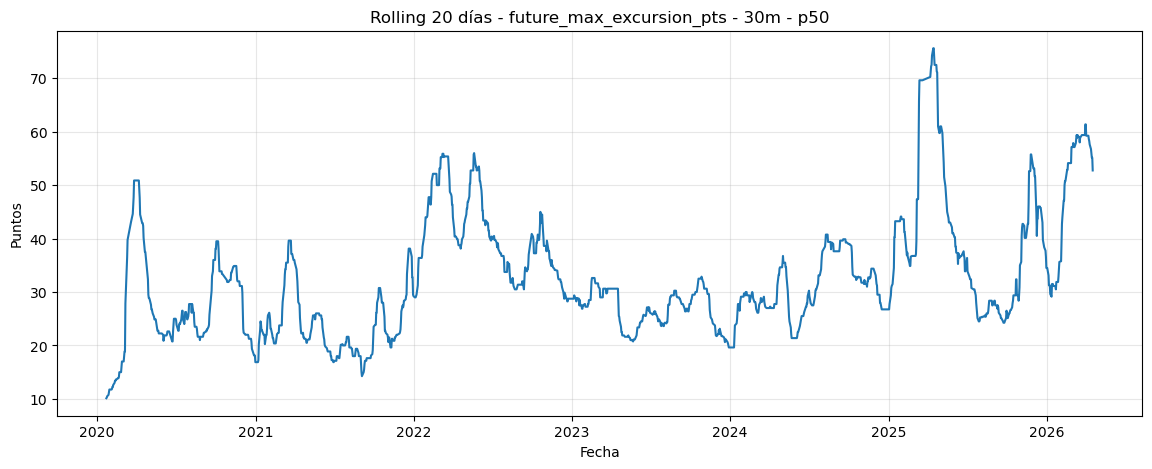

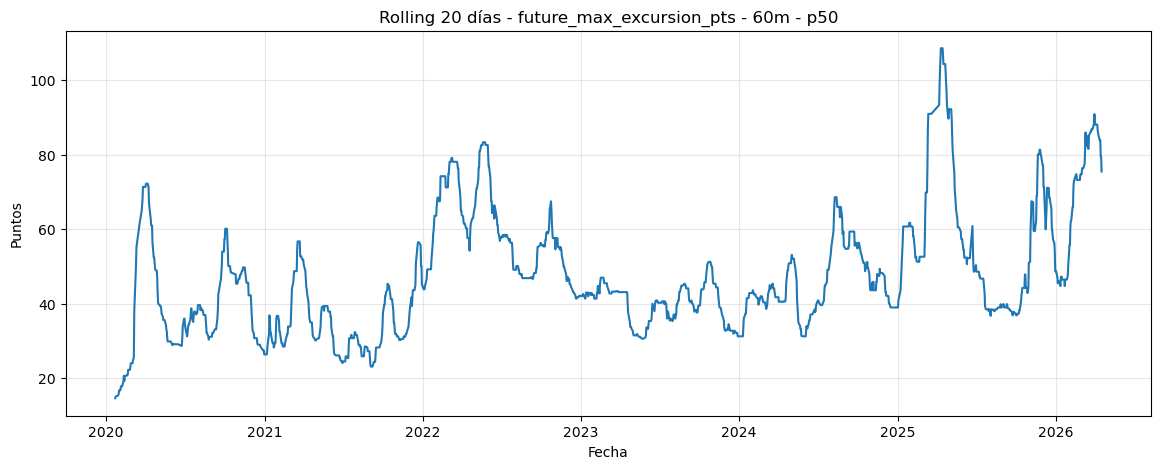

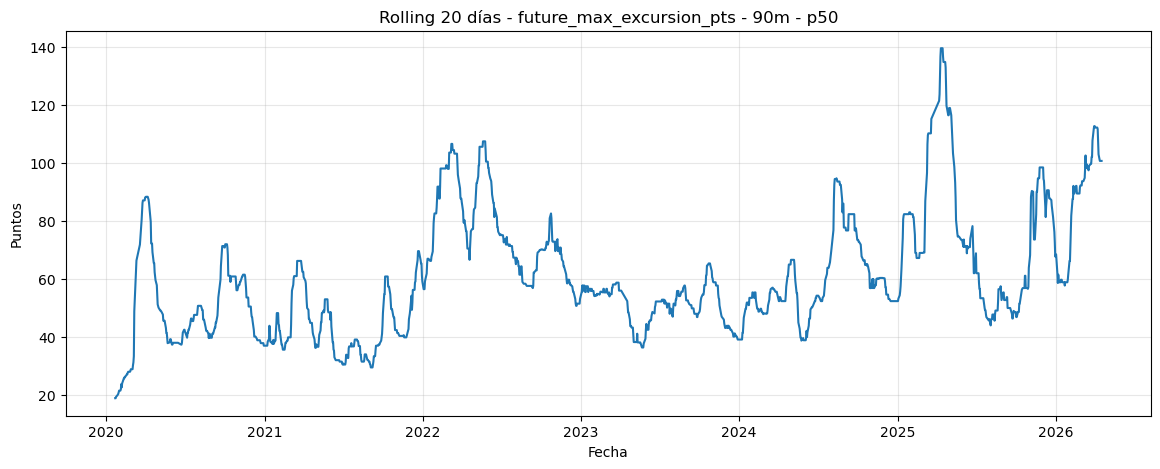

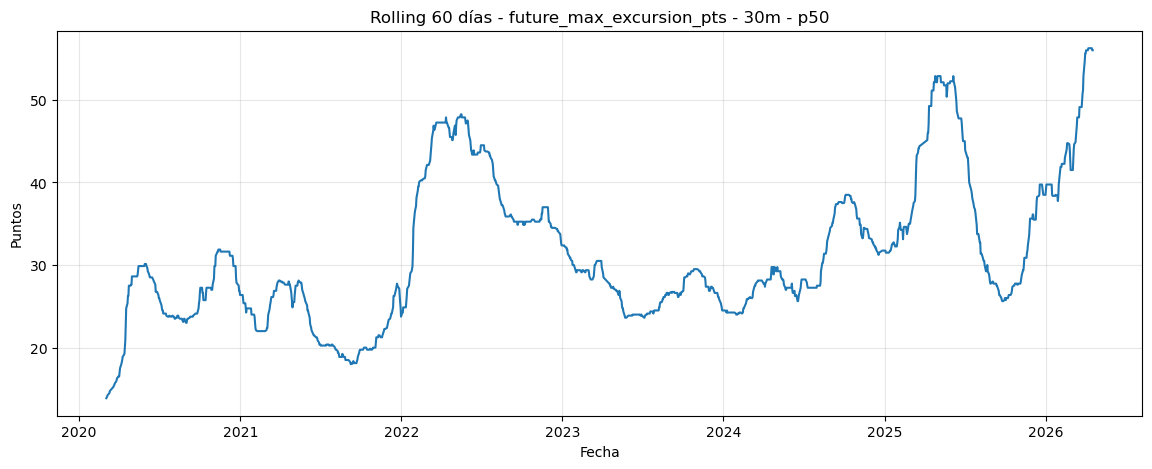

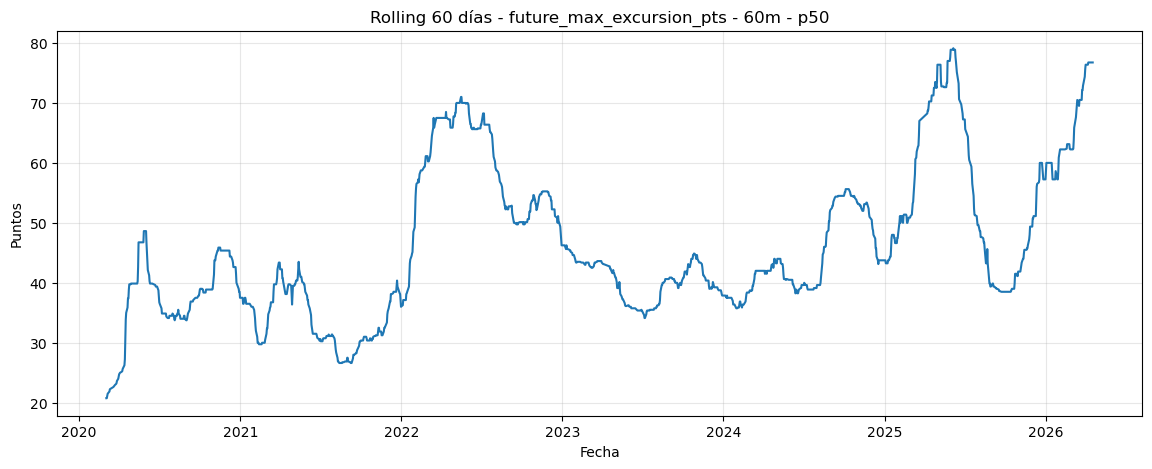

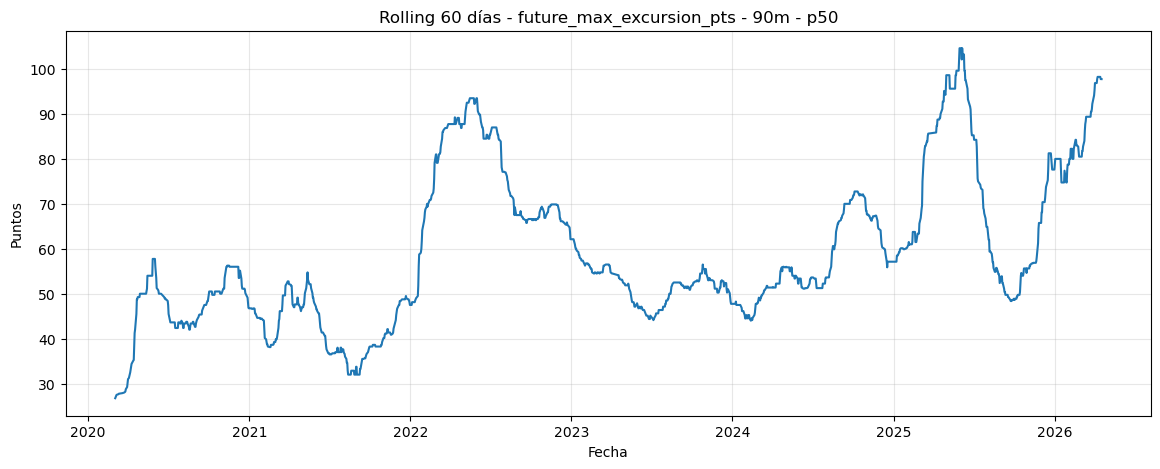

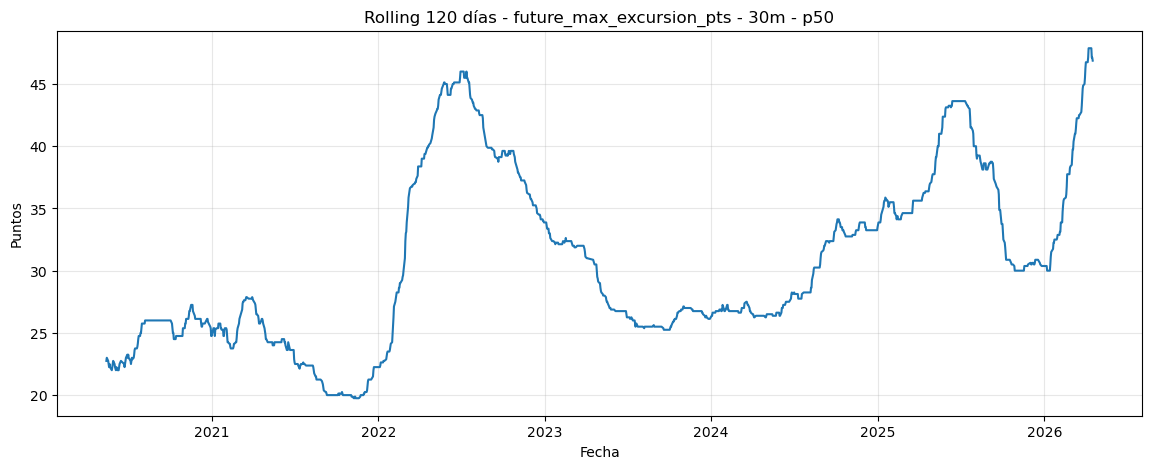

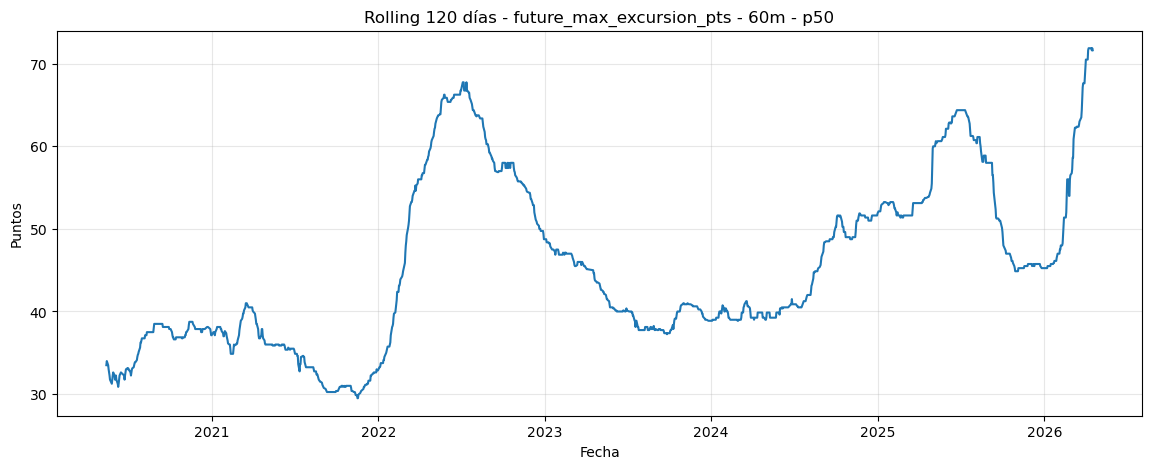

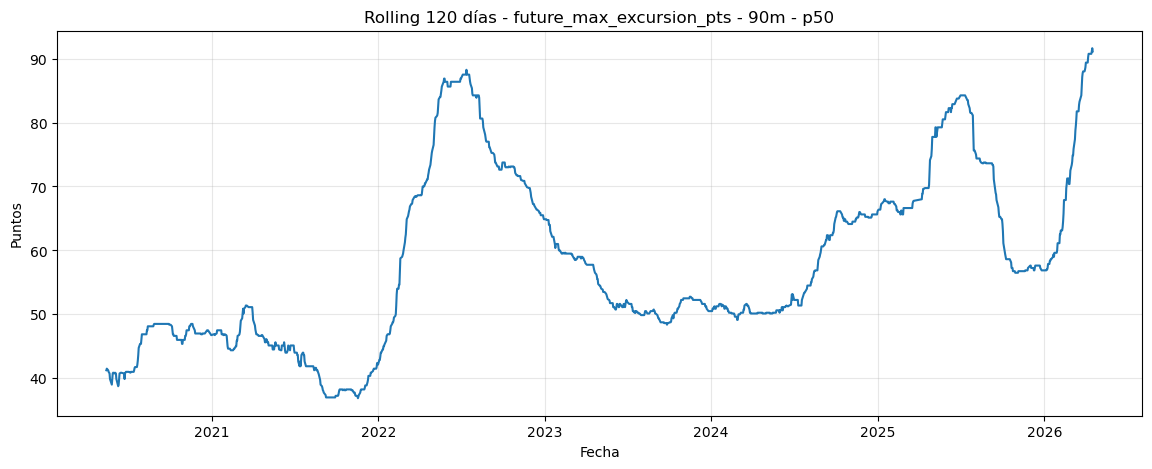

In [194]:
# 13.8 Gráficos rolling de future_max_excursion_pts
# Esto permite ver visualmente cuándo subió o bajó el movimiento futuro.
# ============================================================
#
# Objetivo:
# Visualizar cómo evoluciona la métrica principal en el tiempo.
#
# ============================================================

def plot_rolling_future_max_excursion(window=60, stat="p50"):
    """
    Grafica la evolución rolling de future_max_excursion_pts
    para los horizontes operativos disponibles.
    """

    for h in OPERATIVE_HORIZONS:

        rolling_col = f"roll_{window}d_{ROLLING_MAIN_METRIC_BASE}_{h}m_{stat}"

        if rolling_col not in df_daily_rolling.columns:
            print(f"No existe la columna: {rolling_col}")
            continue

        df_plot = (
            df_daily_rolling[["date_dt", rolling_col]]
            .dropna()
            .copy()
        )

        plt.figure(figsize=(14, 5))
        plt.plot(
            df_plot["date_dt"],
            df_plot[rolling_col]
        )

        plt.title(
            f"Rolling {window} días - {ROLLING_MAIN_METRIC_BASE} - {h}m - {stat}"
        )
        plt.xlabel("Fecha")
        plt.ylabel("Puntos")
        plt.grid(True, alpha=0.3)
        plt.show()


# Gráficos recomendados
plot_rolling_future_max_excursion(window=20, stat="p50")
plot_rolling_future_max_excursion(window=60, stat="p50")
plot_rolling_future_max_excursion(window=120, stat="p50")

In [195]:
# 13.9 Rolling por régimen intradiario
# Como el punto 12 mostró que el régimen es muy importante, también conviene analizar rolling separado por régimen.
# ============================================================
#
# Objetivo:
# Ver si la evolución rolling cambia entre:
# - Overnight
# - Pre-market
# - Opening
# - Regular
# - Closing
#
# ============================================================

if "regime_name" not in df_rolling.columns:
    if "REGIME_NAMES" in globals():
        df_rolling["regime_name"] = df_rolling["regime_id"].map(REGIME_NAMES)
    else:
        df_rolling["regime_name"] = df_rolling["regime_id"].astype(str)

regime_daily_records = []

for h in OPERATIVE_HORIZONS:

    valid_col = f"future_window_valid_{h}m"
    metric_col = f"{ROLLING_MAIN_METRIC_BASE}_{h}m"

    if valid_col not in df_rolling.columns:
        raise ValueError(f"Falta la columna {valid_col}")

    if metric_col not in df_rolling.columns:
        raise ValueError(f"Falta la métrica {metric_col}")

    df_tmp = (
        df_rolling
        .loc[df_rolling[valid_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric_col])
        .copy()
    )

    df_regime_daily = (
        df_tmp
        .groupby(["date", "regime_name"], observed=True)[metric_col]
        .agg(
            count="count",
            p50=lambda x: x.quantile(0.50),
            p95=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )

    df_regime_daily["horizon"] = h
    df_regime_daily["metric_base"] = ROLLING_MAIN_METRIC_BASE
    df_regime_daily["date_dt"] = pd.to_datetime(df_regime_daily["date"])

    regime_daily_records.append(df_regime_daily)

df_regime_daily_rolling = (
    pd.concat(regime_daily_records, axis=0)
    .sort_values(["regime_name", "horizon", "date_dt"])
    .reset_index(drop=True)
)

# Rolling por régimen
for window in ROLLING_WINDOWS_DAYS:

    min_periods = max(
        5,
        int(window * ROLLING_MIN_PERIOD_RATIO)
    )

    for stat in ["p50", "p95"]:

        new_col = f"roll_{window}d_{stat}"

        df_regime_daily_rolling[new_col] = (
            df_regime_daily_rolling
            .groupby(["regime_name", "horizon"], observed=True)[stat]
            .transform(
                lambda x: x.rolling(
                    window=window,
                    min_periods=min_periods
                ).median()
            )
        )

print("Rolling por régimen intradiario")
display(df_regime_daily_rolling.tail())

Rolling por régimen intradiario


,date,regime_name,count,p50,p95,horizon,metric_base,date_dt,roll_20d_p50,roll_20d_p95,roll_60d_p50,roll_60d_p95,roll_120d_p50,roll_120d_p95
19261,2026-04-13,Regular,241,65.50,136.50,90,future_max_excursion_pts,2026-04-13,101.625,179.000,99.125,176.000,92.625,174.125
19262,2026-04-14,Regular,241,73.50,139.50,90,future_max_excursion_pts,2026-04-14,101.625,179.000,99.125,176.000,92.625,174.125
19263,2026-04-15,Regular,241,110.00,141.75,90,future_max_excursion_pts,2026-04-15,105.750,174.875,99.125,175.250,92.625,171.750
19264,2026-04-16,Regular,241,109.75,168.25,90,future_max_excursion_pts,2026-04-16,108.375,174.875,99.625,175.250,93.000,171.750
19265,2026-04-17,Regular,241,65.50,137.25,90,future_max_excursion_pts,2026-04-17,108.375,171.750,99.625,174.875,92.625,169.000


In [196]:
# 13.10 Resumen rolling por régimen
# ============================================================

regime_rolling_summary_records = []

for window in ROLLING_WINDOWS_DAYS:

    rolling_col = f"roll_{window}d_p50"

    if rolling_col not in df_regime_daily_rolling.columns:
        continue

    for h in OPERATIVE_HORIZONS:

        for regime_name, df_group in (
            df_regime_daily_rolling
            .loc[df_regime_daily_rolling["horizon"] == h]
            .groupby("regime_name", observed=True)
        ):

            series = (
                df_group[["date_dt", rolling_col]]
                .dropna()
                .copy()
            )

            if series.empty:
                continue

            max_idx = series[rolling_col].idxmax()
            min_idx = series[rolling_col].idxmin()
            latest_row = series.iloc[-1]

            regime_rolling_summary_records.append({
                "rolling_window_days": window,
                "horizon": h,
                "regime_name": regime_name,

                "latest_value": latest_row[rolling_col],

                "min_value": series.loc[min_idx, rolling_col],
                "min_date": series.loc[min_idx, "date_dt"],

                "max_value": series.loc[max_idx, rolling_col],
                "max_date": series.loc[max_idx, "date_dt"],

                "median_value": series[rolling_col].median(),

                "latest_vs_median": (
                    latest_row[rolling_col] / series[rolling_col].median()
                    if series[rolling_col].median() != 0 else np.nan
                ),

                "max_vs_min": (
                    series.loc[max_idx, rolling_col] / series.loc[min_idx, rolling_col]
                    if series.loc[min_idx, rolling_col] != 0 else np.nan
                ),
            })

df_regime_rolling_summary = pd.DataFrame(regime_rolling_summary_records)

df_regime_rolling_summary = (
    df_regime_rolling_summary
    .sort_values(
        ["rolling_window_days", "horizon", "regime_name"]
    )
    .reset_index(drop=True)
)

print("Resumen rolling por régimen")
display(df_regime_rolling_summary)

Resumen rolling por régimen


,rolling_window_days,horizon,regime_name,latest_value,min_value,min_date,max_value,max_date,median_value,latest_vs_median,max_vs_min
0,20,30,Closing,57.5000,17.2500,2021-08-30,128.0000,2020-03-27,40.7500,1.411043,7.420290
1,20,30,Opening,89.3125,15.2500,2020-01-22,136.6250,2025-04-10,57.5625,1.551574,8.959016
2,20,30,Overnight,37.6875,6.3750,2020-01-22,51.7500,2026-03-27,19.1250,1.970588,8.117647
3,20,30,Pre-market,55.8750,13.2500,2020-01-29,77.4375,2026-04-07,34.5000,1.619565,5.844340
4,20,30,Regular,59.5000,12.1250,2020-01-22,95.6875,2025-04-11,34.9375,1.703041,7.891753
5,20,60,Opening,114.0625,20.6875,2020-01-22,183.6250,2025-04-10,77.1875,1.477733,8.876133
6,20,60,Overnight,59.6250,10.1250,2020-01-24,74.0625,2026-04-01,27.6875,2.153499,7.314815
7,20,60,Pre-market,126.7500,30.5625,2020-01-22,195.3125,2025-12-03,76.6250,1.654160,6.390593
8,20,60,Regular,83.7500,17.2500,2020-01-23,131.5000,2025-04-11,50.2500,1.666667,7.623188
9,20,90,Opening,140.7500,22.2500,2020-01-22,202.5000,2025-04-11,88.6875,1.587033,9.101124


## Observaciones y conclusiones del análisis rolling

El análisis rolling permite observar cómo fue cambiando el comportamiento del MNQ a lo largo del tiempo, sin depender únicamente de cortes fijos como año, trimestre o contrato.

A diferencia de los análisis anteriores, que miraban bloques cerrados, el rolling muestra la evolución del mercado mediante ventanas móviles de `20`, `60` y `120` días. Esto permite detectar si los cambios fueron puntuales, graduales o persistentes.

En la métrica principal, `future_max_excursion_pts`, se observa que los valores recientes se encuentran claramente por encima de su mediana histórica. Esto ocurre en los tres horizontes operativos (`30m`, `60m` y `90m`) y en las tres ventanas rolling analizadas (`20`, `60` y `120` días).

Por ejemplo, en el horizonte de `30m`, la ventana rolling de `60` días tiene un valor reciente de `56.00` puntos, frente a una mediana histórica de `28.625`. Esto representa casi el doble del valor típico histórico. En `60m`, el valor reciente es `76.75` frente a una mediana de `42.50`, y en `90m` es `97.75` frente a una mediana de `53.875`.

Esto indica que el mercado reciente no está en una zona normal o promedio, sino en un contexto de movimiento elevado.

También se observa que las ventanas cortas de `20` días son mucho más sensibles a eventos extremos. Sus diferencias entre máximos y mínimos son muy grandes, con ratios cercanos a `7` veces en los tres horizontes. Esto significa que una ventana corta detecta muy bien los cambios bruscos, pero también es más ruidosa.

Las ventanas de `60` días muestran una lectura más equilibrada. Siguen capturando los períodos de mayor movimiento, pero con menos ruido que las ventanas de `20` días. Por eso, la ventana rolling de `60` días parece especialmente útil como diagnóstico operativo.

Las ventanas de `120` días son más suaves y muestran cambios más persistentes. En este caso, los valores máximos aparecen principalmente en el tramo reciente de `2026`, lo que sugiere que el aumento del movimiento no fue solamente un evento aislado, sino una condición que se mantuvo durante varios meses.

El análisis de períodos extremos confirma que `2025Q2`, especialmente abril de `2025`, fue uno de los tramos más agresivos del dataset. Los máximos rolling de corto plazo se concentran en fechas como `2025-04-10`, `2025-04-11`, `2025-04-14`, `2025-04-15` y `2025-04-16`.

Por otro lado, los máximos rolling de ventanas más largas aparecen hacia `2026Q2`, aunque debe recordarse que `2026Q2` es un período parcial. Aun así, estos valores rolling reflejan que el tramo reciente del dataset viene precedido por una etapa de alta actividad.

El análisis rolling por régimen confirma nuevamente que el régimen intradiario es muy importante. `Opening` y `Pre-market` concentran los mayores valores absolutos, especialmente en los horizontes de `60m` y `90m`.

En el horizonte de `30m`, `Opening` sigue siendo el régimen más fuerte. En los horizontes más largos, `Pre-market` gana mucha relevancia y alcanza valores rolling muy altos, especialmente en `90m`.

`Overnight` sigue siendo el régimen más tranquilo en términos absolutos. Sin embargo, su valor reciente está muy por encima de su propia mediana histórica. Esto significa que incluso los períodos normalmente tranquilos están mostrando más movimiento que antes.

El régimen `Regular` queda en una zona intermedia. No suele ser tan fuerte como `Opening` o `Pre-market`, pero también muestra valores recientes elevados frente a su historia.

El régimen `Closing` aparece principalmente en el horizonte de `30m`, ya que en horizontes más largos hay menos ventanas futuras válidas antes del cierre del día. Por eso debe interpretarse con mayor cautela.

En conjunto, el análisis rolling confirma que el comportamiento del mercado no cambia solamente cuando cambia el año, el trimestre o el contrato. También existen períodos donde el movimiento aumenta o disminuye de forma progresiva.

La conclusión principal es que el dataset presenta cambios temporales relevantes. El mercado reciente, especialmente entre `2025` y `2026`, se encuentra en una zona de mayor movimiento que la mediana histórica. Esto refuerza la necesidad de una validación temporal y contextual en las siguientes etapas del proyecto.

**Lectura rápida**


1. El rolling confirma que el mercado cambia con el tiempo.
2. El mercado reciente está muy por encima de su mediana histórica.
3. 2025Q2, especialmente abril de 2025, fue un período muy extremo.
4. El tramo reciente de 2026 también aparece como una zona de movimiento alto.
5. La ventana de 20 días detecta extremos, pero es más ruidosa.
6. La ventana de 60 días parece la más equilibrada para diagnóstico.
7. La ventana de 120 días muestra cambios más persistentes.
8. Opening sigue siendo muy fuerte en 30m y 60m.
9. Pre-market gana mucha importancia en 60m y 90m.
10. Overnight sigue siendo más tranquilo, pero también está elevado recientemente.
11. Regular está en una zona intermedia.
12. El mercado actual no parece estar en un contexto promedio.


**Conclusión operativa**


* El análisis rolling confirma que no alcanza con mirar promedios globales.
* El mercado tiene períodos tranquilos y períodos mucho más agresivos.
* Actualmente, el dataset termina en una zona de movimiento elevado.
* Esto significa que un modelo entrenado en períodos tranquilos podría fallar si luego enfrenta un mercado como 2025 o 2026.
* Por eso, más adelante, cuando entrenemos modelos, será importante validar si funcionan en períodos normales y también en períodos de alta volatilidad.

La idea más simple sería esta:

El rolling nos muestra la película del mercado. Y esa película dice que el MNQ no se movió siempre igual:
hubo etapas tranquilas, etapas agresivas, y el tramo reciente está entre los más exigentes del dataset.


El siguiente paso lógico, después del rolling, sería el **punto 14. Evaluación de cambios estructurales**, porque ahora ya tenemos evidencia de que podrían existir cambios importantes en períodos como `2022`, `2025` y `2026`.


# **14. Evaluación de cambios estructurales**

En esta sección se evalúa si el comportamiento del MNQ presenta cambios estructurales relevantes a lo largo del tiempo.

Un cambio estructural ocurre cuando el mercado deja de comportarse como antes y empieza a mostrar una dinámica distinta durante un período relevante.

En términos simples, no buscamos saber si un día fue extremo de forma aislada, sino si hubo etapas donde el mercado se volvió más agresivo, más volátil o más tranquilo de manera persistente.

Hasta este punto ya se observaron señales importantes:

* algunos años, como `2022`, `2025` y `2026`, mostraron mayor movimiento;
* algunos contratos recientes, como `H25`, `M25`, `Z25`, `H26` y `M26`, fueron más activos;
* el análisis rolling mostró que el tramo reciente del dataset se encuentra por encima de su mediana histórica;
* `2025Q2` apareció como un período especialmente extremo;
* los regímenes `Opening` y `Pre-market` concentraron movimientos más altos.

Por lo tanto, este punto busca ordenar esa evidencia y responder preguntas como:

* si existen períodos claramente distintos dentro del dataset;
* si el mercado reciente está en un régimen diferente al histórico;
* si los cambios parecen puntuales o persistentes;
* si `2022`, `2025` y `2026` deben tratarse como períodos especiales;
* si la futura separación entre `train`, `validation` y `test` debe tener en cuenta estos cambios.

Este análisis sigue siendo diagnóstico. No entrena modelos ni define targets finales. Su objetivo es detectar posibles cambios de comportamiento que puedan afectar la validación futura del modelo.


## Códigos

In [197]:
# 14.1 Preparación del análisis de cambios estructurales
# ============================================================
#
# Objetivo:
# Preparar la base diaria para evaluar posibles cambios
# estructurales en el comportamiento del MNQ.
#
# Este bloque:
# - NO entrena modelos
# - NO define targets
# - NO hace trading
# - solo analiza cambios temporales en el dataset
#
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

if "df_daily_rolling" not in globals():
    raise NameError(
        "No existe df_daily_rolling. Primero debe ejecutarse el punto 13."
    )

df_structural = df_daily_rolling.copy()

# Asegurar columna de fecha
if "date_dt" not in df_structural.columns:
    df_structural["date_dt"] = pd.to_datetime(df_structural["date"])

df_structural["date_dt"] = pd.to_datetime(df_structural["date_dt"])

df_structural = (
    df_structural
    .sort_values("date_dt")
    .reset_index(drop=True)
)

# Año, trimestre y año-trimestre
df_structural["year"] = df_structural["date_dt"].dt.year
df_structural["calendar_quarter"] = df_structural["date_dt"].dt.quarter
df_structural["calendar_quarter_name"] = (
    "Q" + df_structural["calendar_quarter"].astype(str)
)
df_structural["year_quarter"] = (
    df_structural["date_dt"].dt.to_period("Q").astype(str)
)

print("Base preparada para cambios estructurales")
print(f"Días: {df_structural.shape[0]:,}")
print(f"Rango: {df_structural['date_dt'].min()} -> {df_structural['date_dt'].max()}")
display(df_structural.head())

Base preparada para cambios estructurales
Días: 1,482
Rango: 2020-01-02 00:00:00 -> 2026-04-17 00:00:00


,date_dt,date,rows,first_timestamp,last_timestamp,year,calendar_quarter_name,year_quarter,close_first,close_last,...,roll_120d_future_max_excursion_pts_60m_p95,roll_120d_future_range_pts_60m_p50,roll_120d_future_range_pts_60m_p95,roll_120d_future_abs_return_pts_90m_p50,roll_120d_future_abs_return_pts_90m_p95,roll_120d_future_max_excursion_pts_90m_p50,roll_120d_future_max_excursion_pts_90m_p95,roll_120d_future_range_pts_90m_p50,roll_120d_future_range_pts_90m_p95,calendar_quarter
0,2020-01-02,2020-01-02,691,2020-01-02 04:30:00-05:00,2020-01-02 16:00:00-05:00,2020,Q1,2020Q1,8813.25,8888.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2020-01-03,2020-01-03,691,2020-01-03 04:30:00-05:00,2020-01-03 16:00:00-05:00,2020,Q1,2020Q1,8779.00,8809.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2020-01-06,2020-01-06,691,2020-01-06 04:30:00-05:00,2020-01-06 16:00:00-05:00,2020,Q1,2020Q1,8727.75,8863.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2020-01-07,2020-01-07,691,2020-01-07 04:30:00-05:00,2020-01-07 16:00:00-05:00,2020,Q1,2020Q1,8884.00,8862.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2020-01-08,2020-01-08,691,2020-01-08 04:30:00-05:00,2020-01-08 16:00:00-05:00,2020,Q1,2020Q1,8833.25,8929.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [198]:
# 14.2 Definición de métricas principales
# ============================================================

if "OPERATIVE_HORIZONS" not in globals():
    raise NameError("No existe OPERATIVE_HORIZONS.")

STRUCTURAL_MAIN_METRIC_BASE = "future_max_excursion_pts"

STRUCTURAL_STATS = ["p50", "p95"]

STRUCTURAL_ROLLING_WINDOWS = [20, 60, 120]

structural_metric_cols = []

for h in OPERATIVE_HORIZONS:
    for stat in STRUCTURAL_STATS:
        col = f"{STRUCTURAL_MAIN_METRIC_BASE}_{h}m_daily_{stat}"
        if col in df_structural.columns:
            structural_metric_cols.append(col)

print("Métricas diarias usadas para cambios estructurales:")
for col in structural_metric_cols:
    print(col)

Métricas diarias usadas para cambios estructurales:
future_max_excursion_pts_30m_daily_p50
future_max_excursion_pts_30m_daily_p95
future_max_excursion_pts_60m_daily_p50
future_max_excursion_pts_60m_daily_p95
future_max_excursion_pts_90m_daily_p50
future_max_excursion_pts_90m_daily_p95


In [199]:
# 14.3 Definición de períodos candidatos
# ============================================================
#
# Estos cortes NO son definitivos.
# Son fechas candidatas para comparar antes/después.
#
# Se basan en evidencia previa:
# - 2022 aparece como año activo
# - 2025 aparece como año extremo
# - 2025Q2 concentra eventos fuertes
# - 2026 aparece como tramo reciente elevado
#
# ============================================================

STRUCTURAL_CANDIDATE_DATES = {
    "Inicio 2022": "2022-01-01",
    "Inicio 2025": "2025-01-01",
    "Inicio 2025Q2": "2025-04-01",
    "Inicio 2026": "2026-01-01",
}

df_candidate_dates = pd.DataFrame([
    {
        "candidate_name": name,
        "candidate_date": pd.to_datetime(date),
    }
    for name, date in STRUCTURAL_CANDIDATE_DATES.items()
])

print("Fechas candidatas a cambio estructural")
display(df_candidate_dates)

Fechas candidatas a cambio estructural


,candidate_name,candidate_date
0,Inicio 2022,2022-01-01
1,Inicio 2025,2025-01-01
2,Inicio 2025Q2,2025-04-01
3,Inicio 2026,2026-01-01


In [200]:
# 14.4 Comparación antes/después por fecha candidata
# ============================================================

structural_comparison_records = []

for candidate_name, candidate_date in STRUCTURAL_CANDIDATE_DATES.items():

    candidate_date = pd.to_datetime(candidate_date)

    for h in OPERATIVE_HORIZONS:

        for stat in STRUCTURAL_STATS:

            metric_col = f"{STRUCTURAL_MAIN_METRIC_BASE}_{h}m_daily_{stat}"

            if metric_col not in df_structural.columns:
                continue

            df_before = (
                df_structural
                .loc[df_structural["date_dt"] < candidate_date, metric_col]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )

            df_after = (
                df_structural
                .loc[df_structural["date_dt"] >= candidate_date, metric_col]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )

            if len(df_before) == 0 or len(df_after) == 0:
                continue

            before_median = df_before.median()
            after_median = df_after.median()

            structural_comparison_records.append({
                "candidate_name": candidate_name,
                "candidate_date": candidate_date,
                "horizon": h,
                "stat": stat,
                "metric_col": metric_col,

                "n_before": len(df_before),
                "n_after": len(df_after),

                "before_median": before_median,
                "after_median": after_median,

                "after_vs_before": (
                    after_median / before_median
                    if before_median != 0 else np.nan
                ),

                "before_p75": df_before.quantile(0.75),
                "after_p75": df_after.quantile(0.75),

                "before_p90": df_before.quantile(0.90),
                "after_p90": df_after.quantile(0.90),
            })

df_structural_before_after = pd.DataFrame(structural_comparison_records)

df_structural_before_after = (
    df_structural_before_after
    .sort_values(["candidate_date", "horizon", "stat"])
    .reset_index(drop=True)
)

print("Comparación antes/después por fecha candidata")
display(df_structural_before_after)

Comparación antes/después por fecha candidata


,candidate_name,candidate_date,horizon,stat,metric_col,n_before,n_after,before_median,after_median,after_vs_before,before_p75,after_p75,before_p90,after_p90
0,Inicio 2022,2022-01-01,30,p50,future_max_excursion_pts_30m_daily_p50,469,1013,23.2500,33.0000,1.419355,33.0000,43.00000,44.2500,57.9500
1,Inicio 2022,2022-01-01,30,p95,future_max_excursion_pts_30m_daily_p95,469,1013,64.5000,95.2500,1.476744,86.2500,125.75000,114.8000,168.3000
2,Inicio 2022,2022-01-01,60,p50,future_max_excursion_pts_60m_daily_p50,469,1013,34.5000,48.7500,1.413043,48.0000,65.00000,63.8500,86.0000
3,Inicio 2022,2022-01-01,60,p95,future_max_excursion_pts_60m_daily_p95,469,1013,91.8750,131.8750,1.435374,126.0000,181.12500,167.8000,242.3500
4,Inicio 2022,2022-01-01,90,p50,future_max_excursion_pts_90m_daily_p50,469,1013,44.0000,62.2500,1.414773,61.5000,85.25000,81.8000,109.9500
5,Inicio 2022,2022-01-01,90,p95,future_max_excursion_pts_90m_daily_p95,469,1013,106.5000,155.7500,1.462441,148.2500,214.50000,195.0500,283.3500
6,Inicio 2025,2025-01-01,30,p50,future_max_excursion_pts_30m_daily_p50,1185,297,28.5000,41.0000,1.438596,37.0000,56.50000,47.7500,71.5000
7,Inicio 2025,2025-01-01,30,p95,future_max_excursion_pts_30m_daily_p95,1185,297,79.2500,121.2500,1.529968,104.2500,160.75000,132.0000,191.7000
8,Inicio 2025,2025-01-01,60,p50,future_max_excursion_pts_60m_daily_p50,1185,297,42.2500,61.2500,1.449704,55.2500,83.25000,71.4000,103.8500
9,Inicio 2025,2025-01-01,60,p95,future_max_excursion_pts_60m_daily_p95,1185,297,109.3750,170.7500,1.561143,147.2500,228.75000,197.4250,292.9750


In [201]:
# 14.5 Resumen compacto de cambios estructurales
# ============================================================

df_structural_compact = (
    df_structural_before_after
    .loc[df_structural_before_after["stat"] == "p50"]
    .copy()
    .sort_values(
        ["candidate_name", "horizon"]
    )
    .reset_index(drop=True)
)

print("Resumen compacto - cambios estructurales")
display(df_structural_compact)

Resumen compacto - cambios estructurales


,candidate_name,candidate_date,horizon,stat,metric_col,n_before,n_after,before_median,after_median,after_vs_before,before_p75,after_p75,before_p90,after_p90
0,Inicio 2022,2022-01-01,30,p50,future_max_excursion_pts_30m_daily_p50,469,1013,23.250,33.000,1.419355,33.0000,43.0000,44.250,57.950
1,Inicio 2022,2022-01-01,60,p50,future_max_excursion_pts_60m_daily_p50,469,1013,34.500,48.750,1.413043,48.0000,65.0000,63.850,86.000
2,Inicio 2022,2022-01-01,90,p50,future_max_excursion_pts_90m_daily_p50,469,1013,44.000,62.250,1.414773,61.5000,85.2500,81.800,109.950
3,Inicio 2025,2025-01-01,30,p50,future_max_excursion_pts_30m_daily_p50,1185,297,28.500,41.000,1.438596,37.0000,56.5000,47.750,71.500
4,Inicio 2025,2025-01-01,60,p50,future_max_excursion_pts_60m_daily_p50,1185,297,42.250,61.250,1.449704,55.2500,83.2500,71.400,103.850
5,Inicio 2025,2025-01-01,90,p50,future_max_excursion_pts_90m_daily_p50,1185,297,54.000,78.500,1.453704,70.7500,105.0000,93.250,132.450
6,Inicio 2025Q2,2025-04-01,30,p50,future_max_excursion_pts_30m_daily_p50,1238,244,29.000,39.875,1.375000,37.7500,55.5625,49.250,69.925
7,Inicio 2025Q2,2025-04-01,60,p50,future_max_excursion_pts_60m_daily_p50,1238,244,43.125,59.625,1.382609,56.4375,79.5000,73.075,101.250
8,Inicio 2025Q2,2025-04-01,90,p50,future_max_excursion_pts_90m_daily_p50,1238,244,55.000,74.875,1.361364,72.1875,102.3125,94.750,130.225
9,Inicio 2026,2026-01-01,30,p50,future_max_excursion_pts_30m_daily_p50,1412,70,29.500,52.875,1.792373,39.0000,62.8750,52.200,72.050


In [202]:
# 14.6 Detección simple de zonas elevadas por rolling
# ============================================================
#
# Objetivo:
# Marcar días donde el rolling está por encima de umbrales históricos.
#
# Reglas:
# - alto     : rolling >= percentil 75 histórico
# - extremo  : rolling >= percentil 90 histórico
#
# ============================================================

structural_zone_records = []

for window in STRUCTURAL_ROLLING_WINDOWS:

    for h in OPERATIVE_HORIZONS:

        rolling_col = (
            f"roll_{window}d_"
            f"{STRUCTURAL_MAIN_METRIC_BASE}_{h}m_p50"
        )

        if rolling_col not in df_structural.columns:
            continue

        series = (
            df_structural[["date_dt", "year", "year_quarter", rolling_col]]
            .dropna()
            .copy()
        )

        if series.empty:
            continue

        p75 = series[rolling_col].quantile(0.75)
        p90 = series[rolling_col].quantile(0.90)

        series["zone"] = np.select(
            [
                series[rolling_col] >= p90,
                series[rolling_col] >= p75,
            ],
            [
                "extremo",
                "alto",
            ],
            default="normal"
        )

        zone_summary = (
            series
            .groupby(["year", "year_quarter", "zone"], observed=True)
            .agg(
                days=("date_dt", "count"),
                value_median=(rolling_col, "median"),
                value_max=(rolling_col, "max"),
                first_date=("date_dt", "min"),
                last_date=("date_dt", "max"),
            )
            .reset_index()
        )

        zone_summary["rolling_window_days"] = window
        zone_summary["horizon"] = h
        zone_summary["rolling_col"] = rolling_col
        zone_summary["p75_threshold"] = p75
        zone_summary["p90_threshold"] = p90

        structural_zone_records.append(zone_summary)

df_structural_zones = (
    pd.concat(structural_zone_records, axis=0)
    .reset_index(drop=True)
)

df_structural_zones = (
    df_structural_zones
    .sort_values(
        ["rolling_window_days", "horizon", "zone", "days"],
        ascending=[True, True, True, False]
    )
    .reset_index(drop=True)
)

print("Zonas rolling por año-trimestre")
display(df_structural_zones)

Zonas rolling por año-trimestre


,year,year_quarter,zone,days,value_median,value_max,first_date,last_date,rolling_window_days,horizon,rolling_col,p75_threshold,p90_threshold
0,2022,2022Q2,alto,40,41.375,46.875,2022-04-01,2022-06-30,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
1,2024,2024Q3,alto,38,39.250,40.750,2024-08-01,2024-09-30,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
2,2025,2025Q4,alto,25,42.750,46.500,2025-11-04,2025-12-29,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
3,2022,2022Q4,alto,23,39.750,45.000,2022-10-03,2022-11-09,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
4,2025,2025Q1,alto,22,43.250,47.375,2025-01-14,2025-03-10,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,2025,2025Q1,normal,29,66.625,66.875,2025-01-02,2025-03-17,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25
364,2020,2020Q2,normal,28,40.750,41.500,2020-05-14,2020-06-30,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25
365,2026,2026Q1,normal,28,59.500,65.750,2026-01-02,2026-02-12,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25
366,2022,2022Q4,normal,13,65.875,67.000,2022-12-09,2022-12-30,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25


In [203]:
# 14.7 Períodos extremos más persistentes
# ============================================================

df_structural_extreme_zones = (
    df_structural_zones
    .loc[df_structural_zones["zone"] == "extremo"]
    .copy()
    .sort_values(
        ["rolling_window_days", "horizon", "days", "value_median"],
        ascending=[True, True, False, False]
    )
    .reset_index(drop=True)
)

print("Períodos extremos más persistentes")
display(df_structural_extreme_zones)

Períodos extremos más persistentes


,year,year_quarter,zone,days,value_median,value_max,first_date,last_date,rolling_window_days,horizon,rolling_col,p75_threshold,p90_threshold
0,2022,2022Q1,extremo,34,52.1250,55.875,2022-02-04,2022-03-29,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
1,2026,2026Q1,extremo,32,57.5000,61.375,2026-02-11,2026-03-31,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
2,2025,2025Q2,extremo,27,61.0000,75.625,2025-04-07,2025-05-14,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
3,2022,2022Q2,extremo,20,52.7500,56.000,2022-05-09,2022-06-07,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
4,2026,2026Q2,extremo,12,57.9375,61.375,2026-04-01,2026-04-17,20,30,roll_20d_future_max_excursion_pts_30m_p50,37.625,47.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2022,2022Q3,extremo,34,84.3750,88.250,2022-07-01,2022-08-19,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25
60,2025,2025Q2,extremo,33,81.6250,83.750,2025-05-07,2025-06-27,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25
61,2025,2025Q3,extremo,16,83.5000,84.250,2025-07-01,2025-07-28,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25
62,2026,2026Q1,extremo,13,84.2500,88.250,2026-03-11,2026-03-31,120,90,roll_120d_future_max_excursion_pts_90m_p50,67.250,79.25


In [204]:
# 14.8 Estado reciente del mercado
# ============================================================
#
# Objetivo:
# Saber si el final del dataset está en zona normal, alta o extrema.
#
# ============================================================

recent_state_records = []

for window in STRUCTURAL_ROLLING_WINDOWS:

    for h in OPERATIVE_HORIZONS:

        rolling_col = (
            f"roll_{window}d_"
            f"{STRUCTURAL_MAIN_METRIC_BASE}_{h}m_p50"
        )

        if rolling_col not in df_structural.columns:
            continue

        series = (
            df_structural[["date_dt", rolling_col]]
            .dropna()
            .copy()
        )

        if series.empty:
            continue

        latest_row = series.iloc[-1]

        p50 = series[rolling_col].quantile(0.50)
        p75 = series[rolling_col].quantile(0.75)
        p90 = series[rolling_col].quantile(0.90)

        latest_value = latest_row[rolling_col]

        if latest_value >= p90:
            current_zone = "extremo"
        elif latest_value >= p75:
            current_zone = "alto"
        else:
            current_zone = "normal"

        recent_state_records.append({
            "rolling_window_days": window,
            "horizon": h,
            "latest_date": latest_row["date_dt"],
            "latest_value": latest_value,
            "historical_p50": p50,
            "historical_p75": p75,
            "historical_p90": p90,
            "latest_vs_p50": (
                latest_value / p50
                if p50 != 0 else np.nan
            ),
            "current_zone": current_zone,
        })

df_structural_recent_state = pd.DataFrame(recent_state_records)

df_structural_recent_state = (
    df_structural_recent_state
    .sort_values(["rolling_window_days", "horizon"])
    .reset_index(drop=True)
)

print("Estado reciente del mercado")
display(df_structural_recent_state)

Estado reciente del mercado


,rolling_window_days,horizon,latest_date,latest_value,historical_p50,historical_p75,historical_p90,latest_vs_p50,current_zone
0,20,30,2026-04-17,52.750,29.500,37.625,47.750,1.788136,extremo
1,20,60,2026-04-17,75.500,43.625,55.500,71.000,1.730659,extremo
2,20,90,2026-04-17,100.625,56.000,70.875,91.750,1.796875,extremo
3,60,30,2026-04-17,56.000,28.625,35.875,44.625,1.956332,extremo
4,60,60,2026-04-17,76.750,42.500,53.250,66.375,1.805882,extremo
5,60,90,2026-04-17,97.750,53.875,68.125,86.875,1.814385,extremo
6,120,30,2026-04-17,46.875,28.125,35.250,41.000,1.666667,extremo
7,120,60,2026-04-17,71.625,41.375,52.125,61.125,1.731118,extremo
8,120,90,2026-04-17,91.125,53.125,67.250,79.250,1.715294,extremo


## Observaciones y conclusiones de la evaluación de cambios estructurales


La evaluación de cambios estructurales confirma que el comportamiento del MNQ no fue estable a lo largo de todo el período analizado. Existen etapas donde el movimiento futuro fue claramente superior al comportamiento histórico previo.

La primera señal importante aparece a partir de `2022`. Al comparar el período anterior y posterior al inicio de `2022`, la mediana diaria de `future_max_excursion_pts` aumenta aproximadamente un `41%` en los tres horizontes operativos. En `30m`, el ratio `after_vs_before` es `1.419`; en `60m` es `1.413`; y en `90m` es `1.415`. Esto indica que `2022` marca un cambio relevante respecto al período `2020-2021`.

La segunda señal importante aparece a partir de `2025`. Desde el inicio de `2025`, la mediana diaria aumenta aproximadamente entre `44%` y `45%` respecto al período anterior. Este incremento es consistente en los tres horizontes: `1.439` en `30m`, `1.450` en `60m` y `1.454` en `90m`. Esto confirma que `2025` representa una etapa de mayor movimiento futuro.

El inicio de `2025Q2` también muestra un aumento relevante, aunque algo menor que el observado desde el inicio de `2025`. Los ratios `after_vs_before` se ubican entre `1.36` y `1.38`, lo que confirma que el segundo trimestre de `2025` concentró un período de alta actividad, especialmente en las colas y eventos extremos.

El cambio más fuerte aparece a partir de `2026`. Desde el inicio de `2026`, el movimiento futuro aumenta de forma muy marcada: `1.792` veces en `30m`, `1.674` veces en `60m` y `1.672` veces en `90m`. Sin embargo, este resultado debe interpretarse con cautela porque `2026` contiene solo `70` días disponibles y corresponde a un tramo parcial del dataset.

El análisis de períodos extremos persistentes refuerza esta lectura. Los períodos que más aparecen en zona extrema son principalmente `2022Q1`, `2022Q2`, `2022Q3`, `2025Q2`, `2025Q3`, `2026Q1` y `2026Q2`. Esto muestra que los cambios no se explican solamente por días aislados, sino por zonas de mercado con movimiento elevado durante varias jornadas consecutivas.

`2025Q2` aparece como uno de los períodos más importantes del análisis. Ya había sido detectado en el análisis rolling como una zona especialmente agresiva, y en este punto vuelve a aparecer como período extremo persistente. Esto confirma que abril, mayo y junio de `2025` deben tratarse como una etapa relevante del dataset.

El estado reciente del mercado es especialmente importante. Al cierre del dataset, todas las combinaciones de ventana rolling y horizonte operativo se encuentran en zona `extremo`. Esto ocurre tanto en ventanas cortas de `20` días como en ventanas medias de `60` días y largas de `120` días.

Además, los valores recientes están muy por encima de sus medianas históricas. En `30m`, el valor reciente llega a estar entre `1.66` y `1.96` veces por encima de la mediana histórica, según la ventana rolling. En `60m`, se ubica entre `1.73` y `1.81` veces por encima. En `90m`, se ubica entre `1.71` y `1.80` veces por encima.

Esto indica que el final del dataset no corresponde a un contexto normal o promedio, sino a una zona de alta exigencia operativa.

En conclusión, el análisis muestra evidencia clara de posibles cambios estructurales o, al menos, de cambios persistentes en el comportamiento del mercado. Los períodos más relevantes son `2022`, `2025Q2` y el tramo reciente de `2026`.

Desde el punto de vista metodológico, esto refuerza la necesidad de una validación temporal estricta. No sería adecuado mezclar aleatoriamente datos de todos los períodos, porque eso podría ocultar las diferencias entre mercados tranquilos y mercados extremos.

Para las etapas posteriores del proyecto, especialmente al entrenar modelos, será importante evaluar si el modelo puede generalizar entre períodos de baja, media y alta actividad. Un modelo que funcione bien en el promedio global, pero falle en períodos como `2022`, `2025Q2` o `2026`, no debería considerarse robusto.

**Lectura rápida**

1. Desde 2022 el mercado cambia respecto a 2020-2021.
2. Desde 2025 el movimiento vuelve a aumentar.
3. 2025Q2 aparece como una zona especialmente extrema.
4. 2026 muestra el aumento más fuerte, aunque es un período parcial.
5. El final del dataset está en zona extrema en todos los horizontes.
6. El mercado reciente está entre 1.6 y casi 2 veces por encima de su mediana histórica.
7. Los cambios no parecen ser solo días aislados.
8. Hay períodos persistentes de mayor movimiento.
9. Esto refuerza que no debemos usar split aleatorio.
10. La validación futura debe probar si el modelo sobrevive a distintos regímenes de mercado.

**Conclusión simple**

El MNQ no se comportó igual durante todo el dataset. Hubo etapas tranquilas, después etapas más activas, y el final del dataset está en una zona extrema.
Por eso, el modelo deberá demostrar que funciona en distintos tipos de mercado, no solo en el promedio general.

# **15. Implicancias para entrenamiento del modelo**


En esta sección se resumen las principales implicancias que surgen del análisis exploratorio, temporal, rolling y de cambios estructurales realizado sobre el dataset intradiario del MNQ.

El objetivo de este punto no es entrenar modelos todavía, sino dejar definidas las decisiones metodológicas que deberán respetarse cuando se avance hacia la construcción de targets, selección de variables, separación de datos y entrenamiento predictivo.

Los análisis previos mostraron que el dataset no puede tratarse como una muestra homogénea. El comportamiento del mercado cambia significativamente según el año, el contrato, el régimen intradiario y, especialmente, según combinaciones como `year_regime` y `contract_regime`.

También se observó que el mercado reciente, especialmente entre `2025` y `2026`, se encuentra en una zona de movimiento elevado respecto a la mediana histórica. Esto implica que un modelo entrenado únicamente sobre períodos tranquilos podría no generalizar correctamente hacia períodos más agresivos.

Por este motivo, la principal decisión metodológica es que la futura evaluación del modelo deberá ser temporal y contextual. Es decir, el modelo deberá entrenarse con datos del pasado y evaluarse sobre datos posteriores, respetando el orden natural del tiempo.

No se recomienda utilizar una división aleatoria entre `train`, `validation` y `test`, ya que esto mezclaría períodos tranquilos, moderados y extremos, generando una evaluación poco realista y potencialmente optimista.

La estrategia inicial más razonable será entrenar un modelo general, no modelos separados por año, contrato o régimen. Sin embargo, ese modelo deberá incluir variables de contexto que le permitan distinguir en qué tipo de mercado se encuentra cada observación.

Entre esas variables de contexto podrían incluirse el régimen intradiario, el minuto del día, métricas históricas de volatilidad, rango, volumen y comportamiento reciente del mercado. La condición fundamental es que todas las variables utilizadas como entrada del modelo deben estar disponibles antes del momento de decisión.

Las métricas futuras, como `future_max_excursion_pts`, no deberán usarse como features. Estas métricas sirven para construir o analizar targets, pero no pueden formar parte de las variables predictoras porque contienen información del futuro.

Una vez entrenado el modelo, su desempeño deberá evaluarse no solo de forma global, sino también por año, contrato, régimen intradiario, año-régimen y contrato-régimen. Esto permitirá comprobar si el modelo realmente generaliza o si solo funciona en ciertos contextos específicos.

En síntesis, el objetivo no será construir un modelo que memorice el pasado, sino un modelo capaz de aprender patrones útiles y mantener un desempeño razonable cuando cambian las condiciones del mercado.

**Decisiones principales del punto 15**

1. No usar split aleatorio.
2. Usar separación temporal train / validation / test.
3. Aplicar gap o purga temporal por los horizontes futuros.
4. Entrenar primero un modelo general.
5. Incluir variables de contexto del mercado.
6. No usar información futura como feature.
7. Validar resultados por año, contrato, régimen y combinaciones.
8. No entrenar modelos separados por contrato o régimen en esta etapa inicial.
9. Evaluar robustez, no solo accuracy promedio.
10. Revisar desempeño en períodos tranquilos, moderados y extremos.

**Idea central**

- El modelo debe aprender del pasado,pero demostrar que puede funcionar en el futuro.
- Y no solo en un futuro promedio, sino también en distintos contextos de mercado.

Estructura: 

- 15.1. Decisiones metodológicas derivadas del análisis
- 15.2. Diseño preliminar de train / validation / test
- 15.3. Variables de contexto recomendadas
- 15.4. Reglas para evitar leakage
- 15.5. Validación futura por contexto
- 15.6. Conclusión del capítulo exploratorio

## 15.1. Decisiones metodológicas derivadas del análisis

A partir del análisis exploratorio, temporal, rolling y de cambios estructurales, se pueden establecer varias decisiones metodológicas importantes para las siguientes etapas del proyecto.

La primera decisión es no tratar el dataset como una muestra homogénea. Los resultados mostraron que el comportamiento del MNQ cambia de forma relevante según el año, el régimen intradiario, el contrato y las combinaciones entre estas dimensiones. Por lo tanto, no sería correcto asumir que todas las observaciones representan el mismo tipo de mercado.

La segunda decisión es no utilizar una división aleatoria entre `train`, `validation` y `test`. En datos financieros, y especialmente en series temporales intradiarias, una división aleatoria puede mezclar períodos tranquilos con períodos extremos. Esto puede generar una evaluación artificialmente optimista, porque el modelo estaría aprendiendo y siendo evaluado sobre muestras mezcladas de todo el período histórico.

La tercera decisión es respetar el orden temporal de los datos. El modelo deberá entrenarse con datos del pasado y evaluarse con datos posteriores. Esta lógica replica mejor el escenario real de trading, donde el modelo siempre toma decisiones futuras a partir de información histórica disponible hasta el momento de entrada.

La cuarta decisión es que el modelo inicial debería ser un modelo general. En esta etapa no hay evidencia suficiente para entrenar modelos separados por contrato, régimen, trimestre o familia de contrato. Separar demasiado pronto podría reducir la cantidad de datos disponibles para cada modelo y aumentar el riesgo de sobreajuste.

Sin embargo, que el modelo sea general no significa que deba ignorar el contexto. Por el contrario, el análisis mostró que el contexto es fundamental. Por eso, el modelo debería recibir variables que le permitan identificar en qué entorno se encuentra cada observación, como el régimen intradiario, el minuto del día, métricas históricas de volatilidad, rango, volumen y comportamiento reciente del mercado.

La quinta decisión es separar claramente entre variables históricas y variables futuras. Las variables históricas pueden usarse como entradas del modelo porque representan información disponible antes de tomar una decisión. En cambio, las variables futuras solo deben utilizarse para construir o analizar targets, nunca como features predictivas.

La sexta decisión es evaluar el modelo más allá del resultado promedio. Un modelo puede mostrar buenos resultados globales y, aun así, fallar en contextos específicos, como períodos de alta volatilidad, ciertos contratos o determinados regímenes intradiarios. Por eso, una vez entrenado, el modelo deberá evaluarse por año, contrato, régimen, año-régimen y contrato-régimen.

La séptima decisión es prestar especial atención a los períodos extremos identificados en el análisis, principalmente `2022`, `2025Q2` y el tramo reciente de `2026`. Estos períodos son importantes porque representan condiciones de mercado más exigentes. Un modelo robusto debería poder mantener un desempeño razonable tanto en períodos tranquilos como en períodos de mayor movimiento.

En síntesis, las decisiones metodológicas principales son: entrenar con lógica temporal, evitar divisiones aleatorias, construir primero un modelo general con contexto de mercado, evitar el uso de información futura como entrada y validar el desempeño en distintos escenarios de mercado.

**Lectura rápida**

```text id="7qlfg8"
1. No tratar el dataset como homogéneo.
2. No usar train/test aleatorio.
3. Entrenar con pasado y evaluar con futuro.
4. Empezar con un modelo general.
5. Darle contexto de mercado al modelo.
6. Usar solo variables históricas como features.
7. Usar variables futuras solo para targets.
8. Evaluar el modelo por contexto, no solo por promedio.
9. Prestar atención a 2022, 2025Q2 y 2026.
```

La idea central del 15.1 sería:

```text id="fk20v4"
Primero construiremos un modelo general,
pero no un modelo ciego.

El modelo deberá tener contexto del mercado
y luego demostrar que puede funcionar en distintos períodos,
regímenes y contratos.
```


## 15.2. Diseño preliminar de train / validation / test

A partir del análisis realizado, la separación entre `train`, `validation` y `test` deberá respetar el orden temporal de los datos. Esto significa que el modelo deberá entrenarse con datos del pasado y evaluarse con datos posteriores.

En este proyecto no se recomienda utilizar una división aleatoria. En series financieras, una división aleatoria puede mezclar períodos tranquilos, moderados y extremos dentro de los conjuntos de entrenamiento y evaluación. Esto podría generar una prueba poco realista, porque el modelo tendría contacto indirecto con distintos contextos de mercado desde el inicio.

La lógica correcta debe parecerse más al escenario real de trading: el modelo aprende con información histórica y luego enfrenta datos futuros que no vio durante el entrenamiento.

Por este motivo, la estrategia preliminar más razonable será combinar dos ideas:

```text id="hmh81u"
1. Usar walk-forward durante la etapa de desarrollo.
2. Reservar 2025-2026 como test final.
```

El enfoque walk-forward puede entenderse de forma simple como una serie de pruebas progresivas. El modelo se entrena con un período del pasado y se valida en el período siguiente. Luego se amplía el entrenamiento y se vuelve a validar en un nuevo período posterior.

Una posible estructura sería:

```text id="v9ozv5"
Fold 1:
Train:      2020 - 2021
Validation: 2022

Fold 2:
Train:      2020 - 2022
Validation: 2023

Fold 3:
Train:      2020 - 2023
Validation: 2024
```

Esta etapa funciona como una fase de desarrollo. Permite probar modelos, variables, hiperparámetros y criterios de decisión sin tocar todavía el período más reciente y exigente del dataset.

En términos simples:

```text id="c4dp9n"
Walk-forward = practicar con varios exámenes.
```

Cada fold permite ver si el modelo funciona razonablemente bien en distintos períodos históricos, y no solamente en una única validación.

Después de esa etapa, una vez elegido el modelo y sus parámetros principales, se realiza la evaluación final:

```text id="jkkiwg"
Train final: 2020 - 2024
Test final:  2025 - 2026
```

El período `2025-2026` debe quedar reservado hasta el final porque representa el tramo más reciente y exigente del dataset. Los análisis previos mostraron que `2025Q2` y `2026` se encuentran entre los períodos de mayor movimiento futuro. Por lo tanto, este conjunto será una prueba fuerte de generalización.

En términos simples:

```text id="opk8ze"
Test 2025-2026 = examen final.
```

La idea es no usar `2025-2026` mientras se están probando ideas, ajustando variables o seleccionando modelos. Ese período debe funcionar como una evaluación final, lo más parecida posible a enfrentar datos nuevos en condiciones reales.

Esta estrategia combina robustez y realismo. El walk-forward permite desarrollar el modelo revisando su comportamiento en varios períodos, mientras que el test final en `2025-2026` permite evaluar si el modelo sobrevive en un contexto futuro más difícil.

Además, deberá considerarse una purga temporal o `gap` entre conjuntos cuando corresponda. Esto es importante porque los targets utilizan información futura dentro de ventanas de `30`, `60` o `90` minutos. Aunque los targets fueron construidos sin cruzar días, sigue siendo prudente revisar los bordes entre particiones para evitar cualquier contaminación temporal.

La regla general debe ser simple: ninguna información futura del período de validación o test debe entrar, directa o indirectamente, en el entrenamiento.

En conclusión, el diseño preliminar no será un simple split fijo ni una división aleatoria. La estrategia recomendada será usar `2020-2024` para desarrollar el modelo mediante walk-forward y reservar `2025-2026` como evaluación final. Primero se practica con el pasado; después se rinde el examen final con el período más reciente y exigente.

**Idea central**

```text id="eh5sq9"
Walk-forward = etapa de desarrollo.

Test 2025-2026 = evaluación final.

No son caminos separados.
Se complementan.
```

Y en versión ultra simple:

```text id="pibmne"
Primero practicamos con el pasado.

Después probamos el modelo final en 2025-2026.
```


## 15.3. Variables candidatas de contexto

En esta etapa todavía no corresponde definir las variables finales del modelo, porque aún no se han cerrado los targets operativos ni el horizonte principal de predicción.

La utilidad real de una variable depende directamente de qué se quiera predecir. Una variable puede ser útil para un target direccional como `T2`, pero no necesariamente para un target basado en eventos como `T4`. Del mismo modo, una variable puede aportar señal en un horizonte de `30m`, pero no en uno de `60m` o `90m`.

Por este motivo, en este punto no se busca afirmar cuáles serán las mejores variables del modelo. El objetivo es identificar un conjunto inicial de variables candidatas, razonables y permitidas, que podrían aportar contexto al modelo en etapas posteriores.

En términos simples:

```text
Primero definimos qué queremos predecir.
Después medimos qué variables ayudan a predecirlo.
```

Por lo tanto, las variables mencionadas en esta sección deben entenderse como candidatas de contexto, no como features definitivas.

La selección real deberá realizarse después de definir:

```text
1. Target a predecir: T2, T4 o T5.
2. Horizonte operativo: 30m, 60m o 90m.
3. Conjunto de variables candidatas.
4. Esquema temporal de train, validation y test.
```

Una vez definidos esos elementos, se podrá evaluar qué variables tienen relación real con el target mediante análisis como correlación, Information Coefficient, Spearman rank correlation, mutual information, análisis por bins, AUC univariado, feature importance, permutation importance o SHAP en etapas posteriores.

Sin embargo, ese análisis no deberá hacerse sobre todo el dataset mezclado. Primero deberá evaluarse en `train`, luego comprobarse en `validation` y finalmente confirmarse en `test`. Esto es importante porque una variable puede parecer útil en el dataset completo, pero en realidad estar funcionando solo en un período específico, como `2025Q2` o `2026`.

La pregunta no será solamente:

```text
¿Esta variable se relaciona con el target?
```

También será necesario preguntar:

```text
¿Esa relación se mantiene en distintos años?
¿Se mantiene en distintos regímenes?
¿Se mantiene en distintos contratos?
¿Se mantiene fuera del período de entrenamiento?
```

Aun así, los análisis previos ya permiten definir qué tipo de información debería estar disponible para el modelo. El modelo no debería estar ciego al contexto del mercado. No alcanza con que observe únicamente una vela o un indicador aislado; también debería conocer el entorno donde ocurre esa observación.

Las variables candidatas pueden agruparse en las siguientes categorías.

### 15.3.1. Contexto intradiario

Estas variables describen en qué momento del día ocurre la observación.

Ejemplos:

```text
minute_of_day
regime_id
regime_name
```

El análisis mostró que el régimen intradiario es una dimensión muy importante. `Opening`, `Pre-market`, `Regular` y `Overnight` no tienen el mismo comportamiento. Por eso, el modelo debería tener alguna forma de identificar en qué régimen se encuentra cada observación.

También podría incorporarse una codificación cíclica del minuto del día, por ejemplo mediante seno y coseno, para representar mejor la estructura temporal intradiaria.

### 15.3.2. Contexto histórico reciente

Estas variables describen qué venía haciendo el mercado antes del momento de entrada.

Ejemplos:

```text
hist_return_pts_30m
hist_return_pts_60m
hist_return_pts_90m

hist_range_pts_30m
hist_range_pts_60m
hist_range_pts_90m

hist_realized_vol_30m
hist_realized_vol_60m
hist_realized_vol_90m

hist_volume_sum_30m
hist_volume_sum_60m
hist_volume_sum_90m
```

Estas variables permiten describir si el mercado venía en expansión, en calma, con mayor volatilidad, con poco movimiento, con aumento de volumen o con una estructura más activa.

La condición clave es que estas métricas deben calcularse solo con información pasada o presente, nunca con información futura.

### 15.3.3. Contexto de volatilidad, rango y estructura de vela

El análisis mostró que la magnitud del movimiento futuro cambia mucho según el nivel de actividad del mercado. Por eso, pueden considerarse variables que describan rango, volatilidad y estructura de la vela actual o reciente.

Ejemplos:

```text
abs_delta_close_1m
range_pts
body_pts
close_position
body_to_range
upper_wick_pts
lower_wick_pts
```

Estas variables podrían ayudar a describir si el mercado muestra expansión, indecisión, presión compradora, presión vendedora o ruido de corto plazo.

Sin embargo, todavía no sabemos cuáles de ellas serán realmente útiles. Su utilidad deberá medirse posteriormente contra el target definido.

### 15.3.4. Contexto de volumen

El volumen puede aportar información sobre la intensidad o participación del mercado.

Ejemplos:

```text
volume
log_volume
delta_volume_1m
delta_log_volume_1m
hist_volume_sum_30m
hist_volume_sum_60m
hist_volume_sum_90m
```

Dado que el volumen suele presentar valores extremos, `log_volume` puede ser más estable que el volumen crudo.

La idea es que el modelo pueda diferenciar entre movimientos con bajo volumen y movimientos acompañados por mayor actividad del mercado.

### 15.3.5. Contexto rolling del mercado

El análisis rolling mostró que el mercado puede encontrarse en zonas normales, altas o extremas. Por eso, también pueden considerarse variables que describan el estado reciente del mercado.

Ejemplos:

```text
rolling_volatility_20d
rolling_volatility_60d
rolling_range_20d
rolling_range_60d
rolling_volume_20d
rolling_volume_60d
```

Estas variables permitirían describir si el mercado actual está por encima o por debajo de su comportamiento histórico reciente.

En términos simples, podrían ayudar a que el modelo distinga entre:

```text
mercado tranquilo
mercado normal
mercado activo
mercado extremo
```

### 15.3.6. Contexto temporal amplio

También existen variables que describen el período general del mercado.

Ejemplos:

```text
year
year_quarter
contract
contract_code
```

Estas variables deben tratarse con especial cuidado. No se busca que el modelo memorice años o contratos específicos. Por ejemplo, no queremos que aprenda simplemente que `2026` fue más volátil, porque eso no necesariamente generaliza hacia el futuro.

En una primera etapa, estas variables pueden ser más útiles para diagnóstico, segmentación y validación que como variables predictoras principales.

### 15.3.7. Variables que no deben usarse como features

Es fundamental separar correctamente las variables históricas de las variables futuras.

No deben usarse como entradas del modelo variables como:

```text
future_return_pts
future_abs_return_pts
future_max_excursion_pts
future_range_pts
future_up_excursion_pts
future_down_excursion_pts
```

Estas variables contienen información del futuro. Pueden usarse para construir targets o para analizar el comportamiento posterior de una señal, pero no pueden formar parte de las variables predictoras.

Usarlas como features generaría leakage, es decir, contaminación del entrenamiento con información que no estaría disponible en una operación real.

### Conclusión

En esta etapa no se definen las variables finales del modelo. Se define un universo inicial de variables candidatas de contexto.

La utilidad real de cada variable deberá evaluarse después de definir el target y el horizonte operativo. Recién entonces tendrá sentido medir correlación, Information Coefficient, mutual information, importancia de variables o cualquier otra métrica de relación con el target.

La idea central es construir primero un modelo general, pero no ciego. El modelo debería contar con información histórica y contextual suficiente para interpretar mejor el entorno de mercado, evitando siempre cualquier variable que contenga información futura.

La frase clave del punto sería:

* No estamos eligiendo todavía las mejores variables.
* Estamos definiendo qué variables candidatas tiene sentido evaluar después,
cuando ya sepamos exactamente qué target queremos predecir.


## 15.4. Reglas para evitar leakage

El leakage ocurre cuando, directa o indirectamente, entra información del futuro dentro del entrenamiento del modelo.

En términos simples, el modelo estaría viendo datos que en una operación real todavía no existirían. Esto puede hacer que los resultados parezcan muy buenos durante la evaluación histórica, pero que luego el modelo falle al enfrentarse a datos nuevos.

Por este motivo, antes de entrenar modelos es necesario definir reglas claras para evitar cualquier tipo de contaminación temporal.

La primera regla es que todas las variables predictoras deben estar disponibles antes del momento de decisión. Si una operación se evalúa en el instante `t`, el modelo solo puede usar información observada hasta `t`. No puede usar información de `t+1`, `t+30`, `t+60` o `t+90`.

La segunda regla es no usar variables futuras como features. Variables como:

```text
future_return_pts
future_abs_return_pts
future_max_excursion_pts
future_range_pts
future_up_excursion_pts
future_down_excursion_pts
```

no pueden entrar al modelo como variables predictoras. Estas columnas contienen información posterior al momento de entrada. Solo pueden usarse para construir targets o para analizar el resultado futuro de una señal.

La tercera regla es separar correctamente variables históricas y variables futuras. Las variables históricas, como rangos, retornos, volumen o volatilidad calculados con datos pasados, sí pueden ser candidatas a features. En cambio, las variables que miran hacia adelante solo deben pertenecer al proceso de construcción del target.

La cuarta regla es evitar divisiones aleatorias entre `train`, `validation` y `test`. En series financieras, una división aleatoria puede mezclar observaciones de distintos períodos y generar una evaluación poco realista. La separación debe respetar el orden temporal: entrenar con pasado y evaluar con futuro.

La quinta regla es aplicar una purga temporal o `gap` cuando sea necesario. Como los targets pueden mirar `30`, `60` o `90` minutos hacia adelante, hay que evitar que observaciones cercanas al corte entre `train`, `validation` o `test` compartan información futura con el siguiente conjunto. En este proyecto, los targets fueron construidos sin cruzar días, lo cual reduce este riesgo, pero igualmente los bordes de cada partición deberán revisarse con cuidado.

La sexta regla es calcular transformaciones usando solamente el conjunto correspondiente. Por ejemplo, si se aplica escalado, normalización, imputación, selección de variables o reducción de dimensionalidad, esos procesos deben ajustarse con datos de `train`, no con todo el dataset completo.

Por ejemplo, no sería correcto calcular la media y desviación estándar usando datos de `train`, `validation` y `test` juntos para luego escalar las variables. Eso incorporaría información del futuro dentro del entrenamiento.

La séptima regla es no seleccionar variables usando todo el dataset. El análisis de correlación, Information Coefficient, mutual information o importancia de variables debe hacerse primero en `train` y luego verificarse en `validation`. El conjunto de `test` debe quedar reservado para la evaluación final.

La octava regla es tener cuidado con las métricas rolling. Si una variable rolling se usa como feature, debe calcularse usando únicamente información pasada. No deben usarse ventanas centradas ni estadísticas calculadas con datos futuros.

Por ejemplo, una media móvil de los últimos `60` minutos es válida. En cambio, una media calculada usando `30` minutos antes y `30` minutos después del momento de decisión no sería válida, porque incluiría información futura.

La novena regla es no usar el conjunto de `test` para tomar decisiones de diseño. El período `2025-2026` debe funcionar como evaluación final. No debería usarse para elegir features, ajustar hiperparámetros, cambiar umbrales o modificar reglas de trading.

La décima regla es revisar cualquier variable que parezca demasiado predictiva. Si una variable muestra una relación extremadamente fuerte con el target, debe verificarse que no contenga información futura de forma directa o indirecta.

En conclusión, evitar leakage significa respetar una regla simple: el modelo solo puede aprender con información que habría estado disponible en el momento real de tomar la decisión.

Si una variable mira hacia el futuro, pertenece al target o al análisis posterior, no a las features del modelo.

**Lectura rápida**

1. Leakage = información futura entrando al modelo.
2. El modelo solo puede usar datos disponibles hasta el instante t.
3. Las columnas future_* no pueden ser features.
4. Las variables históricas sí pueden ser candidatas.
5. No usar split aleatorio.
6. Respetar train / validation / test temporal.
7. Aplicar gap o purga si los targets futuros se acercan al borde.
8. Escalado, imputación y selección de variables se ajustan solo con train.
9. El test no se usa para elegir features ni parámetros.
10. Si una variable parece demasiado buena, revisar si tiene leakage.

La regla más simple sería:

* Todo lo que el modelo vea debe existir antes de tomar la decisión.
* Todo lo que ocurra después solo sirve para construir el target.

## 15.5. Validación futura por contexto

Una vez entrenado el modelo, su evaluación no deberá limitarse únicamente al resultado global. En este proyecto, el análisis exploratorio mostró que el comportamiento del MNQ cambia de forma importante según el año, el régimen intradiario, el contrato, el trimestre y las combinaciones entre estas dimensiones.

Por este motivo, un modelo no debería considerarse robusto solo porque obtiene una buena métrica promedio. Es posible que el resultado general sea aceptable, pero que el modelo falle justamente en los períodos más importantes o más exigentes del mercado.

La validación futura deberá responder dos preguntas principales:

```text
¿El modelo funciona razonablemente bien fuera del período de entrenamiento?

¿El modelo mantiene su desempeño en distintos contextos de mercado?
```

La primera pregunta se responde mediante validación temporal, usando el esquema walk-forward y, posteriormente, el test final en `2025-2026`.

La segunda pregunta se responde evaluando los resultados por contexto.

En términos simples, no basta con saber si el modelo funciona “en promedio”. También necesitamos saber si funciona en:

```text
años tranquilos
años volátiles
régimen Overnight
régimen Opening
régimen Pre-market
contratos específicos
períodos extremos como 2025Q2 o 2026
```

### 15.5.1. Validación global

Primero se revisará el desempeño general del modelo sobre cada conjunto de evaluación.

Dependiendo del target elegido, las métricas podrán cambiar. Por ejemplo, si el target es de clasificación, podrían analizarse métricas como:

```text
accuracy
balanced accuracy
precision
recall
F1-score
matriz de confusión
ROC-AUC
PR-AUC
```

Sin embargo, en trading estas métricas no siempre son suficientes. Un modelo puede tener buena precisión estadística y, aun así, no ser rentable o no ser operable.

Por eso, más adelante también deberán evaluarse métricas operativas como:

```text
win rate
loss rate
expectancy
PnL promedio
PnL total
drawdown
relación PnL / drawdown
cantidad de operaciones
```

La validación global sirve como primer filtro, pero no debe ser la única evaluación.

### 15.5.2. Validación por año

El modelo deberá evaluarse por año para comprobar si su desempeño se mantiene en distintos períodos históricos.

Ejemplos de segmentación:

```text
2020
2021
2022
2023
2024
2025
2026
```

Esto es importante porque el análisis previo mostró que el mercado no fue estable durante todo el período. Años como `2022`, `2025` y `2026` presentaron mayor movimiento futuro que otros años más tranquilos.

Si un modelo funciona bien solamente en años tranquilos, pero falla en años más volátiles, no puede considerarse suficientemente robusto.

### 15.5.3. Validación por régimen intradiario

El régimen intradiario fue una de las dimensiones más importantes del análisis. Por eso, el modelo deberá evaluarse separadamente en cada régimen.

Ejemplos:

```text
Overnight
Pre-market
Opening
Regular
Closing
```

Esta validación permitirá saber si el modelo funciona igual en todos los momentos del día o si depende demasiado de un régimen específico.

Por ejemplo, podría ocurrir que el modelo funcione bien en `Opening`, pero mal en `Overnight`. También podría suceder que genere muchas señales en un régimen donde el movimiento futuro suele ser menor.

Esta información será clave para decidir si el modelo debe operar en todos los regímenes o solo en algunos.

### 15.5.4. Validación por contrato

Aunque no se recomienda entrenar modelos separados por contrato en la primera etapa, sí será importante evaluar el desempeño por contrato.

Ejemplos:

```text
H20
M20
U20
Z20
...
H26
M26
```

El objetivo no es que el modelo memorice contratos específicos, sino verificar si su desempeño se mantiene razonablemente estable cuando cambia el contrato activo.

También podrá evaluarse la familia de contrato:

```text
H
M
U
Z
```

Sin embargo, esta segmentación debe interpretarse con cuidado, porque los contratos están mezclados con períodos históricos específicos. Por ejemplo, un contrato puede parecer más difícil no por su letra, sino porque coincidió con un período de mercado más volátil.

### 15.5.5. Validación por combinaciones de contexto

Además de evaluar dimensiones por separado, será importante revisar combinaciones.

Ejemplos:

```text
year + regime
contract + regime
year_quarter
```

Estas combinaciones fueron justamente las que mostraron mayor inestabilidad durante el análisis exploratorio.

Por ejemplo, no es lo mismo evaluar el modelo en:

```text
2021 + Overnight
```

que en:

```text
2026 + Opening
```

Ambos contextos pueden tener comportamientos de mercado muy diferentes.

La validación por combinaciones permitirá detectar debilidades que podrían quedar ocultas en el promedio global.

### 15.5.6. Validación en períodos extremos

El análisis rolling y estructural mostró que ciertos períodos fueron especialmente exigentes, como:

```text
2022
2025Q2
2026
```

Estos períodos deberán revisarse con atención. Un modelo que solo funciona en condiciones normales, pero falla en períodos extremos, puede ser riesgoso para una estrategia real.

Por eso, la validación futura deberá incluir una comparación entre contextos normales, altos y extremos de mercado.

La pregunta principal será:

```text
¿El modelo sigue siendo razonable cuando el mercado se vuelve más agresivo?
```

### 15.5.7. Interpretación de resultados

La validación por contexto no tiene como objetivo complicar el análisis, sino entender mejor el comportamiento real del modelo.

Después de entrenar, podrían aparecer distintos escenarios:

```text
El modelo funciona bien en todos los contextos.
El modelo funciona bien solo en algunos regímenes.
El modelo funciona bien en años tranquilos, pero falla en años extremos.
El modelo tiene buen promedio, pero depende demasiado de pocos períodos.
El modelo genera muchas señales, pero en contextos poco rentables.
```

Cada uno de estos casos llevaría a decisiones distintas. Por ejemplo, limitar horarios de operación, ajustar umbrales, cambiar el target, revisar features o incluso descartar el modelo.

### Conclusión

La validación futura deberá ser temporal y contextual. Temporal, porque el modelo debe entrenarse con pasado y evaluarse con futuro. Contextual, porque el resultado promedio no alcanza para saber si una estrategia es realmente robusta.

Un modelo será más confiable si logra mantener un desempeño razonable en distintos años, regímenes, contratos y períodos de mercado. En cambio, si solo funciona en un contexto específico, deberá tratarse con cautela.

En síntesis, no buscaremos únicamente un modelo con buenas métricas globales. Buscaremos un modelo que pueda demostrar estabilidad fuera del entrenamiento y en distintos escenarios reales de mercado.

**La idea central del punto sería:**

No alcanza con preguntar:
“¿El modelo funciona?”

También hay que preguntar:
“¿Dónde funciona, dónde falla y en qué condiciones deja de ser confiable?”


## 15.6. Conclusión del capítulo exploratorio

El análisis exploratorio permitió comprender mejor la estructura, estabilidad y comportamiento del dataset intradiario del MNQ antes de avanzar hacia el entrenamiento de modelos predictivos.

En primer lugar, se confirmó que el dataset tiene una cobertura temporal consistente, con jornadas completas entre `04:30` y `16:00`, sin problemas relevantes de duplicados, desorden temporal o inconsistencias estructurales. Esto permite utilizar la base de datos como punto de partida confiable para las siguientes etapas del proyecto.

En segundo lugar, el análisis mostró que el mercado no se comporta de manera homogénea a lo largo del tiempo. Existen diferencias importantes entre años, contratos, trimestres, regímenes intradiarios y combinaciones entre estas dimensiones. En particular, los años `2022`, `2025` y el tramo disponible de `2026` muestran condiciones de mercado más activas y exigentes que otros períodos.

El análisis por ventanas operativas también permitió observar que los movimientos futuros cambian según el horizonte evaluado. Los horizontes de `30`, `60` y `90` minutos presentan comportamientos distintos, y las excursiones internas dentro de la ventana futura pueden ser más informativas que el simple retorno entre el precio actual y el cierre del horizonte.

Los análisis de estabilidad, rolling y cambios estructurales reforzaron una conclusión central: el MNQ atraviesa distintos estados de mercado. Algunos períodos son más tranquilos, otros más volátiles y otros claramente extremos. Esto significa que cualquier modelo predictivo deberá ser evaluado con criterios temporales y contextuales, no únicamente mediante métricas globales.

A partir de estos resultados, se definieron varias decisiones metodológicas importantes para la etapa de modelado. La primera es evitar divisiones aleatorias entre `train`, `validation` y `test`. La segunda es usar una validación temporal tipo walk-forward durante el desarrollo del modelo. La tercera es reservar `2025-2026` como test final, ya que representa un período reciente y exigente. La cuarta es comenzar con un modelo general, pero incorporando variables candidatas de contexto para que el modelo no esté ciego al régimen intradiario, la volatilidad, el volumen o el estado reciente del mercado.

También se estableció una regla fundamental: toda variable utilizada como entrada del modelo debe estar disponible antes del momento de decisión. Las variables futuras solo podrán utilizarse para construir targets o analizar resultados posteriores, nunca como features predictivas.

Finalmente, este capítulo deja claro que la próxima etapa no debe comenzar directamente con el entrenamiento de modelos. Antes será necesario definir con precisión los targets operativos, los horizontes de predicción y las reglas de construcción de cada señal. Una vez definidos esos elementos, recién tendrá sentido analizar qué variables candidatas tienen relación real con el target mediante correlación, Information Coefficient, mutual information, análisis por bins o importancia de variables.

En síntesis, el capítulo exploratorio permitió pasar de una base de datos intradiaria validada a un marco metodológico claro para el modelado. El objetivo de la siguiente etapa será construir targets operativos robustos y luego evaluar si existen variables capaces de anticipar esos resultados de manera estable, temporalmente válida y operativamente útil.

Cierre simple: No terminamos este capítulo con un modelo entrenado.

Lo terminamos con algo más importante: una base validada, una comprensión del mercado y reglas claras para entrenar sin contaminar el futuro.

# **16. Resumen final de hallazgos**


El análisis exploratorio del dataset intradiario del MNQ permitió establecer una base sólida antes de avanzar hacia la construcción final de targets y entrenamiento de modelos predictivos.

En primer lugar, se confirmó que la base de datos presenta una estructura temporal consistente. El dataset cuenta con jornadas intradiarias completas entre `04:30` y `16:00`, una frecuencia regular de un minuto, ausencia de duplicados relevantes y una cobertura homogénea entre los años completos disponibles. Esto permite considerar el dataset como una base confiable para las siguientes etapas del proyecto.

En segundo lugar, el análisis por regímenes intradiarios mostró que el comportamiento del mercado cambia de forma importante según el momento del día. Los regímenes `Opening`, `Pre-market`, `Regular`, `Overnight` y `Closing` presentan niveles distintos de movimiento, volumen y comportamiento futuro. Por lo tanto, el régimen intradiario deberá ser considerado como una dimensión importante tanto para el análisis como para la validación futura del modelo.

En tercer lugar, el análisis de ventanas operativas de `30`, `60` y `90` minutos permitió observar que los movimientos futuros no crecen de forma lineal con el horizonte. Los horizontes más largos capturan mayores excursiones, pero también modifican la naturaleza del problema predictivo. Además, las excursiones internas dentro de la ventana futura resultan más informativas que observar únicamente el retorno entre el precio actual y el cierre del horizonte.

En cuarto lugar, el análisis temporal mostró que el mercado no fue homogéneo entre años. Períodos como `2022`, `2025` y el tramo disponible de `2026` presentaron condiciones de mayor movimiento y volatilidad. Esto indica que cualquier modelo entrenado sobre este dataset deberá ser evaluado con cuidado en diferentes períodos históricos.

En quinto lugar, el análisis por contrato y trimestre permitió observar diferencias entre contratos y períodos calendario, aunque estas diferencias parecen estar fuertemente influenciadas por el contexto histórico en el que ocurre cada contrato. Por este motivo, no se recomienda inicialmente entrenar modelos separados por contrato o trimestre, pero sí validar los resultados por estas dimensiones.

En sexto lugar, el análisis de estabilidad mostró que las mayores diferencias aparecen cuando se combinan dimensiones, especialmente `year + regime` y `contract + regime`. Esto significa que el comportamiento del mercado depende más del contexto completo que de una sola variable aislada.

En séptimo lugar, los análisis rolling y de cambios estructurales confirmaron que el mercado atraviesa distintos estados: períodos tranquilos, períodos activos y períodos extremos. En particular, `2025Q2` y el tramo reciente de `2026` aparecen como períodos especialmente exigentes.

A partir de estos hallazgos, se definieron decisiones metodológicas clave para la etapa de modelado. No se utilizará una división aleatoria del dataset. En su lugar, se priorizará una validación temporal tipo walk-forward durante el desarrollo y se reservará `2025-2026` como test final.

También se estableció que el primer enfoque de modelado deberá partir de un modelo general, pero no ciego al contexto. Es decir, el modelo deberá poder recibir variables candidatas que describan el régimen intradiario, el comportamiento histórico reciente, la volatilidad, el volumen y el estado rolling del mercado.

Sin embargo, todavía no se definen features definitivas. La selección real de variables deberá realizarse después de definir los targets y horizontes operativos. Recién entonces tendrá sentido evaluar correlación, Information Coefficient, mutual information, análisis por bins o importancia de variables contra el target seleccionado.

Finalmente, se definieron reglas claras para evitar leakage. Toda variable utilizada como entrada del modelo deberá estar disponible antes del momento de decisión. Las variables futuras solo podrán utilizarse para construir targets o analizar resultados posteriores, nunca como features predictivas.

En síntesis, este capítulo exploratorio permitió pasar de una base de datos intradiaria validada a un marco metodológico robusto para la siguiente etapa. El próximo paso será definir formalmente los targets operativos, seleccionar horizontes de predicción y evaluar qué variables candidatas aportan señal real de forma estable, temporalmente válida y operativamente útil.


# **17. Guardado de resultados**

In [ ]:
# 17. Guardado de resultados
# ============================================================

from pathlib import Path
import json
from datetime import datetime

# ------------------------------------------------------------
# 17.1. Definición de carpeta de salida
# ------------------------------------------------------------

# Si ya existe una ruta base del proyecto, la usamos.
# Si no existe, se crea una carpeta local en el directorio actual.
if "MNQ_INTRADAY_PATH" in globals():
    S02_RESULTS_PATH = MNQ_INTRADAY_PATH / "s02_intraday_data_analysis_results"
else:
    S02_RESULTS_PATH = Path("s02_intraday_data_analysis_results")

S02_RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("Carpeta de resultados creada/verificada:")
print(S02_RESULTS_PATH)


# ------------------------------------------------------------
# 17.2. Tablas a guardar
# ------------------------------------------------------------

# Se listan los DataFrames principales del análisis.
# El código guarda únicamente los que existan en memoria.
dataframes_to_save = {
    # Dataset con métricas de ventanas
    "df_window_metrics": "df_window_metrics",

    # Estabilidad temporal
    "df_stability_summary": "df_stability_summary",
    "df_stability_compact": "df_stability_compact",

    # Rolling analysis
    "df_rolling_summary": "df_rolling_summary",
    "df_rolling_main_summary": "df_rolling_main_summary",
    "df_rolling_extreme_periods": "df_rolling_extreme_periods",
    "df_regime_rolling_summary": "df_regime_rolling_summary",

    # Cambios estructurales
    "df_structural_compact": "df_structural_compact",
    "df_structural_extreme_zones": "df_structural_extreme_zones",
    "df_structural_recent_state": "df_structural_recent_state",
}

saved_files = []

for output_name, variable_name in dataframes_to_save.items():

    if variable_name in globals():

        df_to_save = globals()[variable_name]

        if hasattr(df_to_save, "to_parquet"):

            output_path = S02_RESULTS_PATH / f"{output_name}.parquet"
            df_to_save.to_parquet(output_path, index=True)

            saved_files.append({
                "object": variable_name,
                "file": str(output_path),
                "rows": len(df_to_save),
                "columns": len(df_to_save.columns)
            })

            print(f"Guardado: {output_name}.parquet")

    else:
        print(f"No encontrado en memoria: {variable_name}")


# ------------------------------------------------------------
# 17.3. Guardado de resumen metodológico
# ------------------------------------------------------------

analysis_summary = {
    "notebook": "S02_intraday_data_analysis",
    "created_at": datetime.now().isoformat(timespec="seconds"),

    "dataset_summary": {
        "rows": int(len(mnq_intraday)) if "mnq_intraday" in globals() else None,
        "start": str(mnq_intraday.index.min()) if "mnq_intraday" in globals() else None,
        "end": str(mnq_intraday.index.max()) if "mnq_intraday" in globals() else None,
        "trading_days": int(mnq_intraday["date"].nunique()) if "mnq_intraday" in globals() and "date" in mnq_intraday.columns else None,
        "bars_per_day_expected": 691,
        "intraday_start": "04:30",
        "intraday_end": "16:00",
    },

    "operative_horizons_minutes": [30, 60, 90],

    "main_findings": [
        "El dataset presenta cobertura temporal consistente y estructura intradiaria válida.",
        "El comportamiento del MNQ no es homogéneo entre años, contratos, trimestres y regímenes.",
        "Los regímenes intradiarios son relevantes para explicar diferencias de comportamiento.",
        "Las combinaciones year + regime y contract + regime muestran alta inestabilidad.",
        "Los análisis rolling y estructurales identifican períodos normales, altos y extremos.",
        "2022, 2025Q2 y 2026 aparecen como períodos especialmente relevantes.",
        "Las excursiones futuras internas son más informativas que observar solo el retorno al cierre del horizonte.",
    ],

    "modeling_decisions": [
        "No utilizar split aleatorio.",
        "Usar validación temporal tipo walk-forward durante el desarrollo.",
        "Reservar 2025-2026 como test final.",
        "Comenzar con un modelo general, pero con variables candidatas de contexto.",
        "Evaluar el modelo por año, contrato, régimen, year + regime y contract + regime.",
        "No usar variables futuras como features.",
        "Definir targets y horizontes antes de seleccionar features definitivas.",
    ],

    "next_stage": [
        "Definir targets operativos T2, T4 y T5.",
        "Seleccionar horizontes principales de operación.",
        "Evaluar relación entre variables candidatas y targets.",
        "Entrenar modelos respetando validación temporal y evitando leakage.",
    ],
}

summary_path = S02_RESULTS_PATH / "s02_intraday_analysis_summary.json"

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(
        analysis_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Resumen metodológico guardado:")
print(summary_path)


# ------------------------------------------------------------
# 17.4. Guardado de manifiesto de archivos
# ------------------------------------------------------------

df_saved_files = pd.DataFrame(saved_files)

manifest_path = S02_RESULTS_PATH / "s02_saved_files_manifest.csv"
df_saved_files.to_csv(manifest_path, index=False)

print("Manifiesto de archivos guardado:")
print(manifest_path)

display(df_saved_files)

Carpeta de resultados creada/verificada:
c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\02_mnq_intraday\s02_intraday_data_analysis_results
Guardado: df_window_metrics.parquet
Guardado: df_stability_summary.parquet
Guardado: df_stability_compact.parquet
Guardado: df_rolling_summary.parquet
Guardado: df_rolling_main_summary.parquet
Guardado: df_rolling_extreme_periods.parquet
Guardado: df_regime_rolling_summary.parquet
Guardado: df_structural_compact.parquet
Guardado: df_structural_extreme_zones.parquet
Guardado: df_structural_recent_state.parquet
Resumen metodológico guardado:
c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\02_mnq_intraday\s02_intraday_data_analysis_results\s02_intraday_analysis_summary.json
Manifiesto de archivos guardado:
c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\02_mnq_intraday\s02_intraday_data_analysis_results\s02_saved_files_manifest.csv


,object,file,rows,columns
0,df_window_metrics,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,1024062,156
1,df_stability_summary,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,72,27
2,df_stability_compact,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,72,14
3,df_rolling_summary,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,54,17
4,df_rolling_main_summary,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,18,17
5,df_rolling_extreme_periods,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,90,10
6,df_regime_rolling_summary,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,39,11
7,df_structural_compact,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,12,14
8,df_structural_extreme_zones,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,64,13
9,df_structural_recent_state,c:\Users\heguu\OneDrive\Escritorio\neural_prof...,9,9


In [206]:
# 17.X. Guardado del bloque base de feature engineering
# ============================================================
#
# Objetivo:
# Crear y guardar una función reutilizable para construir las
# variables candidatas de contexto que podrían usarse como features
# en etapas posteriores del proyecto.
#
# Importante:
# - Estas variables NO son features definitivas.
# - Son variables candidatas.
# - Su utilidad real se evaluará después contra los targets definidos.
# - Todas se calculan usando información disponible hasta el instante t.
# - No se usan columnas future_* como entrada del modelo.
# ============================================================

from pathlib import Path
import json
import textwrap

# ------------------------------------------------------------
# 1. Código fuente de la función de feature engineering
# ------------------------------------------------------------

FEATURE_ENGINEERING_SOURCE = r'''
import numpy as np
import pandas as pd


def _validate_required_columns(df, required_columns):
    """
    Valida que existan las columnas mínimas necesarias.
    """
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(
            "Faltan columnas requeridas para construir las variables candidatas: "
            f"{missing_columns}"
        )


def build_mnq_candidate_features(
    df,
    horizons=(30, 60, 90),
    daily_rolling_windows=(20, 60),
    min_period_ratio=0.70,
    copy=True,
    return_feature_groups=False,
):
    """
    Construye variables candidatas de contexto para modelos predictivos.

    Estas variables describen el estado del mercado hasta el instante t.
    No utilizan información futura.

    Categorías incluidas:
    1. Contexto intradiario.
    2. Contexto histórico reciente.
    3. Volatilidad, rango y estructura de vela.
    4. Contexto de volumen.
    5. Contexto rolling del mercado.
    6. Contexto temporal amplio.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset intradiario con índice datetime y columnas OHLCV.

    horizons : tuple
        Ventanas históricas intradiarias, en minutos/barras.
        Por defecto: 30, 60 y 90.

    daily_rolling_windows : tuple
        Ventanas rolling en días completos previos.
        Por defecto: 20 y 60 días.

    min_period_ratio : float
        Porcentaje mínimo de observaciones requeridas para calcular
        una métrica rolling diaria.

    copy : bool
        Si True, trabaja sobre una copia del DataFrame original.

    return_feature_groups : bool
        Si True, devuelve también un diccionario con los grupos de features.

    Retorna
    -------
    pd.DataFrame
        DataFrame con las variables candidatas agregadas.

    Opcionalmente:
    tuple(pd.DataFrame, dict)
        DataFrame y diccionario de grupos de variables candidatas.
    """

    # --------------------------------------------------------
    # Validaciones iniciales
    # --------------------------------------------------------

    required_columns = ["open", "high", "low", "close", "volume"]
    _validate_required_columns(df, required_columns)

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(
            "El DataFrame debe tener un DatetimeIndex para evitar errores temporales."
        )

    out = df.copy() if copy else df

    # Aseguramos orden temporal.
    # Esto es importante porque todas las variables históricas dependen del pasado.
    if not out.index.is_monotonic_increasing:
        out = out.sort_index()

    # Si no existe columna date, se crea desde el índice.
    # Esta columna se usa para evitar que las ventanas crucen días.
    if "date" not in out.columns:
        out["date"] = out.index.date

    # Diccionario para documentar qué variables se crean por grupo.
    feature_groups = {
        "intraday_context": [],
        "historical_context": [],
        "candle_volatility_context": [],
        "volume_context": [],
        "rolling_market_context": [],
        "broad_temporal_context": [],
    }

    # ========================================================
    # 1. Contexto intradiario
    # ========================================================
    #
    # Estas variables indican en qué momento del día ocurre la observación.
    # No se recalculan si ya existen; solo se registran como candidatas.

    for col in ["minute_of_day", "regime_id", "regime_name"]:
        if col in out.columns:
            feature_groups["intraday_context"].append(col)

    # ========================================================
    # 2. Contexto temporal amplio
    # ========================================================
    #
    # Estas variables describen el período general.
    # Deben usarse con cuidado para evitar que el modelo memorice años o contratos.

    date_as_datetime = pd.to_datetime(out["date"])

    out["year"] = date_as_datetime.dt.year.astype("int16")
    out["quarter"] = date_as_datetime.dt.quarter.astype("int8")
    out["year_quarter"] = date_as_datetime.dt.to_period("Q").astype(str)

    feature_groups["broad_temporal_context"].extend([
        "year",
        "quarter",
        "year_quarter",
    ])

    if "contract" in out.columns:
        out["contract_code"] = (
            out["contract"]
            .astype(str)
            .str.extract(r"([HMUZ])", expand=False)
        )

        feature_groups["broad_temporal_context"].extend([
            "contract",
            "contract_code",
        ])

    # ========================================================
    # 3. Volatilidad, rango y estructura de vela
    # ========================================================
    #
    # Todas estas variables se calculan con la vela actual o con información previa.
    # Por lo tanto, están disponibles en el instante t.

    # Cambio de cierre contra la barra anterior, sin cruzar días.
    out["delta_close_1m"] = (
        out
        .groupby("date", observed=True)["close"]
        .diff()
    )

    out["abs_delta_close_1m"] = out["delta_close_1m"].abs()

    # Rango total de la vela.
    out["range_pts"] = out["high"] - out["low"]

    # Cuerpo firmado de la vela:
    # positivo = cierre por encima de apertura
    # negativo = cierre por debajo de apertura
    out["body_pts"] = out["close"] - out["open"]

    # Cuerpo absoluto de la vela.
    # Se deja como auxiliar porque suele ser útil para ratios.
    out["abs_body_pts"] = out["body_pts"].abs()

    # Mechas superior e inferior.
    out["upper_wick_pts"] = (
        out["high"] - out[["open", "close"]].max(axis=1)
    ).clip(lower=0)

    out["lower_wick_pts"] = (
        out[["open", "close"]].min(axis=1) - out["low"]
    ).clip(lower=0)

    # Posición del cierre dentro del rango de la vela.
    # 0 = cerca del mínimo
    # 1 = cerca del máximo
    out["close_position"] = np.where(
        out["range_pts"] != 0,
        (out["close"] - out["low"]) / out["range_pts"],
        np.nan
    )

    # Relación entre cuerpo absoluto y rango total.
    out["body_to_range"] = np.where(
        out["range_pts"] != 0,
        out["abs_body_pts"] / out["range_pts"],
        np.nan
    )

    feature_groups["candle_volatility_context"].extend([
        "delta_close_1m",
        "abs_delta_close_1m",
        "range_pts",
        "body_pts",
        "abs_body_pts",
        "close_position",
        "body_to_range",
        "upper_wick_pts",
        "lower_wick_pts",
    ])

    # ========================================================
    # 4. Contexto de volumen
    # ========================================================
    #
    # El volumen crudo puede tener valores extremos.
    # log_volume suele ser más estable.

    out["log_volume"] = np.log1p(out["volume"].clip(lower=0))

    out["delta_volume_1m"] = (
        out
        .groupby("date", observed=True)["volume"]
        .diff()
    )

    out["delta_log_volume_1m"] = (
        out
        .groupby("date", observed=True)["log_volume"]
        .diff()
    )

    feature_groups["volume_context"].extend([
        "volume",
        "log_volume",
        "delta_volume_1m",
        "delta_log_volume_1m",
    ])

    # ========================================================
    # 5. Contexto histórico reciente
    # ========================================================
    #
    # Estas variables describen qué venía haciendo el mercado antes
    # del momento de entrada.
    #
    # Importante:
    # - La ventana histórica incluye el instante t.
    # - No cruza días.
    # - No mira hacia el futuro.
    #
    # Para h = 30:
    # ventana histórica = desde t-29 hasta t

    for h in horizons:

        if h <= 0:
            raise ValueError("Los horizontes deben ser enteros positivos.")

        # ----------------------------------------------------
        # Retorno histórico en puntos
        # ----------------------------------------------------
        #
        # Diferencia entre el cierre actual y el primer cierre
        # de la ventana histórica.
        #
        # Para h = 30:
        # close_t - close_(t-29)

        first_close_in_window = (
            out
            .groupby("date", observed=True)["close"]
            .shift(h - 1)
        )

        out[f"hist_return_pts_{h}m"] = out["close"] - first_close_in_window

        # ----------------------------------------------------
        # Rango histórico
        # ----------------------------------------------------
        #
        # Máximo high menos mínimo low dentro de la ventana histórica.

        hist_high_max = (
            out
            .groupby("date", observed=True)["high"]
            .rolling(window=h, min_periods=h)
            .max()
            .reset_index(level=0, drop=True)
        )

        hist_low_min = (
            out
            .groupby("date", observed=True)["low"]
            .rolling(window=h, min_periods=h)
            .min()
            .reset_index(level=0, drop=True)
        )

        out[f"hist_range_pts_{h}m"] = hist_high_max - hist_low_min

        # ----------------------------------------------------
        # Volatilidad realizada histórica
        # ----------------------------------------------------
        #
        # Desviación estándar de los cambios de cierre de 1 minuto
        # dentro de la ventana histórica.

        out[f"hist_realized_vol_{h}m"] = (
            out
            .groupby("date", observed=True)["delta_close_1m"]
            .rolling(window=h, min_periods=h)
            .std(ddof=0)
            .reset_index(level=0, drop=True)
        )

        # ----------------------------------------------------
        # Volumen acumulado histórico
        # ----------------------------------------------------

        out[f"hist_volume_sum_{h}m"] = (
            out
            .groupby("date", observed=True)["volume"]
            .rolling(window=h, min_periods=h)
            .sum()
            .reset_index(level=0, drop=True)
        )

        feature_groups["historical_context"].extend([
            f"hist_return_pts_{h}m",
            f"hist_range_pts_{h}m",
            f"hist_realized_vol_{h}m",
        ])

        feature_groups["volume_context"].append(
            f"hist_volume_sum_{h}m"
        )

    # ========================================================
    # 6. Contexto rolling del mercado
    # ========================================================
    #
    # Estas variables describen el estado reciente del mercado
    # usando días completos previos.
    #
    # Importante:
    # - Para el día D, el rolling usa información hasta D-1.
    # - Esto evita leakage intradiario.
    # - No se usa información del mismo día completo, porque eso
    #   miraría datos que todavía no ocurrieron durante la sesión.

    daily_context = (
        out
        .groupby("date", observed=True)
        .agg(
            daily_high=("high", "max"),
            daily_low=("low", "min"),
            daily_volume=("volume", "sum"),
            daily_volatility=("delta_close_1m", lambda x: x.std(ddof=0)),
        )
    )

    daily_context["daily_range"] = (
        daily_context["daily_high"] - daily_context["daily_low"]
    )

    for w in daily_rolling_windows:

        if w <= 0:
            raise ValueError("Las ventanas rolling diarias deben ser positivas.")

        min_periods = max(1, int(np.ceil(w * min_period_ratio)))

        # Rolling de volatilidad diaria usando solo días completos previos.
        daily_context[f"rolling_volatility_{w}d"] = (
            daily_context["daily_volatility"]
            .shift(1)
            .rolling(window=w, min_periods=min_periods)
            .median()
        )

        # Rolling de rango diario usando solo días completos previos.
        daily_context[f"rolling_range_{w}d"] = (
            daily_context["daily_range"]
            .shift(1)
            .rolling(window=w, min_periods=min_periods)
            .median()
        )

        # Rolling de volumen diario usando solo días completos previos.
        daily_context[f"rolling_volume_{w}d"] = (
            daily_context["daily_volume"]
            .shift(1)
            .rolling(window=w, min_periods=min_periods)
            .median()
        )

        for col in [
            f"rolling_volatility_{w}d",
            f"rolling_range_{w}d",
            f"rolling_volume_{w}d",
        ]:
            out[col] = out["date"].map(daily_context[col])
            feature_groups["rolling_market_context"].append(col)

    # ========================================================
    # 7. Limpieza final
    # ========================================================
    #
    # Reemplazamos infinitos por NaN en columnas numéricas.
    # Los NaN iniciales son esperables:
    # - primeras barras del día
    # - primeras ventanas históricas
    # - primeros días sin rolling suficiente

    all_candidate_columns = sorted({
        col
        for cols in feature_groups.values()
        for col in cols
        if col in out.columns
    })

    numeric_candidate_columns = (
        out[all_candidate_columns]
        .select_dtypes(include=[np.number])
        .columns
        .tolist()
    )

    out[numeric_candidate_columns] = out[numeric_candidate_columns].replace(
        [np.inf, -np.inf],
        np.nan
    )

    if return_feature_groups:
        return out, feature_groups

    return out
'''

# ------------------------------------------------------------
# 2. Definición de ruta para guardar el archivo .py
# ------------------------------------------------------------

# Usamos la carpeta de resultados del punto 17 si ya existe.
# Si no existe, usamos MNQ_INTRADAY_PATH.
# Si tampoco existe, guardamos en el directorio actual.
if "S02_RESULTS_PATH" in globals():
    FEATURE_CODE_DIR = S02_RESULTS_PATH
elif "MNQ_INTRADAY_PATH" in globals():
    FEATURE_CODE_DIR = MNQ_INTRADAY_PATH
else:
    FEATURE_CODE_DIR = Path.cwd()

FEATURE_CODE_DIR = Path(FEATURE_CODE_DIR)
FEATURE_CODE_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_CODE_PATH = FEATURE_CODE_DIR / "mnq_candidate_feature_engineering.py"

# ------------------------------------------------------------
# 3. Guardado del código fuente como archivo reutilizable
# ------------------------------------------------------------

FEATURE_CODE_PATH.write_text(
    FEATURE_ENGINEERING_SOURCE,
    encoding="utf-8"
)

print("Código de feature engineering guardado en:")
print(FEATURE_CODE_PATH)

# ------------------------------------------------------------
# 4. Carga de la función en el notebook actual
# ------------------------------------------------------------

# Esto permite usar build_mnq_candidate_features()
# inmediatamente sin tener que importar el archivo manualmente.
exec(FEATURE_ENGINEERING_SOURCE, globals())

print("Función disponible en memoria:")
print("build_mnq_candidate_features()")

# ------------------------------------------------------------
# 5. Construcción de variables candidatas sobre mnq_intraday
# ------------------------------------------------------------

if "mnq_intraday" in globals():

    df_candidate_features, feature_groups = build_mnq_candidate_features(
        mnq_intraday,
        horizons=(30, 60, 90),
        daily_rolling_windows=(20, 60),
        min_period_ratio=0.70,
        copy=True,
        return_feature_groups=True,
    )

    print("DataFrame con variables candidatas creado:")
    print(f"df_candidate_features: {df_candidate_features.shape[0]:,} filas x {df_candidate_features.shape[1]:,} columnas")

    # --------------------------------------------------------
    # 6. Guardado del diccionario de grupos de variables
    # --------------------------------------------------------

    FEATURE_GROUPS_PATH = FEATURE_CODE_DIR / "mnq_candidate_feature_groups.json"

    with FEATURE_GROUPS_PATH.open("w", encoding="utf-8") as f:
        json.dump(
            feature_groups,
            f,
            indent=2,
            ensure_ascii=False
        )

    print("Diccionario de grupos de variables guardado en:")
    print(FEATURE_GROUPS_PATH)

    # --------------------------------------------------------
    # 7. Resumen de variables creadas por grupo
    # --------------------------------------------------------

    print("\nResumen de variables candidatas por grupo:")
    for group_name, columns in feature_groups.items():
        print(f"- {group_name}: {len(columns)} variables")

else:
    print("No se encontró mnq_intraday en memoria.")
    print("La función fue guardada y cargada, pero no se generó df_candidate_features.")

Código de feature engineering guardado en:
c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\02_mnq_intraday\s02_intraday_data_analysis_results\mnq_candidate_feature_engineering.py
Función disponible en memoria:
build_mnq_candidate_features()
DataFrame con variables candidatas creado:
df_candidate_features: 1,024,062 filas x 43 columnas
Diccionario de grupos de variables guardado en:
c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\02_mnq_intraday\s02_intraday_data_analysis_results\mnq_candidate_feature_groups.json

Resumen de variables candidatas por grupo:
- intraday_context: 2 variables
- historical_context: 9 variables
- candle_volatility_context: 9 variables
- volume_context: 7 variables
- rolling_market_context: 6 variables
- broad_temporal_context: 5 variables


Con esto dejamos una base limpia para la etapa siguiente: cuando definamos T2, T4 o T5, vamos a poder usar df_candidate_features como universo inicial de variables candidatas y evaluar cuáles realmente aportan señal contra cada target.